# Comparative Toxicity Classification with Logistic Regression, Linear SVM, and DistilBERT under Natural Class Imbalance

## Study Overview

This notebook presents an empirical comparison of three text classification approaches for toxicity detection using the Civil Comments dataset (Borkan et al., 2019), accessed through the Hugging Face `datasets` library. The three model families evaluated are TF-IDF with Logistic Regression, TF-IDF with Linear SVM, and a fine-tuned DistilBERT model. The experiments keep the dataset’s natural class imbalance unchanged, while class weighting is used during training to reduce the effect of imbalance on learning. Performance is evaluated primarily with PR-AUC (area under the precision-recall curve) and secondarily with Macro-F1. Experiments are run at three training scales — 25k, 100k, and 400k instances — to compare predictive performance across model families and to examine how performance changes as more training data becomes available.

---

## Research Questions

**RQ1 — Comparative Performance**  
How do TF-IDF + Logistic Regression, TF-IDF + Linear SVM, and fine-tuned DistilBERT compare on toxicity classification under the natural class distribution, as measured by PR-AUC and Macro-F1?

**RQ2 — Data Efficiency**  
How does predictive performance change as training data increases from 25k to 100k to 400k samples, and which model family makes the strongest use of additional data across these scales?

---

## Scope

This study is an empirical comparison rather than a novel-model contribution. Its contribution is in the experimental design, the evaluation setup, the supporting analyses, and the use of consistent modelling choices across all runs.

---

## Contribution Rationale and Model Selection

Logistic Regression and Linear SVM operate on sparse TF-IDF features and represent the classical linear text classification setting. DistilBERT, in contrast, uses contextualised subword representations from a pre-trained transformer and represents the contextual neural modelling setting. The comparison is intended to answer two practical questions: first, whether contextual representations provide measurable gains over bag-of-words methods for toxicity classification under realistic class imbalance; and second, whether those gains change with training set size. These questions are relevant in moderation-related settings, where both annotation budget and computational resources can vary.

---

## Training Scale Rationale

The three training scales — 25k, 100k, and 400k samples — were chosen to provide two successive 4× increases in data volume, covering a 16-fold range from the smallest to the largest condition. This makes it possible to compare model behaviour in a low-data setting (25k), a medium-data setting (100k), and a substantially larger-data setting (400k) without making the study too large to run reliably in Google Colab Pro. The largest setting is large enough to test whether DistilBERT keeps its advantage over classical linear models as data increases, while still remaining computationally feasible.

## Section 2 — Environment Setup and Project Paths

This section mounts Google Drive, creates the project directory structure, imports the required libraries, sets the global random seed, and detects the available compute device. It also reloads the frozen data splits that are used in the later experimental sections.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/ToxicityThesis"
SPLITS_DIR = os.path.join(PROJECT_DIR, "data", "splits")

train_25k  = pd.read_parquet(os.path.join(SPLITS_DIR, "train_25k.parquet"))
train_100k = pd.read_parquet(os.path.join(SPLITS_DIR, "train_100k.parquet"))
train_400k = pd.read_parquet(os.path.join(SPLITS_DIR, "train_400k.parquet"))
val_20k    = pd.read_parquet(os.path.join(SPLITS_DIR, "val_20k.parquet"))
test_df    = pd.read_parquet(os.path.join(SPLITS_DIR, "test.parquet"))

print("Splits loaded successfully.")
print(f"train_25k : {train_25k.shape}")
print(f"train_100k: {train_100k.shape}")
print(f"train_400k: {train_400k.shape}")
print(f"val_20k   : {val_20k.shape}")
print(f"test_df   : {test_df.shape}")

Splits loaded successfully.
train_25k : (25000, 3)
train_100k: (100000, 3)
train_400k: (400000, 3)
val_20k   : (20000, 3)
test_df   : (97320, 3)


In [ ]:
# libraries
import os
import sys
import json
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import load_dataset

print("Libraries imported successfully.")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
import transformers
print(f"Transformers: {transformers.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Libraries imported successfully.
Python: 3.12.13
PyTorch: 2.10.0+cpu
Transformers: 5.0.0
Pandas: 2.2.2
NumPy: 2.0.2


In [ ]:
# Project directory structure

BASE_DIR= '/content/drive/MyDrive/ToxicityThesis'

SUBDIRS= [
    "data/raw",
    "data/processed",
    "data/splits",
    "models",
    "predictions",
    "metrics",
    "figures",
    "tables",
    "logs",
]

for subdir in SUBDIRS:
    path = os.path.join(BASE_DIR, subdir)
    os.makedirs(path, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print("Subdirectories created (or already exist):")
for subdir in SUBDIRS:
    print(f"* {subdir}")

Base directory: /content/drive/MyDrive/ToxicityThesis
Subdirectories created (or already exist):
* data/raw
* data/processed
* data/splits
* models
* predictions
* metrics
* figures
* tables
* logs


In [ ]:
# Global random seed

SEED = 42

def set_seed(seed: int) -> None:
    """Fix all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Global random seed set to {SEED}.")

Global random seed set to 42.


In [ ]:
# Device detection

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {mem_gb:.1f} GB")
else:
    print("WARNING: No GPU detected. DistilBERT training will be very slow on CPU.")

Device: cpu


## Section 3 — Central Configuration Block

This section defines the central project configuration in a single dictionary so that key experimental parameters can be managed consistently throughout the notebook. Core settings such as dataset identifiers, column names, label policy, split sizes, baseline defaults, transformer defaults, and output paths are all declared here to minimise scattered parameter definitions and to improve reproducibility.

**Label threshold note:** The `toxicity_threshold` of 0.5 is used to convert the Civil Comments toxicity score into a binary label. In this dataset, the `toxicity` value represents the fraction of annotators who judged a comment to be toxic. A threshold of 0.5 therefore corresponds to an interpretable majority-agreement boundary and provides a transparent rule for binary classification. The original continuous `toxicity` score is retained in intermediate DataFrames for diagnostic and descriptive use, but model training and primary evaluation are conducted on the derived binary label.

In [ ]:
CONFIG = {
    # Dataset
    "dataset_name":"google/civil_comments",
    "text_col":"text",
    "score_col":"toxicity",
    "label_col":"label",

    # Label policy
    "toxicity_threshold":0.5,   # label = 1 if toxicity >= 0.5 else 0

    # Split sizes
    "train_sizes":[25_000, 100_000, 400_000],
    "val_size":20_000,

    # Reproducibility
    "seed":42,

    # TF-IDF baseline defaults (overridden during tuning in Sprints)
    "tfidf_max_features":50_000,
    "tfidf_ngram_range":(1, 2),
    "tfidf_sublinear_tf":True,

    # Classical model baseline defaults
    "lr_C":1.0,
    "svm_C":1.0,

    # DistilBERT baseline defaults
    "distilbert_model_name":"distilbert-base-uncased",
    "distilbert_max_len":128,
    "distilbert_lr":2e-5,
    "distilbert_epochs":2,
    "distilbert_batch_size":32,
    "distilbert_warmup_ratio":0.1,

    # Paths
    "base_dir":BASE_DIR,
    "processed_dir":os.path.join(BASE_DIR, "data/processed"),
    "splits_dir":os.path.join(BASE_DIR, "data/splits"),
    "models_dir":os.path.join(BASE_DIR, "models"),
    "predictions_dir":os.path.join(BASE_DIR, "predictions"),
    "metrics_dir":os.path.join(BASE_DIR, "metrics"),
    "figures_dir":os.path.join(BASE_DIR, "figures"),
    "tables_dir":os.path.join(BASE_DIR, "tables"),
    "logs_dir":os.path.join(BASE_DIR, "logs"),
}

# Convenience aliases used throughout the notebook
TEXT_COL=CONFIG["text_col"]
SCORE_COL=CONFIG["score_col"]
LABEL_COL=CONFIG["label_col"]
THRESHOLD=CONFIG["toxicity_threshold"]

print("CONFIG loaded.")
print(f"Toxicity threshold: {THRESHOLD}")
print(f"Train sizes: {CONFIG['train_sizes']}")
print(f"Validation size: {CONFIG['val_size']}")
print(f"Seed: {CONFIG['seed']}")
print(f"DistilBERT model: {CONFIG['distilbert_model_name']}")

CONFIG loaded.
Toxicity threshold: 0.5
Train sizes: [25000, 100000, 400000]
Validation size: 20000
Seed: 42
DistilBERT model: distilbert-base-uncased


## Section 4 — Dataset Loading

The Civil Comments dataset is loaded from the Hugging Face `datasets` library. This section is intentionally read-only: no labels are assigned, no rows are filtered, and no experimental subsets are created at this stage. Its purpose is to confirm that the source data has loaded correctly, to inspect the available schema, and to verify the official split structure before any downstream processing begins.

The dataset provides three official splits — `train`, `validation`, and `test`. These official partitions form the source from which all subsequent working subsets are derived.

In [ ]:
print("Loading Civil Comments dataset from Hugging Face...")
print("(This may take a few minutes on first download.)\n")

raw_dataset = load_dataset(CONFIG["dataset_name"])
print(raw_dataset)

Loading Civil Comments dataset from Hugging Face...
(This may take a few minutes on first download.)



README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/194M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1804874 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/97320 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/97320 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 1804874
    })
    validation: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
    test: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
})


In [ ]:
# Split sizes

print("Split sizes:")
for split_name, split_data in raw_dataset.items():
    print(f"{split_name}: {len(split_data)}")

Split sizes:
train: 1804874
validation: 97320
test: 97320


In [ ]:
# Schema inspection

train_sample = raw_dataset["train"].select(range(10)).to_pandas()

print("Column names:", list(raw_dataset["train"].features.keys()))
print()
print("Feature types:")
for col, feat in raw_dataset["train"].features.items():
    print(f"  {col}: {feat}")
print()
print("Sample rows (train):")
display(train_sample[[TEXT_COL, SCORE_COL]])

Column names: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit']

Feature types:
  text: Value('string')
  toxicity: Value('float32')
  severe_toxicity: Value('float32')
  obscene: Value('float32')
  threat: Value('float32')
  insult: Value('float32')
  identity_attack: Value('float32')
  sexual_explicit: Value('float32')

Sample rows (train):


,text,toxicity
0,"This is so cool. It's like, 'would you want yo...",0.000000
1,Thank you!! This would make my life a lot less...,0.000000
2,This is such an urgent design problem; kudos t...,0.000000
3,Is this something I'll be able to install on m...,0.000000
4,haha you guys are a bunch of losers.,0.893617
5,ur a sh*tty comment.,0.666667
6,hahahahahahahahhha suck it.,0.457627
7,FFFFUUUUUUUUUUUUUUU,0.000000
8,The ranchers seem motivated by mostly by greed...,0.000000
9,It was a great show. Not a combo I'd of expect...,0.000000


In [ ]:
# Validation checks

# Confirm text and toxicity columns exist
assert TEXT_COL in raw_dataset["train"].features, \
    f"Column '{TEXT_COL}' not found in dataset."
assert SCORE_COL in raw_dataset["train"].features, \
    f"Column '{SCORE_COL}' not found in dataset."

# Confirm toxicity is numeric and in [0, 1]
tox_sample = raw_dataset["train"].to_pandas()[SCORE_COL].dropna()
assert tox_sample.min() >= 0.0 and tox_sample.max() <= 1.0, \
    f"Toxicity scores outside [0, 1]: min={tox_sample.min()}, max={tox_sample.max()}"

print(f"'{TEXT_COL}' column: present")
print(f"'{SCORE_COL}' column: present")
print(f"Toxicity range: [{tox_sample.min():.4f}, {tox_sample.max():.4f}]")
print()

# Note any extra columns that exist but will not be used
extra_cols = [c for c in raw_dataset["train"].features
              if c not in [TEXT_COL, SCORE_COL]]
if extra_cols:
    print(f"Additional columns present (not used in modelling): {extra_cols}")

'text' column: present
'toxicity' column: present
Toxicity range: [0.0000, 1.0000]

Additional columns present (not used in modelling): ['severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit']


## Section 5 — Label Definition and Data Cleaning

### 5.1 — Binary Label Definition

The binary toxicity label is defined as:

> `label = 1 if toxicity >= 0.5 else 0`

This threshold classifies a comment as toxic when at least half of the annotators judged it to be toxic, which provides an interpretable majority-agreement rule for converting the continuous toxicity score into a binary label. The same threshold is applied uniformly to the official train, validation, and test splits before any sampling or subsetting is performed, ensuring that the label definition remains identical across all downstream experiments.

The original continuous `toxicity` score is retained in intermediate DataFrames for diagnostic and descriptive reference, but it is not used directly in model fitting or primary binary evaluation.

### 5.2 — Cleaning Rules

Each official split is cleaned using the following rules:

1. Rows with null text are removed.
2. Rows with empty or whitespace-only text are removed.
3. Only the columns required for the study are retained: `text`, the original `toxicity` score, and the derived binary `label`.
4. The index is reset after filtering.
5. Exact duplicate texts within a split are counted and reported but are not removed, so that the cleaned data continue to reflect the original split composition provided by the dataset source.

In [ ]:
def apply_binary_label(df: pd.DataFrame,
                       score_col: str,
                       label_col: str,
                       threshold: float) -> pd.DataFrame:
    """Assign binary toxicity label: 1 if score >= threshold, else 0."""
    df= df.copy()
    df[label_col]= (df[score_col] >= threshold).astype(int)
    return df


def clean_split(df: pd.DataFrame,
                text_col: str,
                label_col: str,
                score_col: str) -> pd.DataFrame:
    """
    Clean a split:
      - drop null text
      - drop empty/whitespace-only text
      - retain text_col, score_col (for reference), and label_col
      - reset index
    """
    n_before= len(df)

    df= df.dropna(subset=[text_col])
    df= df[df[text_col].str.strip().str.len() > 0]

    # Retain text, original score (diagnostic only), and binary label
    keep_cols= [text_col, score_col, label_col]
    df = df[keep_cols].reset_index(drop=True)

    n_after= len(df)
    n_removed= n_before - n_after
    return df, n_before, n_after, n_removed

In [ ]:
# Convert to pandas, apply label, clean

print("Processing official splits...\n")

splits_raw= {
    "train": raw_dataset["train"].to_pandas(),
    "validation": raw_dataset["validation"].to_pandas(),
    "test": raw_dataset["test"].to_pandas(),
}

cleaned= {}

for split_name, df in splits_raw.items():
    # Step 1: apply binary label
    df = apply_binary_label(df, SCORE_COL, LABEL_COL, THRESHOLD)

    # Step 2: clean
    df_clean, n_before, n_after, n_removed = clean_split(
        df, TEXT_COL, LABEL_COL, SCORE_COL
    )

    n_pos= df_clean[LABEL_COL].sum()
    n_neg= n_after - n_pos
    prev= 100 * n_pos / n_after

    print(f"[{split_name}]")
    print(f" Rows before cleaning: {n_before}")
    print(f" Rows after  cleaning : {n_after} (removed {n_removed})")
    print(f" Positive (toxic=1): {n_pos} ({prev:.2f}%)")
    print(f" Negative (toxic=0): {n_neg} ({100 - prev:.2f}%)")
    print(f" Duplicates: {df_clean.duplicated(subset=[TEXT_COL]).sum()} (retained)")
    print()

    cleaned[split_name] = df_clean

train_clean_df = cleaned["train"]
val_clean_df   = cleaned["validation"]
test_clean_df  = cleaned["test"]

Processing official splits...

[train]
 Rows before cleaning: 1804874
 Rows after  cleaning : 1804874 (removed 0)
 Positive (toxic=1): 144334 (8.00%)
 Negative (toxic=0): 1660540 (92.00%)
 Duplicates: 24051 (retained)

[validation]
 Rows before cleaning: 97320
 Rows after  cleaning : 97320 (removed 0)
 Positive (toxic=1): 7671 (7.88%)
 Negative (toxic=0): 89649 (92.12%)
 Duplicates: 474 (retained)

[test]
 Rows before cleaning: 97320
 Rows after  cleaning : 97320 (removed 0)
 Positive (toxic=1): 7777 (7.99%)
 Negative (toxic=0): 89543 (92.01%)
 Duplicates: 458 (retained)



**Note.**  
No rows were removed during cleaning, indicating that the official Civil Comments splits already satisfy the study’s basic text-validity requirements. The class distribution remains highly imbalanced across all splits, with toxic comments comprising approximately 8% of observations. This confirms that the experiments will be conducted under a naturally imbalanced setting rather than an artificially balanced one.

The presence of exact duplicate texts within splits is documented but not altered at this stage. These duplicates are treated as part of the original dataset composition rather than as preprocessing errors. Cross-split exact-text overlap, however, should be audited separately because it is more directly relevant to evaluation integrity.

In [ ]:
# Cleaning Validation

assert train_clean_df[TEXT_COL].isna().sum() == 0
assert val_clean_df[TEXT_COL].isna().sum() == 0
assert test_clean_df[TEXT_COL].isna().sum() == 0

assert (train_clean_df[TEXT_COL].str.strip().str.len() > 0).all()
assert (val_clean_df[TEXT_COL].str.strip().str.len() > 0).all()
assert (test_clean_df[TEXT_COL].str.strip().str.len() > 0).all()

assert set(train_clean_df[LABEL_COL].unique()).issubset({0, 1})
assert set(val_clean_df[LABEL_COL].unique()).issubset({0, 1})
assert set(test_clean_df[LABEL_COL].unique()).issubset({0, 1})

In [ ]:
# Save cleaned splits to data/processed/

processed_files = {
    "train_clean" : (train_clean_df, "data/processed/train_clean.parquet"),
    "val_clean"   : (val_clean_df,   "data/processed/val_clean.parquet"),
    "test_clean"  : (test_clean_df,  "data/processed/test_clean.parquet"),
}

print("Saving cleaned splits to data/processed/...\n")

for name, (df, rel_path) in processed_files.items():
    full_path = os.path.join(BASE_DIR, rel_path)
    df.to_parquet(full_path, index=False)
    size_mb = os.path.getsize(full_path) / 1e6
    # Verify round-trip
    df_check = pd.read_parquet(full_path)
    assert len(df_check) == len(df), f"Row count mismatch after saving {name}!"
    assert list(df_check.columns) == list(df.columns), f"Column mismatch after saving {name}!"
    print(f"{rel_path}  {len(df)} rows | {size_mb:.1f} MB")

print("\nAll cleaned splits saved and verified.")

Saving cleaned splits to data/processed/...

data/processed/train_clean.parquet  1804874 rows | 364.8 MB
data/processed/val_clean.parquet  97320 rows | 20.1 MB
data/processed/test_clean.parquet  97320 rows | 19.9 MB

All cleaned splits saved and verified.


**Methodological note.**  
Duplicate texts within the official splits are retained to preserve the dataset as distributed. However, exact-text overlap across train, validation, and test partitions is a distinct issue and should be audited separately because it may affect the interpretation of out-of-sample performance.

## Section 6 — Fixed Split Construction

### Design Decisions

**Decision 1 — Nested train subsets**

The three training subsets (25k, 100k, 400k) are constructed as *nested* samples: the 25k set is a strict subset of the 100k set, which is a strict subset of the 400k set. This ensures that any observed performance difference across training scales is attributable to the *quantity* of training data, not to differences in *which* examples were seen. Independent random samples at each scale would introduce a confound: performance changes could reflect different data content rather than data volume. The nested design eliminates this confound entirely.

The three scales are spaced at 4× intervals (25k → 100k → 400k), matching evenly-spaced steps on a log scale. This is a standard choice for data-scaling experiments and allows the analysis to determine whether performance gains are sub-linear, linear, or super-linear with respect to the log of training size.

**Decision 2 — Fixed validation**

The 20k validation subset is drawn from the official HuggingFace `validation` split. This guarantees zero overlap with any training example. Once constructed and saved here, this subset is frozen and used identically across all experiments. All hyperparameter selection and threshold tuning are performed on this set exclusively.

**Decision 3 — Test set**

The full official test split is used as-is with no sampling. It is loaded here, saved to disk, and will not be touched again until final evaluation.

In [ ]:
# Pre-construction safety check

assert len(train_clean_df) >= 400_000, (
    f"Training set too small after cleaning: {len(train_clean_df):,} rows. "
    "Cannot construct 400k subset."
)
print(f"Full cleaned training set: {len(train_clean_df):,} rows*  (sufficient for all subsets)")

Full cleaned training set: 1,804,874 rows*  (sufficient for all subsets)


In [ ]:
# Step 2: Fixed test split (no sampling)

test_df= test_clean_df.copy().reset_index(drop=True)

print(f"Test split (full official): {len(test_df):,} rows")
print(f"  Positive: {test_df[LABEL_COL].sum():,}  ({100 * test_df[LABEL_COL].mean():.2f}%)")

Test split (full official): 97,320 rows
  Positive: 7,777  (7.99%)


In [ ]:
# Step 3: Nested train subsets
# Construction order: 400k first, then 100k from that, then 25k from that.
# Each subset preserves class proportions via stratified sampling.

set_seed(SEED)

# Step 3a: 400k from full training data
train_400k, _ = train_test_split(
    train_clean_df,
    train_size=400_000,
    stratify=train_clean_df[LABEL_COL],
    random_state=CONFIG["seed"],
)

# Step 3b: 100k from the 400k subset
train_100k, _ = train_test_split(
    train_400k,
    train_size=100_000,
    stratify=train_400k[LABEL_COL],
    random_state=CONFIG["seed"],
)

# Step 3c: 25k from the 100k subset
train_25k, _ = train_test_split(
    train_100k,
    train_size=25_000,
    stratify=train_100k[LABEL_COL],
    random_state=CONFIG["seed"],
)

print("Nested train subsets constructed:")
for name, df in [("train_400k", train_400k), ("train_100k", train_100k), ("train_25k", train_25k)]:
    print(f"  {name}: {len(df):,} rows  |  positive: {df[LABEL_COL].sum():,}  ({100 * df[LABEL_COL].mean():.2f}%)")

Nested train subsets constructed:
  train_400k: 400,000 rows  |  positive: 31,988  (8.00%)
  train_100k: 100,000 rows  |  positive: 7,997  (8.00%)
  train_25k: 25,000 rows  |  positive: 1,999  (8.00%)


In [ ]:
# Nesting assertion
# Verify that 25k ⊂ 100k ⊂ 400k using the original DataFrame index.
# train_test_split preserves the original index by default.

idx_25k= set(train_25k.index)
idx_100k= set(train_100k.index)
idx_400k= set(train_400k.index)

assert idx_25k.issubset(idx_100k),"FAIL: train_25k is not a subset of train_100k"
assert idx_100k.issubset(idx_400k),"FAIL: train_100k is not a subset of train_400k"

print("Nesting assertions passed:")
print(f"train_25k ⊂ train_100k")
print(f"train_100k ⊂ train_400k")

Nesting assertions passed:
train_25k ⊂ train_100k
train_100k ⊂ train_400k


In [ ]:
# Reset indices after assertion (clean DataFrames for downstream use)

train_25k= train_25k.reset_index(drop=True)
train_100k= train_100k.reset_index(drop=True)
train_400k= train_400k.reset_index(drop=True)

In [ ]:
# Fixed validation subset — 20k from the official HuggingFace validation split
val_20k, _ = train_test_split(
    val_clean_df,
    train_size=CONFIG["val_size"],
    stratify=val_clean_df[LABEL_COL],
    random_state=CONFIG["seed"]
)
val_20k = val_20k.reset_index(drop=True)
print(f"val_20k: {len(val_20k):,} rows | positive: {val_20k[LABEL_COL].sum():,} ({100*val_20k[LABEL_COL].mean():.2f}%)")

val_20k: 20,000 rows | positive: 1,576 (7.88%)


In [ ]:
# Split summary table

splits_info = [
    ("train_25k",train_25k),
    ("train_100k",train_100k),
    ("train_400k",train_400k),
    ("val_20k",val_20k),
    ("test",test_df),
]

rows = []
for split_name, df in splits_info:
    n= len(df)
    n_pos= int(df[LABEL_COL].sum())
    n_neg= n - n_pos
    prev= 100 * n_pos / n
    rows.append({
        "Split": split_name,
        "Rows": n,
        "Positive": n_pos,
        "Negative": n_neg,
        "Prevalence (%)": round(prev, 2),
    })

summary_df = pd.DataFrame(rows)
display(summary_df.style.format({"Rows": "{:,}", "Positive": "{:,}", "Negative": "{:,}"}))

# Save to tables/
summary_path = os.path.join(CONFIG["tables_dir"], "split_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nSplit summary saved to: {summary_path}")

,Split,Rows,Positive,Negative,Prevalence (%)
0,train_25k,"25,000","1,999","23,001",8.000000
1,train_100k,"100,000","7,997","92,003",8.000000
2,train_400k,"400,000","31,988","368,012",8.000000
3,val_20k,"20,000","1,576","18,424",7.880000
4,test,"97,320","7,777","89,543",7.990000



Split summary saved to: /content/drive/MyDrive/ToxicityThesis/tables/split_summary.csv


In [ ]:
# Prevalence consistency check
# All splits should have class prevalence within ±0.5 percentage points
# of the full training set prevalence.

ref_prevalence = 100 * train_clean_df[LABEL_COL].mean()
print(f"Reference prevalence (full training set): {ref_prevalence:.2f}%\n")

all_ok = True
for split_name, df in splits_info:
    split_prev = 100 * df[LABEL_COL].mean()
    delta = abs(split_prev - ref_prevalence)
    status = "+" if delta <= 0.5 else "* DEVIATION"
    if delta > 0.5:
        all_ok = False
    print(f"{split_name} {split_prev:.2f}% (Δ = {delta:.3f} pp) {status}")

print()
if all_ok:
    print("All splits are within ±0.5 pp of reference prevalence. Stratification successful.")
else:
    print("WARNING: One or more splits deviate by more than 0.5 pp. Investigate before proceeding.")

Reference prevalence (full training set): 8.00%

train_25k 8.00% (Δ = 0.001 pp) +
train_100k 8.00% (Δ = 0.000 pp) +
train_400k 8.00% (Δ = 0.000 pp) +
val_20k 7.88% (Δ = 0.117 pp) +
test 7.99% (Δ = 0.006 pp) +

All splits are within ±0.5 pp of reference prevalence. Stratification successful.


In [ ]:
# Save working splits to data/splits/

split_files = {
    "train_25k": (train_25k,  "data/splits/train_25k.parquet"),
    "train_100k": (train_100k, "data/splits/train_100k.parquet"),
    "train_400k": (train_400k, "data/splits/train_400k.parquet"),
    "val_20k": (val_20k,     "data/splits/val_20k.parquet"),
    "test": (test_df,    "data/splits/test.parquet"),
}

print("Saving working splits to data/splits/...\n")

for name, (df, rel_path) in split_files.items():
    full_path = os.path.join(BASE_DIR, rel_path)
    df.to_parquet(full_path, index=False)
    size_mb = os.path.getsize(full_path) / 1e6
    # Verify round-trip
    df_check = pd.read_parquet(full_path)
    assert len(df_check) == len(df), f"Row count mismatch for {name}!"
    assert list(df_check.columns) == list(df.columns), f"Column mismatch for {name}!"
    print(f"* {rel_path}  {len(df)} rows | {size_mb:.1f} MB")

print("\nAll working splits saved and verified.")

Saving working splits to data/splits/...

* data/splits/train_25k.parquet  25000 rows | 5.2 MB
* data/splits/train_100k.parquet  100000 rows | 20.5 MB
* data/splits/train_400k.parquet  400000 rows | 82.3 MB
* data/splits/val_20k.parquet  20000 rows | 4.1 MB
* data/splits/test.parquet  97320 rows | 19.9 MB

All working splits saved and verified.


---

## Split Freeze Declaration

**These splits are now fixed.**

The five working splits saved above — `train_25k`, `train_100k`, `train_400k`, `val_20k`, and `test` — must not be modified, resampled, or replaced at any later point in the project. All subsequent modelling, hyperparameter tuning, threshold selection, and final evaluation steps load these files directly from `data/splits/`.

Any result reported in this project is conditional on this fixed split structure. Changing the splits after results have been recorded would invalidate the entire experimental record.

## Section 7 — Exploratory Data Analysis

EDA in an experimental study has a specific and bounded purpose: to characterise the data distribution, confirm that the label construction is sensible, identify any anomalies that might affect modelling, and provide the reader with context for interpreting model results. This is compact and targeted EDA — it is not exhaustive data exploration. Every figure produced here will be directly referenced in the thesis write-up.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.figsize":(9, 5),
    "figure.dpi":150,
    "axes.spines.top":False,
    "axes.spines.right":False,
    "axes.titlesize":13,
    "axes.labelsize":11,
    "xtick.labelsize":10,
    "ytick.labelsize":10,
    "legend.fontsize":10,
    "lines.linewidth":2.0,
    "lines.markersize":7,
    "font.family":"sans-serif",
})

# Fixed colour-per-model assignment used in ALL comparison figures.
# Order: LR → SVM → DistilBERT. Markers ensure print/greyscale readability.
COLORS = {
    "Logistic Regression":"#1f77b4",
    "Linear SVM":"#ff7f0e",
    "DistilBERT":"#2ca02c",
}
MARKERS = {
    "Logistic Regression":"o",
    "Linear SVM":"s",
    "DistilBERT":"^",
}

print("Global figure style set.")

Global figure style set.


### 7.1 — Class Distribution

The binary target used in this study is strongly imbalanced, with non-toxic comments forming the clear majority. This is methodologically important because class imbalance affects how model performance should be interpreted.

In heavily imbalanced binary classification, accuracy can be misleading, since a classifier biased toward the majority class may still obtain a high score while performing poorly on the minority toxic class. For this reason, the primary ranking metric in this study is Average Precision (AP), rather than raw accuracy.

The figure below shows the class distribution in `train_400k`. It indicates that approximately 8% of comments are labelled as toxic and 92% as non-toxic in the binarised target used for this thesis. This confirms that the training subset retains a pronounced skew after target construction. In this project, that imbalance is preserved rather than corrected through over-sampling or under-sampling, so that model comparison is conducted under a consistent empirical class distribution.

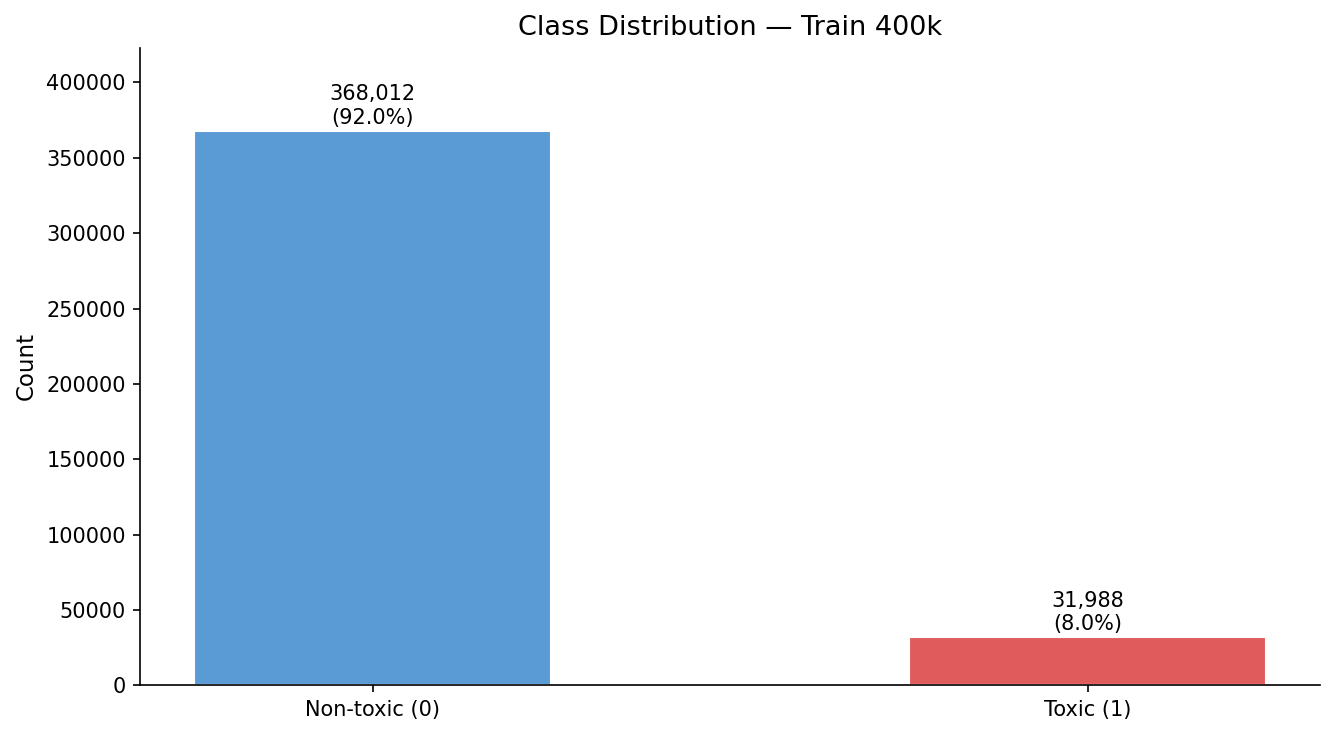

Saved: figures/eda_class_distribution.png


In [ ]:
label_counts = train_400k[LABEL_COL].value_counts().sort_index()
label_pcts   = 100 * label_counts / len(train_400k)

fig, ax = plt.subplots()
bars = ax.bar(
    ["Non-toxic (0)", "Toxic (1)"],
    label_counts.values,
    color=["#5b9bd5", "#e05c5c"],
    width=0.5,
    edgecolor="white",
)
for bar, count, pct in zip(bars, label_counts.values, label_pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Class Distribution — Train 400k")
ax.set_ylabel("Count")
ax.set_ylim(0, label_counts.max() * 1.15)

fig.tight_layout()
fig.savefig(os.path.join(CONFIG["figures_dir"], "eda_class_distribution.png"), dpi=300)
plt.show()
print("Saved: figures/eda_class_distribution.png")

The figure shows a strong class imbalance: 368,012 comments (92.0%) are non-toxic, while 31,988 comments (8.0%) are toxic. This level of skew is large enough that a naïve majority-class classifier could achieve high accuracy without being useful for toxic comment detection.

This result should be interpreted as a property of the binarised target defined for this study, not as an official native binary label of the original dataset. The observed imbalance supports the choice to prioritise precision–recall-based evaluation in the remainder of the project and provides essential context for interpreting later model comparisons.

### 7.2 — Comment Length Distribution

Comment length is a practically relevant variable because it may affect the two modelling families differently. In TF-IDF-based models, longer comments contain more observed tokens and may therefore provide richer lexical evidence, although greater length does not automatically imply easier classification. In DistilBERT, inputs longer than the configured maximum sequence length are truncated. In this project, `max_len=128` tokens is used, so character length is examined here as a rough proxy for whether truncation may affect the upper tail of the distribution.

The figure below summarises the comment-length distribution in `train_400k` and provides context for the length-slice supporting analysis in final sections

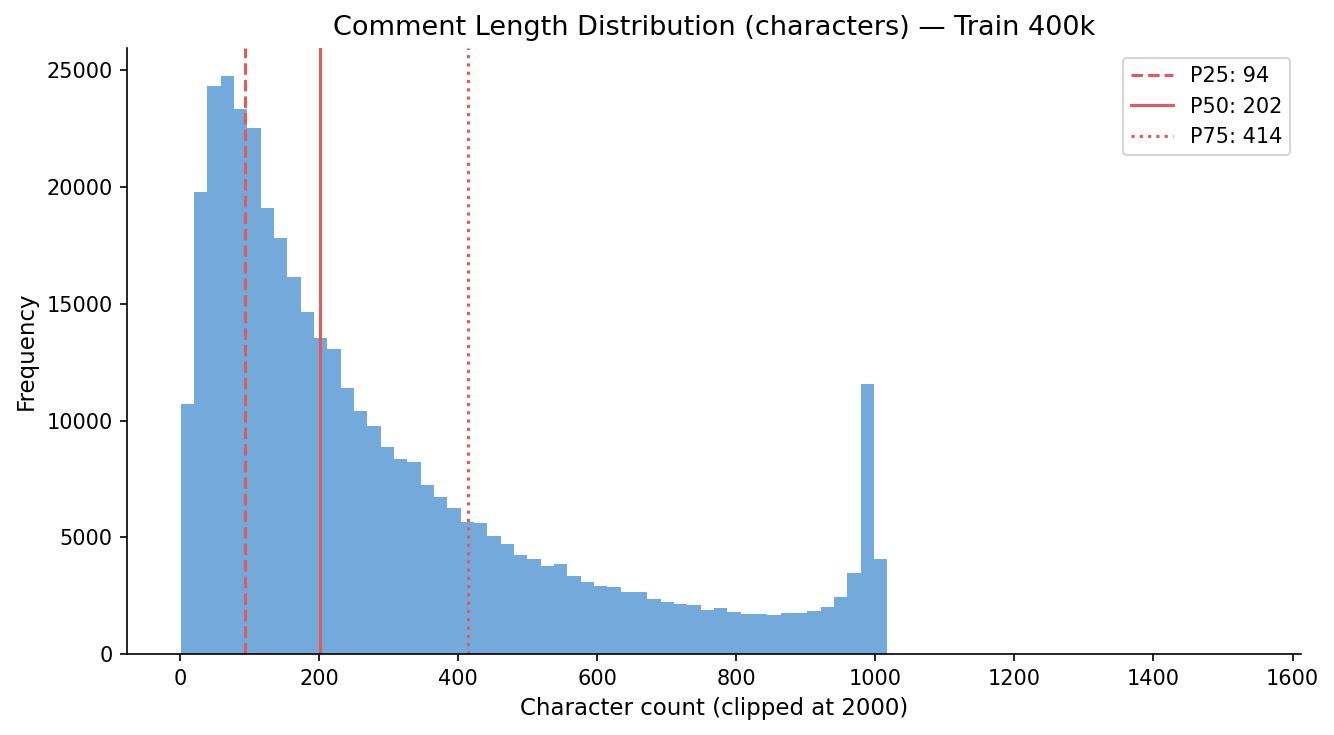

P25: 94 chars  |  P50: 202 chars (~40 tokens, rough)  |  P75: 414 chars (~83 tokens, rough)
Comments longer than ~640 chars (roughly beyond 128 tokens): 52,847 (13.21%)
Saved: figures/eda_length_distribution.png


In [ ]:
train_400k["text_length"] = train_400k[TEXT_COL].str.len()

p25 = train_400k["text_length"].quantile(0.25)
p50 = train_400k["text_length"].quantile(0.50)
p75 = train_400k["text_length"].quantile(0.75)

TRUNC_CHAR_APPROX = 640  # rough heuristic for ~128 tokens, used only for descriptive context
n_over_trunc = (train_400k["text_length"] > TRUNC_CHAR_APPROX).sum()
pct_over_trunc = 100 * n_over_trunc / len(train_400k)

fig, ax = plt.subplots()
ax.hist(
    train_400k["text_length"].clip(upper=2000),
    bins=80,
    color="#5b9bd5",
    edgecolor="none",
    alpha=0.85,
)

for pval, label, ls in [(p25, "P25", "--"), (p50, "P50", "-"), (p75, "P75", ":")]:
    ax.axvline(
        pval,
        color="#e05c5c",
        linestyle=ls,
        linewidth=1.5,
        label=f"{label}: {pval:.0f}"
    )

ax.set_title("Comment Length Distribution (characters) — Train 400k")
ax.set_xlabel("Character count (clipped at 2000)")
ax.set_ylabel("Frequency")
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(CONFIG["figures_dir"], "eda_length_distribution.png"), dpi=300)
plt.show()

approx_tokens_p50 = p50 / 5
approx_tokens_p75 = p75 / 5

print(
    f"P25: {p25:.0f} chars  |  "
    f"P50: {p50:.0f} chars (~{approx_tokens_p50:.0f} tokens, rough)  |  "
    f"P75: {p75:.0f} chars (~{approx_tokens_p75:.0f} tokens, rough)"
)
print(
    f"Comments longer than ~{TRUNC_CHAR_APPROX} chars "
    f"(roughly beyond 128 tokens): {n_over_trunc:,} ({pct_over_trunc:.2f}%)"
)
print("Saved: figures/eda_length_distribution.png")

The distribution is strongly right-skewed. The 25th, 50th, and 75th percentiles are 94, 202, and 414 characters respectively, indicating that most comments are relatively short to medium length. Using a rough character-to-token heuristic, the median comment is comfortably below the 128-token limit used for DistilBERT, and even the 75th percentile remains below that approximate truncation region.

At the same time, 52,847 comments (13.21%) are longer than approximately 640 characters, which provides a practical indication that truncation may affect a non-trivial minority of the training data. This suggests that truncation is unlikely to shape performance for the majority of comments, but it may matter for the upper tail of the distribution, especially for substantially longer texts.

For this reason, the length-slice analysis in final section is well justified: it will test whether performance differences between classical models and DistilBERT become more pronounced on longer comments, where input truncation is more likely to matter.

### 7.3 — Comment Length by Class

An additional question is whether comment length differs systematically between the two classes. If one class contains substantially longer comments than the other, then model comparison could be affected indirectly through input length rather than label difficulty alone. For TF-IDF models, longer comments may contain more lexical evidence; for DistilBERT, longer comments are more likely to be truncated at the configured maximum sequence length. This figure therefore examines whether comment length is plausibly a class-dependent nuisance variable.

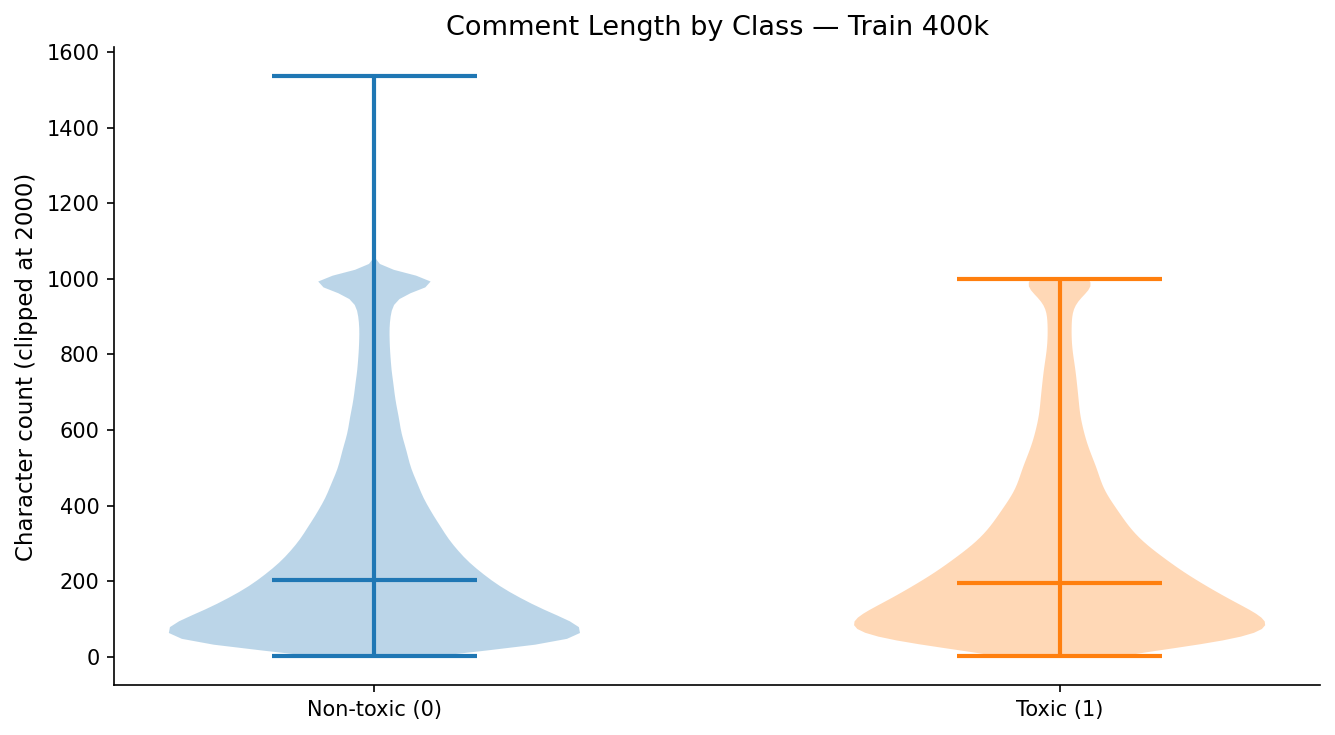

Non-toxic: P25=94, P50=203, P75=418 chars | >640 chars: 13.45%
Toxic: P25=98, P50=195, P75=373 chars | >640 chars: 10.47%
Saved: figures/eda_length_by_class.png


In [ ]:
fig, ax = plt.subplots()

for label_val, label_name in [
    (0, "Non-toxic (0)"),
    (1, "Toxic (1)"),
]:
    subset = train_400k.loc[train_400k[LABEL_COL] == label_val, "text_length"].clip(upper=2000)
    ax.violinplot(
        subset.values,
        positions=[label_val],
        showmedians=True,
        widths=0.6,
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(["Non-toxic (0)", "Toxic (1)"])
ax.set_title("Comment Length by Class — Train 400k")
ax.set_ylabel("Character count (clipped at 2000)")

fig.tight_layout()
fig.savefig(os.path.join(CONFIG["figures_dir"], "eda_length_by_class.png"), dpi=300)
plt.show()

TRUNC_CHAR_APPROX = 640

for v, name in [(0, "Non-toxic"), (1, "Toxic")]:
    subset = train_400k.loc[train_400k[LABEL_COL] == v, "text_length"]
    p25 = subset.quantile(0.25)
    p50 = subset.quantile(0.50)
    p75 = subset.quantile(0.75)
    pct_over_trunc = 100 * (subset > TRUNC_CHAR_APPROX).mean()

    print(
        f"{name}: "
        f"P25={p25:.0f}, P50={p50:.0f}, P75={p75:.0f} chars | "
        f">{TRUNC_CHAR_APPROX} chars: {pct_over_trunc:.2f}%"
    )

print("Saved: figures/eda_length_by_class.png")

The two class-conditional length distributions are broadly similar in central tendency, but not identical. The median length is 203 characters for non-toxic comments and 195 characters for toxic comments, which suggests that typical comment length does not differ dramatically between the two classes. This reduces concern that later model comparisons are driven primarily by a strong class-specific length imbalance.

At the same time, the upper tail is somewhat heavier for non-toxic comments. The 75th percentile is 418 characters for the non-toxic class versus 373 for the toxic class, and the proportion of comments longer than approximately 640 characters is 13.45% for non-toxic comments compared with 10.47% for toxic comments. This indicates that very long comments are slightly more common in the non-toxic class rather than the toxic class.

Overall, the evidence does not suggest a major class-length confound, but it does show that the two distributions are not perfectly identical. For that reason, length should still be treated as a relevant supporting variable in later interpretation, and the final section length-slice analysis remains justified for testing whether model behaviour changes on longer comments.

### 7.4 — Illustrative Example Comments

The following examples provide qualitative context for the type of language the classifier is asked to distinguish. They are sampled from `train_25k` without manual curation and are included only as illustrative instances, not as statistically representative evidence of the full dataset. Because the dataset concerns toxic language, some examples may contain offensive or disturbing content.

In [ ]:
import textwrap

rng = np.random.default_rng(SEED)

toxic_examples    = train_25k[train_25k[LABEL_COL] == 1].sample(5, random_state=SEED)
nontoxic_examples = train_25k[train_25k[LABEL_COL] == 0].sample(5, random_state=SEED)
examples = pd.concat([toxic_examples, nontoxic_examples]).reset_index(drop=True)
examples["text_preview"] = examples[TEXT_COL].str[:200]
examples["label_name"]   = examples[LABEL_COL].map({0: "Non-toxic", 1: "Toxic"})

display(
    examples[["label_name", "text_preview"]]
    .rename(columns={"label_name": "Label", "text_preview": "Text (first 200 chars)"})
    .style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
)
print("\nExamples shown as sampled from train_25k, without curation.")

,Label,Text (first 200 chars)
0,Toxic,Seems our reps in Juneau just can't seem to find any waste in the budget. The only real options left is to steal the PFD and tax the in state workers. What a bunch of useless bozos down there.
1,Toxic,Expel all of them. They already have warped minds.
2,Toxic,"So, Democrats are only loyal to a nation if they believe Russian collusion without evidence? Try thinking like a lawyer and look at the evidence instead of a party hack and you, too will see that this"
3,Toxic,"Kadri seems to really have turned a corner this year, he was always at his best when he had a snarl on and it seems for most of this season he has been playing like someone peed in his cheerios. Some"
4,Toxic,The b***h is back. Worse than the Kardashians.
5,Non-toxic,"Trump's presidency is really just a byproduct of Russia's excellent and endlessnessly effective spy agency, the FSB. They have singlehandedly brought America to its knees with barely a sound from the"
6,Non-toxic,"No, but think about it. When I've asked either side what their specific reasons are for their selection do you know what the response usually is? It's blaming the other party.... they don't even know"
7,Non-toxic,"""It would not be unprecedented. In 2013, Democrats were in the majority and upset about appellate court nominees being blocked by Republicans. They pushed through a rules change lowering the vote thre"
8,Non-toxic,It sure sounds inconvenient to be an illegal alien residing in this country. I wonder what alternatives these people might choose that would make their life less inconvenient
9,Non-toxic,"Unfortunately, in civil litigation, you will never be able to make all parties happy. It is also impossible, simply by looking through court view records, to get an accurate picture of what is going o"



Examples shown as sampled from train_25k, without curation.


These sampled examples help make the task more concrete. The toxic examples often include direct insults, hostile phrasing, or derogatory language, whereas the non-toxic examples more often reflect political discussion, opinion, or factual commentary without crossing the toxicity threshold used in this study.

At the same time, the examples also show why the task is non-trivial. Some comments in the non-toxic class contain contentious or polarising language, and some toxic comments are less extreme than overt slurs or threats. This illustrates that the binary target is not simply separating “clean” from “obviously abusive” text, but rather reflects the study’s operational threshold on a continuum of potentially harmful language. That ambiguity is one reason why later error analysis is important.

### 7.5 — Split Consistency Check

The train subsets (`train_25k`, `train_100k`, `train_400k`) and the fixed `val_20k` subset were constructed using stratified sampling, while the `test` split is the official dataset test split used as-is. This table checks that class prevalence remains closely aligned across all working splits and that no substantial drift has been introduced during subset construction.

A deviation larger than approximately ±0.5 percentage points would warrant investigation. Smaller differences are expected because prevalence cannot always be matched exactly under finite sample sizes, and because the official validation and test splits are separate data partitions rather than resampled copies of the training set.

In [ ]:
splits_info = [
    ("train_25k",  train_25k),
    ("train_100k", train_100k),
    ("train_400k", train_400k),
    ("val_20k",    val_20k),
    ("test",       test_df),
]

consistency_rows = []
for split_name, df in splits_info:
    n     = len(df)
    n_pos = int(df[LABEL_COL].sum())
    prev  = 100 * n_pos / n
    consistency_rows.append({
        "Split":          split_name,
        "Rows":           n,
        "Positive":       n_pos,
        "Prevalence (%)": round(prev, 2),
    })

consistency_df = pd.DataFrame(consistency_rows)
display(consistency_df.style.format({
    "Rows":     "{:,}",
    "Positive": "{:,}",
}))

prevs = [r["Prevalence (%)"] for r in consistency_rows]
max_dev = max(prevs) - min(prevs)
print(f"\nMax prevalence deviation across splits: {max_dev:.3f} percentage points")
if max_dev <= 0.5:
    print("✓ All splits within ±0.5 pp — stratification is consistent.")
else:
    print("⚠ Deviation exceeds 0.5 pp — investigate before proceeding.")

,Split,Rows,Positive,Prevalence (%)
0,train_25k,"25,000","1,999",8.000000
1,train_100k,"100,000","7,997",8.000000
2,train_400k,"400,000","31,988",8.000000
3,val_20k,"20,000","1,576",7.880000
4,test,"97,320","7,777",7.990000



Max prevalence deviation across splits: 0.120 percentage points
✓ All splits within ±0.5 pp — stratification is consistent.


The class prevalences are highly consistent across all working splits. The three nested training subsets each retain an 8.00% positive rate, while `val_20k` and `test` remain very close at 7.88% and 7.99% respectively. The maximum observed difference across splits is 0.120 percentage points, which is far below the pre-defined ±0.5 percentage-point tolerance.

This indicates that the subset-construction procedure preserved the intended class balance successfully. The small residual differences are negligible for the purposes of this study and are consistent with finite-sample allocation and the fact that validation and test originate from separate official splits rather than from the same sampled training pool.

### 7.6 — Raw Toxicity Score Distribution

The Civil Comments toxicity score is a continuous value in [0, 1] representing the fraction of human annotators who labelled the comment as toxic. The binary label used throughout this study is derived from this score via a threshold at 0.5: a comment is labelled toxic if a majority of annotators agreed. Before interpreting any classification results, it is important to understand where the score mass is concentrated and whether the 0.5 threshold is positioned in a sensible region of the score space.

This figure shows the raw score distribution, not the binarised label. It is included to provide context for the label construction used in this study and to expose the score structure that underlies the later binary classification task.

Samples              : 400,000
Score range          : [0.000, 1.000]
Distinct score values: 1685

Fraction with score < 0.5  (non-toxic) : 0.9200  (92.0%)
Fraction with score >= 0.5 (toxic)     : 0.0800  (8.0%)
Fraction in [0.4, 0.6]  (border zone)  : 0.0589  (5.9%)


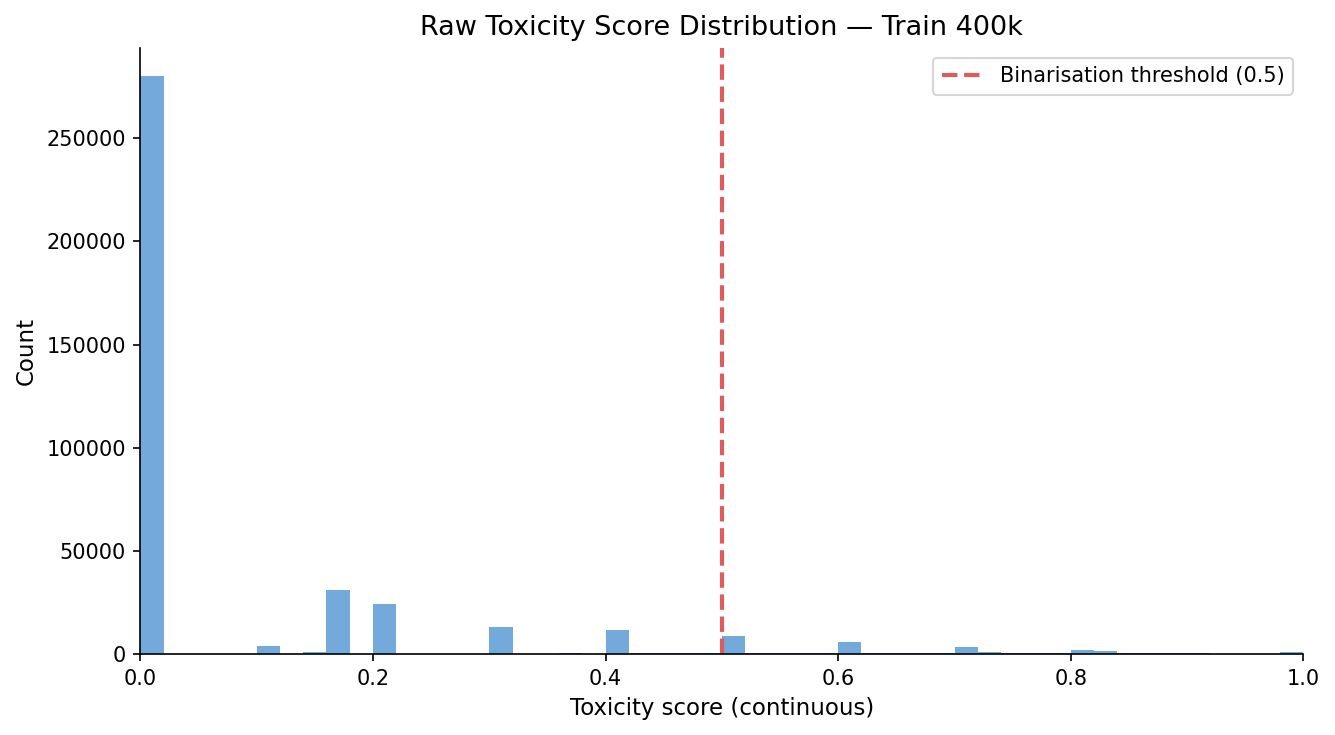

Saved: figures/eda_score_distribution.png


In [ ]:
SCORE_COL = CONFIG["score_col"]  # expected: continuous toxicity score in [0, 1]

if SCORE_COL not in train_400k.columns:
    raise KeyError(
        f"Expected raw score column '{SCORE_COL}' in train_400k for Section 7.6, "
        "but it was not found. This EDA subsection should analyse the working train split directly."
    )

raw_scores = train_400k[SCORE_COL].dropna().to_numpy()

print(f"Samples              : {len(raw_scores):,}")
print(f"Score range          : [{raw_scores.min():.3f}, {raw_scores.max():.3f}]")
print(f"Distinct score values: {pd.Series(raw_scores).nunique()}")

frac_below = (raw_scores < 0.5).mean()
frac_above = (raw_scores >= 0.5).mean()
frac_border = ((raw_scores >= 0.4) & (raw_scores < 0.6)).mean()

print(f"\nFraction with score < 0.5  (non-toxic) : {frac_below:.4f}  ({100*frac_below:.1f}%)")
print(f"Fraction with score >= 0.5 (toxic)     : {frac_above:.4f}  ({100*frac_above:.1f}%)")
print(f"Fraction in [0.4, 0.6]  (border zone)  : {frac_border:.4f}  ({100*frac_border:.1f}%)")

fig, ax = plt.subplots()
ax.hist(
    raw_scores,
    bins=50,
    range=(0, 1),
    color="#5b9bd5",
    edgecolor="none",
    alpha=0.85,
)
ax.axvline(
    0.5,
    color="#e05c5c",
    linestyle="--",
    linewidth=2,
    label="Binarisation threshold (0.5)",
)

ax.set_title("Raw Toxicity Score Distribution — Train 400k")
ax.set_xlabel("Toxicity score (continuous)")
ax.set_ylabel("Count")
ax.set_xlim(0, 1)
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(CONFIG["figures_dir"], "eda_score_distribution.png"), dpi=300)
plt.show()
print("Saved: figures/eda_score_distribution.png")

The distribution is extremely right-skewed. Most comments receive scores very close to zero, while much smaller mass is spread across higher toxicity values. The visibly spiky shape is also informative: because the score is derived from annotator fractions, the observed values are not perfectly continuous in practice, and the histogram reflects that quantised structure.

The threshold at 0.5 lies in a much lower-density region than the dominant mass near zero. In the present sample, 92.0% of comments fall below 0.5, 8.0% fall at or above it, and 5.9% lie in the broader [0.4, 0.6] neighbourhood around the threshold. This suggests that the binarisation rule is not dividing the densest part of the score distribution, which supports its practical defensibility for this study.

At the same time, a sparse threshold region does not eliminate ambiguity entirely: even a modest percentage corresponds to many comments in absolute terms at this dataset size. Those borderline cases remain important for interpretation and motivate the closer threshold-focused inspection in Section 7.7.

### 7.7 — Threshold Region Zoom (Around 0.5)

The full-range histogram in Section 7.6 compresses the threshold neighbourhood because the score distribution is dominated by very low toxicity values. This zoomed view isolates the [0.3, 0.7] interval in order to examine the local density structure around the 0.5 binarisation threshold more directly.

If this region were densely populated, the binary target would depend heavily on relatively small differences in annotator agreement near the decision boundary. Such cases are operationally borderline and are likely to be harder to classify consistently than examples with scores far from the threshold.

Proportion of all training samples with score in [0.40, 0.60]: 0.0589  (5.89%)
Proportion of all training samples with score in [0.45, 0.55]: 0.0257  (2.57%)
(Absolute count in [0.40, 0.60]: ~23,546)


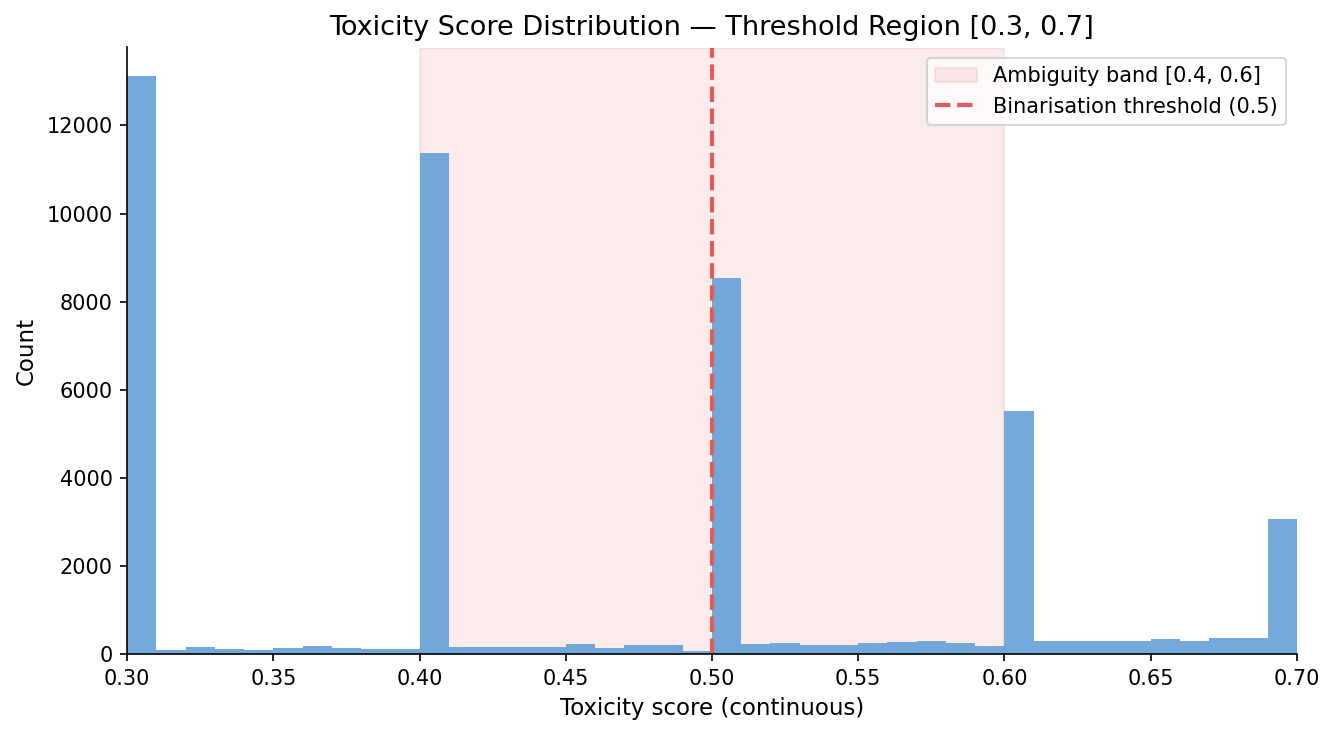

Saved: figures/eda_score_threshold_zoom.png


In [ ]:
# raw_scores already computed in 7.6
zoom_mask = (raw_scores >= 0.3) & (raw_scores <= 0.7)
zoom_scores = raw_scores[zoom_mask]

frac_band_wide   = ((raw_scores >= 0.4) & (raw_scores < 0.6)).mean()
frac_band_narrow = ((raw_scores >= 0.45) & (raw_scores < 0.55)).mean()

print(f"Proportion of all training samples with score in [0.40, 0.60]: {frac_band_wide:.4f}  ({100*frac_band_wide:.2f}%)")
print(f"Proportion of all training samples with score in [0.45, 0.55]: {frac_band_narrow:.4f}  ({100*frac_band_narrow:.2f}%)")
print(f"(Absolute count in [0.40, 0.60]: ~{int(frac_band_wide * len(raw_scores)):,})")

fig, ax = plt.subplots()

# Shaded ambiguity band [0.4, 0.6]
ax.axvspan(0.4, 0.6, alpha=0.12, color="#e05c5c", label="Ambiguity band [0.4, 0.6]")

ax.hist(zoom_scores, bins=40, range=(0.3, 0.7),
        color="#5b9bd5", edgecolor="none", alpha=0.85)
ax.axvline(0.5, color="#e05c5c", linestyle="--", linewidth=2,
           label="Binarisation threshold (0.5)")

ax.set_title("Toxicity Score Distribution — Threshold Region [0.3, 0.7]")
ax.set_xlabel("Toxicity score (continuous)")
ax.set_ylabel("Count")
ax.set_xlim(0.3, 0.7)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CONFIG["figures_dir"], "eda_score_threshold_zoom.png"), dpi=300)
plt.show()
print("Saved: figures/eda_score_threshold_zoom.png")

The zoomed view shows that the threshold region is not empty, but it is not the dominant part of the score distribution either. In the present sample, 5.89% of comments fall within the broader [0.40, 0.60] band, while 2.57% fall within the narrower [0.45, 0.55] band. This indicates that genuinely borderline cases are present in non-trivial absolute numbers, but they do not constitute the bulk of the dataset.

This is an important interpretive result. It suggests that the 0.5 threshold is not cutting through the densest part of the score space, which supports the practical stability of the binarisation rule used in this study. At the same time, the existence of thousands of near-threshold examples means that some ambiguity should be expected in downstream classification results.

Accordingly, later error analysis should be interpreted with this threshold structure in mind: false positives and false negatives are likely to include a meaningful share of borderline comments whose scores lie close to the operational decision boundary. This is not a flaw in the experimental design, but a property of the underlying annotation-based target.

### 7.8 — Toxic Prevalence by Comment Length Bin

If toxicity prevalence varies systematically with comment length, then any performance difference observed by length bin in Sprint 4 could reflect slice-specific class-prior differences rather than model capability alone. This analysis therefore tests whether comment length and the target label are associated, providing empirical grounding for the later length-slice interpretation.

Comments are grouped into 10 quantile-based bins (deciles by character count) so that each bin contains approximately equal numbers of examples, making prevalence estimates more directly comparable across bins.

Length bin (chars)     N  N toxic  Prevalence (%)
              1–47 40404     2712            6.71
             47–78 40378     3236            8.01
            78–112 40279     3457            8.58
           112–152 39401     3493            8.87
           152–202 39948     3625            9.07
           202–267 39972     3600            9.01
           267–355 39891     3383            8.48
           355–490 39925     3140            7.86
           490–746 39889     2924            7.33
          746–1535 39913     2418            6.06


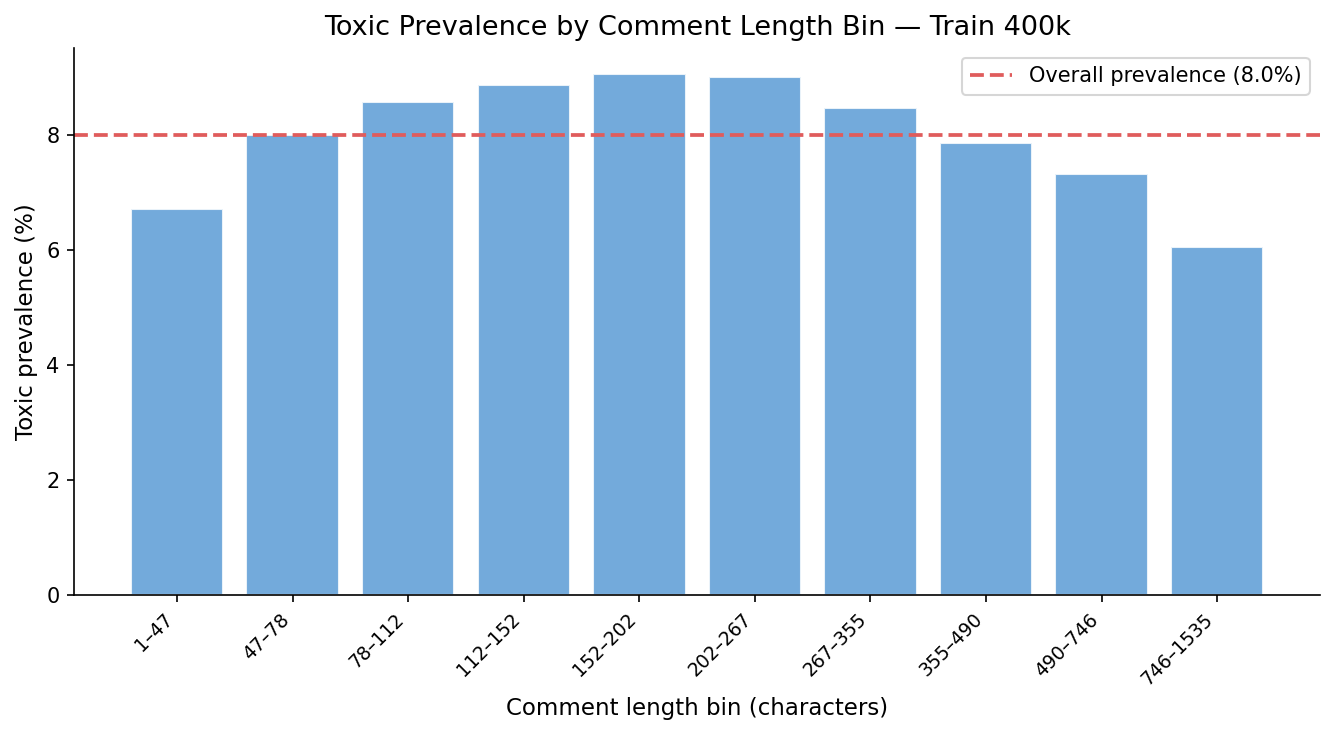

Saved: figures/eda_prevalence_by_length.png


In [ ]:
# text_length already added to train_400k in Section 7.2
if "text_length" not in train_400k.columns:
    train_400k["text_length"] = train_400k[TEXT_COL].str.len()

# Decile bin edges
bin_edges = np.quantile(train_400k["text_length"], np.linspace(0, 1, 11))
bin_edges = np.unique(bin_edges.astype(int))  # deduplicate in case of ties

bin_labels = [f"{int(bin_edges[i])}–{int(bin_edges[i+1])}"
              for i in range(len(bin_edges) - 1)]

train_400k["length_bin"] = pd.cut(
    train_400k["text_length"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
)

prevalence_table = (
    train_400k.groupby("length_bin", observed=True)[LABEL_COL]
    .agg(n="count", n_toxic="sum")
    .assign(prevalence_pct=lambda d: 100 * d["n_toxic"] / d["n"])
    .reset_index()
)
prevalence_table.columns = ["Length bin (chars)", "N", "N toxic", "Prevalence (%)"]
prevalence_table["Prevalence (%)"] = prevalence_table["Prevalence (%)"].round(2)
print(prevalence_table.to_string(index=False))

overall_prev = 100 * train_400k[LABEL_COL].mean()

fig, ax = plt.subplots()
ax.bar(
    range(len(prevalence_table)),
    prevalence_table["Prevalence (%)"],
    color="#5b9bd5", edgecolor="white", alpha=0.85,
)
ax.axhline(overall_prev, color="#e05c5c", linestyle="--", linewidth=1.8,
           label=f"Overall prevalence ({overall_prev:.1f}%)")
ax.set_xticks(range(len(prevalence_table)))
ax.set_xticklabels(prevalence_table["Length bin (chars)"],
                   rotation=45, ha="right", fontsize=9)
ax.set_title("Toxic Prevalence by Comment Length Bin — Train 400k")
ax.set_xlabel("Comment length bin (characters)")
ax.set_ylabel("Toxic prevalence (%)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(CONFIG["figures_dir"], "eda_prevalence_by_length.png"), dpi=300)
plt.show()
print("Saved: figures/eda_prevalence_by_length.png")

# Clean up temporary column to keep train_400k tidy
train_400k.drop(columns=["length_bin"], inplace=True, errors="ignore")

The prevalence-by-length analysis shows that toxicity is not distributed uniformly across comment lengths. In this sample, the shortest bin (1–47 characters) has a lower toxic prevalence than the dataset-wide average (6.71% vs. 8.0%). Prevalence then rises above the overall baseline across the mid-length bins, peaking at approximately 9.07% in the 152–202 character range, before declining again in the longest bins, reaching 6.06% in the 746–1535 character range.

This indicates that comment length is associated with the target distribution in a non-uniform and non-monotonic way. That result is methodologically important because it means that any later performance differences across length slices should not be interpreted as reflecting model capability alone: part of the difficulty profile may also vary with the class prior in each slice.

Accordingly, the final part length-slice analysis is well justified. If bin-level performance differs across short, medium, and long comments, those differences should be interpreted relative to the prevalence structure of each slice rather than only against the overall 8.0% dataset prevalence. In other words, comment length is not merely an input-format issue; it is also associated with how the target itself is distributed across the data.

## Section 8 — Evaluation Protocol

This section is a formal declaration of the evaluation methodology. It is placed here — before any modelling begins — so that all metric, threshold, and split-role decisions are documented in advance rather than defined post hoc.

---

### Primary Metric: Average Precision (AP / PR-AUC summary)

The primary metric for this study is Average Precision (AP), reported as the summary measure over the precision–recall curve. This choice is motivated by the strong class imbalance in the dataset (approximately 8% positive). Under such imbalance, accuracy is not informative, and ROC-AUC can appear overly optimistic because performance on the abundant negative class can dominate the aggregate impression of quality. Precision–recall-based evaluation is therefore more appropriate for judging how effectively a model retrieves toxic comments while controlling false positives.

---

### Secondary Metric: Macro-F1

Macro-F1 is the secondary metric. It computes F1 separately for each class and then averages the two scores with equal weight, regardless of class frequency. This makes performance on the minority toxic class directly visible in the aggregate result. Because Macro-F1 depends on a decision threshold, it is always reported together with the threshold used to generate the hard predictions.

---

### Additional Metrics Reported

For completeness, the study also reports precision, recall, and F1 at both the per-class and macro-averaged levels, together with training time where practical.

---

### Threshold Policy

Average Precision is threshold-free and is computed directly from the full predicted score distribution. For Macro-F1 and all other threshold-dependent metrics, a decision threshold is applied to model scores.

The threshold is selected **per model, per training run, on the validation set only**, using the following procedure:

> The candidate thresholds returned by `precision_recall_curve(y_true, y_val_scores)` are evaluated exhaustively. The threshold that maximises validation Macro-F1 is selected as the operating threshold for that model and run.

This procedure is **score-range agnostic**: it works correctly whether the scores are probabilities in [0, 1] (as in Logistic Regression and DistilBERT) or raw unbounded decision-function values (as in Linear SVM). A fixed threshold grid such as [0.01, 0.99] would not be meaningful for score spaces that are not probability-scaled and is therefore not used.

Once selected on validation data, the threshold is applied unchanged to the corresponding test predictions. **The threshold is never re-selected on the test set.**

---

### Validation Role

The fixed `val_20k` split is used for exactly three purposes:
1. preliminary performance checks during the baseline phase,
2. hyperparameter selection during tuning,
3. threshold selection for threshold-dependent metrics.

It is used for nothing else.

---

### Test Role

The `test` split is reserved for held-out evaluation and is never used for model selection, hyperparameter choice, threshold selection, or any other design decision.

During the baseline phase, a test evaluation may be run as an **optional pipeline sanity check only**. If such a check is performed, the resulting test metrics are recorded purely for diagnostic completeness and play no role in any methodological decision. Final comparative reporting on the test set is conducted only after configurations are fixed.

---

### Tuning Rule

The best model configuration is selected by maximising **validation Average Precision (AP)**. Macro-F1 is treated as a secondary reference metric. Test results are not consulted during configuration selection.

## Section 9 — Helper Functions

All reusable logic is centralised in this section so that metric computation, threshold selection, persistence, plotting, and supporting analyses are implemented once and reused consistently throughout the notebook. This avoids duplicated evaluation logic and helps ensure that all model families are assessed under the same procedures.

The helper functions are organised into four logical groups:
1. core metric and threshold utilities,
2. saving and plotting utilities,
3. error-analysis and slice-analysis utilities,
4. DistilBERT / Trainer support utilities.

A small synthetic smoke test is included at the end of the section to verify that the core metric pipeline behaves as expected before model training begins.

In [ ]:
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, classification_report,
)
from datasets import Dataset as HFDataset
from transformers import EvalPrediction

# Re-seed before any model training
set_seed(SEED)

# Core metric and threshold utilities

def compute_text_length(series):
    """Character-length Series for a text Series."""
    return series.str.len()

def compute_metrics(y_true, y_scores, threshold=None):
    """
    Canonical metric function for all three model families.
    Works with probability scores (LR, DistilBERT) and raw
    decision-function scores (LinearSVC) without modification.

    If threshold is None, the function selects the validation threshold
    that maximises Macro-F1 over the candidate thresholds returned by
    precision_recall_curve.

    Note:
    Average Precision is only meaningful when both classes are present.
    In single-class edge cases (possible in slice analyses), PR-AUC is
    returned as NaN while threshold-dependent metrics are still computed.
    """
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)

    if y_true.shape[0] != y_scores.shape[0]:
        raise ValueError("y_true and y_scores must have the same length.")

    unique_classes = np.unique(y_true)

    # PR-AUC is only well-defined when both classes are present
    if len(unique_classes) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    if threshold is None:
        if len(unique_classes) < 2:
            # Fallback for degenerate slices; rarely used in practice
            threshold = float(np.median(y_scores))
        else:
            _, _, pr_thresholds = precision_recall_curve(y_true, y_scores)

            if len(pr_thresholds) == 0:
                threshold = float(np.median(y_scores))
            else:
                best_f1 = -1.0
                best_thresh = float(pr_thresholds[len(pr_thresholds) // 2])  # deterministic fallback

                for t in pr_thresholds:
                    preds = (y_scores >= t).astype(int)
                    f1 = f1_score(y_true, preds, average="macro", zero_division=0)
                    if f1 > best_f1:
                        best_f1 = f1
                        best_thresh = float(t)

                threshold = best_thresh

    y_pred = (y_scores >= threshold).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0,
    )

    return {
        "pr_auc": float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        "threshold": float(threshold),
        "macro_f1": report["macro avg"]["f1-score"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
    }

# Saving and plotting utilities
def save_predictions(y_true, y_scores, y_pred, split_name, run_id, config):
    """Saves predictions as Parquet to predictions/{run_id}_{split_name}.parquet"""
    df = pd.DataFrame({
        "y_true":   np.asarray(y_true),
        "y_scores": np.asarray(y_scores, dtype=float),
        "y_pred":   np.asarray(y_pred),
    })
    path = os.path.join(config["predictions_dir"], f"{run_id}_{split_name}.parquet")
    df.to_parquet(path, index=False)

def save_metrics(metrics_dict, run_id, config):
    """
    Saves metrics as JSON to metrics/{run_id}_metrics.json.
    Appends a row to logs/all_metrics_log.csv.
    """
    json_path = os.path.join(config["metrics_dir"], f"{run_id}_metrics.json")
    with open(json_path, "w") as f:
        json.dump(metrics_dict, f, indent=2)

    log_path = os.path.join(config["logs_dir"], "all_metrics_log.csv")
    row = {"run_id": run_id, **metrics_dict}
    row_df = pd.DataFrame([row])
    if os.path.exists(log_path):
        row_df.to_csv(log_path, mode="a", header=False, index=False)
    else:
        row_df.to_csv(log_path, mode="w", header=True, index=False)

def plot_pr_curve(y_true, y_scores, label, ax=None):
    """Plots a precision-recall curve on a given axis. Returns the axis."""
    if ax is None:
        _, ax = plt.subplots()
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ax.plot(recall, precision, label=label, linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    return ax

def save_figure(fig, filename, config):
    """Saves figure to figures/{filename} at 300 dpi and closes it."""
    path = os.path.join(config["figures_dir"], filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)

def track_time(start_time):
    """Returns elapsed seconds from a time.time() start."""
    return time.time() - start_time

# Error-analysis and slice-analysis utilities
def extract_error_samples(y_true, y_scores, y_pred, texts, threshold, n_each=10):
    """
    Returns (false_positives_df, false_negatives_df, borderline_df).
    Borderline: within 10% of the score range around the threshold.
    """
    y_true   = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    y_pred   = np.asarray(y_pred)
    texts    = np.asarray(texts)

    score_range = y_scores.max() - y_scores.min()
    epsilon     = 0.1 * score_range

    fp_mask   = (y_pred == 1) & (y_true == 0)
    fn_mask   = (y_pred == 0) & (y_true == 1)
    bord_mask = np.abs(y_scores - threshold) < epsilon

    def _sample(mask):
        idx = np.where(mask)[0]
        if len(idx) > n_each:
            idx = np.random.choice(idx, n_each, replace=False)
        return pd.DataFrame({
            "text":     texts[idx],
            "y_true":   y_true[idx],
            "y_scores": y_scores[idx],
            "y_pred":   y_pred[idx],
        })

    return _sample(fp_mask), _sample(fn_mask), _sample(bord_mask)

def length_slice_eval(y_true, y_scores, texts, threshold, bins):
    """
    Evaluates metrics per character-length bin.
    bins: dict of {label: (low, high)} character count ranges.
    Returns a DataFrame with one row per bin.
    """
    y_true   = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    lengths  = np.array([len(t) for t in texts])
    rows = []
    for bin_label, (lo, hi) in bins.items():
        mask = (lengths >= lo) & (lengths < hi)
        if mask.sum() == 0:
            continue
        m = compute_metrics(y_true[mask], y_scores[mask], threshold=threshold)
        rows.append({
            "bin":       bin_label,
            "n_samples": int(mask.sum()),
            "n_positive": int(y_true[mask].sum()),
            "pr_auc":    m["pr_auc"],
            "macro_f1":  m["macro_f1"],
        })
    return pd.DataFrame(rows)

# DistilBERT and Trainer support utilities
def tokenise_df(df, tokenizer, config):
    """
    Converts a DataFrame to a HuggingFace Dataset for use with Trainer.
    Tokenises to Python lists (NOT return_tensors='pt') to avoid OOM
    on large datasets. Tensor conversion happens lazily in the DataLoader.
    """
    texts  = df[config["text_col"]].tolist()
    labels = df[config["label_col"]].tolist()
    enc = tokenizer(
        texts,
        max_length=config["distilbert_max_len"],
        padding="max_length",
        truncation=True,
    )
    return HFDataset.from_dict({
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels":         labels,
    })

def compute_metrics_for_trainer(eval_pred: EvalPrediction) -> dict:
    """
    Lightweight wrapper for Trainer checkpoint selection ONLY.
    Returns validation PR-AUC so metric_for_best_model='eval_pr_auc'
    selects the best epoch. Do NOT use for post-training evaluation.
    """
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    exp_l    = np.exp(logits - logits.max(axis=1, keepdims=True))
    pos_probs = (exp_l / exp_l.sum(axis=1, keepdims=True))[:, 1]
    return {"pr_auc": float(average_precision_score(labels, pos_probs))}

print("All helper functions defined.")

All helper functions defined.


In [ ]:
# Synthetic sanity check
_y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1])
_y_scores = np.array([0.1, 0.2, 0.8, 0.9, 0.4, 0.7, 0.3, 0.6])

_result = compute_metrics(_y_true, _y_scores)

assert _result["pr_auc"] > 0.5, "PR-AUC unexpectedly low on clean synthetic data"
assert np.isfinite(_result["threshold"]), "Threshold must be finite"
assert 0.0 <= _result["macro_f1"] <= 1.0, "Macro-F1 out of range"

print("compute_metrics smoke test passed.")
print(
    f"  PR-AUC: {_result['pr_auc']:.4f} | "
    f"Threshold: {_result['threshold']:.4f} | "
    f"Macro-F1: {_result['macro_f1']:.4f}"
)

compute_metrics smoke test passed.
  PR-AUC: 1.0000 | Threshold: 0.6000 | Macro-F1: 1.0000


## Section 10 — Initial Baseline Experiments

These are preliminary baseline experiments. Their purpose is to:
1. confirm that the end-to-end pipeline — data loading, feature extraction, training, prediction, thresholding, and metric computation — works correctly for all three model families;
2. provide initial benchmark results for reference before the tuning stage in Sprint 3.

These baseline results are not used for model selection. Hyperparameter tuning and final comparative evaluation are conducted later. All baseline models in this section are trained on `train_25k` only.

Test evaluation in this section is included only as an optional pipeline sanity check. Sprint 2 test results are never used for model selection, hyperparameter selection, threshold decisions, or any other design choice. The test set remains reserved for held-out reporting after configurations are fixed.

In [ ]:
import joblib

TEXT_COL  = CONFIG["text_col"]
LABEL_COL = CONFIG["label_col"]

y_val  = val_20k[LABEL_COL].values
y_test = test_df[LABEL_COL].values

# No-skill PR-AUC = positive class prevalence in validation set
noskill_pr_auc = y_val.mean()
print(f"No-skill PR-AUC (val prevalence): {noskill_pr_auc:.4f}")
print("A PR-AUC below this value may indicate either a pipeline issue or a very weak model configuration.\n")

No-skill PR-AUC (val prevalence): 0.0788
A PR-AUC below this value may indicate either a pipeline issue or a very weak model configuration.



### 10.1 — Logistic Regression Baseline

A pre-specified TF-IDF + Logistic Regression baseline with balanced class weighting. This serves as the main classical baseline for sparse text classification in the project.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

set_seed(SEED)
t0 = time.time()

tfidf_lr = TfidfVectorizer(
    max_features=CONFIG["tfidf_max_features"],
    ngram_range=CONFIG["tfidf_ngram_range"],
    sublinear_tf=CONFIG["tfidf_sublinear_tf"],
)
X_train_lr = tfidf_lr.fit_transform(train_25k[TEXT_COL])
X_val_lr   = tfidf_lr.transform(val_20k[TEXT_COL])
X_test_lr  = tfidf_lr.transform(test_df[TEXT_COL])

lr_model = LogisticRegression(
    C=CONFIG["lr_C"],
    max_iter=1000,
    solver="saga",
    class_weight="balanced",
    random_state=SEED,
)
lr_model.fit(X_train_lr, train_25k[LABEL_COL])
train_time_lr = track_time(t0)

# Validation (threshold selection happens here)
val_scores_lr  = lr_model.predict_proba(X_val_lr)[:, 1]
val_metrics_lr = compute_metrics(y_val, val_scores_lr)
chosen_threshold_lr = val_metrics_lr["threshold"]

# Test (sanity check only — threshold fixed from validation)
test_scores_lr  = lr_model.predict_proba(X_test_lr)[:, 1]
test_metrics_lr = compute_metrics(y_test, test_scores_lr, threshold=chosen_threshold_lr)

# Save
save_predictions(y_val,  val_scores_lr,  (val_scores_lr  >= chosen_threshold_lr).astype(int), "val",  "lr_baseline_25k", CONFIG)
save_predictions(y_test, test_scores_lr, (test_scores_lr >= chosen_threshold_lr).astype(int), "test", "lr_baseline_25k", CONFIG)
save_metrics({**val_metrics_lr,
              **{f"test_{k}": v for k, v in test_metrics_lr.items()},
              "train_time_s": train_time_lr, "train_size": "25k"}, "lr_baseline_25k", CONFIG)

print("─── LR Baseline (train_25k) ───────────────────────────────")
print(f"  Train time  : {train_time_lr:.1f}s")
print(f"  Val  PR-AUC : {val_metrics_lr['pr_auc']:.4f}  |  Macro-F1: {val_metrics_lr['macro_f1']:.4f}  |  Threshold: {chosen_threshold_lr:.4f}")
print(f"  Test PR-AUC : {test_metrics_lr['pr_auc']:.4f}  |  Macro-F1: {test_metrics_lr['macro_f1']:.4f}  [sanity check only]")
assert val_metrics_lr["pr_auc"] > noskill_pr_auc, "LR val PR-AUC below no-skill — check pipeline"
print("  ✓ PR-AUC above no-skill baseline")

─── LR Baseline (train_25k) ───────────────────────────────
  Train time  : 44.6s
  Val  PR-AUC : 0.4747  |  Macro-F1: 0.7121  |  Threshold: 0.0121
  Test PR-AUC : 0.4655  |  Macro-F1: 0.7024  [sanity check only]
  ✓ PR-AUC above no-skill baseline


### 10.2 — Linear SVM Baseline

LinearSVC uses the same TF-IDF features as LR. Unlike LR, it does not produce calibrated probabilities — it produces raw decision function scores in an unbounded real-valued range. These scores are used directly (no normalisation) for both PR-AUC and threshold selection. `compute_metrics` handles arbitrary score ranges correctly via `precision_recall_curve` thresholds.

In [ ]:
from sklearn.svm import LinearSVC

set_seed(SEED)
t0 = time.time()

tfidf_svm = TfidfVectorizer(
    max_features=CONFIG["tfidf_max_features"],
    ngram_range=CONFIG["tfidf_ngram_range"],
    sublinear_tf=CONFIG["tfidf_sublinear_tf"],
)
X_train_svm = tfidf_svm.fit_transform(train_25k[TEXT_COL])
X_val_svm   = tfidf_svm.transform(val_20k[TEXT_COL])
X_test_svm  = tfidf_svm.transform(test_df[TEXT_COL])

svm_model = LinearSVC(
    C=CONFIG["svm_C"],
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
)
svm_model.fit(X_train_svm, train_25k[LABEL_COL])
train_time_svm = track_time(t0)

# Raw decision function scores — no scaling needed
val_scores_svm  = svm_model.decision_function(X_val_svm)
test_scores_svm = svm_model.decision_function(X_test_svm)

val_metrics_svm = compute_metrics(y_val, val_scores_svm)
chosen_threshold_svm = val_metrics_svm["threshold"]
test_metrics_svm = compute_metrics(y_test, test_scores_svm, threshold=chosen_threshold_svm)

# Save
save_predictions(y_val,  val_scores_svm,  (val_scores_svm  >= chosen_threshold_svm).astype(int), "val",  "svm_baseline_25k", CONFIG)
save_predictions(y_test, test_scores_svm, (test_scores_svm >= chosen_threshold_svm).astype(int), "test", "svm_baseline_25k", CONFIG)
save_metrics({**val_metrics_svm,
              **{f"test_{k}": v for k, v in test_metrics_svm.items()},
              "train_time_s": train_time_svm, "train_size": "25k"}, "svm_baseline_25k", CONFIG)

print("─── SVM Baseline (train_25k) ──────────────────────────────")
print(f"  Train time  : {train_time_svm:.1f}s")
print(f"  Val  PR-AUC : {val_metrics_svm['pr_auc']:.4f}  |  Macro-F1: {val_metrics_svm['macro_f1']:.4f}  |  Threshold: {chosen_threshold_svm:.4f}")
print(f"  Test PR-AUC : {test_metrics_svm['pr_auc']:.4f}  |  Macro-F1: {test_metrics_svm['macro_f1']:.4f}  [sanity check only]")
assert val_metrics_svm["pr_auc"] > noskill_pr_auc, "SVM val PR-AUC below no-skill — check pipeline"
print("  ✓ PR-AUC above no-skill baseline")

─── SVM Baseline (train_25k) ──────────────────────────────
  Train time  : 12.9s
  Val  PR-AUC : 0.5269  |  Macro-F1: 0.7283  |  Threshold: -0.1231
  Test PR-AUC : 0.5179  |  Macro-F1: 0.7265  [sanity check only]
  ✓ PR-AUC above no-skill baseline


### 10.3 — DistilBERT Baseline

Fine-tuned on `train_25k` for 2 epochs using weighted cross-entropy loss (to handle class imbalance). `save_strategy="no"` — no checkpoints are written to Drive during the baseline run to save storage. The baseline uses `load_best_model_at_end=False` because this is a pipeline validation run, not a final model selection run.

**Memory note:** If OOM, reduce `per_device_train_batch_size` to 16 and add `gradient_accumulation_steps=2`.

In [ ]:
import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
)
from sklearn.utils.class_weight import compute_class_weight

set_seed(SEED)

# Tokeniser
tokenizer = AutoTokenizer.from_pretrained(CONFIG["distilbert_model_name"])

# Class weights from train_25k
cw_vals   = compute_class_weight("balanced", classes=np.array([0, 1]),
                                  y=train_25k[LABEL_COL].values)
cw_tensor = torch.tensor(cw_vals, dtype=torch.float).to(device)
print(f"Class weights: class-0 = {cw_vals[0]:.4f}, class-1 = {cw_vals[1]:.4f}")

# Tokenise
train_tok_b = tokenise_df(train_25k, tokenizer, CONFIG)
val_tok_b   = tokenise_df(val_20k,   tokenizer, CONFIG)
test_tok_b  = tokenise_df(test_df,   tokenizer, CONFIG)
print("Tokenisation complete.")

# WeightedTrainer
class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss = torch.nn.CrossEntropyLoss(weight=self.class_weights_tensor.to(logits.device))(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Model
model_bert_b = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["distilbert_model_name"], num_labels=2
)

# TrainingArguments — baseline: no checkpoint saving, no best-model selection
args_b = TrainingArguments(
    output_dir=os.path.join(CONFIG["models_dir"], "distilbert_baseline"),
    num_train_epochs=CONFIG["distilbert_epochs"],
    per_device_train_batch_size=CONFIG["distilbert_batch_size"],
    per_device_eval_batch_size=64,
    learning_rate=CONFIG["distilbert_lr"],
    warmup_ratio=CONFIG["distilbert_warmup_ratio"],
    weight_decay=0.01,
    eval_strategy="epoch",          # ← evaluation_strategy → eval_strategy
    save_strategy="no",
    load_best_model_at_end=False,
    logging_steps=100,
    fp16=True,
    seed=SEED,
    report_to="none",
)

trainer_b = WeightedTrainer(
    class_weights_tensor=cw_tensor,
    model=model_bert_b,
    args=args_b,
    train_dataset=train_tok_b,
    eval_dataset=val_tok_b,
)

t0 = time.time()
trainer_b.train()
train_time_bert = track_time(t0)

# Inference
val_preds_b  = trainer_b.predict(val_tok_b)
val_scores_bert = torch.softmax(torch.tensor(val_preds_b.predictions, dtype=torch.float), dim=1).numpy()[:, 1]
val_metrics_bert = compute_metrics(y_val, val_scores_bert)
chosen_threshold_bert = val_metrics_bert["threshold"]

test_preds_b = trainer_b.predict(test_tok_b)
test_scores_bert = torch.softmax(torch.tensor(test_preds_b.predictions, dtype=torch.float), dim=1).numpy()[:, 1]
test_metrics_bert = compute_metrics(y_test, test_scores_bert, threshold=chosen_threshold_bert)

# Save
save_predictions(y_val,  val_scores_bert,  (val_scores_bert  >= chosen_threshold_bert).astype(int), "val",  "distilbert_baseline_25k", CONFIG)
save_predictions(y_test, test_scores_bert, (test_scores_bert >= chosen_threshold_bert).astype(int), "test", "distilbert_baseline_25k", CONFIG)
save_metrics({**val_metrics_bert,
              **{f"test_{k}": v for k, v in test_metrics_bert.items()},
              "train_time_s": train_time_bert, "train_size": "25k"}, "distilbert_baseline_25k", CONFIG)

print("\n─── DistilBERT Baseline (train_25k) ───────────────────────")
print(f"  Train time  : {train_time_bert:.1f}s")
print(f"  Val  PR-AUC : {val_metrics_bert['pr_auc']:.4f}  |  Macro-F1: {val_metrics_bert['macro_f1']:.4f}  |  Threshold: {chosen_threshold_bert:.4f}")
print(f"  Test PR-AUC : {test_metrics_bert['pr_auc']:.4f}  |  Macro-F1: {test_metrics_bert['macro_f1']:.4f}  [sanity check only]")
assert val_metrics_bert["pr_auc"] > noskill_pr_auc, "DistilBERT val PR-AUC below no-skill — check pipeline"
print("  ✓ PR-AUC above no-skill baseline")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Class weights: class-0 = 0.5435, class-1 = 6.2531
Tokenisation complete.


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.376696,0.367088
2,0.236603,0.369849



─── DistilBERT Baseline (train_25k) ───────────────────────
  Train time  : 109.8s
  Val  PR-AUC : 0.7049  |  Macro-F1: 0.8079  |  Threshold: 0.9046
  Test PR-AUC : 0.6987  |  Macro-F1: 0.8037  [sanity check only]
  ✓ PR-AUC above no-skill baseline


### 10.4 — Baseline Summary

In [ ]:
baseline_rows = [
    {"Model": "Logistic Regression", "Train Size": "25k",
     "Val PR-AUC":  round(val_metrics_lr["pr_auc"],   4),
     "Val Macro-F1": round(val_metrics_lr["macro_f1"],  4),
     "Test PR-AUC": round(test_metrics_lr["pr_auc"],  4),
     "Test Macro-F1": round(test_metrics_lr["macro_f1"], 4),
     "Train Time (s)": round(train_time_lr, 1)},
    {"Model": "Linear SVM", "Train Size": "25k",
     "Val PR-AUC":  round(val_metrics_svm["pr_auc"],   4),
     "Val Macro-F1": round(val_metrics_svm["macro_f1"],  4),
     "Test PR-AUC": round(test_metrics_svm["pr_auc"],  4),
     "Test Macro-F1": round(test_metrics_svm["macro_f1"], 4),
     "Train Time (s)": round(train_time_svm, 1)},
    {"Model": "DistilBERT", "Train Size": "25k",
     "Val PR-AUC":  round(val_metrics_bert["pr_auc"],   4),
     "Val Macro-F1": round(val_metrics_bert["macro_f1"],  4),
     "Test PR-AUC": round(test_metrics_bert["pr_auc"],  4),
     "Test Macro-F1": round(test_metrics_bert["macro_f1"], 4),
     "Train Time (s)": round(train_time_bert, 1)},
]

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df.style.highlight_max(subset=["Val PR-AUC", "Val Macro-F1"], color="#d4edda"))

print(f"\nNo-skill PR-AUC baseline: {noskill_pr_auc:.4f}")
print("All models must exceed this value to demonstrate meaningful learning.")
print("\nTest metrics above are sanity checks only — not used for any decision.")

,Model,Train Size,Val PR-AUC,Val Macro-F1,Test PR-AUC,Test Macro-F1,Train Time (s)
0,Logistic Regression,25k,0.474700,0.712100,0.465500,0.702400,44.600000
1,Linear SVM,25k,0.526900,0.728300,0.517900,0.726500,12.900000
2,DistilBERT,25k,0.704900,0.807900,0.698700,0.803700,109.800000



No-skill PR-AUC baseline: 0.0788
All models must exceed this value to demonstrate meaningful learning.

Test metrics above are sanity checks only — not used for any decision.


All three models produce validation PR-AUC substantially above the no-skill baseline, confirming that the end-to-end pipeline is functioning correctly for all three model families. These baseline results serve as preliminary reference points for hyperparameter tuning, where hyperparameter tuning is expected to improve performance further.

No cross-model selection, hyperparameter choice, or final reporting decision is made on the basis of these baseline results. Threshold selection is still performed within each run on the validation set, as defined in the evaluation protocol, but the section test results remain sanity checks only and are not used to guide methodology.

## Section 11 — Hyperparameter Tuning

This section applies a two-stage hyperparameter tuning strategy consisting of a **coarse search** followed by a **refinement search**. The purpose of the coarse search is to scan a small but well-motivated region of the hyperparameter space and identify the most promising configuration patterns for each model family. The refinement stage then narrows the search around the strongest coarse-search results in order to make a more focused model-selection decision.

The tuning philosophy throughout is deliberately restrained. The objective is not exhaustive optimisation, but a transparent and computationally realistic search that can identify configurations that are meaningfully stronger than the corresponding baselines.

**Tuning training size.** The classical models, Logistic Regression and Linear SVM, are tuned on `train_100k`, which is large enough for validation behaviour to stabilise while remaining computationally feasible in the available environment. DistilBERT is tuned on `train_25k` because transformer fine-tuning is substantially more expensive; the rationale for this separate setup is discussed in Section 11.3.

**Selection criterion.** Validation PR-AUC is used as the sole model-selection criterion throughout Section 11. Macro-F1 is reported as a secondary descriptive metric, but it does not determine model choice.

**Role of the test set.** The test set is not used at any point in this section. All search decisions are made exclusively on the validation split.

### 11.1 — Logistic Regression: The Coarse Search

The first stage of Logistic Regression tuning is a **coarse search** over a compact set of plausible TF-IDF and regularisation choices. For sparse linear models, performance is expected to depend most strongly on the vocabulary size, the inclusion or exclusion of bigrams, sublinear term-frequency scaling, and the regularisation strength `C`. The aim at this stage is not to pinpoint a final configuration immediately, but to establish which broad region of the search space is most promising.

To keep the search computationally manageable in Colab while still covering the main modelling choices, a restricted 16-configuration grid is used. This grid varies `max_features`, `ngram_range`, `sublinear_tf`, and `C`, and each configuration is trained on `train_100k` and evaluated on `val_20k`.

As in the rest of Section 11, validation PR-AUC is the only selection criterion used for comparison across configurations. Macro-F1 is reported for reference only. Because this coarse search is run on `train_100k`, any gains relative to the earlier 25k Logistic Regression baseline should be interpreted cautiously: the differences observed here may reflect both increased training data and improved hyperparameter choices. Accordingly, the main purpose of this subsection is to identify the most promising Logistic Regression region to examine more closely in the refinement stage.

In [ ]:
import itertools
import gc
import os
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

set_seed(SEED)

# Lean grid for Colab: 16 configs instead of 36
lr_param_grid = {
    "tfidf_max_features": [30_000, 50_000],
    "tfidf_ngram_range":  [(1, 1), (1, 2)],
    "tfidf_sublinear_tf": [True, False],
    "C":                  [0.1, 1.0],
}

keys = list(lr_param_grid.keys())
combos = list(itertools.product(*lr_param_grid.values()))
print(f"LR tuning: {len(combos)} configurations on train_100k\n")

y_train_100k = train_100k[LABEL_COL].values
lr_tuning_rows = []

results_path = os.path.join(CONFIG["tables_dir"], "lr_tuning_results.csv")
best_config_path = os.path.join(CONFIG["tables_dir"], "lr_best_config.json")

overall_start = time.time()

progress_bar = tqdm(
    enumerate(combos, start=1),
    total=len(combos),
    desc="LR tuning",
    unit="config"
)

for i, combo in progress_bar:
    params = dict(zip(keys, combo))
    set_seed(SEED)

    iter_start = time.time()

    tfidf_t = TfidfVectorizer(
        max_features=params["tfidf_max_features"],
        ngram_range=params["tfidf_ngram_range"],
        sublinear_tf=params["tfidf_sublinear_tf"],
    )

    X_tr = tfidf_t.fit_transform(train_100k[TEXT_COL])
    X_vl = tfidf_t.transform(val_20k[TEXT_COL])

    model_t = LogisticRegression(
        C=params["C"],
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        random_state=SEED,
    )
    model_t.fit(X_tr, y_train_100k)

    val_sc = model_t.predict_proba(X_vl)[:, 1]
    val_pr = average_precision_score(y_val, val_sc)
    val_m = compute_metrics(y_val, val_sc)

    iter_elapsed = track_time(iter_start)
    total_elapsed = track_time(overall_start)
    avg_time = total_elapsed / i
    remaining = avg_time * (len(combos) - i)

    lr_tuning_rows.append({
        "#": i,
        "max_features": params["tfidf_max_features"],
        "ngram_range": params["tfidf_ngram_range"],
        "sublinear_tf": params["tfidf_sublinear_tf"],
        "C": params["C"],
        "Val PR-AUC": round(val_pr, 4),
        "Val Macro-F1": round(val_m["macro_f1"], 4),
        "Threshold": round(val_m["threshold"], 4),
        "Time (s)": round(iter_elapsed, 1),
    })

    interim_df = pd.DataFrame(lr_tuning_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)

    interim_save_df = interim_df.copy()
    interim_save_df["ngram_range"] = interim_save_df["ngram_range"].astype(str)
    interim_save_df.to_csv(results_path, index=False)

    best_so_far = interim_df.iloc[0]

    best_config_payload = {
        "best_lr_tfidf_config": {
            "max_features": int(best_so_far["max_features"]),
            "ngram_range": list(best_so_far["ngram_range"]),
            "sublinear_tf": bool(best_so_far["sublinear_tf"]),
        },
        "best_lr_model_config": {
            "C": float(best_so_far["C"]),
            "max_iter": 1000,
            "solver": "saga",
            "class_weight": "balanced",
            "random_state": SEED,
        },
        "best_val_pr_auc": float(best_so_far["Val PR-AUC"]),
        "best_val_macro_f1": float(best_so_far["Val Macro-F1"]),
        "best_threshold": float(best_so_far["Threshold"]),
        "completed_configs": i,
        "total_configs": len(combos),
    }

    with open(best_config_path, "w") as f:
        json.dump(best_config_payload, f, indent=2)

    progress_bar.set_postfix({
        "last_pr": f"{val_pr:.4f}",
        "best_pr": f"{best_so_far['Val PR-AUC']:.4f}",
        "iter_s": f"{iter_elapsed:.1f}",
        "eta_min": f"{remaining/60:.1f}",
    })

    print(
        f"[{i}/{len(combos)}] done | "
        f"params={params} | "
        f"Val PR-AUC={val_pr:.4f} | "
        f"Macro-F1={val_m['macro_f1']:.4f} | "
        f"iter={iter_elapsed:.1f}s | "
        f"elapsed={total_elapsed/60:.1f} min | "
        f"ETA={remaining/60:.1f} min"
    )
    print(
        f"    best so far -> PR-AUC={best_so_far['Val PR-AUC']:.4f} | "
        f"max_features={best_so_far['max_features']}, "
        f"ngram_range={best_so_far['ngram_range']}, "
        f"sublinear_tf={best_so_far['sublinear_tf']}, "
        f"C={best_so_far['C']}\n"
    )

    del tfidf_t, X_tr, X_vl, model_t, val_sc, val_m, interim_df, interim_save_df
    gc.collect()

lr_tuning_df = pd.DataFrame(lr_tuning_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

display_df = lr_tuning_df.copy()
display_df["ngram_range"] = display_df["ngram_range"].astype(str)
display(display_df.head(10))

save_df = lr_tuning_df.copy()
save_df["ngram_range"] = save_df["ngram_range"].astype(str)
save_df.to_csv(results_path, index=False)

best_lr_row = lr_tuning_df.iloc[0]
best_lr_tfidf_config = {
    "max_features": int(best_lr_row["max_features"]),
    "ngram_range": tuple(best_lr_row["ngram_range"]),
    "sublinear_tf": bool(best_lr_row["sublinear_tf"]),
}
best_lr_model_config = {
    "C": float(best_lr_row["C"]),
    "max_iter": 1000,
    "solver": "saga",
    "class_weight": "balanced",
    "random_state": SEED,
}

final_best_payload = {
    "best_lr_tfidf_config": {
        "max_features": best_lr_tfidf_config["max_features"],
        "ngram_range": list(best_lr_tfidf_config["ngram_range"]),
        "sublinear_tf": best_lr_tfidf_config["sublinear_tf"],
    },
    "best_lr_model_config": best_lr_model_config,
    "best_val_pr_auc": float(best_lr_row["Val PR-AUC"]),
    "best_val_macro_f1": float(best_lr_row["Val Macro-F1"]),
    "best_threshold": float(best_lr_row["Threshold"]),
    "total_configs_completed": len(combos),
}

with open(best_config_path, "w") as f:
    json.dump(final_best_payload, f, indent=2)

print(f"\nSelected LR config: TF-IDF{best_lr_tfidf_config} + LR(C={best_lr_row['C']})")
print(
    f"Validation PR-AUC: {best_lr_row['Val PR-AUC']:.4f} | "
    f"Macro-F1: {best_lr_row['Val Macro-F1']:.4f} | "
    f"Threshold: {best_lr_row['Threshold']:.4f}"
)
print(f"Saved: {results_path}")
print(f"Saved: {best_config_path}")

LR tuning: 16 configurations on train_100k



LR tuning:   0%|          | 0/16 [00:00<?, ?config/s]

[1/16] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_sublinear_tf': True, 'C': 0.1} | Val PR-AUC=0.5901 | Macro-F1=0.7523 | iter=74.2s | elapsed=1.2 min | ETA=18.6 min
    best so far -> PR-AUC=0.5901 | max_features=30000, ngram_range=(1, 1), sublinear_tf=True, C=0.1

[2/16] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_sublinear_tf': True, 'C': 1.0} | Val PR-AUC=0.6265 | Macro-F1=0.7746 | iter=204.3s | elapsed=4.6 min | ETA=32.5 min
    best so far -> PR-AUC=0.6265 | max_features=30000, ngram_range=(1, 1), sublinear_tf=True, C=1.0

[3/16] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_sublinear_tf': False, 'C': 0.1} | Val PR-AUC=0.5791 | Macro-F1=0.7516 | iter=72.5s | elapsed=5.9 min | ETA=25.4 min
    best so far -> PR-AUC=0.6265 | max_features=30000, ngram_range=(1, 1), sublinear_tf=True, C=1.0

[4/16] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_su

,#,max_features,ngram_range,sublinear_tf,C,Val PR-AUC,Val Macro-F1,Threshold,Time (s)
0,2,30000,"(1, 1)",True,1.0,0.6265,0.7746,0.8294,204.3
1,12,50000,"(1, 1)",False,1.0,0.6221,0.7695,0.5732,208.4
2,10,50000,"(1, 1)",True,1.0,0.6216,0.7688,0.7853,203.4
3,4,30000,"(1, 1)",False,1.0,0.6179,0.7650,0.7777,201.9
4,14,50000,"(1, 2)",True,1.0,0.5933,0.7537,0.4422,277.3
5,1,30000,"(1, 1)",True,0.1,0.5901,0.7523,0.6468,74.2
6,9,50000,"(1, 1)",True,0.1,0.5885,0.7524,0.6406,72.4
7,16,50000,"(1, 2)",False,1.0,0.5865,0.7576,0.4180,278.4
8,8,30000,"(1, 2)",False,1.0,0.5857,0.7554,0.7140,255.6
9,6,30000,"(1, 2)",True,1.0,0.5829,0.7528,0.4398,261.8



Selected LR config: TF-IDF{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} + LR(C=1.0)
Validation PR-AUC: 0.6265 | Macro-F1: 0.7746 | Threshold: 0.8294
Saved: /content/drive/MyDrive/ToxicityThesis/tables/lr_tuning_results.csv
Saved: /content/drive/MyDrive/ToxicityThesis/tables/lr_best_config.json


The coarse-search results for Logistic Regression reveal a clear pattern. The strongest configurations are all unigram-based and use `C=1.0`, while the `C=0.1` alternatives perform consistently worse in validation PR-AUC. This suggests that, within the search space examined here, the more strongly regularised setting is too restrictive for the task.

The best configuration in the coarse search is `max_features=30,000`, `ngram_range=(1,1)`, `sublinear_tf=True`, and `C=1.0`, achieving a validation PR-AUC of `0.6265` and a Macro-F1 of `0.7746`. Bigram-inclusive settings do not improve performance, and increasing the vocabulary from 30k to 50k also does not yield gains. Overall, the results indicate that the most promising region is a relatively simple unigram TF-IDF representation with moderate vocabulary size and weaker regularisation.

This coarse search therefore provides a clear basis for the refinement stage, which narrows the search around the strongest-performing Logistic Regression pattern identified here.

### 11.2 — Linear SVM: The Coarse Search

This subsection conducts the **coarse search** for Linear SVM. As in Logistic Regression, the main sources of variation are the TF-IDF representation and the regularisation strength `C`, so the search focuses on vocabulary size, n-gram range, sublinear term-frequency scaling, and `C`.

Unlike Logistic Regression, LinearSVC produces raw `decision_function` scores rather than calibrated probabilities. These scores are used directly. This does not affect threshold-dependent evaluation, because threshold selection is performed over the returned score values and is therefore valid without probability calibration.

To keep the search computationally manageable while still covering the main modelling choices, a restricted 24-configuration grid is evaluated on `train_100k` and assessed on `val_20k`. Validation PR-AUC is the sole model-selection criterion, while Macro-F1 is reported for reference only. As with Logistic Regression, differences relative to the earlier 25k baseline should be interpreted cautiously, since this stage combines a larger training subset with improved configuration choice.

In [ ]:
import itertools
import gc
import os
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import average_precision_score
from sklearn.svm import LinearSVC

set_seed(SEED)

# Better but still compute-aware grid: 24 configs
svm_param_grid = {
    "tfidf_max_features": [30_000, 50_000],
    "tfidf_ngram_range":  [(1, 1), (1, 2)],
    "tfidf_sublinear_tf": [True, False],
    "C":                  [0.01, 0.1, 1.0],
}

keys = list(svm_param_grid.keys())
combos = list(itertools.product(*svm_param_grid.values()))
print(f"SVM tuning: {len(combos)} configurations on train_100k\n")

y_train_100k = train_100k[LABEL_COL].values
svm_tuning_rows = []

results_path = os.path.join(CONFIG["tables_dir"], "svm_tuning_results.csv")
best_config_path = os.path.join(CONFIG["tables_dir"], "svm_best_config.json")

overall_start = time.time()

progress_bar = tqdm(
    enumerate(combos, start=1),
    total=len(combos),
    desc="SVM tuning",
    unit="config"
)

for i, combo in progress_bar:
    params = dict(zip(keys, combo))
    set_seed(SEED)

    iter_start = time.time()

    tfidf_t = TfidfVectorizer(
        max_features=params["tfidf_max_features"],
        ngram_range=params["tfidf_ngram_range"],
        sublinear_tf=params["tfidf_sublinear_tf"],
    )

    X_tr = tfidf_t.fit_transform(train_100k[TEXT_COL])
    X_vl = tfidf_t.transform(val_20k[TEXT_COL])

    model_t = LinearSVC(
        C=params["C"],
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    )
    model_t.fit(X_tr, y_train_100k)

    # Raw decision scores (unbounded) — no scaling
    val_sc = model_t.decision_function(X_vl)
    val_pr = average_precision_score(y_val, val_sc)
    val_m = compute_metrics(y_val, val_sc)

    iter_elapsed = track_time(iter_start)
    total_elapsed = track_time(overall_start)
    avg_time = total_elapsed / i
    remaining = avg_time * (len(combos) - i)

    svm_tuning_rows.append({
        "#": i,
        "max_features": params["tfidf_max_features"],
        "ngram_range": params["tfidf_ngram_range"],
        "sublinear_tf": params["tfidf_sublinear_tf"],
        "C": params["C"],
        "Val PR-AUC": round(val_pr, 4),
        "Val Macro-F1": round(val_m["macro_f1"], 4),
        "Threshold": round(val_m["threshold"], 4),
        "Time (s)": round(iter_elapsed, 1),
    })

    interim_df = pd.DataFrame(svm_tuning_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)

    interim_save_df = interim_df.copy()
    interim_save_df["ngram_range"] = interim_save_df["ngram_range"].astype(str)
    interim_save_df.to_csv(results_path, index=False)

    best_so_far = interim_df.iloc[0]

    best_config_payload = {
        "best_svm_tfidf_config": {
            "max_features": int(best_so_far["max_features"]),
            "ngram_range": list(best_so_far["ngram_range"]),
            "sublinear_tf": bool(best_so_far["sublinear_tf"]),
        },
        "best_svm_model_config": {
            "C": float(best_so_far["C"]),
            "max_iter": 3000,
            "class_weight": "balanced",
            "random_state": SEED,
        },
        "best_val_pr_auc": float(best_so_far["Val PR-AUC"]),
        "best_val_macro_f1": float(best_so_far["Val Macro-F1"]),
        "best_threshold": float(best_so_far["Threshold"]),
        "completed_configs": i,
        "total_configs": len(combos),
    }

    with open(best_config_path, "w") as f:
        json.dump(best_config_payload, f, indent=2)

    progress_bar.set_postfix({
        "last_pr": f"{val_pr:.4f}",
        "best_pr": f"{best_so_far['Val PR-AUC']:.4f}",
        "iter_s": f"{iter_elapsed:.1f}",
        "eta_min": f"{remaining/60:.1f}",
    })

    print(
        f"[{i}/{len(combos)}] done | "
        f"params={params} | "
        f"Val PR-AUC={val_pr:.4f} | "
        f"Macro-F1={val_m['macro_f1']:.4f} | "
        f"iter={iter_elapsed:.1f}s | "
        f"elapsed={total_elapsed/60:.1f} min | "
        f"ETA={remaining/60:.1f} min"
    )
    print(
        f"    best so far -> PR-AUC={best_so_far['Val PR-AUC']:.4f} | "
        f"max_features={best_so_far['max_features']}, "
        f"ngram_range={best_so_far['ngram_range']}, "
        f"sublinear_tf={best_so_far['sublinear_tf']}, "
        f"C={best_so_far['C']}\n"
    )

    del tfidf_t, X_tr, X_vl, model_t, val_sc, val_m, interim_df, interim_save_df
    gc.collect()

svm_tuning_df = pd.DataFrame(svm_tuning_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

display_df = svm_tuning_df.copy()
display_df["ngram_range"] = display_df["ngram_range"].astype(str)
display(display_df.head(10))

save_df = svm_tuning_df.copy()
save_df["ngram_range"] = save_df["ngram_range"].astype(str)
save_df.to_csv(results_path, index=False)

best_svm_row = svm_tuning_df.iloc[0]
best_svm_tfidf_config = {
    "max_features": int(best_svm_row["max_features"]),
    "ngram_range": tuple(best_svm_row["ngram_range"]),
    "sublinear_tf": bool(best_svm_row["sublinear_tf"]),
}
best_svm_model_config = {
    "C": float(best_svm_row["C"]),
    "max_iter": 3000,
    "class_weight": "balanced",
    "random_state": SEED,
}

final_best_payload = {
    "best_svm_tfidf_config": {
        "max_features": best_svm_tfidf_config["max_features"],
        "ngram_range": list(best_svm_tfidf_config["ngram_range"]),
        "sublinear_tf": best_svm_tfidf_config["sublinear_tf"],
    },
    "best_svm_model_config": best_svm_model_config,
    "best_val_pr_auc": float(best_svm_row["Val PR-AUC"]),
    "best_val_macro_f1": float(best_svm_row["Val Macro-F1"]),
    "best_threshold": float(best_svm_row["Threshold"]),
    "total_configs_completed": len(combos),
}

with open(best_config_path, "w") as f:
    json.dump(final_best_payload, f, indent=2)

print(f"\nSelected SVM config: TF-IDF{best_svm_tfidf_config} + SVM(C={best_svm_row['C']})")
print(
    f"Validation PR-AUC: {best_svm_row['Val PR-AUC']:.4f} | "
    f"Macro-F1: {best_svm_row['Val Macro-F1']:.4f} | "
    f"Threshold: {best_svm_row['Threshold']:.4f}"
)
print(f"Saved: {results_path}")
print(f"Saved: {best_config_path}")

SVM tuning: 24 configurations on train_100k



SVM tuning:   0%|          | 0/24 [00:00<?, ?config/s]

[1/24] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_sublinear_tf': True, 'C': 0.01} | Val PR-AUC=0.5822 | Macro-F1=0.7504 | iter=68.8s | elapsed=1.1 min | ETA=26.4 min
    best so far -> PR-AUC=0.5822 | max_features=30000, ngram_range=(1, 1), sublinear_tf=True, C=0.01

[2/24] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_sublinear_tf': True, 'C': 0.1} | Val PR-AUC=0.6488 | Macro-F1=0.7800 | iter=67.6s | elapsed=2.3 min | ETA=25.1 min
    best so far -> PR-AUC=0.6488 | max_features=30000, ngram_range=(1, 1), sublinear_tf=True, C=0.1

[3/24] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_sublinear_tf': True, 'C': 1.0} | Val PR-AUC=0.6218 | Macro-F1=0.7736 | iter=71.2s | elapsed=3.5 min | ETA=24.3 min
    best so far -> PR-AUC=0.6488 | max_features=30000, ngram_range=(1, 1), sublinear_tf=True, C=0.1

[4/24] done | params={'tfidf_max_features': 30000, 'tfidf_ngram_range': (1, 1), 'tfidf_su

,#,max_features,ngram_range,sublinear_tf,C,Val PR-AUC,Val Macro-F1,Threshold,Time (s)
0,2,30000,"(1, 1)",True,0.1,0.6488,0.7800,0.3175,67.6
1,14,50000,"(1, 1)",True,0.1,0.6487,0.7784,0.2305,65.5
2,5,30000,"(1, 1)",False,0.1,0.6451,0.7779,0.2585,66.8
3,17,50000,"(1, 1)",False,0.1,0.6450,0.7780,0.2366,65.5
4,20,50000,"(1, 2)",True,0.1,0.6258,0.7755,0.1612,94.0
5,15,50000,"(1, 1)",True,1.0,0.6230,0.7759,0.2748,67.4
6,18,50000,"(1, 1)",False,1.0,0.6220,0.7719,0.3608,70.3
7,3,30000,"(1, 1)",True,1.0,0.6218,0.7736,0.3990,71.2
8,23,50000,"(1, 2)",False,0.1,0.6216,0.7729,0.2095,86.3
9,6,30000,"(1, 1)",False,1.0,0.6211,0.7731,0.4401,66.7



Selected SVM config: TF-IDF{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} + SVM(C=0.1)
Validation PR-AUC: 0.6488 | Macro-F1: 0.7800 | Threshold: 0.3175
Saved: /content/drive/MyDrive/ToxicityThesis/tables/svm_tuning_results.csv
Saved: /content/drive/MyDrive/ToxicityThesis/tables/svm_best_config.json


The coarse-search results for Linear SVM show a clear pattern. The best configuration is `max_features=30,000`, `ngram_range=(1,1)`, `sublinear_tf=True`, and `C=0.1`, achieving a validation PR-AUC of `0.6488` and a Macro-F1 of `0.7800`.

Across the grid, unigram-only representations perform better than bigram-inclusive alternatives, and increasing the vocabulary from 30k to 50k does not produce a meaningful improvement. The regularisation pattern is also stable: `C=0.01` is clearly too restrictive, while `C=0.1` performs slightly better than `C=1.0`. Sublinear term-frequency scaling appears mildly beneficial in the strongest settings.

Overall, the coarse search points to a compact and consistent SVM region centred on unigram TF-IDF features, moderate vocabulary size, and `C=0.1`. This provides the basis for the refinement stage in the next subsection.

### 11.3 — DistilBERT: The Coarse Search

This subsection conducts the **coarse search** for DistilBERT. Because transformer fine-tuning is substantially more expensive than tuning the classical linear models, the search is restricted to a small grid over two core training parameters: learning rate and number of epochs. In the final notebook, this coarse search evaluates 9 configurations formed by learning rates `{1e-5, 2e-5, 3e-5}` and epoch counts `{2, 3, 4}`.

Unlike Logistic Regression and Linear SVM, which are tuned on `train_100k`, DistilBERT is tuned on `train_25k`. This asymmetry reflects compute constraints rather than a change in evaluation logic. The purpose of this stage is to identify a reasonable fine-tuning region for DistilBERT, not to compare its absolute validation scores directly against the classical models.

As in the other tuning subsections, validation PR-AUC is the sole model-selection criterion, while Macro-F1 is reported for reference only. No checkpoints are saved during this search (`save_strategy="no"`) in order to reduce storage overhead.

In [ ]:
import os
import gc
import json
import math
import time
import itertools
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoModelForSequenceClassification, TrainingArguments

set_seed(SEED)

distilbert_tuning_grid = list(itertools.product(
    [1e-5, 2e-5, 3e-5],
    [2, 3, 4],
))
distilbert_tuning_grid = [
    {"lr": lr, "epochs": epochs} for lr, epochs in distilbert_tuning_grid
]

print(f"DistilBERT tuning: {len(distilbert_tuning_grid)} configurations on train_25k\n")

# Tokenise once
train_tok_t = tokenise_df(train_25k, tokenizer, CONFIG)
val_tok_t   = tokenise_df(val_20k, tokenizer, CONFIG)
print("Tokenisation complete.")

# Class weights once
cw_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_25k[LABEL_COL].values,
)
cw_tensor_t = torch.tensor(cw_vals, dtype=torch.float)
print(f"Class weights: class-0 = {cw_vals[0]:.4f}, class-1 = {cw_vals[1]:.4f}")

bert_tuning_rows = []
results_path = os.path.join(CONFIG["tables_dir"], "distilbert_tuning_results.csv")
best_config_path = os.path.join(CONFIG["tables_dir"], "distilbert_best_config.json")

overall_start = time.time()

progress_bar = tqdm(
    enumerate(distilbert_tuning_grid, start=1),
    total=len(distilbert_tuning_grid),
    desc="DistilBERT tuning",
    unit="config"
)

for i, cfg in progress_bar:
    set_seed(SEED)

    iter_start = time.time()
    total_elapsed = time.time() - overall_start
    avg_time = total_elapsed / (i - 1) if i > 1 else np.nan
    eta = avg_time * (len(distilbert_tuning_grid) - (i - 1)) if i > 1 else np.nan

    print("=" * 72)
    print(f"[{i}/{len(distilbert_tuning_grid)}] Starting DistilBERT config")
    print(f"  lr={cfg['lr']} | epochs={cfg['epochs']}")
    if i > 1:
        print(f"  elapsed so far: {total_elapsed/60:.1f} min | ETA: {eta/60:.1f} min")
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        reserved_gb = torch.cuda.memory_reserved() / 1024**3
        allocated_gb = torch.cuda.memory_allocated() / 1024**3
        print(f"  GPU: {gpu_name}")
        print(f"  GPU memory before run: allocated={allocated_gb:.2f} GB | reserved={reserved_gb:.2f} GB")

    # Fresh model from pretrained weights for every config
    model_bt = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["distilbert_model_name"],
        num_labels=2,
    )

    # Warmup steps (cleaner than warmup_ratio)
    steps_per_epoch = math.ceil(len(train_tok_t) / CONFIG["distilbert_batch_size"])
    total_train_steps = steps_per_epoch * cfg["epochs"]
    warmup_steps = int(CONFIG["distilbert_warmup_ratio"] * total_train_steps)

    run_output_dir = os.path.join(CONFIG["models_dir"], f"bert_tune_{i}")

    args_t = TrainingArguments(
        output_dir=run_output_dir,
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=CONFIG["distilbert_batch_size"],
        per_device_eval_batch_size=64,
        learning_rate=cfg["lr"],
        warmup_steps=warmup_steps,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,
        logging_strategy="epoch",
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to="none",
        disable_tqdm=False,
    )

    trainer_t = WeightedTrainer(
        class_weights_tensor=cw_tensor_t,
        model=model_bt,
        args=args_t,
        train_dataset=train_tok_t,
        eval_dataset=val_tok_t,
    )

    trainer_t.train()
    elapsed = time.time() - iter_start

    val_preds_t = trainer_t.predict(val_tok_t)
    probs_t = torch.softmax(
        torch.tensor(val_preds_t.predictions, dtype=torch.float), dim=1
    ).numpy()[:, 1]

    val_pr_t = average_precision_score(y_val, probs_t)
    val_m_t = compute_metrics(y_val, probs_t)

    bert_tuning_rows.append({
        "#": i,
        "LR": cfg["lr"],
        "Epochs": cfg["epochs"],
        "Val PR-AUC": round(val_pr_t, 4),
        "Val Macro-F1": round(val_m_t["macro_f1"], 4),
        "Threshold": round(val_m_t["threshold"], 4),
        "Time (s)": round(elapsed, 1),
    })

    bert_tuning_df = pd.DataFrame(bert_tuning_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)
    bert_tuning_df.to_csv(results_path, index=False)

    best_row = bert_tuning_df.iloc[0]
    best_payload = {
        "best_distilbert_config": {
            "lr": float(best_row["LR"]),
            "epochs": int(best_row["Epochs"]),
        },
        "best_val_pr_auc": float(best_row["Val PR-AUC"]),
        "best_val_macro_f1": float(best_row["Val Macro-F1"]),
        "best_threshold": float(best_row["Threshold"]),
        "completed_configs": i,
        "total_configs": len(distilbert_tuning_grid),
    }
    with open(best_config_path, "w") as f:
        json.dump(best_payload, f, indent=2)

    total_elapsed = time.time() - overall_start
    avg_time = total_elapsed / i
    eta = avg_time * (len(distilbert_tuning_grid) - i)

    progress_bar.set_postfix({
        "last_pr": f"{val_pr_t:.4f}",
        "best_pr": f"{best_row['Val PR-AUC']:.4f}",
        "iter_min": f"{elapsed/60:.1f}",
        "eta_min": f"{eta/60:.1f}",
    })

    print(f"  done in {elapsed/60:.1f} min")
    print(
        f"  Val PR-AUC: {val_pr_t:.4f} | "
        f"Macro-F1: {val_m_t['macro_f1']:.4f} | "
        f"Threshold: {val_m_t['threshold']:.4f}"
    )
    print(
        f"  best so far -> PR-AUC: {best_row['Val PR-AUC']:.4f} | "
        f"lr={best_row['LR']} | epochs={best_row['Epochs']}"
    )
    print(f"  total elapsed: {total_elapsed/60:.1f} min | ETA: {eta/60:.1f} min")
    print(f"  saved interim results -> {results_path}")
    print(f"  saved best config     -> {best_config_path}")

    # Cleanup
    del model_bt, trainer_t, val_preds_t, probs_t, val_m_t
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        reserved_gb = torch.cuda.memory_reserved() / 1024**3
        allocated_gb = torch.cuda.memory_allocated() / 1024**3
        print(f"  GPU memory after cleanup: allocated={allocated_gb:.2f} GB | reserved={reserved_gb:.2f} GB")

# Final table
bert_tuning_df = pd.DataFrame(bert_tuning_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

display(bert_tuning_df)
bert_tuning_df.to_csv(results_path, index=False)

best_bert_row = bert_tuning_df.iloc[0]
best_distilbert_config = {
    "lr": float(best_bert_row["LR"]),
    "epochs": int(best_bert_row["Epochs"]),
}

final_payload = {
    "best_distilbert_config": best_distilbert_config,
    "best_val_pr_auc": float(best_bert_row["Val PR-AUC"]),
    "best_val_macro_f1": float(best_bert_row["Val Macro-F1"]),
    "best_threshold": float(best_bert_row["Threshold"]),
    "total_configs_completed": len(distilbert_tuning_grid),
}
with open(best_config_path, "w") as f:
    json.dump(final_payload, f, indent=2)

print("\nSelected DistilBERT config:")
print(f"  lr={best_distilbert_config['lr']}, epochs={best_distilbert_config['epochs']}")
print(
    f"  Validation PR-AUC: {best_bert_row['Val PR-AUC']:.4f} | "
    f"Macro-F1: {best_bert_row['Val Macro-F1']:.4f} | "
    f"Threshold: {best_bert_row['Threshold']:.4f}"
)
print(f"Saved: {results_path}")
print(f"Saved: {best_config_path}")

DistilBERT tuning: 9 configurations on train_25k

Tokenisation complete.
Class weights: class-0 = 0.5435, class-1 = 6.2531


DistilBERT tuning:   0%|          | 0/9 [00:00<?, ?config/s]

[1/9] Starting DistilBERT config
  lr=1e-05 | epochs=2
  GPU: NVIDIA A100-SXM4-80GB
  GPU memory before run: allocated=0.02 GB | reserved=0.03 GB


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.462121,0.374690
2,0.294304,0.449379
3,0.182522,0.749546
4,0.090609,0.968014


  done in 1.9 min
  Val PR-AUC: 0.6772 | Macro-F1: 0.7976 | Threshold: 0.2392
  best so far -> PR-AUC: 0.7081 | lr=3e-05 | epochs=2.0
  total elapsed: 15.5 min | ETA: 0.0 min
  saved interim results -> /content/drive/MyDrive/ToxicityThesis/tables/distilbert_tuning_results.csv
  saved best config     -> /content/drive/MyDrive/ToxicityThesis/tables/distilbert_best_config.json
  GPU memory after cleanup: allocated=0.02 GB | reserved=0.03 GB


,#,LR,Epochs,Val PR-AUC,Val Macro-F1,Threshold,Time (s)
0,7,0.00003,2,0.7081,0.8062,0.9558,57.0
1,5,0.00002,3,0.7060,0.8042,0.9682,85.1
2,4,0.00002,2,0.7039,0.8056,0.9345,57.0
3,2,0.00001,3,0.6977,0.8054,0.8493,85.0
4,8,0.00003,3,0.6959,0.8042,0.9232,85.5
5,3,0.00001,4,0.6953,0.8053,0.7686,112.8
6,6,0.00002,4,0.6873,0.8028,0.7787,114.0
7,1,0.00001,2,0.6847,0.7965,0.9043,56.9
8,9,0.00003,4,0.6772,0.7976,0.2392,113.3



Selected DistilBERT config:
  lr=3e-05, epochs=2
  Validation PR-AUC: 0.7081 | Macro-F1: 0.8062 | Threshold: 0.9558
Saved: /content/drive/MyDrive/ToxicityThesis/tables/distilbert_tuning_results.csv
Saved: /content/drive/MyDrive/ToxicityThesis/tables/distilbert_best_config.json


The coarse-search results for DistilBERT show a clear pattern. The best configuration is `lr=3e-5` and `epochs=2`, achieving a validation PR-AUC of `0.7081` and a Macro-F1 of `0.8062`.

Across the grid, the strongest results are concentrated in the `2e-5` to `3e-5` learning-rate range with short training schedules. Increasing training to 4 epochs does not improve performance and generally leads to weaker validation results, indicating that longer fine-tuning is not beneficial in this setting. The results therefore suggest that training duration is the main factor requiring control, with short runs generalising better than longer ones on `train_25k`.

Overall, the coarse search identifies a compact and consistent high-performing region for DistilBERT centred on relatively higher learning rates and short fine-tuning schedules. This provides the basis for the refinement stage in the next subsection.

### 11.1b — Logistic Regression: The Refinement Search

This subsection conducts the **refinement search** for Logistic Regression. The TF-IDF representation selected earlier is kept fixed, and only the regularisation strength `C` is re-examined more closely. The purpose of this stage is not to repeat the full search, but to test whether a denser local sweep around the previously selected region can yield a stronger final setting.

Accordingly, the refinement search freezes the Logistic Regression feature representation and evaluates a narrower grid over `C` only. This isolates the main remaining source of variation while keeping the procedure computationally efficient, since the TF-IDF representation is fitted once on `train_100k` and then reused across all candidate values.

**Refinement grid:** `C ∈ {0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0}`

As in the coarse search, validation PR-AUC remains the sole model-selection criterion, while Macro-F1 is reported for reference only.

In [ ]:
import os
import gc
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

set_seed(SEED)

# Freeze the winning TF-IDF representation from coarse search
frozen_lr_tfidf_config = {
    "max_features": best_lr_tfidf_config["max_features"],
    "ngram_range": best_lr_tfidf_config["ngram_range"],
    "sublinear_tf": best_lr_tfidf_config["sublinear_tf"],
}

# Read the coarse-search winner directly from the current best config
coarse_lr_C = float(best_lr_model_config["C"])

# Extended local grid around and above the coarse optimum
lr_refine_C_grid = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 4.0]

results_path_lr_r = os.path.join(CONFIG["tables_dir"], "lr_refinement_results.csv")
best_lr_config_path = os.path.join(CONFIG["tables_dir"], "lr_best_config.json")

print(f"LR local refinement: {len(lr_refine_C_grid)} C-values")
print(f"Frozen TF-IDF config: {frozen_lr_tfidf_config}")
print(f"Coarse-search winner: C={coarse_lr_C}\n")

# Fit TF-IDF once and reuse it across all candidate C values
print("Fitting frozen TF-IDF once on train_100k ...")
t_tfidf = time.time()

tfidf_lr_frozen = TfidfVectorizer(**frozen_lr_tfidf_config)
X_tr_lr_r = tfidf_lr_frozen.fit_transform(train_100k[TEXT_COL])
X_vl_lr_r = tfidf_lr_frozen.transform(val_20k[TEXT_COL])

tfidf_elapsed = time.time() - t_tfidf
print(f"TF-IDF ready in {tfidf_elapsed:.1f}s | vocab size: {len(tfidf_lr_frozen.vocabulary_):,}\n")

y_tr_100k = train_100k[LABEL_COL].values
lr_refine_rows = []
overall_start = time.time()

progress_bar = tqdm(
    enumerate(lr_refine_C_grid, start=1),
    total=len(lr_refine_C_grid),
    desc="LR refinement",
    unit="C"
)

for i, C_val in progress_bar:
    set_seed(SEED)
    iter_start = time.time()

    model_r = LogisticRegression(
        C=C_val,
        max_iter=1000,
        solver="saga",
        class_weight="balanced",
        random_state=SEED,
    )
    model_r.fit(X_tr_lr_r, y_tr_100k)

    val_sc_r = model_r.predict_proba(X_vl_lr_r)[:, 1]
    val_pr_r = average_precision_score(y_val, val_sc_r)
    val_m_r = compute_metrics(y_val, val_sc_r)

    iter_elapsed = time.time() - iter_start
    total_elapsed = time.time() - overall_start
    avg_time = total_elapsed / i
    remaining = avg_time * (len(lr_refine_C_grid) - i)

    lr_refine_rows.append({
        "C": C_val,
        "Val PR-AUC": round(val_pr_r, 4),
        "Val Macro-F1": round(val_m_r["macro_f1"], 4),
        "Threshold": round(val_m_r["threshold"], 4),
        "Time (s)": round(iter_elapsed, 1),
    })

    lr_refine_df_interim = pd.DataFrame(lr_refine_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)
    lr_refine_df_interim.to_csv(results_path_lr_r, index=False)

    best_so_far = lr_refine_df_interim.iloc[0]

    progress_bar.set_postfix({
        "last_pr": f"{val_pr_r:.4f}",
        "best_pr": f"{best_so_far['Val PR-AUC']:.4f}",
        "iter_s": f"{iter_elapsed:.1f}",
        "eta_min": f"{remaining/60:.1f}",
    })

    print(
        f"[{i}/{len(lr_refine_C_grid)}] C={C_val:<4} | "
        f"Val PR-AUC={val_pr_r:.4f} | "
        f"Macro-F1={val_m_r['macro_f1']:.4f} | "
        f"Threshold={val_m_r['threshold']:.4f} | "
        f"iter={iter_elapsed:.1f}s | "
        f"elapsed={total_elapsed/60:.1f} min | "
        f"ETA={remaining/60:.1f} min"
    )

    del model_r, val_sc_r, val_m_r, lr_refine_df_interim
    gc.collect()

# Final sorted refinement table
lr_refine_df = pd.DataFrame(lr_refine_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

display(lr_refine_df)
lr_refine_df.to_csv(results_path_lr_r, index=False)
print(f"Saved: {results_path_lr_r}")

best_lr_refine_row = lr_refine_df.iloc[0]
best_lr_refined_C = float(best_lr_refine_row["C"])

# Update in-memory objects so downstream cells use refined values
best_lr_model_config["C"] = best_lr_refined_C
best_lr_row = best_lr_refine_row.copy()

# Overwrite JSON so reconnect/recovery uses the refined config
refined_lr_payload = {
    "best_lr_tfidf_config": {
        "max_features": best_lr_tfidf_config["max_features"],
        "ngram_range": list(best_lr_tfidf_config["ngram_range"]),
        "sublinear_tf": best_lr_tfidf_config["sublinear_tf"],
    },
    "best_lr_model_config": {
        "C": best_lr_refined_C,
        "max_iter": 1000,
        "solver": "saga",
        "class_weight": "balanced",
        "random_state": SEED,
    },
    "best_val_pr_auc": float(best_lr_refine_row["Val PR-AUC"]),
    "best_val_macro_f1": float(best_lr_refine_row["Val Macro-F1"]),
    "best_threshold": float(best_lr_refine_row["Threshold"]),
    "tuning_stage": "refinement",
    "coarse_best_C": coarse_lr_C,
    "refinement_grid": lr_refine_C_grid,
}

with open(best_lr_config_path, "w") as f:
    json.dump(refined_lr_payload, f, indent=2)

print(f"\nCoarse-search winner: C={coarse_lr_C}")
print(f"Refinement winner:   C={best_lr_refined_C}")

if best_lr_refined_C == coarse_lr_C:
    print("→ Coarse result confirmed. Refined C unchanged.")
else:
    print(f"→ Refinement improved C: {coarse_lr_C} → {best_lr_refined_C}")

print(f"Final LR config: TF-IDF{best_lr_tfidf_config} + LogisticRegression(C={best_lr_refined_C})")
print(
    f"Val PR-AUC: {best_lr_refine_row['Val PR-AUC']:.4f} | "
    f"Macro-F1: {best_lr_refine_row['Val Macro-F1']:.4f} | "
    f"Threshold: {best_lr_refine_row['Threshold']:.4f}"
)
print(f"Saved updated config: {best_lr_config_path}")

# Cleanup
del tfidf_lr_frozen, X_tr_lr_r, X_vl_lr_r
gc.collect()

print(f"\nTotal LR refinement time: {(time.time() - overall_start)/60:.1f} min")

LR local refinement: 8 C-values
Frozen TF-IDF config: {'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True}
Coarse-search winner: C=2.0

Fitting frozen TF-IDF once on train_100k ...
TF-IDF ready in 5.4s | vocab size: 30,000



LR refinement:   0%|          | 0/8 [00:00<?, ?C/s]

[1/8] C=0.5  | Val PR-AUC=0.6166 | Macro-F1=0.7683 | Threshold=0.6390 | iter=179.5s | elapsed=3.0 min | ETA=20.9 min
[2/8] C=0.75 | Val PR-AUC=0.6211 | Macro-F1=0.7705 | Threshold=0.8081 | iter=175.2s | elapsed=5.9 min | ETA=17.7 min
[3/8] C=1.0  | Val PR-AUC=0.6265 | Macro-F1=0.7746 | Threshold=0.8294 | iter=173.1s | elapsed=8.8 min | ETA=14.7 min
[4/8] C=1.25 | Val PR-AUC=0.6255 | Macro-F1=0.7707 | Threshold=0.8547 | iter=174.1s | elapsed=11.7 min | ETA=11.7 min
[5/8] C=1.5  | Val PR-AUC=0.6277 | Macro-F1=0.7721 | Threshold=0.6601 | iter=178.1s | elapsed=14.7 min | ETA=8.8 min
[6/8] C=2.0  | Val PR-AUC=0.6355 | Macro-F1=0.7746 | Threshold=0.1659 | iter=174.2s | elapsed=17.6 min | ETA=5.9 min
[7/8] C=3.0  | Val PR-AUC=0.6305 | Macro-F1=0.7756 | Threshold=0.6360 | iter=172.3s | elapsed=20.5 min | ETA=2.9 min
[8/8] C=4.0  | Val PR-AUC=0.6343 | Macro-F1=0.7754 | Threshold=0.8187 | iter=172.1s | elapsed=23.3 min | ETA=0.0 min


,C,Val PR-AUC,Val Macro-F1,Threshold,Time (s)
0,2.00,0.6355,0.7746,0.1659,174.2
1,4.00,0.6343,0.7754,0.8187,172.1
2,3.00,0.6305,0.7756,0.6360,172.3
3,1.50,0.6277,0.7721,0.6601,178.1
4,1.00,0.6265,0.7746,0.8294,173.1
5,1.25,0.6255,0.7707,0.8547,174.1
6,0.75,0.6211,0.7705,0.8081,175.2
7,0.50,0.6166,0.7683,0.6390,179.5


Saved: /content/drive/MyDrive/ToxicityThesis/tables/lr_refinement_results.csv

Coarse-search winner: C=2.0
Refinement winner:   C=2.0
→ Coarse result confirmed. Refined C unchanged.
Final LR config: TF-IDF{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} + LogisticRegression(C=2.0)
Val PR-AUC: 0.6355 | Macro-F1: 0.7746 | Threshold: 0.1659
Saved updated config: /content/drive/MyDrive/ToxicityThesis/tables/lr_best_config.json

Total LR refinement time: 23.3 min


The refinement results show that the coarse search identified the correct general region, but that a denser local sweep yields a stronger final setting. The best refined value is `C=2.0`, which improves validation PR-AUC from `0.6265` in the coarse search to `0.6355`, while Macro-F1 remains essentially stable.

The ranking around the optimum is relatively stable rather than sharply peaked. The neighbouring values `C=3.0` and `C=4.0` remain close, which suggests that the selected configuration lies in a locally strong region rather than representing a fragile one-point optimum.

Overall, the refinement stage strengthens the Logistic Regression selection and justifies fixing the final configuration at `C=2.0` for the subsequent training stages.

### 11.2b — Linear SVM: The Refinement Search

This subsection conducts the **refinement search** for Linear SVM. The coarse search identified a strong configuration based on unigram TF-IDF features with `max_features=30,000`, `ngram_range=(1,1)`, `sublinear_tf=True`, and `C=0.1`. At this stage, the TF-IDF representation is kept fixed and only the regularisation strength `C` is examined more closely.

The purpose of this refinement step is to determine whether a denser local sweep around the coarse-search optimum yields a slightly stronger final SVM setting without repeating the full grid search. Accordingly, TF-IDF is fitted once on `train_100k` and reused across all candidate values of `C`.

**Refinement grid:** `C ∈ {0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.5}`

Raw `LinearSVC.decision_function()` scores are used directly throughout. As in the coarse search, validation PR-AUC remains the sole model-selection criterion, while Macro-F1 is reported for reference only.

In [ ]:
import os
import gc
import json
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import average_precision_score

set_seed(SEED)

# Freeze the winning TF-IDF representation from coarse search
frozen_svm_tfidf_config = {
    "max_features": best_svm_tfidf_config["max_features"],
    "ngram_range": best_svm_tfidf_config["ngram_range"],
    "sublinear_tf": best_svm_tfidf_config["sublinear_tf"],
}

# Read the coarse-search winner directly from the current best config
coarse_svm_C = float(best_svm_model_config["C"])

# Rich local grid around the coarse optimum
svm_refine_C_grid = [0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.3, 0.5]

results_path_svm_r = os.path.join(CONFIG["tables_dir"], "svm_refinement_results.csv")
best_svm_config_path = os.path.join(CONFIG["tables_dir"], "svm_best_config.json")

print(f"SVM local refinement: {len(svm_refine_C_grid)} C-values")
print(f"Frozen TF-IDF config: {frozen_svm_tfidf_config}")
print(f"Coarse-search winner: C={coarse_svm_C}\n")

# Fit TF-IDF once and reuse it across all candidate C values
print("Fitting frozen TF-IDF once on train_100k ...")
t_tfidf = time.time()

tfidf_svm_frozen = TfidfVectorizer(**frozen_svm_tfidf_config)
X_tr_svm_r = tfidf_svm_frozen.fit_transform(train_100k[TEXT_COL])
X_vl_svm_r = tfidf_svm_frozen.transform(val_20k[TEXT_COL])

tfidf_elapsed = time.time() - t_tfidf
print(f"TF-IDF ready in {tfidf_elapsed:.1f}s | vocab size: {len(tfidf_svm_frozen.vocabulary_):,}\n")

y_tr_100k = train_100k[LABEL_COL].values
svm_refine_rows = []
overall_start = time.time()

progress_bar = tqdm(
    enumerate(svm_refine_C_grid, start=1),
    total=len(svm_refine_C_grid),
    desc="SVM refinement",
    unit="C"
)

for i, C_val in progress_bar:
    set_seed(SEED)
    iter_start = time.time()

    model_r = LinearSVC(
        C=C_val,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    )
    model_r.fit(X_tr_svm_r, y_tr_100k)

    # Raw decision-function scores — no scaling
    val_sc_r = model_r.decision_function(X_vl_svm_r)
    val_pr_r = average_precision_score(y_val, val_sc_r)
    val_m_r = compute_metrics(y_val, val_sc_r)

    iter_elapsed = time.time() - iter_start
    total_elapsed = time.time() - overall_start
    avg_time = total_elapsed / i
    remaining = avg_time * (len(svm_refine_C_grid) - i)

    svm_refine_rows.append({
        "C": C_val,
        "Val PR-AUC": round(val_pr_r, 4),
        "Val Macro-F1": round(val_m_r["macro_f1"], 4),
        "Threshold": round(val_m_r["threshold"], 4),
        "Time (s)": round(iter_elapsed, 1),
    })

    svm_refine_df_interim = pd.DataFrame(svm_refine_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)
    svm_refine_df_interim.to_csv(results_path_svm_r, index=False)

    best_so_far = svm_refine_df_interim.iloc[0]

    progress_bar.set_postfix({
        "last_pr": f"{val_pr_r:.4f}",
        "best_pr": f"{best_so_far['Val PR-AUC']:.4f}",
        "iter_s": f"{iter_elapsed:.1f}",
        "eta_min": f"{remaining/60:.1f}",
    })

    print(
        f"[{i}/{len(svm_refine_C_grid)}] C={C_val:<5} | "
        f"Val PR-AUC={val_pr_r:.4f} | "
        f"Macro-F1={val_m_r['macro_f1']:.4f} | "
        f"Threshold={val_m_r['threshold']:.4f} | "
        f"iter={iter_elapsed:.1f}s | "
        f"elapsed={total_elapsed/60:.1f} min | "
        f"ETA={remaining/60:.1f} min"
    )

    del model_r, val_sc_r, val_m_r, svm_refine_df_interim
    gc.collect()

# Final sorted refinement table
svm_refine_df = pd.DataFrame(svm_refine_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

display(svm_refine_df)
svm_refine_df.to_csv(results_path_svm_r, index=False)
print(f"Saved: {results_path_svm_r}")

best_svm_refine_row = svm_refine_df.iloc[0]
best_svm_refined_C = float(best_svm_refine_row["C"])

# Update in-memory objects so downstream cells use refined values
best_svm_model_config["C"] = best_svm_refined_C
best_svm_row = best_svm_refine_row.copy()

# Overwrite JSON so reconnect/recovery uses the refined config
refined_svm_payload = {
    "best_svm_tfidf_config": {
        "max_features": best_svm_tfidf_config["max_features"],
        "ngram_range": list(best_svm_tfidf_config["ngram_range"]),
        "sublinear_tf": best_svm_tfidf_config["sublinear_tf"],
    },
    "best_svm_model_config": {
        "C": best_svm_refined_C,
        "max_iter": 3000,
        "class_weight": "balanced",
        "random_state": SEED,
    },
    "best_val_pr_auc": float(best_svm_refine_row["Val PR-AUC"]),
    "best_val_macro_f1": float(best_svm_refine_row["Val Macro-F1"]),
    "best_threshold": float(best_svm_refine_row["Threshold"]),
    "tuning_stage": "refinement",
    "coarse_best_C": coarse_svm_C,
    "refinement_grid": svm_refine_C_grid,
}

with open(best_svm_config_path, "w") as f:
    json.dump(refined_svm_payload, f, indent=2)

print(f"\nCoarse-search winner: C={coarse_svm_C}")
print(f"Refinement winner:    C={best_svm_refined_C}")

if best_svm_refined_C == coarse_svm_C:
    print("→ Coarse result confirmed. Refined C unchanged.")
else:
    print(f"→ Refinement improved C: {coarse_svm_C} → {best_svm_refined_C}")

print(f"Final SVM config: TF-IDF{best_svm_tfidf_config} + LinearSVC(C={best_svm_refined_C})")
print(
    f"Val PR-AUC: {best_svm_refine_row['Val PR-AUC']:.4f} | "
    f"Macro-F1: {best_svm_refine_row['Val Macro-F1']:.4f} | "
    f"Threshold: {best_svm_refine_row['Threshold']:.4f}"
)
print(f"Saved updated config: {best_svm_config_path}")

# Cleanup
del tfidf_svm_frozen, X_tr_svm_r, X_vl_svm_r
gc.collect()

print(f"\nTotal SVM refinement time: {(time.time() - overall_start)/60:.1f} min")

SVM local refinement: 9 C-values
Frozen TF-IDF config: {'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True}
Coarse-search winner: C=0.1

Fitting frozen TF-IDF once on train_100k ...
TF-IDF ready in 5.2s | vocab size: 30,000



SVM refinement:   0%|          | 0/9 [00:00<?, ?C/s]

[1/9] C=0.02  | Val PR-AUC=0.6148 | Macro-F1=0.7635 | Threshold=0.1789 | iter=52.5s | elapsed=0.9 min | ETA=7.0 min
[2/9] C=0.03  | Val PR-AUC=0.6285 | Macro-F1=0.7699 | Threshold=0.2158 | iter=53.2s | elapsed=1.8 min | ETA=6.2 min
[3/9] C=0.05  | Val PR-AUC=0.6407 | Macro-F1=0.7759 | Threshold=0.1903 | iter=53.3s | elapsed=2.7 min | ETA=5.3 min
[4/9] C=0.075 | Val PR-AUC=0.6466 | Macro-F1=0.7792 | Threshold=0.3183 | iter=52.9s | elapsed=3.5 min | ETA=4.4 min
[5/9] C=0.1   | Val PR-AUC=0.6488 | Macro-F1=0.7800 | Threshold=0.3175 | iter=53.1s | elapsed=4.4 min | ETA=3.5 min
[6/9] C=0.15  | Val PR-AUC=0.6497 | Macro-F1=0.7809 | Threshold=0.3485 | iter=53.0s | elapsed=5.3 min | ETA=2.7 min
[7/9] C=0.2   | Val PR-AUC=0.6488 | Macro-F1=0.7809 | Threshold=0.3558 | iter=52.9s | elapsed=6.2 min | ETA=1.8 min
[8/9] C=0.3   | Val PR-AUC=0.6455 | Macro-F1=0.7815 | Threshold=0.3085 | iter=54.3s | elapsed=7.1 min | ETA=0.9 min
[9/9] C=0.5   | Val PR-AUC=0.6376 | Macro-F1=0.7793 | Threshold=0.3297 |

,C,Val PR-AUC,Val Macro-F1,Threshold,Time (s)
0,0.150,0.6497,0.7809,0.3485,53.0
1,0.200,0.6488,0.7809,0.3558,52.9
2,0.100,0.6488,0.7800,0.3175,53.1
3,0.075,0.6466,0.7792,0.3183,52.9
4,0.300,0.6455,0.7815,0.3085,54.3
5,0.050,0.6407,0.7759,0.1903,53.3
6,0.500,0.6376,0.7793,0.3297,53.6
7,0.030,0.6285,0.7699,0.2158,53.2
8,0.020,0.6148,0.7635,0.1789,52.5


Saved: /content/drive/MyDrive/ToxicityThesis/tables/svm_refinement_results.csv

Coarse-search winner: C=0.1
Refinement winner:    C=0.15
→ Refinement improved C: 0.1 → 0.15
Final SVM config: TF-IDF{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} + LinearSVC(C=0.15)
Val PR-AUC: 0.6497 | Macro-F1: 0.7809 | Threshold: 0.3485
Saved updated config: /content/drive/MyDrive/ToxicityThesis/tables/svm_best_config.json

Total SVM refinement time: 8.0 min


The refinement results show that the coarse search identified the correct general region, while a denser local sweep yields a slightly stronger final setting. The best refined value is `C=0.15`, which improves validation PR-AUC from `0.6488` in the coarse search to `0.6497`, while also slightly improving Macro-F1 from `0.7800` to `0.7809`.

The ranking around the optimum is well behaved. Performance rises from the more strongly regularised values to `C=0.15`, remains very close at `C=0.2`, and then weakens at higher values. This suggests that the selected configuration lies in a locally stable high-performing region rather than at an unstable boundary point.

Overall, the refinement stage slightly sharpens the earlier SVM selection and justifies fixing the final Linear SVM configuration at `C=0.15` for the subsequent training stages.

### 11.3b — DistilBERT: The Refinement Search and 100k Decision Check

This subsection continues DistilBERT tuning with a **refinement search** followed by a **100k decision check**. The coarse search identified `lr=3e-5`, `epochs=2` as the strongest initial configuration, and more broadly showed that short fine-tuning schedules were consistently more effective than longer runs on `train_25k`.

The first part of this stage is a focused 25k refinement search. Its purpose is to examine the strongest region identified in the coarse search more densely, using new 2-epoch learning-rate settings concentrated around the original optimum. This step does not replace the coarse search; rather, it tests whether a nearby learning rate yields a stronger result within the same short-training regime.

The second part is a targeted 100k decision check. This is not a full second tuning sweep on `train_100k`, but a restricted transferability test designed to determine which of the strongest candidate learning rates remains best when the training subset is enlarged. The 100k candidate set is formed from the strongest learning-rate regions identified in the coarse search and the 25k refinement search. These shortlisted candidates are first evaluated at 2 epochs, after which the best 2-epoch learning rate is additionally tested at 3 epochs.

The final DistilBERT configuration is selected from this 100k decision stage rather than from the 25k refinement alone. As in the earlier tuning sections, validation PR-AUC remains the sole model-selection criterion, while Macro-F1 is reported for reference only. No checkpoints are saved during these runs, since they are used only for hyperparameter selection; reusable trained DistilBERT artefacts are produced later in Section 12.

In [ ]:
import os
import gc
import json
import math
import time
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import TrainingArguments

if not torch.cuda.is_available():
    raise RuntimeError("DistilBERT refinement and 100k decision runs should be executed on GPU.")

set_seed(SEED)

# ---------------------------------------------------------------------
# Stage 1 fixed reference
# ---------------------------------------------------------------------
stage1_best_reference = {
    "Source": "Stage1_best_reference",
    "LR": 3.0e-5,
    "Epochs": 2,
    "Val PR-AUC": 0.7081,
    "Val Macro-F1": 0.8062,
    "Threshold": 0.9558,
    "Time (s)": 57.0,
    "Stage": "stage1_reference",
}

# Stage 1 best two LR regions (from the top-ranked Stage 1 results)
stage1_top2_lrs = [3.0e-5, 2.0e-5]

# ---------------------------------------------------------------------
# Stage 2a — new 25k local refinement (all NEW configs)
# ---------------------------------------------------------------------
distilbert_refine_grid = [
    {"lr": 2.25e-5, "epochs": 2},
    {"lr": 2.50e-5, "epochs": 2},
    {"lr": 2.75e-5, "epochs": 2},
    {"lr": 3.00e-5, "epochs": 2},
    {"lr": 3.50e-5, "epochs": 2},
]

results_path_25k_runs = os.path.join(CONFIG["tables_dir"], "distilbert_refinement_25k_runs.csv")
results_path_25k_compare = os.path.join(CONFIG["tables_dir"], "distilbert_refinement_25k_comparison.csv")
results_path_100k = os.path.join(CONFIG["tables_dir"], "distilbert_100k_decision_results.csv")
summary_path = os.path.join(CONFIG["tables_dir"], "distilbert_refinement_summary.csv")
best_bert_config_path = os.path.join(CONFIG["tables_dir"], "distilbert_best_config.json")

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

print(f"DistilBERT 25k local refinement: {len(distilbert_refine_grid)} NEW configs")
print("DistilBERT load report is suppressed.")
print("No checkpoints will be saved. These are hyperparameter-selection runs; final reusable model artefacts will be created in Section 12.\n")

print("Tokenising train_25k, train_100k, and val_20k ...")
train_tok_25k = tokenise_df(train_25k, tokenizer, CONFIG)
train_tok_100k = tokenise_df(train_100k, tokenizer, CONFIG)
val_tok = tokenise_df(val_20k, tokenizer, CONFIG)
print("  Tokenisation complete.\n")

cw_vals_25k = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_25k[LABEL_COL].values,
)
cw_tensor_25k = torch.tensor(cw_vals_25k, dtype=torch.float)

cw_vals_100k = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_100k[LABEL_COL].values,
)
cw_tensor_100k = torch.tensor(cw_vals_100k, dtype=torch.float)

print(f"Class weights (25k):  class-0 = {cw_vals_25k[0]:.4f}, class-1 = {cw_vals_25k[1]:.4f}")
print(f"Class weights (100k): class-0 = {cw_vals_100k[0]:.4f}, class-1 = {cw_vals_100k[1]:.4f}\n")


def run_distilbert_selection(train_tok, val_tok, cfg, class_weights_tensor, run_output_dir, stage_name):
    model = load_distilbert_quietly(CONFIG["distilbert_model_name"], num_labels=2)

    steps_per_epoch = math.ceil(len(train_tok) / CONFIG["distilbert_batch_size"])
    total_steps = steps_per_epoch * cfg["epochs"]
    warmup_steps = int(CONFIG["distilbert_warmup_ratio"] * total_steps)

    args = TrainingArguments(
        output_dir=run_output_dir,
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=CONFIG["distilbert_batch_size"],
        per_device_eval_batch_size=64,
        learning_rate=cfg["lr"],
        warmup_steps=warmup_steps,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        load_best_model_at_end=False,
        logging_strategy="no",
        seed=SEED,
        report_to="none",
        disable_tqdm=True,
        bf16=use_bf16,
        fp16=use_fp16,
    )

    trainer = WeightedTrainer(
        class_weights_tensor=class_weights_tensor,
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
    )

    start = time.time()
    trainer.train()
    elapsed = time.time() - start

    val_preds = trainer.predict(val_tok)
    probs = torch.softmax(
        torch.tensor(val_preds.predictions, dtype=torch.float), dim=1
    ).numpy()[:, 1]

    val_pr = average_precision_score(y_val, probs)
    val_m = compute_metrics(y_val, probs)

    row = {
        "Source": stage_name,
        "LR": cfg["lr"],
        "Epochs": cfg["epochs"],
        "Val PR-AUC": round(val_pr, 4),
        "Val Macro-F1": round(val_m["macro_f1"], 4),
        "Threshold": round(val_m["threshold"], 4),
        "Time (s)": round(elapsed, 1),
        "Stage": stage_name,
    }

    del model, trainer, val_preds, probs, val_m
    gc.collect()
    torch.cuda.empty_cache()

    return row


# -------------------------
# Stage 2a: 25k local refinement runs
# -------------------------
bert_refine_rows = []
overall_start = time.time()

progress_bar = tqdm(
    enumerate(distilbert_refine_grid, start=1),
    total=len(distilbert_refine_grid),
    desc="DistilBERT refine (25k)",
    unit="config"
)

for i, cfg in progress_bar:
    set_seed(SEED)

    row = run_distilbert_selection(
        train_tok=train_tok_25k,
        val_tok=val_tok,
        cfg=cfg,
        class_weights_tensor=cw_tensor_25k,
        run_output_dir=os.path.join(CONFIG["models_dir"], f"bert_refine_25k_{i}"),
        stage_name="stage2_25k_refinement",
    )
    bert_refine_rows.append(row)

    refine_df_interim = pd.DataFrame(bert_refine_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)
    refine_df_interim.to_csv(results_path_25k_runs, index=False)

    best_so_far = refine_df_interim.iloc[0]
    progress_bar.set_postfix({
        "last_pr": f"{row['Val PR-AUC']:.4f}",
        "best_pr": f"{best_so_far['Val PR-AUC']:.4f}",
        "iter_min": f"{row['Time (s)']/60:.1f}",
    })

    print(
        f"[25k {i}/{len(distilbert_refine_grid)}] "
        f"lr={cfg['lr']}, epochs={cfg['epochs']} | "
        f"PR-AUC={row['Val PR-AUC']:.4f} | "
        f"Macro-F1={row['Val Macro-F1']:.4f} | "
        f"Threshold={row['Threshold']:.4f} | "
        f"{row['Time (s)']/60:.1f} min"
    )

bert_refine_df = pd.DataFrame(bert_refine_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)
bert_refine_df.to_csv(results_path_25k_runs, index=False)
print(f"\nSaved: {results_path_25k_runs}")

# Add Stage 1 best fixed reference on top of the comparison table
compare_25k_df = pd.concat(
    [pd.DataFrame([stage1_best_reference]), bert_refine_df],
    ignore_index=True
).sort_values("Val PR-AUC", ascending=False).reset_index(drop=True)

display(compare_25k_df)
compare_25k_df.to_csv(results_path_25k_compare, index=False)
print(f"Saved: {results_path_25k_compare}")

# Decide whether Stage 2 improved on Stage 1
best_stage2_25k_row = bert_refine_df.iloc[0]
if float(best_stage2_25k_row["Val PR-AUC"]) > float(stage1_best_reference["Val PR-AUC"]):
    selected_25k_best = {
        "source": "stage2_25k_refinement",
        "LR": float(best_stage2_25k_row["LR"]),
        "Epochs": int(best_stage2_25k_row["Epochs"]),
        "Val PR-AUC": float(best_stage2_25k_row["Val PR-AUC"]),
        "Val Macro-F1": float(best_stage2_25k_row["Val Macro-F1"]),
        "Threshold": float(best_stage2_25k_row["Threshold"]),
    }
else:
    selected_25k_best = {
        "source": "stage1_best_reference",
        "LR": float(stage1_best_reference["LR"]),
        "Epochs": int(stage1_best_reference["Epochs"]),
        "Val PR-AUC": float(stage1_best_reference["Val PR-AUC"]),
        "Val Macro-F1": float(stage1_best_reference["Val Macro-F1"]),
        "Threshold": float(stage1_best_reference["Threshold"]),
    }

print("\n25k best candidate after comparison:")
print(selected_25k_best)

# -------------------------
# Stage 2c: 100k decision grid construction
# -------------------------
stage2_top2_lrs = (
    bert_refine_df[["LR", "Val PR-AUC"]]
    .drop_duplicates(subset=["LR"])
    .sort_values("Val PR-AUC", ascending=False)
    .head(2)["LR"]
    .tolist()
)

# Union of Stage 1 top-2 LRs and Stage 2 top-2 LRs, preserving order
candidate_lrs_100k = []
for lr in stage1_top2_lrs + stage2_top2_lrs:
    if lr not in candidate_lrs_100k:
        candidate_lrs_100k.append(lr)

distilbert_confirm_grid_100k_2ep = [{"lr": float(lr), "epochs": 2} for lr in candidate_lrs_100k]

print("\n100k 2-epoch decision grid:")
for cfg in distilbert_confirm_grid_100k_2ep:
    print(f"  lr={cfg['lr']}, epochs={cfg['epochs']}")

# -------------------------
# Stage 2c: 100k decision runs (2 epochs first)
# -------------------------
bert_confirm_rows = []
confirm_start = time.time()

progress_bar_100k = tqdm(
    enumerate(distilbert_confirm_grid_100k_2ep, start=1),
    total=len(distilbert_confirm_grid_100k_2ep),
    desc="DistilBERT decide (100k, 2ep)",
    unit="config"
)

for j, cfg in progress_bar_100k:
    set_seed(SEED)

    row = run_distilbert_selection(
        train_tok=train_tok_100k,
        val_tok=val_tok,
        cfg=cfg,
        class_weights_tensor=cw_tensor_100k,
        run_output_dir=os.path.join(CONFIG["models_dir"], f"bert_confirm_100k_2ep_{j}"),
        stage_name="stage2_100k_decision_2ep",
    )
    bert_confirm_rows.append(row)

    confirm_df_interim = pd.DataFrame(bert_confirm_rows).sort_values(
        "Val PR-AUC", ascending=False
    ).reset_index(drop=True)
    confirm_df_interim.to_csv(results_path_100k, index=False)

    best_so_far = confirm_df_interim.iloc[0]
    progress_bar_100k.set_postfix({
        "last_pr": f"{row['Val PR-AUC']:.4f}",
        "best_pr": f"{best_so_far['Val PR-AUC']:.4f}",
        "iter_min": f"{row['Time (s)']/60:.1f}",
    })

    print(
        f"[100k-2ep {j}/{len(distilbert_confirm_grid_100k_2ep)}] "
        f"lr={cfg['lr']}, epochs={cfg['epochs']} | "
        f"PR-AUC={row['Val PR-AUC']:.4f} | "
        f"Macro-F1={row['Val Macro-F1']:.4f} | "
        f"Threshold={row['Threshold']:.4f} | "
        f"{row['Time (s)']/60:.1f} min"
    )

bert_confirm_2ep_df = pd.DataFrame(bert_confirm_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

# -------------------------
# Best 2-epoch LR on 100k gets one 3-epoch follow-up
# -------------------------
best_100k_2ep_lr = float(bert_confirm_2ep_df.iloc[0]["LR"])
followup_cfg_3ep = {"lr": best_100k_2ep_lr, "epochs": 3}

print(f"\nBest 100k 2-epoch LR: {best_100k_2ep_lr}")
print("Running one 3-epoch follow-up for that LR ...")

row_3ep = run_distilbert_selection(
    train_tok=train_tok_100k,
    val_tok=val_tok,
    cfg=followup_cfg_3ep,
    class_weights_tensor=cw_tensor_100k,
    run_output_dir=os.path.join(CONFIG["models_dir"], "bert_confirm_100k_followup_3ep"),
    stage_name="stage2_100k_decision_3ep_followup",
)
bert_confirm_rows.append(row_3ep)

print(
    f"[100k-3ep follow-up] "
    f"lr={followup_cfg_3ep['lr']}, epochs={followup_cfg_3ep['epochs']} | "
    f"PR-AUC={row_3ep['Val PR-AUC']:.4f} | "
    f"Macro-F1={row_3ep['Val Macro-F1']:.4f} | "
    f"Threshold={row_3ep['Threshold']:.4f} | "
    f"{row_3ep['Time (s)']/60:.1f} min"
)

bert_confirm_df = pd.DataFrame(bert_confirm_rows).sort_values(
    "Val PR-AUC", ascending=False
).reset_index(drop=True)

display(bert_confirm_df)
bert_confirm_df.to_csv(results_path_100k, index=False)
print(f"\nSaved: {results_path_100k}")

# -------------------------
# Final freeze from 100k decision stage
# -------------------------
best_bert_confirm_row = bert_confirm_df.iloc[0]

best_distilbert_config = {
    "lr": float(best_bert_confirm_row["LR"]),
    "epochs": int(best_bert_confirm_row["Epochs"]),
}

best_bert_row = pd.Series({
    "Val PR-AUC": float(best_bert_confirm_row["Val PR-AUC"]),
    "Val Macro-F1": float(best_bert_confirm_row["Val Macro-F1"]),
    "Threshold": float(best_bert_confirm_row["Threshold"]),
})

summary_df = pd.concat(
    [
        compare_25k_df.assign(Summary_Block="25k_reference_plus_refinement"),
        bert_confirm_df.assign(Summary_Block="100k_decision"),
    ],
    ignore_index=True
)
summary_df.to_csv(summary_path, index=False)

refined_bert_payload = {
    "best_distilbert_config": best_distilbert_config,
    "best_val_pr_auc": float(best_bert_confirm_row["Val PR-AUC"]),
    "best_val_macro_f1": float(best_bert_confirm_row["Val Macro-F1"]),
    "best_threshold": float(best_bert_confirm_row["Threshold"]),
    "tuning_stage": "stage2_refinement_plus_100k_decision",
    "stage1_best_reference": stage1_best_reference,
    "stage1_top2_lrs": stage1_top2_lrs,
    "stage2_refine_grid_25k": distilbert_refine_grid,
    "stage2_top2_lrs_from_25k": [float(x) for x in stage2_top2_lrs],
    "selected_25k_best_after_reference_compare": selected_25k_best,
    "stage2_100k_2epoch_grid": distilbert_confirm_grid_100k_2ep,
    "stage2_100k_best_2epoch_lr": best_100k_2ep_lr,
    "stage2_100k_3epoch_followup": followup_cfg_3ep,
    "best_100k_decision_config": {
        "lr": float(best_bert_confirm_row["LR"]),
        "epochs": int(best_bert_confirm_row["Epochs"]),
    },
    "best_100k_decision_pr_auc": float(best_bert_confirm_row["Val PR-AUC"]),
    "results_files": {
        "refinement_25k_runs": results_path_25k_runs,
        "refinement_25k_comparison": results_path_25k_compare,
        "decision_100k": results_path_100k,
        "combined_summary": summary_path,
    },
}
with open(best_bert_config_path, "w") as f:
    json.dump(refined_bert_payload, f, indent=2)

print("\n" + "=" * 72)
print(f"Stage 1 best reference:       lr={stage1_best_reference['LR']}, epochs={stage1_best_reference['Epochs']} | PR-AUC={stage1_best_reference['Val PR-AUC']:.4f}")
print(f"Selected 25k best candidate:  source={selected_25k_best['source']} | lr={selected_25k_best['LR']}, epochs={selected_25k_best['Epochs']} | PR-AUC={selected_25k_best['Val PR-AUC']:.4f}")
print(f"Final 100k best config:       lr={best_distilbert_config['lr']}, epochs={best_distilbert_config['epochs']} | PR-AUC={best_bert_confirm_row['Val PR-AUC']:.4f}")
print(f"Saved updated config:         {best_bert_config_path}")
print(f"Saved summary table:          {summary_path}")
print(f"\nTotal DistilBERT stage time: {(time.time() - overall_start)/60:.1f} min")

DistilBERT 25k local refinement: 5 NEW configs
DistilBERT load report is suppressed.
No checkpoints will be saved. These are hyperparameter-selection runs; final reusable model artefacts will be created in Section 12.

Tokenising train_25k, train_100k, and val_20k ...
  Tokenisation complete.

Class weights (25k):  class-0 = 0.5435, class-1 = 6.2531
Class weights (100k): class-0 = 0.5435, class-1 = 6.2523



DistilBERT refine (25k):   0%|          | 0/5 [00:00<?, ?config/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'eval_loss': '0.3359', 'eval_runtime': '6.616', 'eval_samples_per_second': '3023', 'eval_steps_per_second': '47.31', 'epoch': '1'}
{'eval_loss': '0.3746', 'eval_runtime': '6.177', 'eval_samples_per_second': '3238', 'eval_steps_per_second': '50.67', 'epoch': '2'}
{'train_runtime': '59.09', 'train_samples_per_second': '846.2', 'train_steps_per_second': '26.47', 'train_loss': '0.3598', 'epoch': '2'}
[25k 1/5] lr=2.25e-05, epochs=2 | PR-AUC=0.7045 | Macro-F1=0.8046 | Threshold=0.9474 | 1.0 min


...

{'eval_loss': '0.301', 'eval_runtime': '6.223', 'eval_samples_per_second': '3214', 'eval_steps_per_second': '50.3', 'epoch': '1'}
{'eval_loss': '0.4163', 'eval_runtime': '6.126', 'eval_samples_per_second': '3265', 'eval_steps_per_second': '51.1', 'epoch': '2'}
{'train_runtime': '188.3', 'train_samples_per_second': '1062', 'train_steps_per_second': '33.19', 'train_loss': '0.3247', 'epoch': '2'}
[100k-2ep 4/4] lr=3.5e-05, epochs=2 | PR-AUC=0.7314 | Macro-F1=0.8168 | Threshold=0.8032 | 3.1 min

Best 100k 2-epoch LR: 2e-05
Running one 3-epoch follow-up for that LR ...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'eval_loss': '0.2898', 'eval_runtime': '6.165', 'eval_samples_per_second': '3244', 'eval_steps_per_second': '50.77', 'epoch': '1'}
{'eval_loss': '0.3497', 'eval_runtime': '6.115', 'eval_samples_per_second': '3271', 'eval_steps_per_second': '51.18', 'epoch': '2'}
{'eval_loss': '0.5275', 'eval_runtime': '6.239', 'eval_samples_per_second': '3206', 'eval_steps_per_second': '50.17', 'epoch': '3'}
{'train_runtime': '281.9', 'train_samples_per_second': '1064', 'train_steps_per_second': '33.25', 'train_loss': '0.297', 'epoch': '3'}
[100k-3ep follow-up] lr=2e-05, epochs=3 | PR-AUC=0.7261 | Macro-F1=0.8159 | Threshold=0.8485 | 4.7 min


,Source,LR,Epochs,Val PR-AUC,Val Macro-F1,Threshold,Time (s),Stage
0,stage2_100k_decision_2ep,0.000020,2,0.7382,0.8173,0.8322,188.6,stage2_100k_decision_2ep
1,stage2_100k_decision_2ep,0.000025,2,0.7351,0.8165,0.7276,188.8,stage2_100k_decision_2ep
2,stage2_100k_decision_2ep,0.000030,2,0.7330,0.8165,0.8193,192.0,stage2_100k_decision_2ep
3,stage2_100k_decision_2ep,0.000035,2,0.7314,0.8168,0.8032,188.6,stage2_100k_decision_2ep
4,stage2_100k_decision_3ep_followup,0.000020,3,0.7261,0.8159,0.8485,282.2,stage2_100k_decision_3ep_followup



Saved: /content/drive/MyDrive/ToxicityThesis/tables/distilbert_100k_decision_results.csv

Stage 1 best reference:       lr=3e-05, epochs=2 | PR-AUC=0.7081
Selected 25k best candidate:  source=stage1_best_reference | lr=3e-05, epochs=2 | PR-AUC=0.7081
Final 100k best config:       lr=2e-05, epochs=2 | PR-AUC=0.7382
Saved updated config:         /content/drive/MyDrive/ToxicityThesis/tables/distilbert_best_config.json
Saved summary table:          /content/drive/MyDrive/ToxicityThesis/tables/distilbert_refinement_summary.csv

Total DistilBERT stage time: 24.4 min


The 25k refinement results do not overturn the conclusion of the coarse search. None of the new 2-epoch learning-rate settings improves on the Stage 1 best result, so the original coarse-search winner (`lr=3e-5`, `epochs=2`, validation PR-AUC = `0.7081`) remains the strongest candidate on `train_25k`.

The subsequent 100k decision check, however, changes the final model-selection outcome. Among the shortlisted 2-epoch candidates evaluated on `train_100k`, the best result is obtained with `lr=2e-5`, `epochs=2`, which reaches a validation PR-AUC of `0.7382` and a Macro-F1 of `0.8173`. When this learning rate is followed up at 3 epochs, performance declines to a validation PR-AUC of `0.7261`, confirming that the stronger configuration on `train_100k` still lies in the short fine-tuning regime.

Taken together, these results support two conclusions. First, the 25k refinement confirms that the coarse search had already identified the correct high-performing region for DistilBERT. Second, the 100k decision check shows that the best final configuration within that region is `lr=2e-5`, `epochs=2` once the training subset is enlarged. DistilBERT is therefore fixed at `lr=2e-5`, `epochs=2` for the subsequent training stage.

### 11.4 — Tuning Diagnostics and Visual Summaries

This section produces four targeted figures that document the full two-stage tuning search. All data is loaded from the saved CSV files — this cell is safe to re-run after a Colab reconnect without re-running any model training.

**Figures produced:**
1. `tuning_coarse_classical.png` — Top coarse-search configurations for LR and SVM (side-by-side bar charts sorted by Val PR-AUC)
2. `tuning_coarse_bert_heatmap.png` — DistilBERT coarse grid: heatmap of Val PR-AUC by `lr × epochs`
3. `tuning_refinement_classical.png` — Local refinement C-sweep for LR and SVM (line plots; coarse winner marked)
4. `tuning_refinement_bert.png` — DistilBERT refinement: Val PR-AUC per configuration (bar chart with coarse-search reference line)

These figures are thesis-ready: they justify the frozen configurations and show the decision trail from initial search to final selection.

Saved figures:
- /content/drive/MyDrive/ToxicityThesis/figures/tuning_coarse_classical.png
- /content/drive/MyDrive/ToxicityThesis/figures/tuning_coarse_bert_heatmap.png
- /content/drive/MyDrive/ToxicityThesis/figures/tuning_refinement_classical.png
- /content/drive/MyDrive/ToxicityThesis/figures/tuning_refinement_bert.png

Displaying saved PNGs...



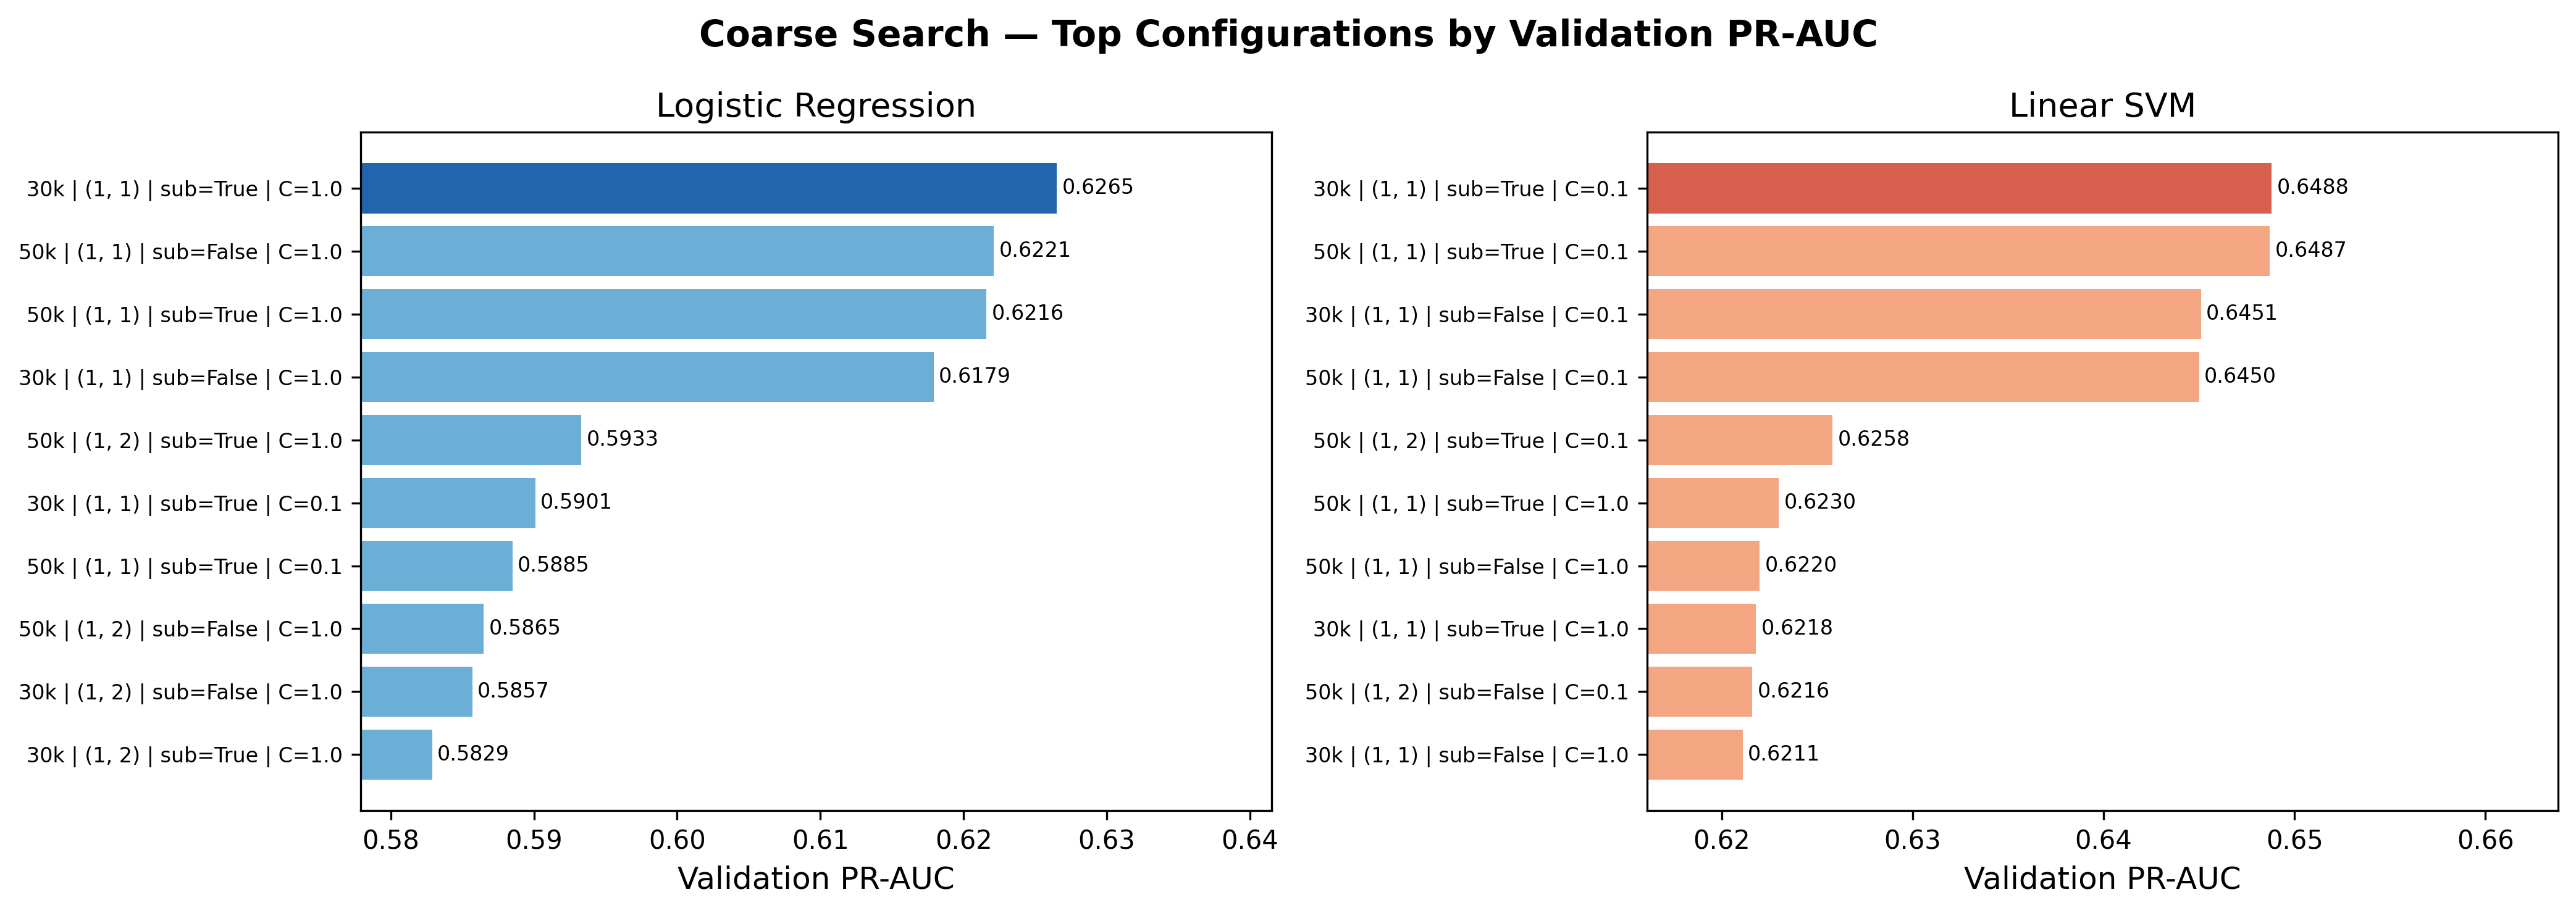

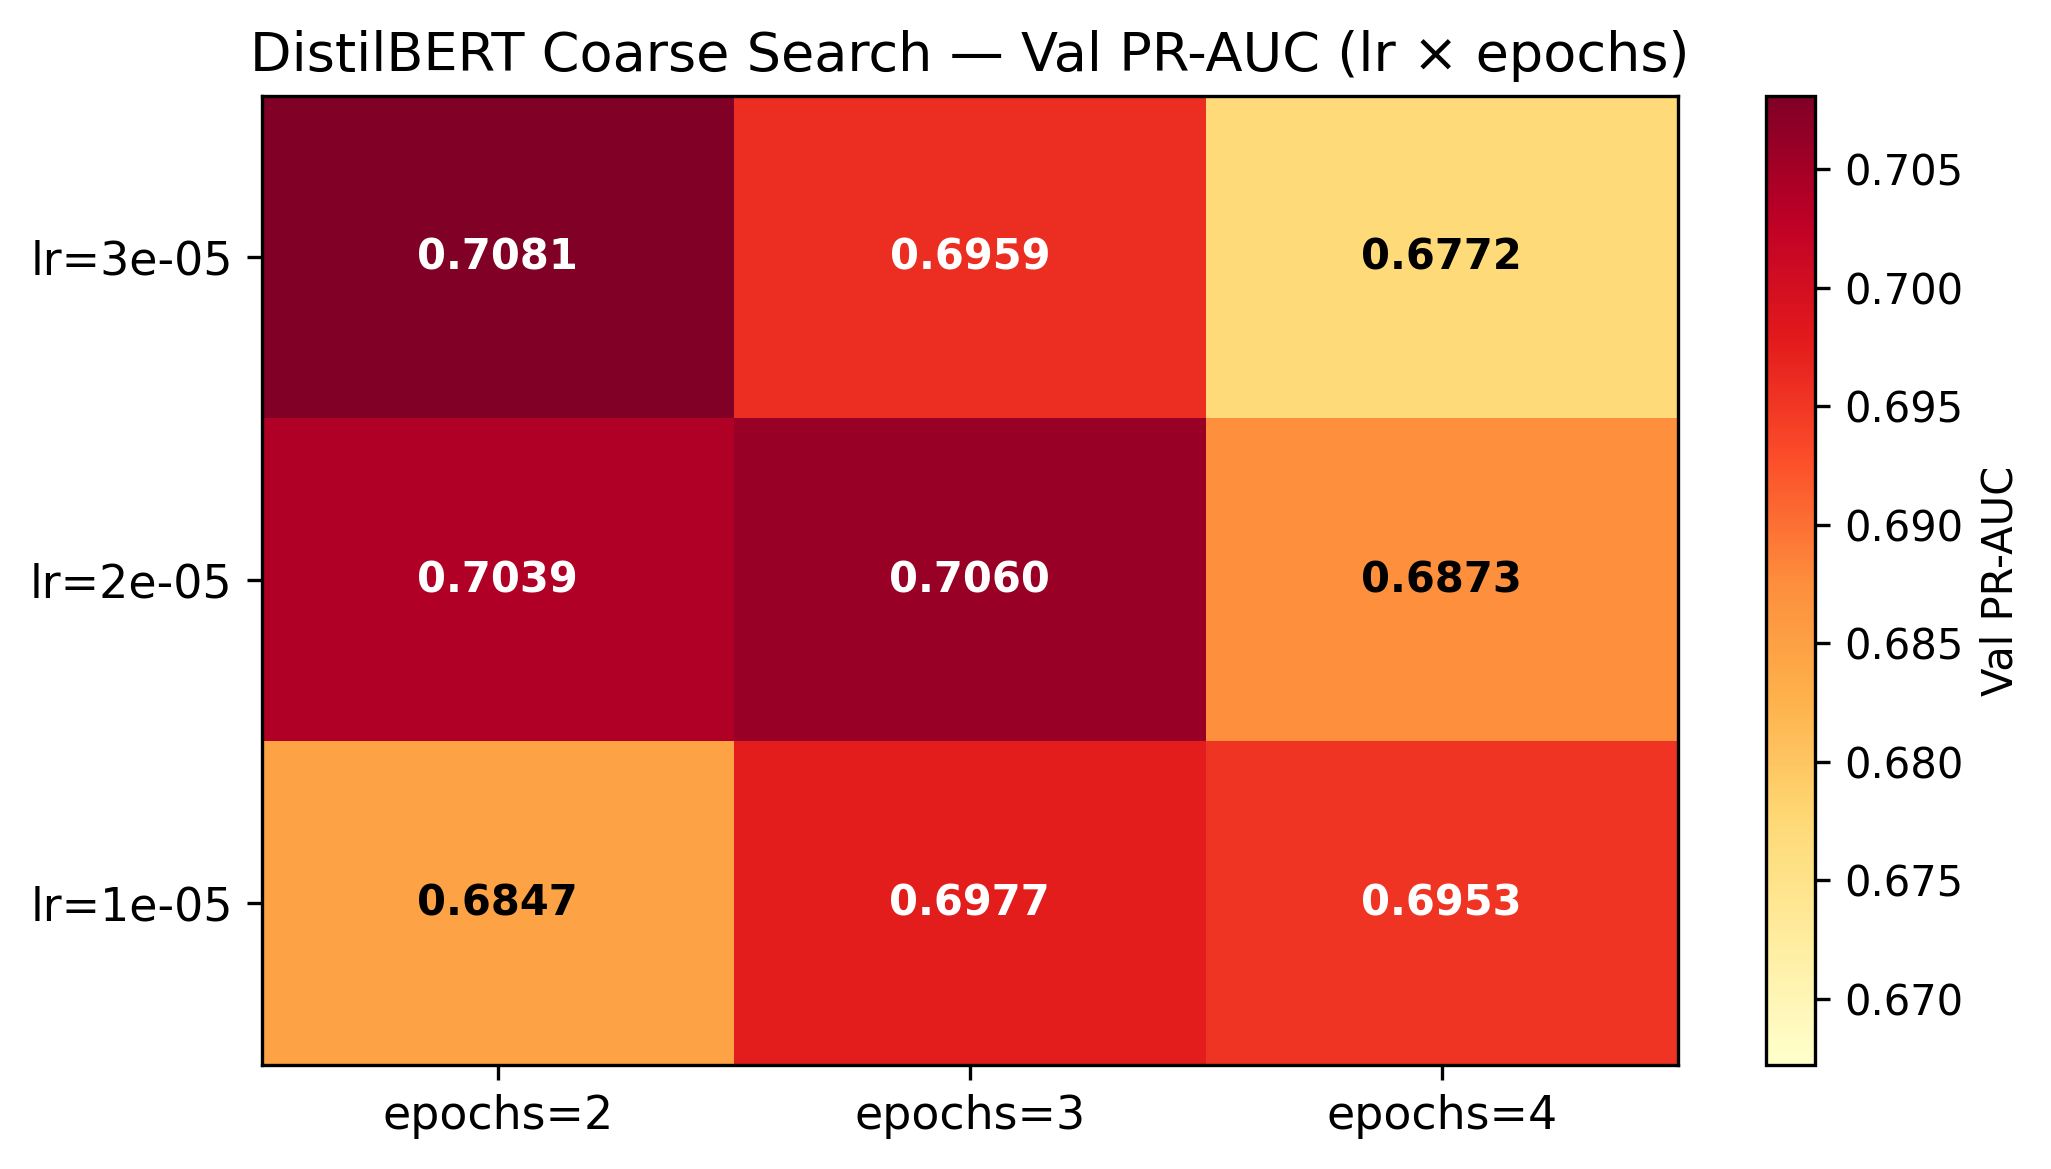

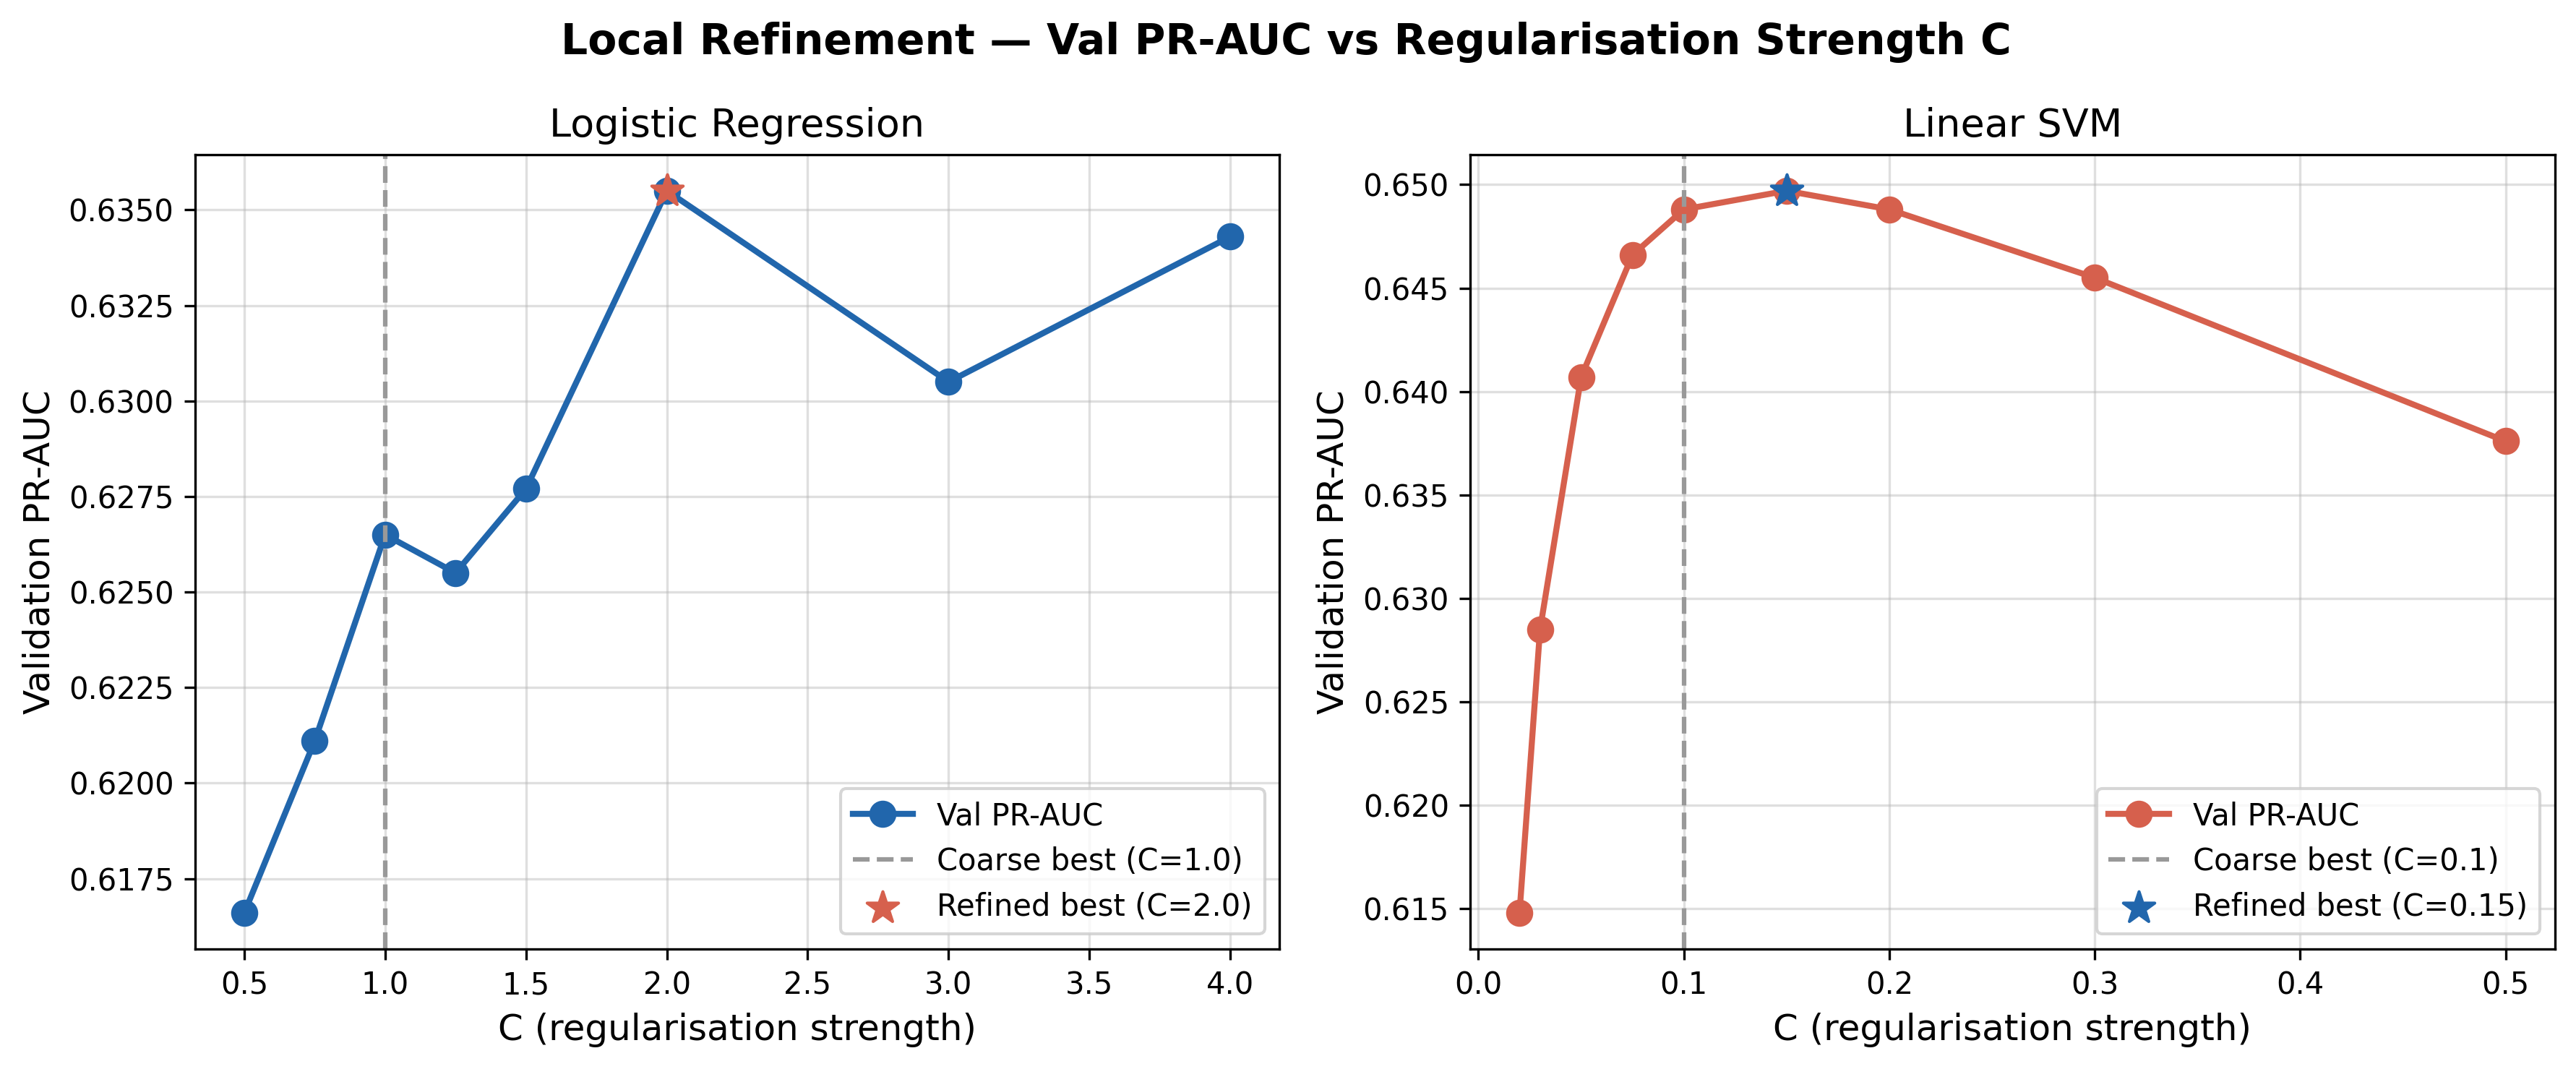

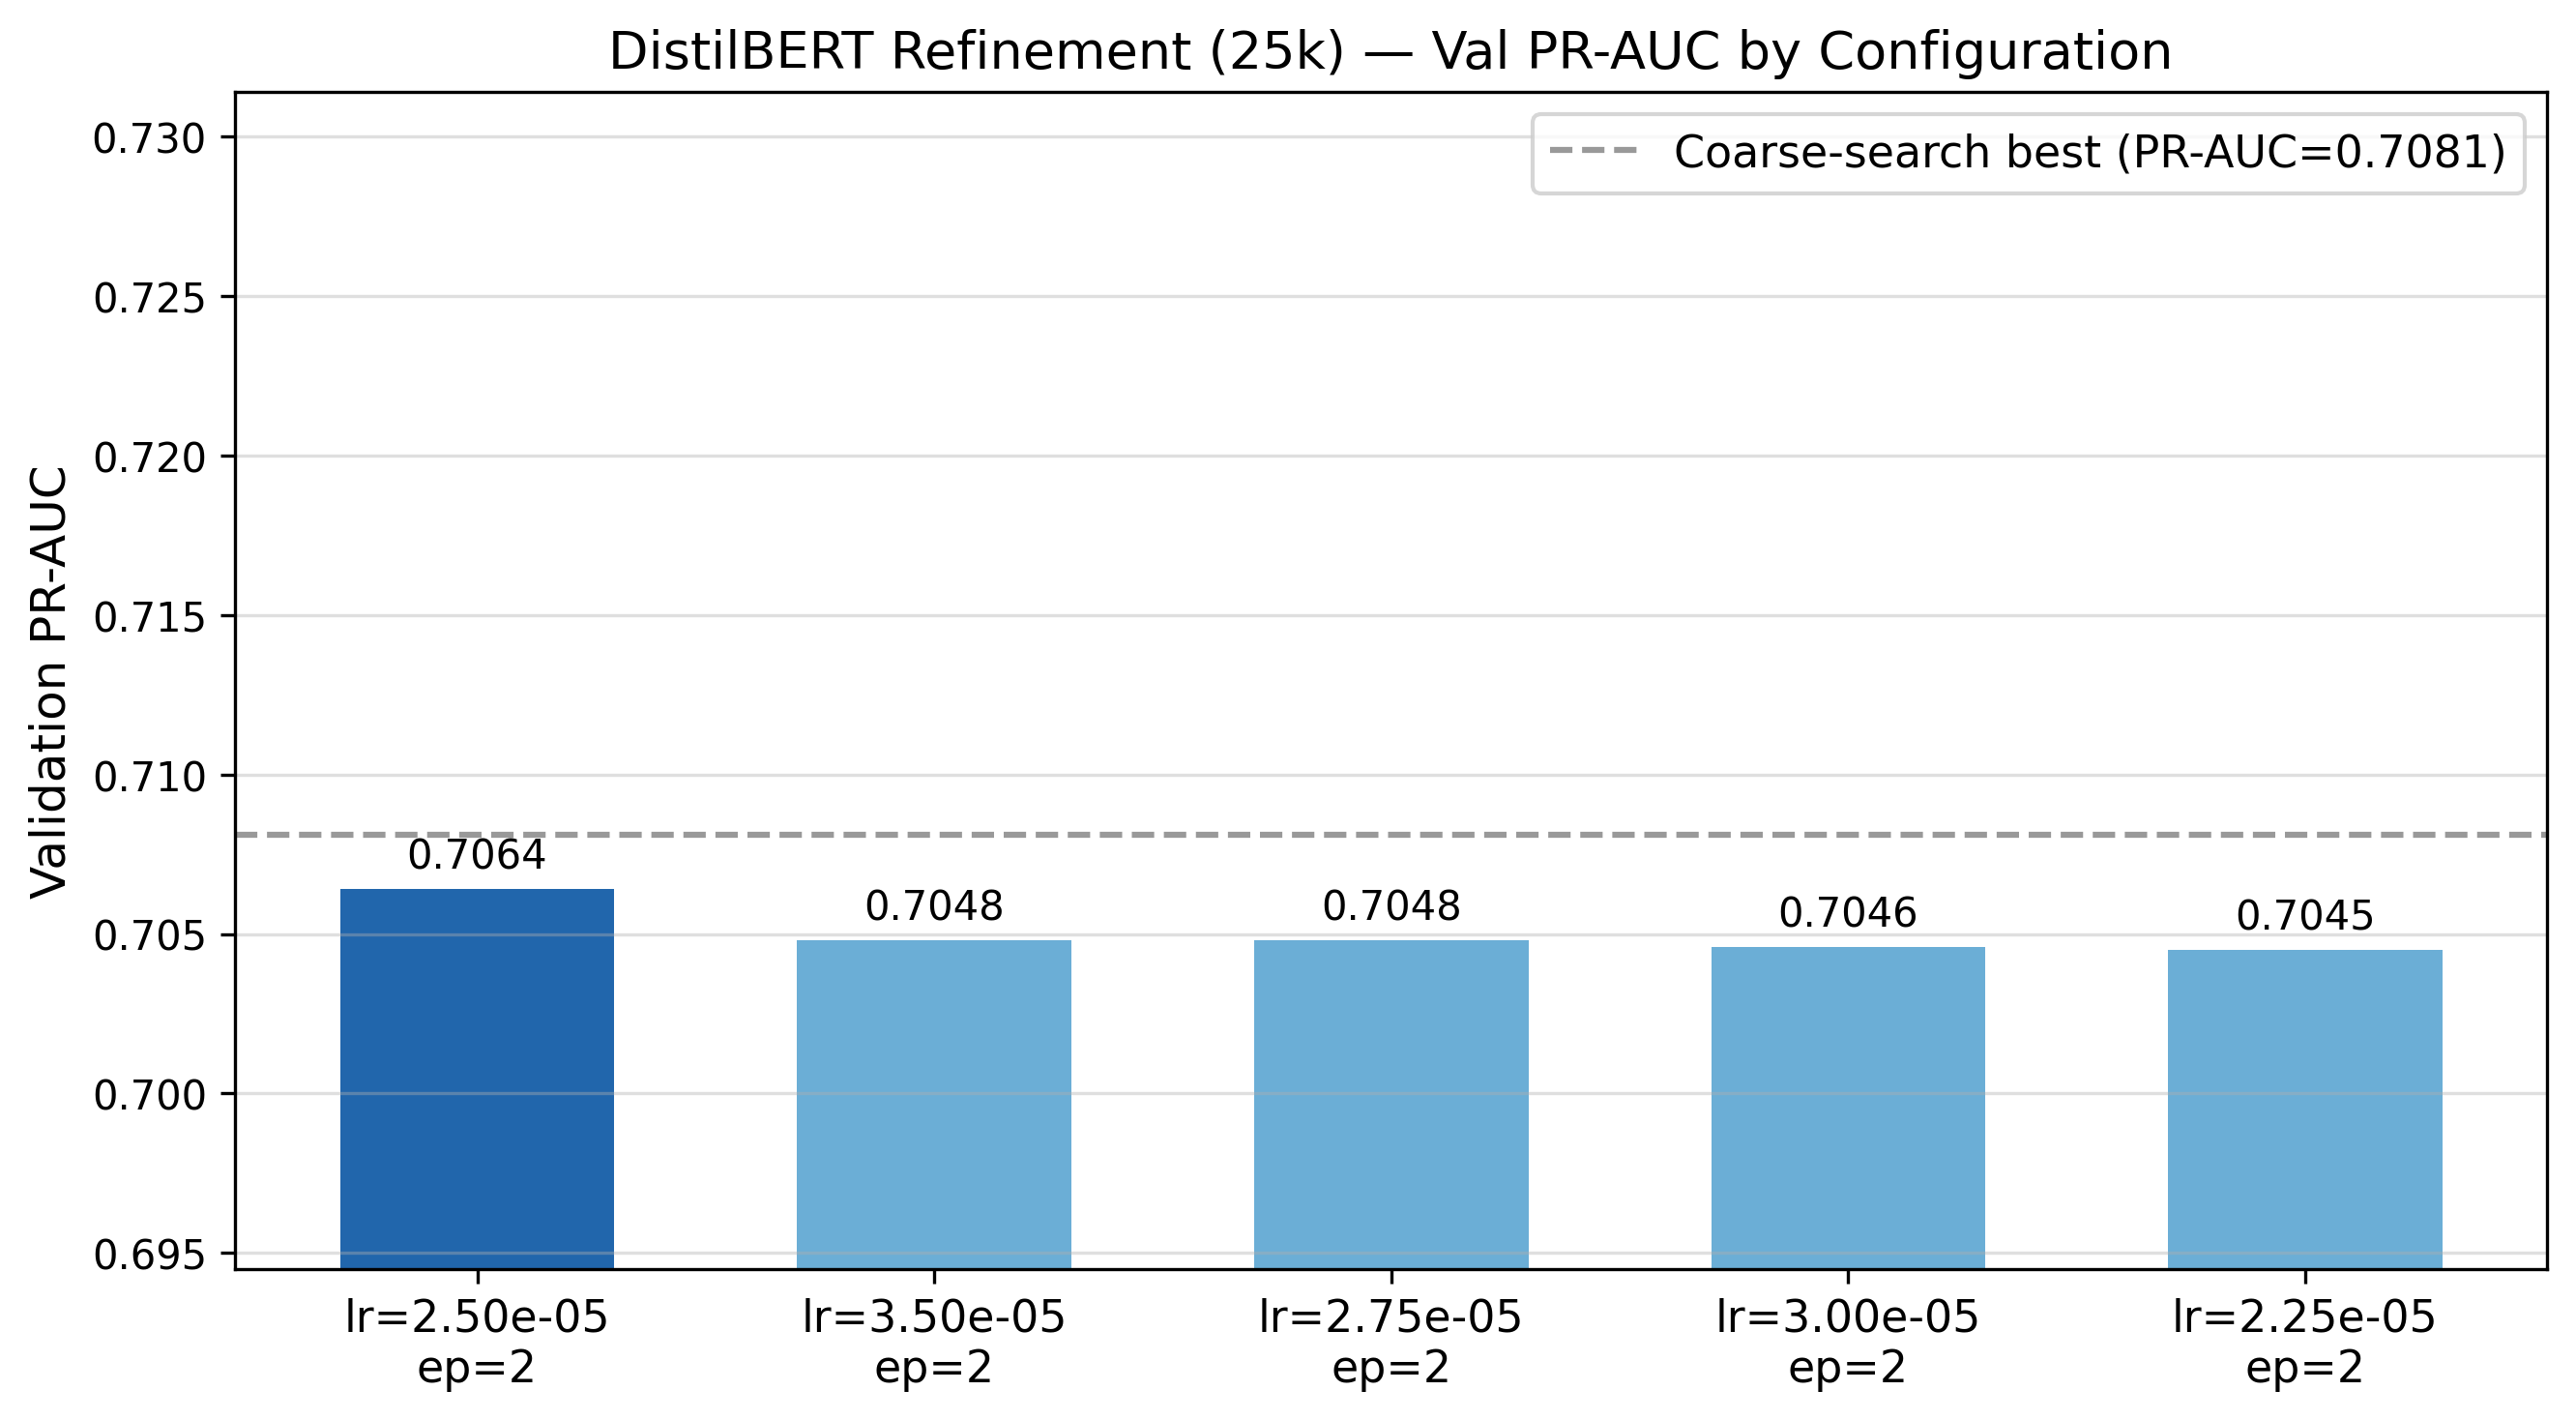

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ── Load all tuning CSVs from Drive (reconnect-safe) ─────────────────────────
lr_coarse_path    = os.path.join(CONFIG["tables_dir"], "lr_tuning_results.csv")
svm_coarse_path   = os.path.join(CONFIG["tables_dir"], "svm_tuning_results.csv")
bert_coarse_path  = os.path.join(CONFIG["tables_dir"], "distilbert_tuning_results.csv")
lr_refine_path    = os.path.join(CONFIG["tables_dir"], "lr_refinement_results.csv")
svm_refine_path   = os.path.join(CONFIG["tables_dir"], "svm_refinement_results.csv")
bert_refine_path  = os.path.join(CONFIG["tables_dir"], "distilbert_refinement_25k_runs.csv")

for p in [
    lr_coarse_path, svm_coarse_path, bert_coarse_path,
    lr_refine_path, svm_refine_path, bert_refine_path
]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"Missing tuning CSV: {p}\nRun the tuning and refinement cells before this cell."
        )

lr_coarse_df   = pd.read_csv(lr_coarse_path).sort_values("Val PR-AUC", ascending=False)
svm_coarse_df  = pd.read_csv(svm_coarse_path).sort_values("Val PR-AUC", ascending=False)
bert_coarse_df = pd.read_csv(bert_coarse_path).sort_values("Val PR-AUC", ascending=False)
lr_refine_df   = pd.read_csv(lr_refine_path).sort_values("Val PR-AUC", ascending=False)
svm_refine_df  = pd.read_csv(svm_refine_path)
bert_refine_df = pd.read_csv(bert_refine_path).sort_values("Val PR-AUC", ascending=False)

COARSE_LR_BEST_C  = 1.0
COARSE_SVM_BEST_C = 0.1
COARSE_BERT_PR    = 0.7081

saved_paths = []

# ── Figure 1: Classical Coarse Search Top Configs ─────────────────────────────
fig1, (ax1a, ax1b) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle("Coarse Search — Top Configurations by Validation PR-AUC", fontsize=14, fontweight="bold")

lr_top = lr_coarse_df.head(min(10, len(lr_coarse_df))).copy()
lr_top["Config"] = [
    f"{int(r.max_features/1000)}k | {r.ngram_range} | sub={r.sublinear_tf} | C={r.C}"
    for _, r in lr_top.iterrows()
]
colors_lr = ["#2166ac" if i == 0 else "#6baed6" for i in range(len(lr_top))]
bars_lr = ax1a.barh(range(len(lr_top)), lr_top["Val PR-AUC"], color=colors_lr)
ax1a.set_yticks(range(len(lr_top)))
ax1a.set_yticklabels(lr_top["Config"], fontsize=8)
ax1a.invert_yaxis()
ax1a.set_xlabel("Validation PR-AUC", fontsize=12)
ax1a.set_title("Logistic Regression", fontsize=13)
ax1a.bar_label(bars_lr, fmt="%.4f", fontsize=8, padding=2)
ax1a.set_xlim(lr_top["Val PR-AUC"].min() - 0.005, lr_top["Val PR-AUC"].max() + 0.015)

svm_top = svm_coarse_df.head(min(10, len(svm_coarse_df))).copy()
svm_top["Config"] = [
    f"{int(r.max_features/1000)}k | {r.ngram_range} | sub={r.sublinear_tf} | C={r.C}"
    for _, r in svm_top.iterrows()
]
colors_svm = ["#d6604d" if i == 0 else "#f4a582" for i in range(len(svm_top))]
bars_svm = ax1b.barh(range(len(svm_top)), svm_top["Val PR-AUC"], color=colors_svm)
ax1b.set_yticks(range(len(svm_top)))
ax1b.set_yticklabels(svm_top["Config"], fontsize=8)
ax1b.invert_yaxis()
ax1b.set_xlabel("Validation PR-AUC", fontsize=12)
ax1b.set_title("Linear SVM", fontsize=13)
ax1b.bar_label(bars_svm, fmt="%.4f", fontsize=8, padding=2)
ax1b.set_xlim(svm_top["Val PR-AUC"].min() - 0.005, svm_top["Val PR-AUC"].max() + 0.015)

fig1.tight_layout()
save_figure(fig1, "tuning_coarse_classical.png", CONFIG)
plt.close(fig1)
saved_paths.append(os.path.join(CONFIG["figures_dir"], "tuning_coarse_classical.png"))

# ── Figure 2: DistilBERT Coarse Heatmap ──────────────────────────────────────
bert_coarse_df["LR_str"] = bert_coarse_df["LR"].apply(lambda x: f"{float(x):.0e}")
try:
    pivot = bert_coarse_df.pivot_table(index="LR", columns="Epochs", values="Val PR-AUC", aggfunc="first")
except Exception:
    pivot = bert_coarse_df.pivot_table(index="LR_str", columns="Epochs", values="Val PR-AUC", aggfunc="first")
pivot = pivot.sort_index(ascending=False)

fig2, ax2 = plt.subplots(figsize=(7, 4))
im = ax2.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=pivot.values.min() - 0.01)
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels([f"epochs={c}" for c in pivot.columns], fontsize=11)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels([f"lr={r}" for r in pivot.index], fontsize=11)
ax2.set_title("DistilBERT Coarse Search — Val PR-AUC (lr × epochs)", fontsize=13)
plt.colorbar(im, ax=ax2, label="Val PR-AUC")

for row_i in range(len(pivot.index)):
    for col_j in range(len(pivot.columns)):
        val = pivot.values[row_i, col_j]
        if not np.isnan(val):
            ax2.text(
                col_j, row_i, f"{val:.4f}",
                ha="center", va="center",
                fontsize=10, fontweight="bold",
                color="white" if val > pivot.values.max() - 0.02 else "black"
            )

fig2.tight_layout()
save_figure(fig2, "tuning_coarse_bert_heatmap.png", CONFIG)
plt.close(fig2)
saved_paths.append(os.path.join(CONFIG["figures_dir"], "tuning_coarse_bert_heatmap.png"))

# ── Figure 3: Classical Local Refinement C-Sweep ─────────────────────────────
lr_refine_df_sorted  = lr_refine_df.sort_values("C")
svm_refine_df_sorted = svm_refine_df.sort_values("C")

fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle("Local Refinement — Val PR-AUC vs Regularisation Strength C", fontsize=14, fontweight="bold")

ax3a.plot(lr_refine_df_sorted["C"], lr_refine_df_sorted["Val PR-AUC"],
          marker="o", linewidth=2, color="#2166ac", markersize=8, label="Val PR-AUC")
ax3a.axvline(COARSE_LR_BEST_C, color="#999999", linestyle="--", linewidth=1.5,
             label=f"Coarse best (C={COARSE_LR_BEST_C})")
best_lr_r_c  = lr_refine_df.iloc[0]["C"]
best_lr_r_pr = lr_refine_df.iloc[0]["Val PR-AUC"]
ax3a.scatter([best_lr_r_c], [best_lr_r_pr], s=120, zorder=5, color="#d6604d",
             label=f"Refined best (C={best_lr_r_c})", marker="*")
ax3a.set_xlabel("C (regularisation strength)", fontsize=12)
ax3a.set_ylabel("Validation PR-AUC", fontsize=12)
ax3a.set_title("Logistic Regression", fontsize=13)
ax3a.legend(fontsize=10)
ax3a.grid(True, alpha=0.4)

ax3b.plot(svm_refine_df_sorted["C"], svm_refine_df_sorted["Val PR-AUC"],
          marker="o", linewidth=2, color="#d6604d", markersize=8, label="Val PR-AUC")
ax3b.axvline(COARSE_SVM_BEST_C, color="#999999", linestyle="--", linewidth=1.5,
             label=f"Coarse best (C={COARSE_SVM_BEST_C})")
best_svm_row = svm_refine_df.sort_values("Val PR-AUC", ascending=False).iloc[0]
ax3b.scatter([best_svm_row["C"]], [best_svm_row["Val PR-AUC"]], s=120, zorder=5, color="#2166ac",
             label=f"Refined best (C={best_svm_row['C']})", marker="*")
ax3b.set_xlabel("C (regularisation strength)", fontsize=12)
ax3b.set_ylabel("Validation PR-AUC", fontsize=12)
ax3b.set_title("Linear SVM", fontsize=13)
ax3b.legend(fontsize=10)
ax3b.grid(True, alpha=0.4)

fig3.tight_layout()
save_figure(fig3, "tuning_refinement_classical.png", CONFIG)
plt.close(fig3)
saved_paths.append(os.path.join(CONFIG["figures_dir"], "tuning_refinement_classical.png"))

# ── Figure 4: DistilBERT Refinement Bar Chart ────────────────────────────────
bert_refine_labels = [
    f"lr={float(r['LR']):.2e}\nep={int(r['Epochs'])}" for _, r in bert_refine_df.iterrows()
]
bar_colors = ["#2166ac" if i == 0 else "#6baed6" for i in range(len(bert_refine_df))]

fig4, ax4 = plt.subplots(figsize=(9, 5))
bars4 = ax4.bar(range(len(bert_refine_df)), bert_refine_df["Val PR-AUC"], color=bar_colors, width=0.6)
ax4.axhline(COARSE_BERT_PR, color="#999999", linestyle="--", linewidth=1.5,
            label=f"Coarse-search best (PR-AUC={COARSE_BERT_PR:.4f})")
ax4.set_xticks(range(len(bert_refine_df)))
ax4.set_xticklabels(bert_refine_labels, fontsize=11)
ax4.set_ylabel("Validation PR-AUC", fontsize=12)
ax4.set_title("DistilBERT Refinement (25k) — Val PR-AUC by Configuration", fontsize=13)
ax4.bar_label(bars4, fmt="%.4f", fontsize=10, padding=3)
ax4.set_ylim(bert_refine_df["Val PR-AUC"].min() - 0.01, bert_refine_df["Val PR-AUC"].max() + 0.025)
ax4.legend(fontsize=11)
ax4.grid(True, axis="y", alpha=0.4)

fig4.tight_layout()
save_figure(fig4, "tuning_refinement_bert.png", CONFIG)
plt.close(fig4)
saved_paths.append(os.path.join(CONFIG["figures_dir"], "tuning_refinement_bert.png"))

print("Saved figures:")
for p in saved_paths:
    print("-", p)

print("\nDisplaying saved PNGs...\n")
for p in saved_paths:
    display(Image(filename=p))

### 11.5 — Final Frozen Hyperparameter Summary

All configurations are now frozen following both the coarse search (Stage 1) and local refinement (Stage 2). The table below records the **final selected configuration** for each model family — these are the post-refinement settings carried into all nine final training runs (Section 12). The `best_lr_model_config`, `best_svm_model_config`, and `best_distilbert_config` variables were updated in place during Sections 11.1b–11.3b.

In [ ]:
best_hp_rows = [
    {
        "Model":       "Logistic Regression",
        "max_features": best_lr_tfidf_config["max_features"],
        "ngram_range":  str(best_lr_tfidf_config["ngram_range"]),
        "sublinear_tf": best_lr_tfidf_config["sublinear_tf"],
        "C":            best_lr_model_config["C"],
        "LR":           "—",
        "Epochs":       "—",
        "Val PR-AUC":   best_lr_row["Val PR-AUC"],
        "Val Macro-F1": best_lr_row["Val Macro-F1"],
    },
    {
        "Model":       "Linear SVM",
        "max_features": best_svm_tfidf_config["max_features"],
        "ngram_range":  str(best_svm_tfidf_config["ngram_range"]),
        "sublinear_tf": best_svm_tfidf_config["sublinear_tf"],
        "C":            best_svm_model_config["C"],
        "LR":           "—",
        "Epochs":       "—",
        "Val PR-AUC":   best_svm_row["Val PR-AUC"],
        "Val Macro-F1": best_svm_row["Val Macro-F1"],
    },
    {
        "Model":       "DistilBERT",
        "max_features": "—",
        "ngram_range":  "—",
        "sublinear_tf": "—",
        "C":            "—",
        "LR":           best_distilbert_config["lr"],
        "Epochs":       best_distilbert_config["epochs"],
        "Val PR-AUC":   best_bert_row["Val PR-AUC"],
        "Val Macro-F1": best_bert_row["Val Macro-F1"],
    },
]

best_hp_df = pd.DataFrame(best_hp_rows)
display(best_hp_df)
best_hp_df.to_csv(os.path.join(CONFIG["tables_dir"], "best_hyperparameters.csv"), index=False)
print("Saved: tables/best_hyperparameters.csv")
print("\nAll configurations frozen. Proceeding to final training runs.")

,Model,max_features,ngram_range,sublinear_tf,C,LR,Epochs,Val PR-AUC,Val Macro-F1
0,Logistic Regression,30000,"(1, 1)",True,2.0,—,—,0.6355,0.7746
1,Linear SVM,30000,"(1, 1)",True,0.15,—,—,0.6497,0.7809
2,DistilBERT,—,—,—,—,0.00002,2,0.7382,0.8173


Saved: tables/best_hyperparameters.csv

All configurations frozen. Proceeding to final training runs.


# 12 Check Point - Two Recovery Cells

In [ ]:
# -*- coding: utf-8 -*-

# === Runtime Recovery Cell for ToxicityThesis (CPU/GPU-safe, DistilBERT-ready) ===

# 1) Drive mount
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# 2) Core imports
import os
import gc
import io
import json
import time
import math
import random
import warnings
import contextlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from tqdm.auto import tqdm

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    f1_score,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset as HFDataset
from transformers import (
    EvalPrediction,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from transformers.utils import logging as hf_logging

# Keep HF logs quiet
hf_logging.set_verbosity_error()

# 3) Project paths
BASE_DIR = "/content/drive/MyDrive/ToxicityThesis"
SPLITS_DIR = os.path.join(BASE_DIR, "data", "splits")

SUBDIRS = [
    "data/raw",
    "data/processed",
    "data/splits",
    "models",
    "predictions",
    "metrics",
    "figures",
    "tables",
    "logs",
]
for subdir in SUBDIRS:
    os.makedirs(os.path.join(BASE_DIR, subdir), exist_ok=True)

# 4) Config
CONFIG = {
    "dataset_name": "google/civil_comments",
    "text_col": "text",
    "score_col": "toxicity",
    "label_col": "label",

    "toxicity_threshold": 0.5,

    "train_sizes": [25_000, 100_000, 400_000],
    "val_size": 20_000,

    "seed": 42,

    "tfidf_max_features": 50_000,
    "tfidf_ngram_range": (1, 2),
    "tfidf_sublinear_tf": True,

    "lr_C": 1.0,
    "svm_C": 1.0,

    "distilbert_model_name": "distilbert-base-uncased",
    "distilbert_max_len": 128,
    "distilbert_lr": 2e-5,
    "distilbert_epochs": 2,
    "distilbert_batch_size": 32,
    "distilbert_warmup_ratio": 0.1,

    "base_dir": BASE_DIR,
    "processed_dir": os.path.join(BASE_DIR, "data/processed"),
    "splits_dir": os.path.join(BASE_DIR, "data/splits"),
    "models_dir": os.path.join(BASE_DIR, "models"),
    "predictions_dir": os.path.join(BASE_DIR, "predictions"),
    "metrics_dir": os.path.join(BASE_DIR, "metrics"),
    "figures_dir": os.path.join(BASE_DIR, "figures"),
    "tables_dir": os.path.join(BASE_DIR, "tables"),
    "logs_dir": os.path.join(BASE_DIR, "logs"),
}

TEXT_COL = CONFIG["text_col"]
SCORE_COL = CONFIG["score_col"]
LABEL_COL = CONFIG["label_col"]
THRESHOLD = CONFIG["toxicity_threshold"]
SEED = CONFIG["seed"]

# 5) Seed + device
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Mixed precision flags for DistilBERT runs
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

# 6) Load fixed splits from Drive
required_files = {
    "train_25k":  os.path.join(SPLITS_DIR, "train_25k.parquet"),
    "train_100k": os.path.join(SPLITS_DIR, "train_100k.parquet"),
    "train_400k": os.path.join(SPLITS_DIR, "train_400k.parquet"),
    "val_20k":    os.path.join(SPLITS_DIR, "val_20k.parquet"),
    "test_df":    os.path.join(SPLITS_DIR, "test.parquet"),
}

missing = [name for name, path in required_files.items() if not os.path.exists(path)]
if missing:
    raise FileNotFoundError(
        f"Missing split files: {missing}\nExpected under: {SPLITS_DIR}"
    )

train_25k  = pd.read_parquet(required_files["train_25k"])
train_100k = pd.read_parquet(required_files["train_100k"])
train_400k = pd.read_parquet(required_files["train_400k"])
val_20k    = pd.read_parquet(required_files["val_20k"])
test_df    = pd.read_parquet(required_files["test_df"])

# 7) Common arrays
y_val = val_20k[LABEL_COL].values
y_test = test_df[LABEL_COL].values
noskill_pr_auc = y_val.mean()

# 8) Helper functions
def compute_text_length(series):
    return series.str.len()

def compute_metrics(y_true, y_scores, threshold=None):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)

    if y_true.shape[0] != y_scores.shape[0]:
        raise ValueError("y_true and y_scores must have the same length.")

    unique_classes = np.unique(y_true)

    if len(unique_classes) < 2:
        pr_auc = np.nan
    else:
        pr_auc = average_precision_score(y_true, y_scores)

    if threshold is None:
        if len(unique_classes) < 2:
            threshold = float(np.median(y_scores))
        else:
            _, _, pr_thresholds = precision_recall_curve(y_true, y_scores)

            if len(pr_thresholds) == 0:
                threshold = float(np.median(y_scores))
            else:
                best_f1 = -1.0
                best_thresh = float(pr_thresholds[len(pr_thresholds) // 2])

                for t in pr_thresholds:
                    preds = (y_scores >= t).astype(int)
                    f1 = f1_score(y_true, preds, average="macro", zero_division=0)
                    if f1 > best_f1:
                        best_f1 = f1
                        best_thresh = float(t)

                threshold = best_thresh

    y_pred = (y_scores >= threshold).astype(int)

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        output_dict=True,
        zero_division=0,
    )

    return {
        "pr_auc": float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        "threshold": float(threshold),
        "macro_f1": report["macro avg"]["f1-score"],
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
    }

def save_predictions(y_true, y_scores, y_pred, split_name, run_id, config):
    df = pd.DataFrame({
        "y_true": np.asarray(y_true),
        "y_scores": np.asarray(y_scores, dtype=float),
        "y_pred": np.asarray(y_pred),
    })
    path = os.path.join(config["predictions_dir"], f"{run_id}_{split_name}.parquet")
    df.to_parquet(path, index=False)

def save_metrics(metrics_dict, run_id, config):
    json_path = os.path.join(config["metrics_dir"], f"{run_id}_metrics.json")
    with open(json_path, "w") as f:
        json.dump(metrics_dict, f, indent=2)

    log_path = os.path.join(config["logs_dir"], "all_metrics_log.csv")
    row = {"run_id": run_id, **metrics_dict}
    row_df = pd.DataFrame([row])

    if os.path.exists(log_path):
        row_df.to_csv(log_path, mode="a", header=False, index=False)
    else:
        row_df.to_csv(log_path, mode="w", header=True, index=False)

def plot_pr_curve(y_true, y_scores, label, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ax.plot(recall, precision, label=label, linewidth=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    return ax

def save_figure(fig, filename, config):
    path = os.path.join(config["figures_dir"], filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)

def track_time(start_time):
    return time.time() - start_time

def extract_error_samples(y_true, y_scores, y_pred, texts, threshold, n_each=10):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    y_pred = np.asarray(y_pred)
    texts = np.asarray(texts)

    score_range = y_scores.max() - y_scores.min()
    epsilon = 0.1 * score_range

    fp_mask = (y_pred == 1) & (y_true == 0)
    fn_mask = (y_pred == 0) & (y_true == 1)
    bord_mask = np.abs(y_scores - threshold) < epsilon

    def _sample(mask):
        idx = np.where(mask)[0]
        if len(idx) > n_each:
            idx = np.random.choice(idx, n_each, replace=False)
        return pd.DataFrame({
            "text": texts[idx],
            "y_true": y_true[idx],
            "y_scores": y_scores[idx],
            "y_pred": y_pred[idx],
        })

    return _sample(fp_mask), _sample(fn_mask), _sample(bord_mask)

def length_slice_eval(y_true, y_scores, texts, threshold, bins):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    lengths = np.array([len(t) for t in texts])

    rows = []
    for bin_label, (lo, hi) in bins.items():
        mask = (lengths >= lo) & (lengths < hi)
        if mask.sum() == 0:
            continue
        m = compute_metrics(y_true[mask], y_scores[mask], threshold=threshold)
        rows.append({
            "bin": bin_label,
            "n_samples": int(mask.sum()),
            "n_positive": int(y_true[mask].sum()),
            "pr_auc": m["pr_auc"],
            "macro_f1": m["macro_f1"],
        })
    return pd.DataFrame(rows)

def tokenise_df(df, tokenizer, config):
    texts = df[config["text_col"]].tolist()
    labels = df[config["label_col"]].tolist()
    enc = tokenizer(
        texts,
        max_length=config["distilbert_max_len"],
        padding="max_length",
        truncation=True,
    )
    return HFDataset.from_dict({
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": labels,
    })

def compute_metrics_for_trainer(eval_pred: EvalPrediction) -> dict:
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    exp_l = np.exp(logits - logits.max(axis=1, keepdims=True))
    pos_probs = (exp_l / exp_l.sum(axis=1, keepdims=True))[:, 1]
    return {"pr_auc": float(average_precision_score(labels, pos_probs))}

# DistilBERT helpers
tokenizer = AutoTokenizer.from_pretrained(CONFIG["distilbert_model_name"])

class WeightedTrainer(Trainer):
    def __init__(self, class_weights_tensor, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = torch.nn.CrossEntropyLoss(
            weight=self.class_weights_tensor.to(logits.device)
        )(logits, labels)
        return (loss, outputs) if return_outputs else loss

def load_distilbert_quietly(model_name, num_labels=2):
    buf_out = io.StringIO()
    buf_err = io.StringIO()
    with contextlib.redirect_stdout(buf_out), contextlib.redirect_stderr(buf_err):
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=num_labels,
        )
    return model

# 9) Restore best configs from JSONs if present
def _safe_load_json(path):
    if os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return None

lr_best_json   = _safe_load_json(os.path.join(CONFIG["tables_dir"], "lr_best_config.json"))
svm_best_json  = _safe_load_json(os.path.join(CONFIG["tables_dir"], "svm_best_config.json"))
bert_best_json = _safe_load_json(os.path.join(CONFIG["tables_dir"], "distilbert_best_config.json"))

best_lr_tfidf_config = {
    "max_features": 30000,
    "ngram_range": (1, 1),
    "sublinear_tf": True,
}
best_lr_model_config = {
    "C": 1.0,
    "max_iter": 1000,
    "solver": "saga",
    "class_weight": "balanced",
    "random_state": SEED,
}
best_lr_row = pd.Series({"Val PR-AUC": np.nan, "Val Macro-F1": np.nan, "Threshold": np.nan})

if lr_best_json is not None:
    best_lr_tfidf_config = {
        "max_features": int(lr_best_json["best_lr_tfidf_config"]["max_features"]),
        "ngram_range": tuple(lr_best_json["best_lr_tfidf_config"]["ngram_range"]),
        "sublinear_tf": bool(lr_best_json["best_lr_tfidf_config"]["sublinear_tf"]),
    }
    best_lr_model_config = {
        "C": float(lr_best_json["best_lr_model_config"]["C"]),
        "max_iter": int(lr_best_json["best_lr_model_config"]["max_iter"]),
        "solver": lr_best_json["best_lr_model_config"]["solver"],
        "class_weight": lr_best_json["best_lr_model_config"]["class_weight"],
        "random_state": int(lr_best_json["best_lr_model_config"]["random_state"]),
    }
    best_lr_row = pd.Series({
        "Val PR-AUC": float(lr_best_json["best_val_pr_auc"]),
        "Val Macro-F1": float(lr_best_json["best_val_macro_f1"]),
        "Threshold": float(lr_best_json["best_threshold"]),
    })

best_svm_tfidf_config = {
    "max_features": 30000,
    "ngram_range": (1, 1),
    "sublinear_tf": True,
}
best_svm_model_config = {
    "C": 0.1,
    "max_iter": 3000,
    "class_weight": "balanced",
    "random_state": SEED,
}
best_svm_row = pd.Series({"Val PR-AUC": np.nan, "Val Macro-F1": np.nan, "Threshold": np.nan})

if svm_best_json is not None:
    best_svm_tfidf_config = {
        "max_features": int(svm_best_json["best_svm_tfidf_config"]["max_features"]),
        "ngram_range": tuple(svm_best_json["best_svm_tfidf_config"]["ngram_range"]),
        "sublinear_tf": bool(svm_best_json["best_svm_tfidf_config"]["sublinear_tf"]),
    }
    best_svm_model_config = {
        "C": float(svm_best_json["best_svm_model_config"]["C"]),
        "max_iter": int(svm_best_json["best_svm_model_config"]["max_iter"]),
        "class_weight": svm_best_json["best_svm_model_config"]["class_weight"],
        "random_state": int(svm_best_json["best_svm_model_config"]["random_state"]),
    }
    best_svm_row = pd.Series({
        "Val PR-AUC": float(svm_best_json["best_val_pr_auc"]),
        "Val Macro-F1": float(svm_best_json["best_val_macro_f1"]),
        "Threshold": float(svm_best_json["best_threshold"]),
    })

best_distilbert_config = {
    "lr": float(CONFIG["distilbert_lr"]),
    "epochs": int(CONFIG["distilbert_epochs"]),
}
best_bert_row = pd.Series({"Val PR-AUC": np.nan, "Val Macro-F1": np.nan, "Threshold": np.nan})

if bert_best_json is not None and "best_distilbert_config" in bert_best_json:
    best_distilbert_config = {
        "lr": float(bert_best_json["best_distilbert_config"]["lr"]),
        "epochs": int(bert_best_json["best_distilbert_config"]["epochs"]),
    }
    best_bert_row = pd.Series({
        "Val PR-AUC": float(bert_best_json["best_val_pr_auc"]),
        "Val Macro-F1": float(bert_best_json["best_val_macro_f1"]),
        "Threshold": float(bert_best_json["best_threshold"]),
    })

# 10) Quick smoke test
_y_true = np.array([0, 0, 1, 1, 0, 1, 0, 1])
_y_scores = np.array([0.1, 0.2, 0.8, 0.9, 0.4, 0.7, 0.3, 0.6])
_result = compute_metrics(_y_true, _y_scores)

assert _result["pr_auc"] > 0.5
assert np.isfinite(_result["threshold"])
assert 0.0 <= _result["macro_f1"] <= 1.0

# 11) Validate DistilBERT-ready symbols explicitly
required_symbols = [
    "CONFIG",
    "SEED",
    "train_25k",
    "train_100k",
    "val_20k",
    "y_val",
    "tokenizer",
    "tokenise_df",
    "WeightedTrainer",
    "load_distilbert_quietly",
    "best_distilbert_config",
    "best_bert_row",
    "use_bf16",
    "use_fp16",
]

missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise RuntimeError(f"Recovery cell incomplete. Missing symbols: {missing_symbols}")

# 12) Status print
print("Runtime recovery complete.")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"train_25k : {train_25k.shape}")
print(f"train_100k: {train_100k.shape}")
print(f"train_400k: {train_400k.shape}")
print(f"val_20k   : {val_20k.shape}")
print(f"test_df   : {test_df.shape}")
print(f"TEXT_COL  : {TEXT_COL}")
print(f"LABEL_COL : {LABEL_COL}")
print(f"SCORE_COL : {SCORE_COL}")
print(f"No-skill PR-AUC (val prevalence): {noskill_pr_auc:.4f}")
print(f"Tokenizer restored: {CONFIG['distilbert_model_name']}")
print(f"LR best restored: {best_lr_tfidf_config} | C={best_lr_model_config['C']}")
print(f"SVM best restored: {best_svm_tfidf_config} | C={best_svm_model_config['C']}")
print(f"DistilBERT best restored: {best_distilbert_config}")
print(f"Mixed precision: bf16={use_bf16}, fp16={use_fp16}")
print("DistilBERT helpers ready: tokenise_df, WeightedTrainer, load_distilbert_quietly")

Mounted at /content/drive


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Runtime recovery complete.
Device: cpu
train_25k : (25000, 3)
train_100k: (100000, 3)
train_400k: (400000, 3)
val_20k   : (20000, 3)
test_df   : (97320, 3)
TEXT_COL  : text
LABEL_COL : label
SCORE_COL : toxicity
No-skill PR-AUC (val prevalence): 0.0788
Tokenizer restored: distilbert-base-uncased
LR best restored: {'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} | C=2.0
SVM best restored: {'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} | C=0.15
DistilBERT best restored: {'lr': 2e-05, 'epochs': 2}
Mixed precision: bf16=False, fp16=False
DistilBERT helpers ready: tokenise_df, WeightedTrainer, load_distilbert_quietly


In [ ]:
import os
import json
import pandas as pd

# Paths
lr_json_path = os.path.join(CONFIG["tables_dir"], "lr_best_config.json")
svm_json_path = os.path.join(CONFIG["tables_dir"], "svm_best_config.json")
bert_json_path = os.path.join(CONFIG["tables_dir"], "distilbert_best_config.json")

lr_csv_path = os.path.join(CONFIG["tables_dir"], "lr_tuning_results.csv")
svm_csv_path = os.path.join(CONFIG["tables_dir"], "svm_tuning_results.csv")
bert_csv_path = os.path.join(CONFIG["tables_dir"], "distilbert_tuning_results.csv")

# Existence checks
required_paths = [
    lr_json_path, svm_json_path, bert_json_path,
    lr_csv_path, svm_csv_path, bert_csv_path
]
missing = [p for p in required_paths if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f"Missing tuning artifact(s): {missing}")

# Load CSV tables
lr_tuning_df = pd.read_csv(lr_csv_path)
svm_tuning_df = pd.read_csv(svm_csv_path)
bert_tuning_df = pd.read_csv(bert_csv_path)

# Load best-config JSONs
with open(lr_json_path, "r") as f:
    lr_best_payload = json.load(f)

with open(svm_json_path, "r") as f:
    svm_best_payload = json.load(f)

with open(bert_json_path, "r") as f:
    bert_best_payload = json.load(f)

# Rebuild best config variables exactly as later cells expect
best_lr_tfidf_config = {
    "max_features": int(lr_best_payload["best_lr_tfidf_config"]["max_features"]),
    "ngram_range": tuple(lr_best_payload["best_lr_tfidf_config"]["ngram_range"]),
    "sublinear_tf": bool(lr_best_payload["best_lr_tfidf_config"]["sublinear_tf"]),
}
best_lr_model_config = {
    "C": float(lr_best_payload["best_lr_model_config"]["C"]),
    "max_iter": int(lr_best_payload["best_lr_model_config"]["max_iter"]),
    "solver": lr_best_payload["best_lr_model_config"]["solver"],
    "class_weight": lr_best_payload["best_lr_model_config"]["class_weight"],
    "random_state": int(lr_best_payload["best_lr_model_config"]["random_state"]),
}
best_lr_row = pd.Series({
    "Val PR-AUC": float(lr_best_payload["best_val_pr_auc"]),
    "Val Macro-F1": float(lr_best_payload["best_val_macro_f1"]),
    "Threshold": float(lr_best_payload["best_threshold"]),
})

best_svm_tfidf_config = {
    "max_features": int(svm_best_payload["best_svm_tfidf_config"]["max_features"]),
    "ngram_range": tuple(svm_best_payload["best_svm_tfidf_config"]["ngram_range"]),
    "sublinear_tf": bool(svm_best_payload["best_svm_tfidf_config"]["sublinear_tf"]),
}
best_svm_model_config = {
    "C": float(svm_best_payload["best_svm_model_config"]["C"]),
    "max_iter": int(svm_best_payload["best_svm_model_config"]["max_iter"]),
    "class_weight": svm_best_payload["best_svm_model_config"]["class_weight"],
    "random_state": int(svm_best_payload["best_svm_model_config"]["random_state"]),
}
best_svm_row = pd.Series({
    "Val PR-AUC": float(svm_best_payload["best_val_pr_auc"]),
    "Val Macro-F1": float(svm_best_payload["best_val_macro_f1"]),
    "Threshold": float(svm_best_payload["best_threshold"]),
})

best_distilbert_config = {
    "lr": float(bert_best_payload["best_distilbert_config"]["lr"]),
    "epochs": int(bert_best_payload["best_distilbert_config"]["epochs"]),
}
best_bert_row = pd.Series({
    "Val PR-AUC": float(bert_best_payload["best_val_pr_auc"]),
    "Val Macro-F1": float(bert_best_payload["best_val_macro_f1"]),
    "Threshold": float(bert_best_payload["best_threshold"]),
})

print("Best tuning artifacts restored successfully.")
print("LR best config       :", best_lr_tfidf_config, best_lr_model_config)
print("SVM best config      :", best_svm_tfidf_config, best_svm_model_config)
print("DistilBERT best config:", best_distilbert_config)

Best tuning artifacts restored successfully.
LR best config       : {'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} {'C': 2.0, 'max_iter': 1000, 'solver': 'saga', 'class_weight': 'balanced', 'random_state': 42}
SVM best config      : {'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True} {'C': 0.15, 'max_iter': 3000, 'class_weight': 'balanced', 'random_state': 42}
DistilBERT best config: {'lr': 2e-05, 'epochs': 2}


## Section 12 — Final Training Runs

Hyperparameter selection is now complete. The final configurations used in this section are the frozen post-refinement settings established in Section 11.5. No further tuning is performed here. The purpose of Section 12 is to execute the final model runs at the three predefined training sizes and to generate the reusable artefacts required for the remaining results chapters.

This section conducts nine final runs in total, corresponding to three model families evaluated at three training sizes (`25k`, `100k`, and `400k`). For each run, the model is trained on its designated training subset, evaluated on the validation set for threshold selection, and then evaluated once on the test set for final reporting.

The evaluation protocol remains fixed throughout. Validation PR-AUC is used as the principal performance measure, while Macro-F1 is reported as a secondary metric. Threshold selection is performed on validation predictions only via `compute_metrics()`, and the selected threshold is then applied unchanged to the test predictions. The test set is therefore used strictly for final evaluation and never for configuration choice.

All artefacts are saved immediately after each run. These include the trained model object, validation and test prediction files, and the corresponding metrics file. This ensures that the later results sections can be built entirely from saved outputs without re-running the models.

### 12.1 — Final Logistic Regression Runs

This subsection executes the three final Logistic Regression runs on `train_25k`, `train_100k`, and `train_400k` using the frozen configuration selected in Section 11.5. No hyperparameter search is performed here; the objective is to evaluate the final Logistic Regression specification consistently across the three training scales.

For each run, a new `TfidfVectorizer` is fitted using only the text available in that run’s designated training subset. The feature space is therefore re-estimated separately for 25k, 100k, and 400k rather than shared across sizes. This is methodologically important for the data-scaling analysis, because each model is restricted to the information available within its own training sample.

Validation probability scores from `predict_proba[:, 1]` are used to compute validation PR-AUC and to select the operating threshold. That threshold is then transferred unchanged to the test predictions. Each run saves the fitted vectoriser, the trained Logistic Regression model, the selected threshold, the validation and test predictions, and the run-level metrics required for the later aggregation sections.

In [ ]:
import os
import gc
import time
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ---------------------------------------------------------------------
# Section 12.1 — Final Logistic Regression Runs
# Safe version:
# - loads frozen config from JSON
# - checks against expected final LR config
# - prints exact config before training
# - cleans previous LR final artefacts on rerun
# - tracks elapsed time and ETA
# ---------------------------------------------------------------------

set_seed(SEED)

# --- Expected frozen LR configuration (based on Section 11 results) ---
EXPECTED_LR_TFIDF_CONFIG = {
    "max_features": 30000,
    "ngram_range": (1, 1),
    "sublinear_tf": True,
}
EXPECTED_LR_MODEL_CONFIG = {
    "C": 2.0,
    "max_iter": 1000,
    "solver": "saga",
    "class_weight": "balanced",
    "random_state": SEED,
}

# --- Paths ---
lr_best_config_path = os.path.join(CONFIG["tables_dir"], "lr_best_config.json")
lr_summary_path = os.path.join(CONFIG["tables_dir"], "section12_lr_final_summary.csv")
all_metrics_log_path = os.path.join(CONFIG["logs_dir"], "all_metrics_log.csv")

for required_dir in [
    CONFIG["tables_dir"],
    CONFIG["models_dir"],
    CONFIG["metrics_dir"],
    CONFIG["predictions_dir"],
    CONFIG["logs_dir"],
]:
    os.makedirs(required_dir, exist_ok=True)

if not os.path.exists(lr_best_config_path):
    raise FileNotFoundError(
        f"Missing frozen LR config JSON: {lr_best_config_path}\n"
        "Run the LR tuning/refinement cells (Section 11.1 and 11.1b) first."
    )

# --- Load frozen config from JSON, not from mutable in-memory state ---
with open(lr_best_config_path, "r") as f:
    lr_best_payload = json.load(f)

loaded_lr_tfidf_config = {
    "max_features": int(lr_best_payload["best_lr_tfidf_config"]["max_features"]),
    "ngram_range": tuple(lr_best_payload["best_lr_tfidf_config"]["ngram_range"]),
    "sublinear_tf": bool(lr_best_payload["best_lr_tfidf_config"]["sublinear_tf"]),
}
loaded_lr_model_config = {
    "C": float(lr_best_payload["best_lr_model_config"]["C"]),
    "max_iter": int(lr_best_payload["best_lr_model_config"]["max_iter"]),
    "solver": lr_best_payload["best_lr_model_config"]["solver"],
    "class_weight": lr_best_payload["best_lr_model_config"]["class_weight"],
    "random_state": int(lr_best_payload["best_lr_model_config"]["random_state"]),
}

# --- Hard safety check against the final LR configuration we expect ---
config_matches_expected = (
    loaded_lr_tfidf_config == EXPECTED_LR_TFIDF_CONFIG
    and loaded_lr_model_config == EXPECTED_LR_MODEL_CONFIG
)

print("=" * 72)
print("SECTION 12.1 — FINAL LOGISTIC REGRESSION RUNS")
print("=" * 72)
print(f"Frozen config loaded from: {lr_best_config_path}\n")

print("Loaded TF-IDF config:")
print(loaded_lr_tfidf_config)
print("\nLoaded Logistic Regression config:")
print(loaded_lr_model_config)

print("\nExpected TF-IDF config:")
print(EXPECTED_LR_TFIDF_CONFIG)
print("\nExpected Logistic Regression config:")
print(EXPECTED_LR_MODEL_CONFIG)

print("\nConfiguration match check:")
print("PASS" if config_matches_expected else "FAIL")

if not config_matches_expected:
    raise ValueError(
        "Loaded frozen LR configuration does not match the expected final LR setup. "
        "Stop here and inspect the JSON/output before running Section 12."
    )

# --- Optional consistency note from JSON payload ---
if "tuning_stage" in lr_best_payload:
    print(f"\nConfig source stage recorded in JSON: {lr_best_payload['tuning_stage']}")
if "best_val_pr_auc" in lr_best_payload:
    print(f"Frozen best validation PR-AUC recorded in JSON: {float(lr_best_payload['best_val_pr_auc']):.4f}")

# --- Run plan ---
run_plan = [
    ("25k", train_25k),
    ("100k", train_100k),
    ("400k", train_400k),
]
run_ids = [f"lr_{size_label}" for size_label, _ in run_plan]

print("\nRun schedule:")
for run_id, (size_label, train_df) in zip(run_ids, run_plan):
    print(f"  {run_id:<8} -> train size = {len(train_df):,}")

# --- Clean previous LR final artefacts so reruns stay tidy ---
print("\nCleaning previous LR final artefacts (if present) ...")
for run_id in run_ids:
    for split_name in ["val", "test"]:
        pred_path = os.path.join(CONFIG["predictions_dir"], f"{run_id}_{split_name}.parquet")
        if os.path.exists(pred_path):
            os.remove(pred_path)

    metrics_json_path = os.path.join(CONFIG["metrics_dir"], f"{run_id}_metrics.json")
    if os.path.exists(metrics_json_path):
        os.remove(metrics_json_path)

    model_bundle_path = os.path.join(CONFIG["models_dir"], f"{run_id}.joblib")
    if os.path.exists(model_bundle_path):
        os.remove(model_bundle_path)

if os.path.exists(lr_summary_path):
    os.remove(lr_summary_path)

if os.path.exists(all_metrics_log_path):
    all_metrics_log_df = pd.read_csv(all_metrics_log_path)
    all_metrics_log_df = all_metrics_log_df[~all_metrics_log_df["run_id"].isin(run_ids)]
    all_metrics_log_df.to_csv(all_metrics_log_path, index=False)

print("Previous LR final artefacts cleaned.\n")

# --- Final runs ---
lr_final_rows = []
overall_start_lr = time.time()

for idx, (size_label, train_df) in enumerate(run_plan, start=1):
    set_seed(SEED)
    run_id = f"lr_{size_label}"
    run_start = time.time()

    print("=" * 72)
    print(f"[{idx}/3] Starting {run_id}")
    print(f"Training subset size: {len(train_df):,}")
    print("Config used for this run:")
    print(f"  TF-IDF  -> {loaded_lr_tfidf_config}")
    print(f"  LR      -> {loaded_lr_model_config}")

    # Fresh TF-IDF fitted on the current training subset only
    t0 = time.time()
    tfidf_final = TfidfVectorizer(**loaded_lr_tfidf_config)
    X_train = tfidf_final.fit_transform(train_df[TEXT_COL])
    X_val = tfidf_final.transform(val_20k[TEXT_COL])
    X_test = tfidf_final.transform(test_df[TEXT_COL])
    tfidf_time = time.time() - t0

    print(
        f"TF-IDF complete | vocab={len(tfidf_final.vocabulary_):,} "
        f"| fit+transform={tfidf_time:.1f}s"
    )

    # Model training
    t0 = time.time()
    model_lr_final = LogisticRegression(**loaded_lr_model_config)
    model_lr_final.fit(X_train, train_df[LABEL_COL].values)
    train_time = time.time() - t0

    print(f"Training complete | model fit={train_time:.1f}s")

    # Validation: threshold selected on validation only
    val_scores_lr = model_lr_final.predict_proba(X_val)[:, 1]
    val_metrics_lr = compute_metrics(y_val, val_scores_lr)
    chosen_threshold_lr = float(val_metrics_lr["threshold"])

    print(
        f"Validation | PR-AUC={val_metrics_lr['pr_auc']:.4f} "
        f"| Macro-F1={val_metrics_lr['macro_f1']:.4f} "
        f"| Threshold={chosen_threshold_lr:.4f}"
    )

    assert val_metrics_lr["pr_auc"] > noskill_pr_auc, (
        f"[{run_id}] Validation PR-AUC fell below the no-skill baseline."
    )

    # Test: apply validation-selected threshold unchanged
    test_scores_lr = model_lr_final.predict_proba(X_test)[:, 1]
    test_metrics_lr = compute_metrics(y_test, test_scores_lr, threshold=chosen_threshold_lr)

    print(
        f"Test       | PR-AUC={test_metrics_lr['pr_auc']:.4f} "
        f"| Macro-F1={test_metrics_lr['macro_f1']:.4f}"
    )

    # Save predictions
    save_predictions(
        y_val,
        val_scores_lr,
        (val_scores_lr >= chosen_threshold_lr).astype(int),
        "val",
        run_id,
        CONFIG,
    )
    save_predictions(
        y_test,
        test_scores_lr,
        (test_scores_lr >= chosen_threshold_lr).astype(int),
        "test",
        run_id,
        CONFIG,
    )

    # Save metrics JSON + log row
    metrics_payload = {
        **val_metrics_lr,
        **{f"test_{k}": v for k, v in test_metrics_lr.items()},
        "run_id": run_id,
        "model_family": "logistic_regression",
        "train_size": size_label,
        "n_train_rows": int(len(train_df)),
        "vocab_size": int(len(tfidf_final.vocabulary_)),
        "tfidf_max_features": int(loaded_lr_tfidf_config["max_features"]),
        "tfidf_ngram_range": str(loaded_lr_tfidf_config["ngram_range"]),
        "tfidf_sublinear_tf": bool(loaded_lr_tfidf_config["sublinear_tf"]),
        "lr_C": float(loaded_lr_model_config["C"]),
        "lr_max_iter": int(loaded_lr_model_config["max_iter"]),
        "lr_solver": loaded_lr_model_config["solver"],
        "lr_class_weight": loaded_lr_model_config["class_weight"],
        "train_time_s": round(train_time, 2),
        "tfidf_time_s": round(tfidf_time, 2),
    }
    save_metrics(metrics_payload, run_id, CONFIG)

    # Save model bundle
    bundle_path = os.path.join(CONFIG["models_dir"], f"{run_id}.joblib")
    joblib.dump(
        {
            "model": model_lr_final,
            "tfidf": tfidf_final,
            "threshold": chosen_threshold_lr,
            "tfidf_config": loaded_lr_tfidf_config,
            "model_config": loaded_lr_model_config,
        },
        bundle_path,
    )

    run_elapsed = time.time() - run_start
    total_elapsed = time.time() - overall_start_lr
    avg_run_time = total_elapsed / idx
    remaining_runs = len(run_plan) - idx
    eta_minutes = (avg_run_time * remaining_runs) / 60

    print(f"Saved bundle: {bundle_path}")
    print(
        f"Run complete | elapsed={run_elapsed/60:.1f} min "
        f"| total={total_elapsed/60:.1f} min "
        f"| avg/run={avg_run_time/60:.1f} min "
        f"| ETA remaining={eta_minutes:.1f} min"
    )

    lr_final_rows.append({
        "Run ID": run_id,
        "Train Size": size_label,
        "Rows": int(len(train_df)),
        "Vocab Size": int(len(tfidf_final.vocabulary_)),
        "Val PR-AUC": round(val_metrics_lr["pr_auc"], 4),
        "Val Macro-F1": round(val_metrics_lr["macro_f1"], 4),
        "Val Threshold": round(chosen_threshold_lr, 4),
        "Test PR-AUC": round(test_metrics_lr["pr_auc"], 4),
        "Test Macro-F1": round(test_metrics_lr["macro_f1"], 4),
        "TF-IDF Time (s)": round(tfidf_time, 1),
        "Train Time (s)": round(train_time, 1),
        "Total Run Time (s)": round(run_elapsed, 1),
    })

    lr_final_df = pd.DataFrame(lr_final_rows)
    lr_final_df.to_csv(lr_summary_path, index=False)

    del tfidf_final, X_train, X_val, X_test, model_lr_final, val_scores_lr, test_scores_lr
    gc.collect()

print("\n" + "=" * 72)
print(f"LR final runs complete. Total time: {(time.time() - overall_start_lr)/60:.1f} min")
print(f"Saved summary: {lr_summary_path}")

lr_final_df = pd.DataFrame(lr_final_rows)
display(lr_final_df)

SECTION 12.1 — FINAL LOGISTIC REGRESSION RUNS
Frozen config loaded from: /content/drive/MyDrive/ToxicityThesis/tables/lr_best_config.json

Loaded TF-IDF config:
{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True}

Loaded Logistic Regression config:
{'C': 2.0, 'max_iter': 1000, 'solver': 'saga', 'class_weight': 'balanced', 'random_state': 42}

Expected TF-IDF config:
{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True}

Expected Logistic Regression config:
{'C': 2.0, 'max_iter': 1000, 'solver': 'saga', 'class_weight': 'balanced', 'random_state': 42}

Configuration match check:
PASS

Config source stage recorded in JSON: refinement
Frozen best validation PR-AUC recorded in JSON: 0.6355

Run schedule:
  lr_25k   -> train size = 25,000
  lr_100k  -> train size = 100,000
  lr_400k  -> train size = 400,000

Cleaning previous LR final artefacts (if present) ...
Previous LR final artefacts cleaned.

[1/3] Starting lr_25k
Training subset size: 25,000
Config used

,Run ID,Train Size,Rows,Vocab Size,Val PR-AUC,Val Macro-F1,Val Threshold,Test PR-AUC,Test Macro-F1,TF-IDF Time (s),Train Time (s),Total Run Time (s)
0,lr_25k,25k,25000,30000,0.5474,0.7359,0.2317,0.5398,0.7350,7.1,26.3,87.2
1,lr_100k,100k,100000,30000,0.6355,0.7746,0.1659,0.6332,0.7771,9.7,128.3,193.2
2,lr_400k,400k,400000,30000,0.6762,0.7919,0.8644,0.6721,0.7953,23.4,553.6,631.5


### 12.2 — Final Linear SVM Runs

This subsection executes the three final Linear SVM runs on `train_25k`, `train_100k`, and `train_400k` using the frozen configuration selected in Section 11.5. No further tuning is carried out here; the purpose is to evaluate the final SVM specification consistently across the three predefined training scales.

As in the Logistic Regression runs, a new `TfidfVectorizer` is fitted separately on each training subset. The feature space is therefore reconstructed independently for 25k, 100k, and 400k, ensuring that each run uses only the information available in its own designated training sample.

Unlike Logistic Regression, `LinearSVC` produces raw `decision_function` scores rather than calibrated probabilities. These scores are used directly for validation PR-AUC computation and threshold selection. The threshold chosen on the validation split is then transferred unchanged to the test predictions. Each run saves the fitted vectoriser, the trained Linear SVM model, the selected threshold, the validation and test predictions, and the run-level metrics required for the later aggregation sections.

In [ ]:
import os
import gc
import time
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# ---------------------------------------------------------------------
# Section 12.2 — Final Linear SVM Runs
# Safe version:
# - loads frozen config from JSON
# - checks against expected final SVM config
# - prints exact config before training
# - cleans previous SVM final artefacts on rerun
# - tracks elapsed time and ETA
# ---------------------------------------------------------------------

set_seed(SEED)

# --- Expected frozen SVM configuration (based on Section 11 results) ---
EXPECTED_SVM_TFIDF_CONFIG = {
    "max_features": 30000,
    "ngram_range": (1, 1),
    "sublinear_tf": True,
}
EXPECTED_SVM_MODEL_CONFIG = {
    "C": 0.15,
    "max_iter": 3000,
    "class_weight": "balanced",
    "random_state": SEED,
}

# --- Paths ---
svm_best_config_path = os.path.join(CONFIG["tables_dir"], "svm_best_config.json")
svm_summary_path = os.path.join(CONFIG["tables_dir"], "section12_svm_final_summary.csv")
all_metrics_log_path = os.path.join(CONFIG["logs_dir"], "all_metrics_log.csv")

for required_dir in [
    CONFIG["tables_dir"],
    CONFIG["models_dir"],
    CONFIG["metrics_dir"],
    CONFIG["predictions_dir"],
    CONFIG["logs_dir"],
]:
    os.makedirs(required_dir, exist_ok=True)

if not os.path.exists(svm_best_config_path):
    raise FileNotFoundError(
        f"Missing frozen SVM config JSON: {svm_best_config_path}\n"
        "Run the SVM tuning/refinement cells (Section 11.2 and 11.2b) first."
    )

# --- Load frozen config from JSON, not from mutable in-memory state ---
with open(svm_best_config_path, "r") as f:
    svm_best_payload = json.load(f)

loaded_svm_tfidf_config = {
    "max_features": int(svm_best_payload["best_svm_tfidf_config"]["max_features"]),
    "ngram_range": tuple(svm_best_payload["best_svm_tfidf_config"]["ngram_range"]),
    "sublinear_tf": bool(svm_best_payload["best_svm_tfidf_config"]["sublinear_tf"]),
}
loaded_svm_model_config = {
    "C": float(svm_best_payload["best_svm_model_config"]["C"]),
    "max_iter": int(svm_best_payload["best_svm_model_config"]["max_iter"]),
    "class_weight": svm_best_payload["best_svm_model_config"]["class_weight"],
    "random_state": int(svm_best_payload["best_svm_model_config"]["random_state"]),
}

# --- Hard safety check against the final SVM configuration we expect ---
config_matches_expected = (
    loaded_svm_tfidf_config == EXPECTED_SVM_TFIDF_CONFIG
    and loaded_svm_model_config == EXPECTED_SVM_MODEL_CONFIG
)

print("=" * 72)
print("SECTION 12.2 — FINAL LINEAR SVM RUNS")
print("=" * 72)
print(f"Frozen config loaded from: {svm_best_config_path}\n")

print("Loaded TF-IDF config:")
print(loaded_svm_tfidf_config)
print("\nLoaded Linear SVM config:")
print(loaded_svm_model_config)

print("\nExpected TF-IDF config:")
print(EXPECTED_SVM_TFIDF_CONFIG)
print("\nExpected Linear SVM config:")
print(EXPECTED_SVM_MODEL_CONFIG)

print("\nConfiguration match check:")
print("PASS" if config_matches_expected else "FAIL")

if not config_matches_expected:
    raise ValueError(
        "Loaded frozen SVM configuration does not match the expected final SVM setup. "
        "Stop here and inspect the JSON/output before running Section 12."
    )

if "tuning_stage" in svm_best_payload:
    print(f"\nConfig source stage recorded in JSON: {svm_best_payload['tuning_stage']}")
if "best_val_pr_auc" in svm_best_payload:
    print(f"Frozen best validation PR-AUC recorded in JSON: {float(svm_best_payload['best_val_pr_auc']):.4f}")

# --- Run plan ---
run_plan = [
    ("25k", train_25k),
    ("100k", train_100k),
    ("400k", train_400k),
]
run_ids = [f"svm_{size_label}" for size_label, _ in run_plan]

print("\nRun schedule:")
for run_id, (size_label, train_df) in zip(run_ids, run_plan):
    print(f"  {run_id:<8} -> train size = {len(train_df):,}")

# --- Clean previous SVM final artefacts so reruns stay tidy ---
print("\nCleaning previous SVM final artefacts (if present) ...")
for run_id in run_ids:
    for split_name in ["val", "test"]:
        pred_path = os.path.join(CONFIG["predictions_dir"], f"{run_id}_{split_name}.parquet")
        if os.path.exists(pred_path):
            os.remove(pred_path)

    metrics_json_path = os.path.join(CONFIG["metrics_dir"], f"{run_id}_metrics.json")
    if os.path.exists(metrics_json_path):
        os.remove(metrics_json_path)

    model_bundle_path = os.path.join(CONFIG["models_dir"], f"{run_id}.joblib")
    if os.path.exists(model_bundle_path):
        os.remove(model_bundle_path)

if os.path.exists(svm_summary_path):
    os.remove(svm_summary_path)

if os.path.exists(all_metrics_log_path):
    print(f"Skipping cleanup of shared metrics log: {all_metrics_log_path}")
    print("Reason: this log may contain heterogeneous rows from different experiment stages.")

print("Previous SVM final artefacts cleaned.\n")

# --- Final runs ---
svm_final_rows = []
overall_start_svm = time.time()

for idx, (size_label, train_df) in enumerate(run_plan, start=1):
    set_seed(SEED)
    run_id = f"svm_{size_label}"
    run_start = time.time()

    print("=" * 72)
    print(f"[{idx}/3] Starting {run_id}")
    print(f"Training subset size: {len(train_df):,}")
    print("Config used for this run:")
    print(f"  TF-IDF  -> {loaded_svm_tfidf_config}")
    print(f"  SVM     -> {loaded_svm_model_config}")

    # Fresh TF-IDF fitted on the current training subset only
    t0 = time.time()
    tfidf_final = TfidfVectorizer(**loaded_svm_tfidf_config)
    X_train = tfidf_final.fit_transform(train_df[TEXT_COL])
    X_val = tfidf_final.transform(val_20k[TEXT_COL])
    X_test = tfidf_final.transform(test_df[TEXT_COL])
    tfidf_time = time.time() - t0

    print(
        f"TF-IDF complete | vocab={len(tfidf_final.vocabulary_):,} "
        f"| fit+transform={tfidf_time:.1f}s"
    )

    # Model training
    t0 = time.time()
    model_svm_final = LinearSVC(**loaded_svm_model_config)
    model_svm_final.fit(X_train, train_df[LABEL_COL].values)
    train_time = time.time() - t0

    print(f"Training complete | model fit={train_time:.1f}s")

    # Validation: threshold selected on raw decision scores
    val_scores_svm = model_svm_final.decision_function(X_val)
    val_metrics_svm = compute_metrics(y_val, val_scores_svm)
    chosen_threshold_svm = float(val_metrics_svm["threshold"])

    print(
        f"Validation | PR-AUC={val_metrics_svm['pr_auc']:.4f} "
        f"| Macro-F1={val_metrics_svm['macro_f1']:.4f} "
        f"| Threshold={chosen_threshold_svm:.4f}"
    )

    assert val_metrics_svm["pr_auc"] > noskill_pr_auc, (
        f"[{run_id}] Validation PR-AUC fell below the no-skill baseline."
    )

    # Test: apply validation-selected threshold unchanged
    test_scores_svm = model_svm_final.decision_function(X_test)
    test_metrics_svm = compute_metrics(y_test, test_scores_svm, threshold=chosen_threshold_svm)

    print(
        f"Test       | PR-AUC={test_metrics_svm['pr_auc']:.4f} "
        f"| Macro-F1={test_metrics_svm['macro_f1']:.4f}"
    )

    # Save predictions
    save_predictions(
        y_val,
        val_scores_svm,
        (val_scores_svm >= chosen_threshold_svm).astype(int),
        "val",
        run_id,
        CONFIG,
    )
    save_predictions(
        y_test,
        test_scores_svm,
        (test_scores_svm >= chosen_threshold_svm).astype(int),
        "test",
        run_id,
        CONFIG,
    )

    # Save metrics JSON + log row
    metrics_payload = {
        **val_metrics_svm,
        **{f"test_{k}": v for k, v in test_metrics_svm.items()},
        "run_id": run_id,
        "model_family": "linear_svm",
        "train_size": size_label,
        "n_train_rows": int(len(train_df)),
        "vocab_size": int(len(tfidf_final.vocabulary_)),
        "tfidf_max_features": int(loaded_svm_tfidf_config["max_features"]),
        "tfidf_ngram_range": str(loaded_svm_tfidf_config["ngram_range"]),
        "tfidf_sublinear_tf": bool(loaded_svm_tfidf_config["sublinear_tf"]),
        "svm_C": float(loaded_svm_model_config["C"]),
        "svm_max_iter": int(loaded_svm_model_config["max_iter"]),
        "svm_class_weight": loaded_svm_model_config["class_weight"],
        "train_time_s": round(train_time, 2),
        "tfidf_time_s": round(tfidf_time, 2),
    }
    save_metrics(metrics_payload, run_id, CONFIG)

    # Save model bundle
    bundle_path = os.path.join(CONFIG["models_dir"], f"{run_id}.joblib")
    joblib.dump(
        {
            "model": model_svm_final,
            "tfidf": tfidf_final,
            "threshold": chosen_threshold_svm,
            "tfidf_config": loaded_svm_tfidf_config,
            "model_config": loaded_svm_model_config,
        },
        bundle_path,
    )

    run_elapsed = time.time() - run_start
    total_elapsed = time.time() - overall_start_svm
    avg_run_time = total_elapsed / idx
    remaining_runs = len(run_plan) - idx
    eta_minutes = (avg_run_time * remaining_runs) / 60

    print(f"Saved bundle: {bundle_path}")
    print(
        f"Run complete | elapsed={run_elapsed/60:.1f} min "
        f"| total={total_elapsed/60:.1f} min "
        f"| avg/run={avg_run_time/60:.1f} min "
        f"| ETA remaining={eta_minutes:.1f} min"
    )

    svm_final_rows.append({
        "Run ID": run_id,
        "Train Size": size_label,
        "Rows": int(len(train_df)),
        "Vocab Size": int(len(tfidf_final.vocabulary_)),
        "Val PR-AUC": round(val_metrics_svm["pr_auc"], 4),
        "Val Macro-F1": round(val_metrics_svm["macro_f1"], 4),
        "Val Threshold": round(chosen_threshold_svm, 4),
        "Test PR-AUC": round(test_metrics_svm["pr_auc"], 4),
        "Test Macro-F1": round(test_metrics_svm["macro_f1"], 4),
        "TF-IDF Time (s)": round(tfidf_time, 1),
        "Train Time (s)": round(train_time, 1),
        "Total Run Time (s)": round(run_elapsed, 1),
    })

    svm_final_df = pd.DataFrame(svm_final_rows)
    svm_final_df.to_csv(svm_summary_path, index=False)

    del tfidf_final, X_train, X_val, X_test, model_svm_final, val_scores_svm, test_scores_svm
    gc.collect()

print("\n" + "=" * 72)
print(f"SVM final runs complete. Total time: {(time.time() - overall_start_svm)/60:.1f} min")
print(f"Saved summary: {svm_summary_path}")

svm_final_df = pd.DataFrame(svm_final_rows)
display(svm_final_df)

SECTION 12.2 — FINAL LINEAR SVM RUNS
Frozen config loaded from: /content/drive/MyDrive/ToxicityThesis/tables/svm_best_config.json

Loaded TF-IDF config:
{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True}

Loaded Linear SVM config:
{'C': 0.15, 'max_iter': 3000, 'class_weight': 'balanced', 'random_state': 42}

Expected TF-IDF config:
{'max_features': 30000, 'ngram_range': (1, 1), 'sublinear_tf': True}

Expected Linear SVM config:
{'C': 0.15, 'max_iter': 3000, 'class_weight': 'balanced', 'random_state': 42}

Configuration match check:
PASS

Config source stage recorded in JSON: refinement
Frozen best validation PR-AUC recorded in JSON: 0.6497

Run schedule:
  svm_25k  -> train size = 25,000
  svm_100k -> train size = 100,000
  svm_400k -> train size = 400,000

Cleaning previous SVM final artefacts (if present) ...
Skipping cleanup of shared metrics log: /content/drive/MyDrive/ToxicityThesis/logs/all_metrics_log.csv
Reason: this log may contain heterogeneous rows from dif

,Run ID,Train Size,Rows,Vocab Size,Val PR-AUC,Val Macro-F1,Val Threshold,Test PR-AUC,Test Macro-F1,TF-IDF Time (s),Train Time (s),Total Run Time (s)
0,svm_25k,25k,25000,30000,0.5687,0.7473,0.1428,0.5588,0.7436,6.6,0.3,61.6
1,svm_100k,100k,100000,30000,0.6497,0.7809,0.3485,0.6473,0.7802,9.9,2.9,67.0
2,svm_400k,400k,400000,30000,0.6901,0.7996,0.4684,0.6889,0.8022,23.3,11.4,89.0


### 12.3 — Final DistilBERT Runs

This subsection executes the three final DistilBERT runs on `train_25k`, `train_100k`, and `train_400k` using the frozen configuration selected in Section 11. No further hyperparameter search is performed here. The objective is to evaluate the final DistilBERT specification consistently across the three predefined training scales.

Each run is fully independent. The model is re-initialised from the original pre-trained weights at the start of every run, and the corresponding training subset is tokenised separately inside the loop. Validation and test tokenisation are shared across runs because those splits remain fixed.

Checkpoint selection is performed at the epoch level using validation PR-AUC. The trainer evaluates the model after each epoch, records `eval_pr_auc`, and restores the checkpoint with the highest validation PR-AUC via `load_best_model_at_end=True`. This ensures that epoch-level model selection is aligned with the project’s primary ranking metric rather than with validation loss.

After the best checkpoint has been restored, validation probabilities are used to select the operating threshold via `compute_metrics()`. That threshold is then applied unchanged to the test predictions. Thus, checkpoint selection and threshold selection remain separate procedures, both based exclusively on validation data.

For each run, the trained model, tokenizer, validation and test predictions, run-level metrics, and a compact run manifest are saved to Drive. These artefacts are then used directly in the later aggregation and reporting sections.

In [ ]:
import os
import gc
import math
import time
import json
import shutil
import numpy as np
import pandas as pd
import torch
from sklearn.utils.class_weight import compute_class_weight
from transformers import TrainingArguments

# ---------------------------------------------------------------------
# Section 12.3 — Final DistilBERT Runs
# Safe version:
# - requires GPU
# - loads frozen config from JSON
# - checks against expected final DistilBERT config
# - prints exact config before training
# - cleans previous DistilBERT final artefacts on rerun
# - saves metrics JSON directly (no shared all_metrics_log.csv)
# - tracks elapsed time and ETA
# ---------------------------------------------------------------------

set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected. Final DistilBERT runs should be executed on GPU."
    )

# --- Expected frozen DistilBERT configuration (based on Section 11 results) ---
EXPECTED_BERT_CONFIG = {
    "lr": 2e-5,
    "epochs": 2,
}

# --- Paths ---
bert_best_config_path = os.path.join(CONFIG["tables_dir"], "distilbert_best_config.json")
bert_summary_path = os.path.join(CONFIG["tables_dir"], "section12_distilbert_final_summary.csv")

for required_dir in [
    CONFIG["tables_dir"],
    CONFIG["models_dir"],
    CONFIG["metrics_dir"],
    CONFIG["predictions_dir"],
]:
    os.makedirs(required_dir, exist_ok=True)

if not os.path.exists(bert_best_config_path):
    raise FileNotFoundError(
        f"Missing frozen DistilBERT config JSON: {bert_best_config_path}\n"
        "Run the DistilBERT tuning/refinement cells first."
    )

# --- Load frozen config from JSON ---
with open(bert_best_config_path, "r") as f:
    bert_best_payload = json.load(f)

if "best_distilbert_config" not in bert_best_payload:
    raise KeyError(
        "distilbert_best_config.json does not contain 'best_distilbert_config'."
    )

loaded_bert_config = {
    "lr": float(bert_best_payload["best_distilbert_config"]["lr"]),
    "epochs": int(bert_best_payload["best_distilbert_config"]["epochs"]),
}

config_matches_expected = (
    abs(loaded_bert_config["lr"] - EXPECTED_BERT_CONFIG["lr"]) < 1e-12
    and loaded_bert_config["epochs"] == EXPECTED_BERT_CONFIG["epochs"]
)

print("=" * 72)
print("SECTION 12.3 — FINAL DISTILBERT RUNS")
print("=" * 72)
print(f"Frozen config loaded from: {bert_best_config_path}\n")

print("Loaded DistilBERT config:")
print(loaded_bert_config)

print("\nExpected DistilBERT config:")
print(EXPECTED_BERT_CONFIG)

print("\nConfiguration match check:")
print("PASS" if config_matches_expected else "FAIL")

if not config_matches_expected:
    raise ValueError(
        "Loaded frozen DistilBERT configuration does not match the expected final setup. "
        "Stop here and inspect the JSON/output before running Section 12."
    )

if "tuning_stage" in bert_best_payload:
    print(f"\nConfig source stage recorded in JSON: {bert_best_payload['tuning_stage']}")
if "best_val_pr_auc" in bert_best_payload:
    print(f"Frozen best validation PR-AUC recorded in JSON: {float(bert_best_payload['best_val_pr_auc']):.4f}")

print(f"\nDevice: cuda")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Mixed precision: bf16={use_bf16}, fp16={use_fp16}")

# --- Run plan ---
run_plan = [
    ("25k", train_25k),
    ("100k", train_100k),
    ("400k", train_400k),
]
run_ids = [f"distilbert_{size_label}" for size_label, _ in run_plan]

print("\nRun schedule:")
for run_id, (size_label, train_df) in zip(run_ids, run_plan):
    print(f"  {run_id:<16} -> train size = {len(train_df):,}")

# --- Clean previous DistilBERT final artefacts so reruns stay tidy ---
print("\nCleaning previous DistilBERT final artefacts (if present) ...")
for run_id in run_ids:
    for split_name in ["val", "test"]:
        pred_path = os.path.join(CONFIG["predictions_dir"], f"{run_id}_{split_name}.parquet")
        if os.path.exists(pred_path):
            os.remove(pred_path)

    metrics_json_path = os.path.join(CONFIG["metrics_dir"], f"{run_id}_metrics.json")
    if os.path.exists(metrics_json_path):
        os.remove(metrics_json_path)

    output_dir = os.path.join(CONFIG["models_dir"], run_id)
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir, ignore_errors=True)

if os.path.exists(bert_summary_path):
    os.remove(bert_summary_path)

print("Previous DistilBERT final artefacts cleaned.")

# --- Shared tokenisation for fixed validation and test sets ---
print("\nTokenising val_20k and test_df once (shared across all DistilBERT runs) ...")
t_shared_tok = time.time()
val_tok_12 = tokenise_df(val_20k, tokenizer, CONFIG)
test_tok_12 = tokenise_df(test_df, tokenizer, CONFIG)
shared_tok_time = time.time() - t_shared_tok

print(f"  val_tok_12 : {len(val_tok_12):,} examples")
print(f"  test_tok_12: {len(test_tok_12):,} examples")
print(f"  Shared tokenisation time: {shared_tok_time:.1f}s")

# --- Final runs ---
bert_final_rows = []
overall_start_bert = time.time()

for idx, (size_label, train_df) in enumerate(run_plan, start=1):
    set_seed(SEED)
    run_id = f"distilbert_{size_label}"
    output_dir = os.path.join(CONFIG["models_dir"], run_id)
    os.makedirs(output_dir, exist_ok=True)

    run_start = time.time()

    print("\n" + "=" * 72)
    print(f"[{idx}/3] Starting {run_id}")
    print(f"Training subset size: {len(train_df):,}")
    print("Config used for this run:")
    print(f"  DistilBERT -> {loaded_bert_config}")

    alloc = torch.cuda.memory_allocated() / 1024**3
    res = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU memory before run: allocated={alloc:.2f} GB | reserved={res:.2f} GB")

    # Tokenise current training subset
    print("Tokenising training data ...")
    t_tok = time.time()
    train_tok_12 = tokenise_df(train_df, tokenizer, CONFIG)
    train_tok_time = time.time() - t_tok
    print(f"Train tokenised: {len(train_tok_12):,} examples | {train_tok_time:.1f}s")

    # Class weights for this training size
    cw_vals_run = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=train_df[LABEL_COL].values,
    )
    cw_tensor_run = torch.tensor(cw_vals_run, dtype=torch.float)
    print(f"Class weights: class-0={cw_vals_run[0]:.4f}, class-1={cw_vals_run[1]:.4f}")

    # Fresh model from pretrained weights
    print(f"Loading DistilBERT from pretrained ({CONFIG['distilbert_model_name']}) ...")
    model_bert_final = load_distilbert_quietly(CONFIG["distilbert_model_name"], num_labels=2)

    # Warmup steps based on this train size and frozen epoch count
    steps_per_epoch = math.ceil(len(train_tok_12) / CONFIG["distilbert_batch_size"])
    total_steps = steps_per_epoch * loaded_bert_config["epochs"]
    warmup_steps = int(CONFIG["distilbert_warmup_ratio"] * total_steps)

    print(
        f"Steps/epoch={steps_per_epoch:,} | "
        f"Total steps={total_steps:,} | "
        f"Warmup steps={warmup_steps:,}"
    )

    args_final = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=loaded_bert_config["epochs"],
        per_device_train_batch_size=CONFIG["distilbert_batch_size"],
        per_device_eval_batch_size=64,
        learning_rate=loaded_bert_config["lr"],
        warmup_steps=warmup_steps,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_pr_auc",
        greater_is_better=True,
        logging_strategy="epoch",
        bf16=use_bf16,
        fp16=use_fp16,
        seed=SEED,
        report_to="none",
        disable_tqdm=False,
    )

    trainer_final = WeightedTrainer(
        class_weights_tensor=cw_tensor_run,
        model=model_bert_final,
        args=args_final,
        train_dataset=train_tok_12,
        eval_dataset=val_tok_12,
        compute_metrics=compute_metrics_for_trainer,
    )

    # Train
    t_train = time.time()
    trainer_final.train()
    train_time = time.time() - t_train
    print(f"Training complete | model fit={train_time/60:.1f} min")

    best_checkpoint = trainer_final.state.best_model_checkpoint
    best_metric = trainer_final.state.best_metric
    print(f"Best checkpoint restored: {best_checkpoint}")
    if best_metric is not None:
        print(f"Best checkpoint eval_pr_auc: {best_metric:.4f}")

    # Validation inference: threshold selection after best checkpoint restore
    val_preds_f = trainer_final.predict(val_tok_12)
    val_scores_f = torch.softmax(
        torch.tensor(val_preds_f.predictions, dtype=torch.float), dim=1
    ).numpy()[:, 1]
    val_metrics_f = compute_metrics(y_val, val_scores_f)
    chosen_threshold_f = float(val_metrics_f["threshold"])

    print(
        f"Validation | PR-AUC={val_metrics_f['pr_auc']:.4f} "
        f"| Macro-F1={val_metrics_f['macro_f1']:.4f} "
        f"| Threshold={chosen_threshold_f:.4f}"
    )

    assert val_metrics_f["pr_auc"] > noskill_pr_auc, (
        f"[{run_id}] Validation PR-AUC fell below the no-skill baseline."
    )

    # Test inference: apply validation-selected threshold unchanged
    test_preds_f = trainer_final.predict(test_tok_12)
    test_scores_f = torch.softmax(
        torch.tensor(test_preds_f.predictions, dtype=torch.float), dim=1
    ).numpy()[:, 1]
    test_metrics_f = compute_metrics(y_test, test_scores_f, threshold=chosen_threshold_f)

    print(
        f"Test       | PR-AUC={test_metrics_f['pr_auc']:.4f} "
        f"| Macro-F1={test_metrics_f['macro_f1']:.4f}"
    )

    # Save predictions
    save_predictions(
        y_val,
        val_scores_f,
        (val_scores_f >= chosen_threshold_f).astype(int),
        "val",
        run_id,
        CONFIG,
    )
    save_predictions(
        y_test,
        test_scores_f,
        (test_scores_f >= chosen_threshold_f).astype(int),
        "test",
        run_id,
        CONFIG,
    )

    # Save metrics JSON directly (no shared all_metrics_log.csv)
    metrics_payload = {
        **val_metrics_f,
        **{f"test_{k}": v for k, v in test_metrics_f.items()},
        "run_id": run_id,
        "model_family": "distilbert",
        "train_size": size_label,
        "n_train_rows": int(len(train_df)),
        "frozen_lr": float(loaded_bert_config["lr"]),
        "frozen_epochs": int(loaded_bert_config["epochs"]),
        "distilbert_batch_size": int(CONFIG["distilbert_batch_size"]),
        "warmup_steps": int(warmup_steps),
        "tokenisation_time_s": round(train_tok_time, 2),
        "train_time_s": round(train_time, 2),
        "best_checkpoint_metric": "eval_pr_auc",
        "best_checkpoint_path": str(best_checkpoint) if best_checkpoint is not None else None,
        "best_checkpoint_eval_pr_auc": float(best_metric) if best_metric is not None else None,
        "bf16": bool(use_bf16),
        "fp16": bool(use_fp16),
        "device": "cuda",
        "gpu_name": torch.cuda.get_device_name(0),
    }

    metrics_json_path = os.path.join(CONFIG["metrics_dir"], f"{run_id}_metrics.json")
    with open(metrics_json_path, "w") as f:
        json.dump(metrics_payload, f, indent=2)

    print(f"Saved metrics JSON: {metrics_json_path}")

    # Save best model and tokenizer
    trainer_final.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    # Save compact run manifest
    manifest_payload = {
        "run_id": run_id,
        "train_size": size_label,
        "distilbert_config": loaded_bert_config,
        "threshold": chosen_threshold_f,
        "val_pr_auc": float(val_metrics_f["pr_auc"]),
        "val_macro_f1": float(val_metrics_f["macro_f1"]),
        "test_pr_auc": float(test_metrics_f["pr_auc"]),
        "test_macro_f1": float(test_metrics_f["macro_f1"]),
        "best_checkpoint_path": str(best_checkpoint) if best_checkpoint is not None else None,
        "best_checkpoint_eval_pr_auc": float(best_metric) if best_metric is not None else None,
    }
    manifest_path = os.path.join(output_dir, "run_manifest.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest_payload, f, indent=2)

    print(f"Model + tokenizer + manifest saved: {output_dir}")

    # Clean intermediate checkpoint directories after saving final model
    n_cleaned = 0
    for item in os.listdir(output_dir):
        if item.startswith("checkpoint-"):
            shutil.rmtree(os.path.join(output_dir, item), ignore_errors=True)
            n_cleaned += 1
    if n_cleaned > 0:
        print(f"Cleaned {n_cleaned} intermediate checkpoint dir(s)")

    run_elapsed = time.time() - run_start
    total_elapsed = time.time() - overall_start_bert
    avg_run_time = total_elapsed / idx
    remaining_runs = len(run_plan) - idx
    eta_minutes = (avg_run_time * remaining_runs) / 60

    print(
        f"Run complete | elapsed={run_elapsed/60:.1f} min "
        f"| total={total_elapsed/60:.1f} min "
        f"| avg/run={avg_run_time/60:.1f} min "
        f"| ETA remaining={eta_minutes:.1f} min"
    )

    bert_final_rows.append({
        "Run ID": run_id,
        "Train Size": size_label,
        "Rows": int(len(train_df)),
        "Val PR-AUC": round(val_metrics_f["pr_auc"], 4),
        "Val Macro-F1": round(val_metrics_f["macro_f1"], 4),
        "Val Threshold": round(chosen_threshold_f, 4),
        "Test PR-AUC": round(test_metrics_f["pr_auc"], 4),
        "Test Macro-F1": round(test_metrics_f["macro_f1"], 4),
        "Tokenisation Time (s)": round(train_tok_time, 1),
        "Train Time (min)": round(train_time / 60, 1),
        "Total Run Time (min)": round(run_elapsed / 60, 1),
    })

    bert_final_df = pd.DataFrame(bert_final_rows)
    bert_final_df.to_csv(bert_summary_path, index=False)

    # Cleanup memory before next run
    del model_bert_final, trainer_final, train_tok_12
    del val_preds_f, val_scores_f, test_preds_f, test_scores_f
    gc.collect()
    torch.cuda.empty_cache()

    alloc = torch.cuda.memory_allocated() / 1024**3
    res = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU memory after cleanup: allocated={alloc:.2f} GB | reserved={res:.2f} GB")

print("\n" + "=" * 72)
print(f"DistilBERT final runs complete. Total time: {(time.time() - overall_start_bert)/60:.1f} min")
print(f"Saved summary: {bert_summary_path}")

bert_final_df = pd.DataFrame(bert_final_rows)
display(bert_final_df)

# Release shared tokenised datasets
del val_tok_12, test_tok_12
gc.collect()
torch.cuda.empty_cache()

SECTION 12.3 — FINAL DISTILBERT RUNS
Frozen config loaded from: /content/drive/MyDrive/ToxicityThesis/tables/distilbert_best_config.json

Loaded DistilBERT config:
{'lr': 2e-05, 'epochs': 2}

Expected DistilBERT config:
{'lr': 2e-05, 'epochs': 2}

Configuration match check:
PASS

Config source stage recorded in JSON: stage2_refinement_plus_100k_decision
Frozen best validation PR-AUC recorded in JSON: 0.7382

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Mixed precision: bf16=True, fp16=False

Run schedule:
  distilbert_25k   -> train size = 25,000
  distilbert_100k  -> train size = 100,000
  distilbert_400k  -> train size = 400,000

Cleaning previous DistilBERT final artefacts (if present) ...
Previous DistilBERT final artefacts cleaned.

Tokenising val_20k and test_df once (shared across all DistilBERT runs) ...
  val_tok_12 : 20,000 examples
  test_tok_12: 97,320 examples
  Shared tokenisation time: 14.7s

[1/3] Starting distilbert_25k
Training subset size: 25,000
Config used for this run:

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Steps/epoch=782 | Total steps=1,564 | Warmup steps=156


Epoch,Training Loss,Validation Loss,Pr Auc
1,0.435642,0.348928,0.698502
2,0.286930,0.369852,0.703753


...

Validation | PR-AUC=0.7652 | Macro-F1=0.8272 | Threshold=0.8199


Test       | PR-AUC=0.7658 | Macro-F1=0.8308
Saved metrics JSON: /content/drive/MyDrive/ToxicityThesis/metrics/distilbert_400k_metrics.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model + tokenizer + manifest saved: /content/drive/MyDrive/ToxicityThesis/models/distilbert_400k
Cleaned 2 intermediate checkpoint dir(s)
Run complete | elapsed=13.7 min | total=19.8 min | avg/run=6.6 min | ETA remaining=0.0 min
GPU memory after cleanup: allocated=0.02 GB | reserved=0.03 GB

DistilBERT final runs complete. Total time: 19.9 min
Saved summary: /content/drive/MyDrive/ToxicityThesis/tables/section12_distilbert_final_summary.csv


,Run ID,Train Size,Rows,Val PR-AUC,Val Macro-F1,Val Threshold,Test PR-AUC,Test Macro-F1,Tokenisation Time (s),Train Time (min),Total Run Time (min)
0,distilbert_25k,25k,25000,0.7038,0.8043,0.9363,0.6956,0.8010,2.4,1.0,1.9
1,distilbert_100k,100k,100000,0.7382,0.8173,0.8322,0.7404,0.8196,11.9,3.3,4.2
2,distilbert_400k,400k,400000,0.7652,0.8272,0.8199,0.7658,0.8308,47.3,12.2,13.7


### 12.4 — Final Training Run Summary

This subsection consolidates the results of the nine final training runs by loading the saved metrics JSON files written in Sections 12.1–12.3. Because the summary is reconstructed directly from saved artefacts rather than from in-memory variables, the cell is safe to re-run after a runtime restart or Colab reconnect.

The resulting table serves as the main reference point for the cross-model and cross-scale comparison developed in the later results sections. Validation metrics are used to interpret model behaviour and threshold selection, while test metrics provide the final held-out results reported in the thesis.

In addition to the summary table, the cell also produces a compact machine-readable Section 12 results log. This creates a clean replacement for the earlier shared metrics log and ensures that all final-run outputs are available in a consistent format for the later aggregation, figure, and discussion sections.

In [ ]:
import os
import json
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Section 12.4 — Final Training Run Summary
# - reads run-level metrics JSONs only
# - safe after reconnect
# - does not depend on shared all_metrics_log.csv
# - saves both a thesis summary table and a clean Section 12 log
# ---------------------------------------------------------------------

run_ids = [
    "lr_25k", "lr_100k", "lr_400k",
    "svm_25k", "svm_100k", "svm_400k",
    "distilbert_25k", "distilbert_100k", "distilbert_400k",
]

size_order = {"25k": 1, "100k": 2, "400k": 3}
model_order = {
    "Logistic Regression": 1,
    "Linear SVM": 2,
    "DistilBERT": 3,
}

summary_rows = []

for run_id in run_ids:
    json_path = os.path.join(CONFIG["metrics_dir"], f"{run_id}_metrics.json")

    if not os.path.exists(json_path):
        print(f"[MISSING] {json_path}")
        continue

    with open(json_path, "r") as f:
        m = json.load(f)

    # Parse model family and train size from run_id
    parts = run_id.rsplit("_", 1)
    raw_model = parts[0]
    size_label = parts[1]

    if raw_model == "lr":
        model_name = "Logistic Regression"
    elif raw_model == "svm":
        model_name = "Linear SVM"
    elif raw_model == "distilbert":
        model_name = "DistilBERT"
    else:
        model_name = raw_model.replace("_", " ").title()

    summary_rows.append({
        "Run ID": run_id,
        "Model": model_name,
        "Train Size": size_label,
        "Rows": int(m.get("n_train_rows", np.nan)) if m.get("n_train_rows") is not None else np.nan,

        "Val PR-AUC": round(float(m.get("pr_auc", np.nan)), 4),
        "Val Macro-F1": round(float(m.get("macro_f1", np.nan)), 4),
        "Val Precision-1": round(float(m.get("precision_1", np.nan)), 4),
        "Val Recall-1": round(float(m.get("recall_1", np.nan)), 4),
        "Val F1-1": round(float(m.get("f1_1", np.nan)), 4),
        "Val Threshold": round(float(m.get("threshold", np.nan)), 4),

        "Test PR-AUC": round(float(m.get("test_pr_auc", np.nan)), 4),
        "Test Macro-F1": round(float(m.get("test_macro_f1", np.nan)), 4),
        "Test Precision-1": round(float(m.get("test_precision_1", np.nan)), 4),
        "Test Recall-1": round(float(m.get("test_recall_1", np.nan)), 4),
        "Test F1-1": round(float(m.get("test_f1_1", np.nan)), 4),

        "Train Time (s)": round(float(m.get("train_time_s", np.nan)), 1),

        # Optional run metadata if present
        "Vocab Size": m.get("vocab_size", np.nan),
        "TF-IDF Max Features": m.get("tfidf_max_features", np.nan),
        "LR C": m.get("lr_C", np.nan),
        "SVM C": m.get("svm_C", np.nan),
        "DistilBERT LR": m.get("frozen_lr", np.nan),
        "DistilBERT Epochs": m.get("frozen_epochs", np.nan),
    })

final_summary_df = pd.DataFrame(summary_rows)

if len(final_summary_df) == 0:
    raise RuntimeError("No final-run metrics JSON files were found. Run Sections 12.1–12.3 first.")

# Stable sort for thesis readability
final_summary_df["model_sort"] = final_summary_df["Model"].map(model_order)
final_summary_df["size_sort"] = final_summary_df["Train Size"].map(size_order)
final_summary_df = final_summary_df.sort_values(
    ["model_sort", "size_sort"]
).drop(columns=["model_sort", "size_sort"]).reset_index(drop=True)

# Display
display(
    final_summary_df.style
    .highlight_max(subset=["Val PR-AUC", "Test PR-AUC"], color="#d4edda")
    .format({"Train Time (s)": "{:.0f}"})
)

# Save thesis summary table
summary_path = os.path.join(CONFIG["tables_dir"], "final_training_summary.csv")
final_summary_df.to_csv(summary_path, index=False)
print(f"\nSaved thesis summary: {summary_path}")

# Save a clean Section 12 metrics log
section12_log_path = os.path.join(CONFIG["tables_dir"], "all_metrics_log_section12.csv")
final_summary_df.to_csv(section12_log_path, index=False)
print(f"Saved Section 12 log: {section12_log_path}")

# Sanity check — all 9 runs present
missing_runs = [r for r in run_ids if r not in final_summary_df["Run ID"].values]
if missing_runs:
    print(f"\nWARNING: Missing metric files for: {missing_runs}")
else:
    print(f"\nAll {len(run_ids)} runs are present and loaded.")

# No-skill sanity check
print(f"\nNo-skill PR-AUC (validation prevalence): {noskill_pr_auc:.4f}")
print("Validation PR-AUC check against no-skill baseline:")
for _, row in final_summary_df.iterrows():
    flag = "✓" if row["Val PR-AUC"] > noskill_pr_auc else "✗ BELOW NO-SKILL"
    print(f"  {row['Run ID']:<18} Val PR-AUC={row['Val PR-AUC']:.4f}  {flag}")

# ---------------------------------------------------------------------
# Compact automatic preliminary observations
# ---------------------------------------------------------------------
def get_row(df, model, size):
    out = df[(df["Model"] == model) & (df["Train Size"] == size)]
    if len(out) == 0:
        return None
    return out.iloc[0]

lr_25 = get_row(final_summary_df, "Logistic Regression", "25k")
lr_400 = get_row(final_summary_df, "Logistic Regression", "400k")
svm_25 = get_row(final_summary_df, "Linear SVM", "25k")
svm_400 = get_row(final_summary_df, "Linear SVM", "400k")
bert_25 = get_row(final_summary_df, "DistilBERT", "25k")
bert_400 = get_row(final_summary_df, "DistilBERT", "400k")

print("\nPreliminary observations from the final training runs:\n")

# RQ1 preview at 400k
rq1_rows = final_summary_df[final_summary_df["Train Size"] == "400k"].sort_values(
    "Val PR-AUC", ascending=False
)

if len(rq1_rows) == 3:
    best_400 = rq1_rows.iloc[0]
    second_400 = rq1_rows.iloc[1]
    third_400 = rq1_rows.iloc[2]

    print("RQ1 preview (comparative performance at 400k):")
    print(
        f"  At 400k, {best_400['Model']} gives the strongest validation PR-AUC "
        f"({best_400['Val PR-AUC']:.4f}), followed by {second_400['Model']} "
        f"({second_400['Val PR-AUC']:.4f}) and {third_400['Model']} "
        f"({third_400['Val PR-AUC']:.4f})."
    )

# RQ2 preview across scales
print("\nRQ2 preview (effect of training size):")
if lr_25 is not None and lr_400 is not None:
    print(
        f"  Logistic Regression improves from {lr_25['Val PR-AUC']:.4f} at 25k "
        f"to {lr_400['Val PR-AUC']:.4f} at 400k "
        f"(Δ={lr_400['Val PR-AUC'] - lr_25['Val PR-AUC']:.4f})."
    )
if svm_25 is not None and svm_400 is not None:
    print(
        f"  Linear SVM improves from {svm_25['Val PR-AUC']:.4f} at 25k "
        f"to {svm_400['Val PR-AUC']:.4f} at 400k "
        f"(Δ={svm_400['Val PR-AUC'] - svm_25['Val PR-AUC']:.4f})."
    )
if bert_25 is not None and bert_400 is not None:
    print(
        f"  DistilBERT improves from {bert_25['Val PR-AUC']:.4f} at 25k "
        f"to {bert_400['Val PR-AUC']:.4f} at 400k "
        f"(Δ={bert_400['Val PR-AUC'] - bert_25['Val PR-AUC']:.4f})."
    )

print(
    "\nThese observations are preliminary. The formal interpretation of cross-model "
    "performance and data-scaling behaviour is developed later in the thesis."
)

,Run ID,Model,Train Size,Rows,Val PR-AUC,Val Macro-F1,Val Precision-1,Val Recall-1,Val F1-1,Val Threshold,Test PR-AUC,Test Macro-F1,Test Precision-1,Test Recall-1,Test F1-1,Train Time (s),Vocab Size,TF-IDF Max Features,LR C,SVM C,DistilBERT LR,DistilBERT Epochs
0,lr_25k,Logistic Regression,25k,25000,0.547400,0.735900,0.523800,0.501900,0.512600,0.231700,0.539800,0.735000,0.524000,0.499300,0.511300,26,30000.000000,30000.000000,2.000000,nan,nan,nan
1,lr_100k,Logistic Regression,100k,100000,0.635500,0.774600,0.613000,0.555800,0.583000,0.165900,0.633200,0.777100,0.627100,0.553000,0.587700,128,30000.000000,30000.000000,2.000000,nan,nan,nan
2,lr_400k,Logistic Regression,400k,400000,0.676200,0.791900,0.612100,0.621800,0.616900,0.864400,0.672100,0.795300,0.613400,0.634800,0.623900,554,30000.000000,30000.000000,2.000000,nan,nan,nan
3,svm_25k,Linear SVM,25k,25000,0.568700,0.747300,0.565700,0.502500,0.532300,0.142800,0.558800,0.743600,0.558500,0.496800,0.525900,0,30000.000000,30000.000000,nan,0.150000,nan,nan
4,svm_100k,Linear SVM,100k,100000,0.649700,0.780900,0.633000,0.560300,0.594400,0.348500,0.647300,0.780200,0.634400,0.557500,0.593500,3,30000.000000,30000.000000,nan,0.150000,nan,nan
5,svm_400k,Linear SVM,400k,400000,0.690100,0.799600,0.642300,0.618700,0.630300,0.468400,0.688900,0.802200,0.643800,0.627700,0.635700,11,30000.000000,30000.000000,nan,0.150000,nan,nan
6,distilbert_25k,DistilBERT,25k,25000,0.703800,0.804300,0.663700,0.614800,0.638300,0.936300,0.695600,0.801000,0.657900,0.609100,0.632600,62,nan,nan,nan,nan,0.000020,2.000000
7,distilbert_100k,DistilBERT,100k,100000,0.738200,0.817300,0.647200,0.682100,0.664200,0.832200,0.740400,0.819600,0.651700,0.686800,0.668800,198,nan,nan,nan,nan,0.000020,2.000000
8,distilbert_400k,DistilBERT,400k,400000,0.765200,0.827200,0.659400,0.707500,0.682600,0.819900,0.765800,0.830800,0.666000,0.715100,0.689700,731,nan,nan,nan,nan,0.000020,2.000000



Saved thesis summary: /content/drive/MyDrive/ToxicityThesis/tables/final_training_summary.csv
Saved Section 12 log: /content/drive/MyDrive/ToxicityThesis/tables/all_metrics_log_section12.csv

All 9 runs are present and loaded.

No-skill PR-AUC (validation prevalence): 0.0788
Validation PR-AUC check against no-skill baseline:
  lr_25k             Val PR-AUC=0.5474  ✓
  lr_100k            Val PR-AUC=0.6355  ✓
  lr_400k            Val PR-AUC=0.6762  ✓
  svm_25k            Val PR-AUC=0.5687  ✓
  svm_100k           Val PR-AUC=0.6497  ✓
  svm_400k           Val PR-AUC=0.6901  ✓
  distilbert_25k     Val PR-AUC=0.7038  ✓
  distilbert_100k    Val PR-AUC=0.7382  ✓
  distilbert_400k    Val PR-AUC=0.7652  ✓

Preliminary observations from the final training runs:

RQ1 preview (comparative performance at 400k):
  At 400k, DistilBERT gives the strongest validation PR-AUC (0.7652), followed by Linear SVM (0.6901) and Logistic Regression (0.6762).

RQ2 preview (effect of training size):
  Logistic Reg

## Section 13 — Results Aggregation

This section aggregates the saved outputs of the nine final training runs into thesis-ready tables. No models are trained or re-run here. All results are loaded from artefacts produced in Section 12.

The preferred input source is the clean Section 12 summary table (`final_training_summary.csv`). If that file is unavailable, the section falls back to the Section 12 log (`all_metrics_log_section12.csv`) or reconstructs the results directly from the run-level `metrics/` JSON files.

Four tables are produced and saved:
- **Table 13.1** — Best hyperparameters
- **Table 13.2** — Validation results
- **Table 13.3** — Test results
- **Table 13.4** — Combined main results table

Because all tables are reconstructed from saved artefacts, this section is safe to run after a runtime restart or Colab reconnect.


In [ ]:
import os
import json
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Section 13 — Results Aggregation
# Safe version aligned with the new artefact structure
# ---------------------------------------------------------------------

RUN_IDS = [
    "lr_25k", "lr_100k", "lr_400k",
    "svm_25k", "svm_100k", "svm_400k",
    "distilbert_25k", "distilbert_100k", "distilbert_400k",
]

MODEL_DISPLAY = {
    "lr": "Logistic Regression",
    "svm": "Linear SVM",
    "distilbert": "DistilBERT",
}

SIZE_ORDER = {"25k": 0, "100k": 1, "400k": 2}
MODEL_ORDER = {"Logistic Regression": 0, "Linear SVM": 1, "DistilBERT": 2}

final_summary_path = os.path.join(CONFIG["tables_dir"], "final_training_summary.csv")
section12_log_path = os.path.join(CONFIG["tables_dir"], "all_metrics_log_section12.csv")

def parse_run_id(run_id):
    parts = run_id.rsplit("_", 1)
    prefix = parts[0]
    size = parts[1]
    return MODEL_DISPLAY.get(prefix, prefix), size

def reconstruct_master_df_from_metrics_json(run_ids, config):
    rows = []
    for run_id in run_ids:
        json_path = os.path.join(config["metrics_dir"], f"{run_id}_metrics.json")
        if not os.path.exists(json_path):
            print(f"[MISSING] {json_path}")
            continue

        with open(json_path, "r") as f:
            m = json.load(f)

        model_name, size_label = parse_run_id(run_id)

        rows.append({
            "Run ID": run_id,
            "Model": model_name,
            "Train Size": size_label,
            "Rows": int(m.get("n_train_rows", np.nan)) if m.get("n_train_rows") is not None else np.nan,

            "Val PR-AUC": float(m.get("pr_auc", np.nan)),
            "Val Macro-F1": float(m.get("macro_f1", np.nan)),
            "Val Precision-1": float(m.get("precision_1", np.nan)),
            "Val Recall-1": float(m.get("recall_1", np.nan)),
            "Val F1-1": float(m.get("f1_1", np.nan)),
            "Val Threshold": float(m.get("threshold", np.nan)),

            "Test PR-AUC": float(m.get("test_pr_auc", np.nan)),
            "Test Macro-F1": float(m.get("test_macro_f1", np.nan)),
            "Test Precision-1": float(m.get("test_precision_1", np.nan)),
            "Test Recall-1": float(m.get("test_recall_1", np.nan)),
            "Test F1-1": float(m.get("test_f1_1", np.nan)),

            "Train Time (s)": float(m.get("train_time_s", np.nan)),

            "Vocab Size": m.get("vocab_size", np.nan),
            "TF-IDF Max Features": m.get("tfidf_max_features", np.nan),
            "LR C": m.get("lr_C", np.nan),
            "SVM C": m.get("svm_C", np.nan),
            "DistilBERT LR": m.get("frozen_lr", np.nan),
            "DistilBERT Epochs": m.get("frozen_epochs", np.nan),
        })

    df = pd.DataFrame(rows)
    return df

# ---------------------------------------------------------------------
# Load master results table from the best available source
# ---------------------------------------------------------------------
if os.path.exists(final_summary_path):
    print(f"Loading master results from: {final_summary_path}")
    master_df = pd.read_csv(final_summary_path)
elif os.path.exists(section12_log_path):
    print(f"Loading master results from: {section12_log_path}")
    master_df = pd.read_csv(section12_log_path)
else:
    print("No Section 12 summary file found. Reconstructing from metrics JSON files ...")
    master_df = reconstruct_master_df_from_metrics_json(RUN_IDS, CONFIG)

if len(master_df) == 0:
    raise RuntimeError("No final training results could be loaded. Complete Section 12 first.")

# Standardise row order
master_df["_model_ord"] = master_df["Model"].map(MODEL_ORDER)
master_df["_size_ord"] = master_df["Train Size"].map(SIZE_ORDER)
master_df = (
    master_df.sort_values(["_model_ord", "_size_ord"])
    .drop(columns=["_model_ord", "_size_ord"])
    .reset_index(drop=True)
)

print(f"Loaded {len(master_df)}/{len(RUN_IDS)} final runs.")
display(master_df.round(4))

# Save a stable master copy for later sections
master_results_path = os.path.join(CONFIG["tables_dir"], "section13_master_results.csv")
master_df.to_csv(master_results_path, index=False)
print(f"Saved master results copy: {master_results_path}")

# ---------------------------------------------------------------------
# Table 13.1 — Best Hyperparameters (from JSON configs, not legacy CSV)
# ---------------------------------------------------------------------
lr_json_path = os.path.join(CONFIG["tables_dir"], "lr_best_config.json")
svm_json_path = os.path.join(CONFIG["tables_dir"], "svm_best_config.json")
bert_json_path = os.path.join(CONFIG["tables_dir"], "distilbert_best_config.json")

best_hp_rows = []

# Logistic Regression
if os.path.exists(lr_json_path):
    with open(lr_json_path, "r") as f:
        lr_best = json.load(f)
    best_hp_rows.append({
        "Model": "Logistic Regression",
        "Representation": (
            f"TF-IDF | max_features={lr_best['best_lr_tfidf_config']['max_features']}, "
            f"ngram_range={tuple(lr_best['best_lr_tfidf_config']['ngram_range'])}, "
            f"sublinear_tf={lr_best['best_lr_tfidf_config']['sublinear_tf']}"
        ),
        "Model Hyperparameters": (
            f"C={lr_best['best_lr_model_config']['C']}, "
            f"max_iter={lr_best['best_lr_model_config']['max_iter']}, "
            f"solver={lr_best['best_lr_model_config']['solver']}, "
            f"class_weight={lr_best['best_lr_model_config']['class_weight']}"
        ),
        "Selection Stage": lr_best.get("tuning_stage", "unknown"),
        "Best Validation PR-AUC": float(lr_best.get("best_val_pr_auc", np.nan)),
    })
else:
    print(f"[WARNING] Missing: {lr_json_path}")

# Linear SVM
if os.path.exists(svm_json_path):
    with open(svm_json_path, "r") as f:
        svm_best = json.load(f)
    best_hp_rows.append({
        "Model": "Linear SVM",
        "Representation": (
            f"TF-IDF | max_features={svm_best['best_svm_tfidf_config']['max_features']}, "
            f"ngram_range={tuple(svm_best['best_svm_tfidf_config']['ngram_range'])}, "
            f"sublinear_tf={svm_best['best_svm_tfidf_config']['sublinear_tf']}"
        ),
        "Model Hyperparameters": (
            f"C={svm_best['best_svm_model_config']['C']}, "
            f"max_iter={svm_best['best_svm_model_config']['max_iter']}, "
            f"class_weight={svm_best['best_svm_model_config']['class_weight']}"
        ),
        "Selection Stage": svm_best.get("tuning_stage", "unknown"),
        "Best Validation PR-AUC": float(svm_best.get("best_val_pr_auc", np.nan)),
    })
else:
    print(f"[WARNING] Missing: {svm_json_path}")

# DistilBERT
if os.path.exists(bert_json_path):
    with open(bert_json_path, "r") as f:
        bert_best = json.load(f)
    best_hp_rows.append({
        "Model": "DistilBERT",
        "Representation": f"Tokenizer={CONFIG['distilbert_model_name']}, max_len={CONFIG['distilbert_max_len']}",
        "Model Hyperparameters": (
            f"lr={bert_best['best_distilbert_config']['lr']}, "
            f"epochs={bert_best['best_distilbert_config']['epochs']}, "
            f"batch_size={CONFIG['distilbert_batch_size']}, "
            f"warmup_ratio={CONFIG['distilbert_warmup_ratio']}"
        ),
        "Selection Stage": bert_best.get("tuning_stage", "unknown"),
        "Best Validation PR-AUC": float(bert_best.get("best_val_pr_auc", np.nan)),
    })
else:
    print(f"[WARNING] Missing: {bert_json_path}")

best_hp_final_df = pd.DataFrame(best_hp_rows)
best_hp_final_path = os.path.join(CONFIG["tables_dir"], "best_hyperparameters_final.csv")

print("\nTable 13.1 — Best Hyperparameters:")
display(best_hp_final_df)
best_hp_final_df.to_csv(best_hp_final_path, index=False)
print(f"Saved: {best_hp_final_path}")

# ---------------------------------------------------------------------
# Table 13.2 — Validation Results
# ---------------------------------------------------------------------
val_results_df = master_df[[
    "Model", "Train Size",
    "Val PR-AUC", "Val Macro-F1",
    "Val Precision-1", "Val Recall-1", "Val F1-1",
    "Val Threshold",
]].copy()

val_path = os.path.join(CONFIG["tables_dir"], "validation_results.csv")

print("\nTable 13.2 — Validation Results:")
display(
    val_results_df.round(4).style.highlight_max(
        subset=["Val PR-AUC", "Val Macro-F1"],
        color="#d4edda"
    )
)
val_results_df.to_csv(val_path, index=False)
print(f"Saved: {val_path}")

# ---------------------------------------------------------------------
# Table 13.3 — Test Results
# ---------------------------------------------------------------------
test_results_df = master_df[[
    "Model", "Train Size",
    "Test PR-AUC", "Test Macro-F1",
    "Test Precision-1", "Test Recall-1", "Test F1-1",
]].copy()

test_path = os.path.join(CONFIG["tables_dir"], "test_results.csv")

print("\nTable 13.3 — Test Results:")
display(
    test_results_df.round(4).style.highlight_max(
        subset=["Test PR-AUC", "Test Macro-F1"],
        color="#d4edda"
    )
)
test_results_df.to_csv(test_path, index=False)
print(f"Saved: {test_path}")

# ---------------------------------------------------------------------
# Table 13.4 — Combined Main Results Table
# ---------------------------------------------------------------------
main_results_df = master_df[[
    "Model", "Train Size",
    "Val PR-AUC", "Val Macro-F1", "Val F1-1",
    "Test PR-AUC", "Test Macro-F1", "Test F1-1",
    "Train Time (s)",
]].copy()

main_path = os.path.join(CONFIG["tables_dir"], "main_results_table.csv")

print("\nTable 13.4 — Combined Main Results Table:")
display(
    main_results_df.round(4).style.highlight_max(
        subset=["Val PR-AUC", "Test PR-AUC"],
        color="#d4edda"
    )
)
main_results_df.to_csv(main_path, index=False)
print(f"Saved: {main_path}")

# ---------------------------------------------------------------------
# Final sanity check
# ---------------------------------------------------------------------
missing_runs = [r for r in RUN_IDS if r not in master_df["Run ID"].values]
if missing_runs:
    print(f"\nWARNING: Missing runs in the aggregated master table: {missing_runs}")
else:
    print(f"\nAll {len(RUN_IDS)} runs are present in the aggregated master table.")

Loading master results from: /content/drive/MyDrive/ToxicityThesis/tables/final_training_summary.csv
Loaded 9/9 final runs.


,Run ID,Model,Train Size,Rows,Val PR-AUC,Val Macro-F1,Val Precision-1,Val Recall-1,Val F1-1,Val Threshold,...,Test Precision-1,Test Recall-1,Test F1-1,Train Time (s),Vocab Size,TF-IDF Max Features,LR C,SVM C,DistilBERT LR,DistilBERT Epochs
0,lr_25k,Logistic Regression,25k,25000,0.5474,0.7359,0.5238,0.5019,0.5126,0.2317,...,0.5240,0.4993,0.5113,26.3,30000.0,30000.0,2.0,NaN,NaN,NaN
1,lr_100k,Logistic Regression,100k,100000,0.6355,0.7746,0.6130,0.5558,0.5830,0.1659,...,0.6271,0.5530,0.5877,128.3,30000.0,30000.0,2.0,NaN,NaN,NaN
2,lr_400k,Logistic Regression,400k,400000,0.6762,0.7919,0.6121,0.6218,0.6169,0.8644,...,0.6134,0.6348,0.6239,553.5,30000.0,30000.0,2.0,NaN,NaN,NaN
3,svm_25k,Linear SVM,25k,25000,0.5687,0.7473,0.5657,0.5025,0.5323,0.1428,...,0.5585,0.4968,0.5259,0.3,30000.0,30000.0,NaN,0.15,NaN,NaN
4,svm_100k,Linear SVM,100k,100000,0.6497,0.7809,0.6330,0.5603,0.5944,0.3485,...,0.6344,0.5575,0.5935,2.9,30000.0,30000.0,NaN,0.15,NaN,NaN
5,svm_400k,Linear SVM,400k,400000,0.6901,0.7996,0.6423,0.6187,0.6303,0.4684,...,0.6438,0.6277,0.6357,11.4,30000.0,30000.0,NaN,0.15,NaN,NaN
6,distilbert_25k,DistilBERT,25k,25000,0.7038,0.8043,0.6637,0.6148,0.6383,0.9363,...,0.6579,0.6091,0.6326,62.5,NaN,NaN,NaN,NaN,0.0,2.0
7,distilbert_100k,DistilBERT,100k,100000,0.7382,0.8173,0.6472,0.6821,0.6642,0.8322,...,0.6517,0.6868,0.6688,197.5,NaN,NaN,NaN,NaN,0.0,2.0
8,distilbert_400k,DistilBERT,400k,400000,0.7652,0.8272,0.6594,0.7075,0.6826,0.8199,...,0.6660,0.7151,0.6897,731.0,NaN,NaN,NaN,NaN,0.0,2.0


Saved master results copy: /content/drive/MyDrive/ToxicityThesis/tables/section13_master_results.csv

Table 13.1 — Best Hyperparameters:


,Model,Representation,Model Hyperparameters,Selection Stage,Best Validation PR-AUC
0,Logistic Regression,"TF-IDF | max_features=30000, ngram_range=(1, 1...","C=2.0, max_iter=1000, solver=saga, class_weigh...",refinement,0.6355
1,Linear SVM,"TF-IDF | max_features=30000, ngram_range=(1, 1...","C=0.15, max_iter=3000, class_weight=balanced",refinement,0.6497
2,DistilBERT,"Tokenizer=distilbert-base-uncased, max_len=128","lr=2e-05, epochs=2, batch_size=32, warmup_rati...",stage2_refinement_plus_100k_decision,0.7382


Saved: /content/drive/MyDrive/ToxicityThesis/tables/best_hyperparameters_final.csv

Table 13.2 — Validation Results:


...

Saved: /content/drive/MyDrive/ToxicityThesis/tables/validation_results.csv

Table 13.3 — Test Results:


,Model,Train Size,Test PR-AUC,Test Macro-F1,Test Precision-1,Test Recall-1,Test F1-1
0,Logistic Regression,25k,0.539800,0.735000,0.524000,0.499300,0.511300
1,Logistic Regression,100k,0.633200,0.777100,0.627100,0.553000,0.587700
2,Logistic Regression,400k,0.672100,0.795300,0.613400,0.634800,0.623900
3,Linear SVM,25k,0.558800,0.743600,0.558500,0.496800,0.525900
4,Linear SVM,100k,0.647300,0.780200,0.634400,0.557500,0.593500
5,Linear SVM,400k,0.688900,0.802200,0.643800,0.627700,0.635700
6,DistilBERT,25k,0.695600,0.801000,0.657900,0.609100,0.632600
7,DistilBERT,100k,0.740400,0.819600,0.651700,0.686800,0.668800
8,DistilBERT,400k,0.765800,0.830800,0.666000,0.715100,0.689700


Saved: /content/drive/MyDrive/ToxicityThesis/tables/test_results.csv

Table 13.4 — Combined Main Results Table:


,Model,Train Size,Val PR-AUC,Val Macro-F1,Val F1-1,Test PR-AUC,Test Macro-F1,Test F1-1,Train Time (s)
0,Logistic Regression,25k,0.547400,0.735900,0.512600,0.539800,0.735000,0.511300,26.300000
1,Logistic Regression,100k,0.635500,0.774600,0.583000,0.633200,0.777100,0.587700,128.300000
2,Logistic Regression,400k,0.676200,0.791900,0.616900,0.672100,0.795300,0.623900,553.500000
3,Linear SVM,25k,0.568700,0.747300,0.532300,0.558800,0.743600,0.525900,0.300000
4,Linear SVM,100k,0.649700,0.780900,0.594400,0.647300,0.780200,0.593500,2.900000
5,Linear SVM,400k,0.690100,0.799600,0.630300,0.688900,0.802200,0.635700,11.400000
6,DistilBERT,25k,0.703800,0.804300,0.638300,0.695600,0.801000,0.632600,62.500000
7,DistilBERT,100k,0.738200,0.817300,0.664200,0.740400,0.819600,0.668800,197.500000
8,DistilBERT,400k,0.765200,0.827200,0.682600,0.765800,0.830800,0.689700,731.000000


Saved: /content/drive/MyDrive/ToxicityThesis/tables/main_results_table.csv

All 9 runs are present in the aggregated master table.


### Key Findings from Tables 13.1–13.4

Several clear patterns emerge from the aggregated final-run results.

First, the final frozen configurations are coherent and methodologically consistent with the tuning stage. Logistic Regression is carried forward with a 30k unigram TF-IDF representation and `C=2.0`, Linear SVM with the same 30k unigram TF-IDF representation and `C=0.15`, and DistilBERT with `lr=2e-5` and `epochs=2`. These are the configurations used for the final 25k, 100k, and 400k runs.

Second, the model ranking is stable across all three training scales and across both validation and test results. In every case, **DistilBERT performs best**, **Linear SVM ranks second**, and **Logistic Regression ranks third**. At the largest training scale (400k), this ordering is especially clear. On the test set, DistilBERT reaches **PR-AUC = 0.7658** and **Macro-F1 = 0.8308**, compared with **0.6889 / 0.8022** for Linear SVM and **0.6721 / 0.7953** for Logistic Regression. This indicates that the transformer model provides the strongest overall classification performance, while Linear SVM remains the strongest sparse linear baseline.

Third, all three model families benefit from increased training data. Test PR-AUC rises from **0.5398 to 0.6721** for Logistic Regression, from **0.5588 to 0.6889** for Linear SVM, and from **0.6956 to 0.7658** for DistilBERT as training size increases from 25k to 400k. Thus, larger training sets consistently improve ranking quality. At the same time, DistilBERT already starts from a much stronger 25k result than the classical models, which suggests that it is the most data-efficient model family in this study as well as the best-performing one overall.

Fourth, the validation and test results are closely aligned for all nine runs. The gaps between validation PR-AUC and test PR-AUC are small, and the same general ranking is preserved across both splits. This supports the view that the selected configurations generalise in a stable way and that the final comparisons are not being driven by validation-only effects.

Finally, the training-time column highlights a practical trade-off. Linear SVM is by far the cheapest model to train, Logistic Regression is more expensive, and DistilBERT is the most computationally demanding. However, this additional cost is accompanied by the strongest predictive performance. In practical terms, Linear SVM appears to offer the best efficiency/performance trade-off among the classical models, whereas DistilBERT delivers the best absolute results overall.

These observations are sufficient to establish the main empirical pattern of the project. The figures in Section 14 visualise the same trends more directly, and the formal answers to the research questions are developed later in Section 17.

## Section 14 — Main Comparison Figures

This section produces the main comparative figures used to answer the two research questions. No training is performed here. The figures are generated from the saved Section 13 tables and the saved prediction files produced during Section 12.

- **Figure 14.1** — Test PR-AUC by training size
- **Figure 14.2** — Test Macro-F1 by training size
- **Figure 14.3** — Precision–Recall curves at 400k training size (test set)

Together, Figures 14.1 and 14.2 show both cross-model comparison and data-scaling behaviour. Figure 14.3 provides the full operating-characteristic view at the largest training scale, which is the primary comparison point of the study.

Loading results from: /content/drive/MyDrive/ToxicityThesis/tables/section13_master_results.csv
Saved: /content/drive/MyDrive/ToxicityThesis/figures/main_pr_auc_vs_size.png

Figure 14.1 quick note:
  At 400k, the strongest model by test PR-AUC is DistilBERT (0.7658).
Saved: /content/drive/MyDrive/ToxicityThesis/figures/main_macro_f1_vs_size.png

Figure 14.2 quick note:
  At 400k, the strongest model by test Macro-F1 is DistilBERT (0.8308).
Saved: /content/drive/MyDrive/ToxicityThesis/figures/pr_curves_400k.png

Displaying saved figures:



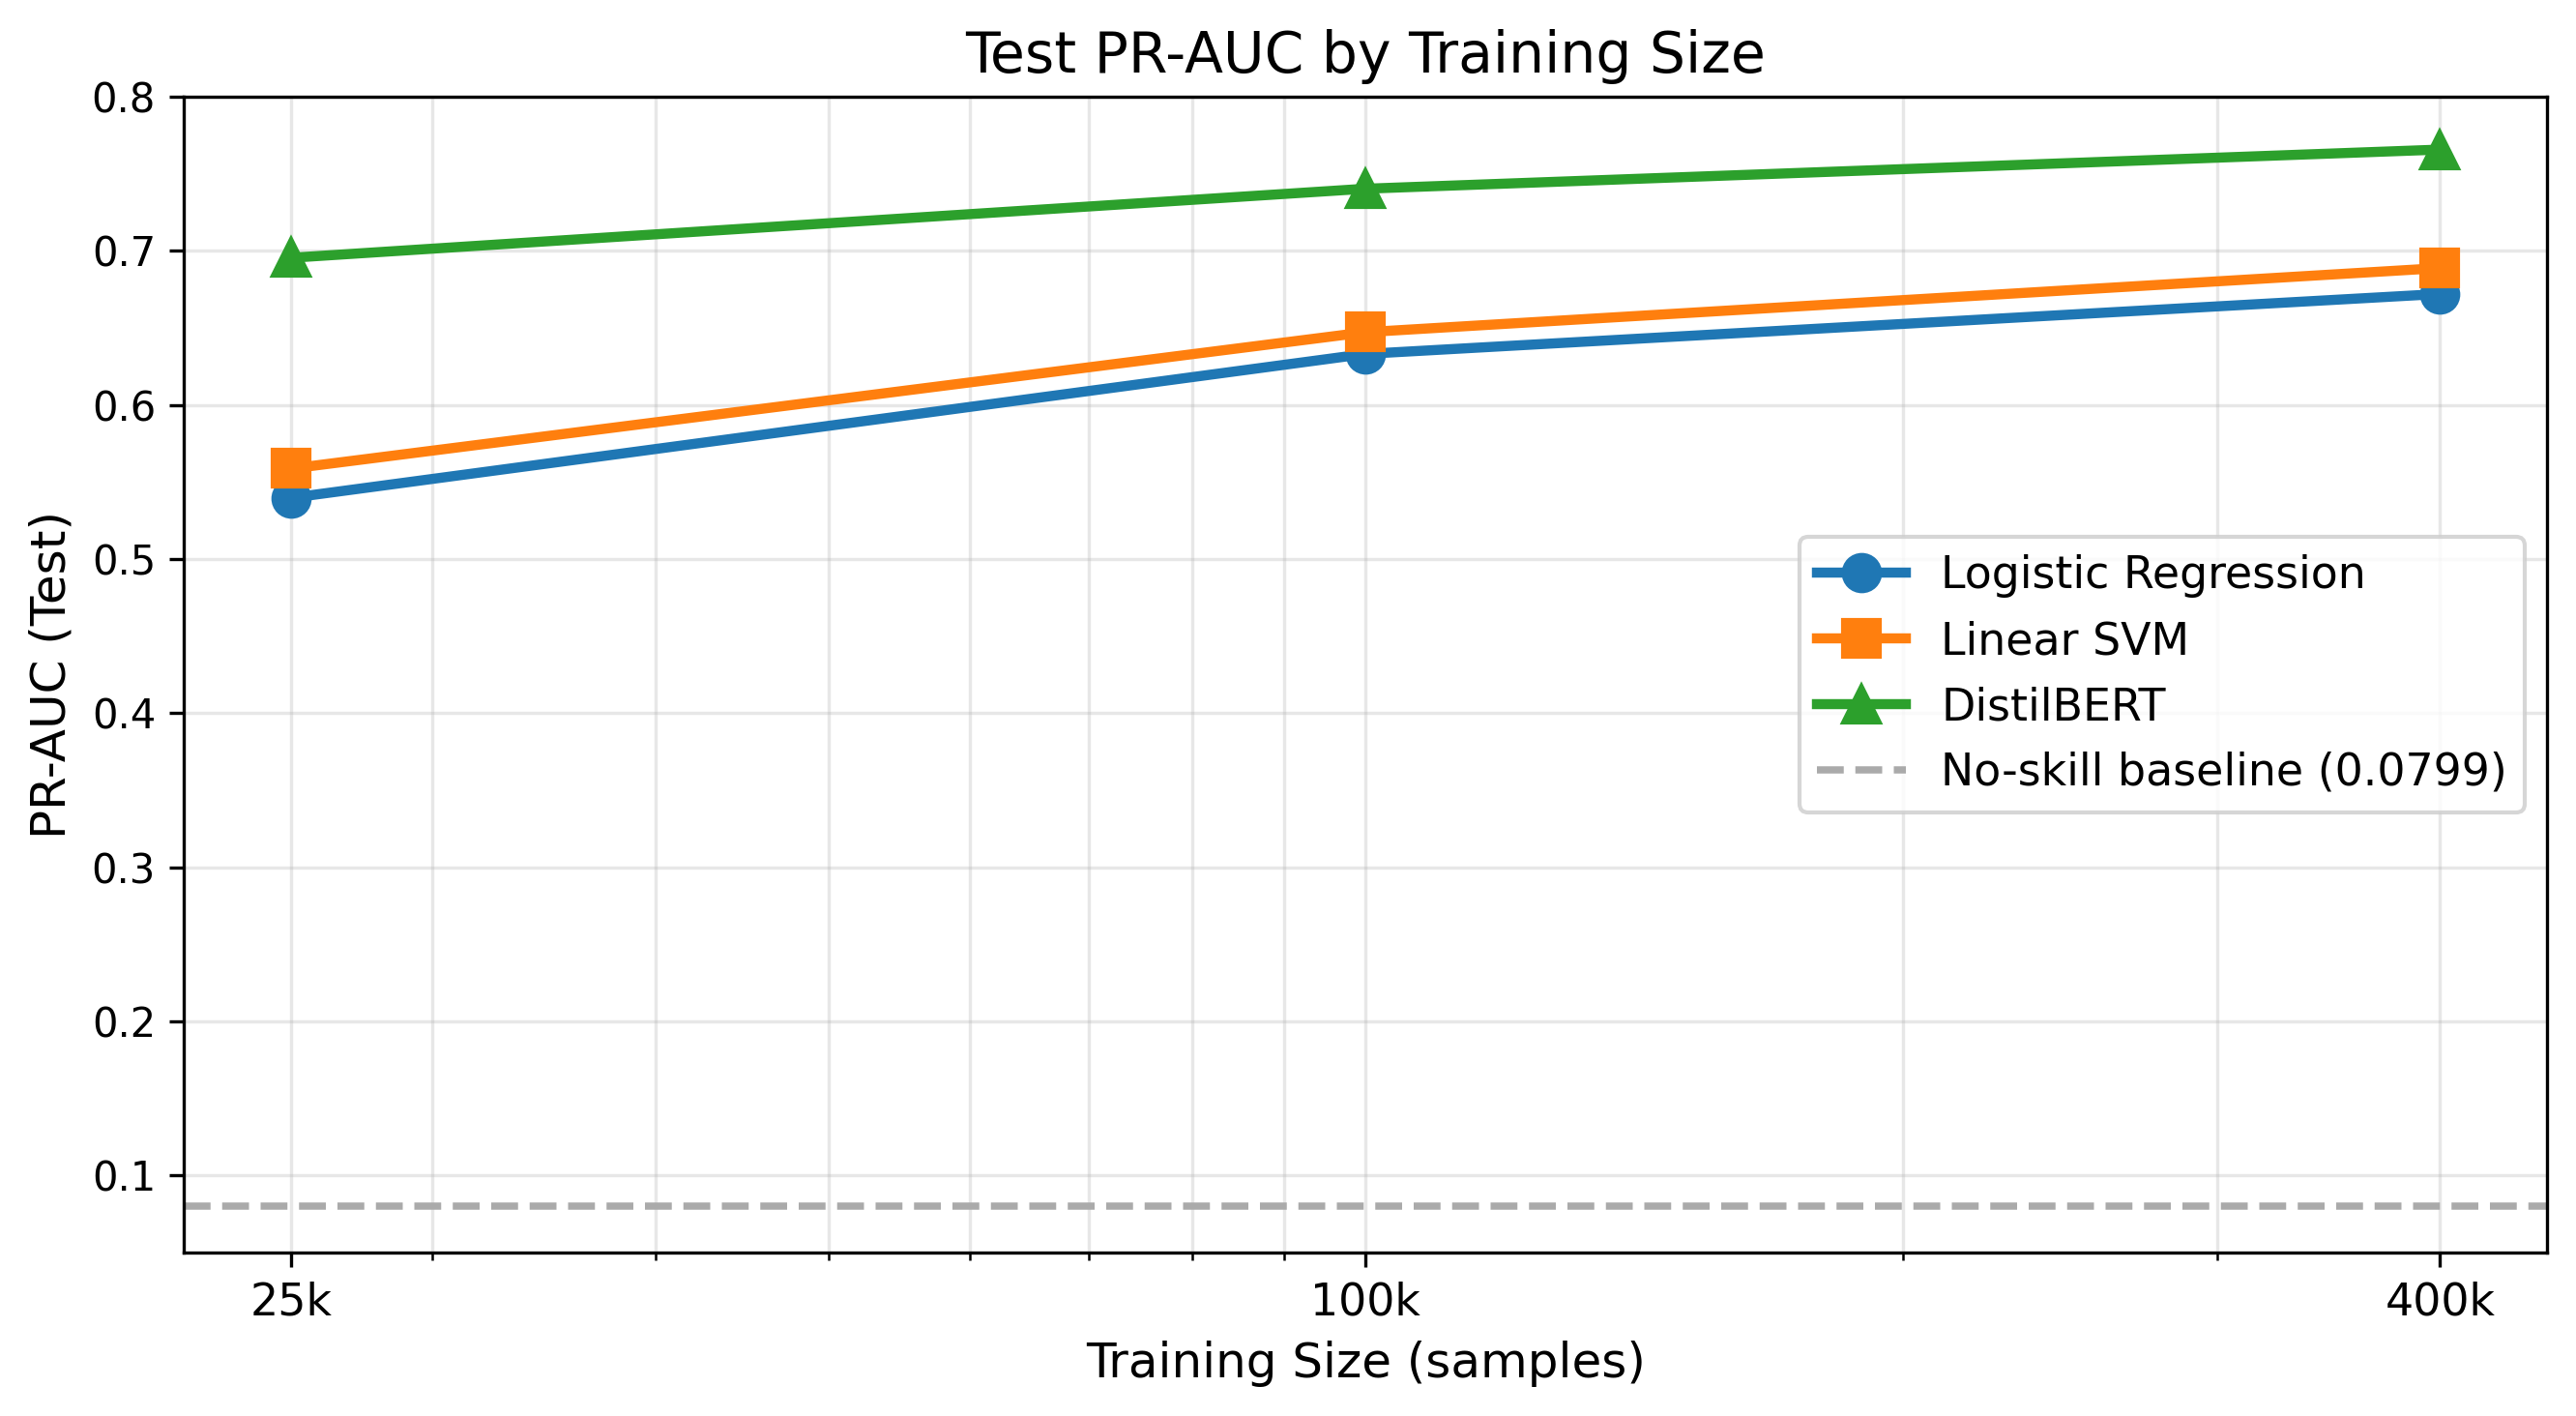

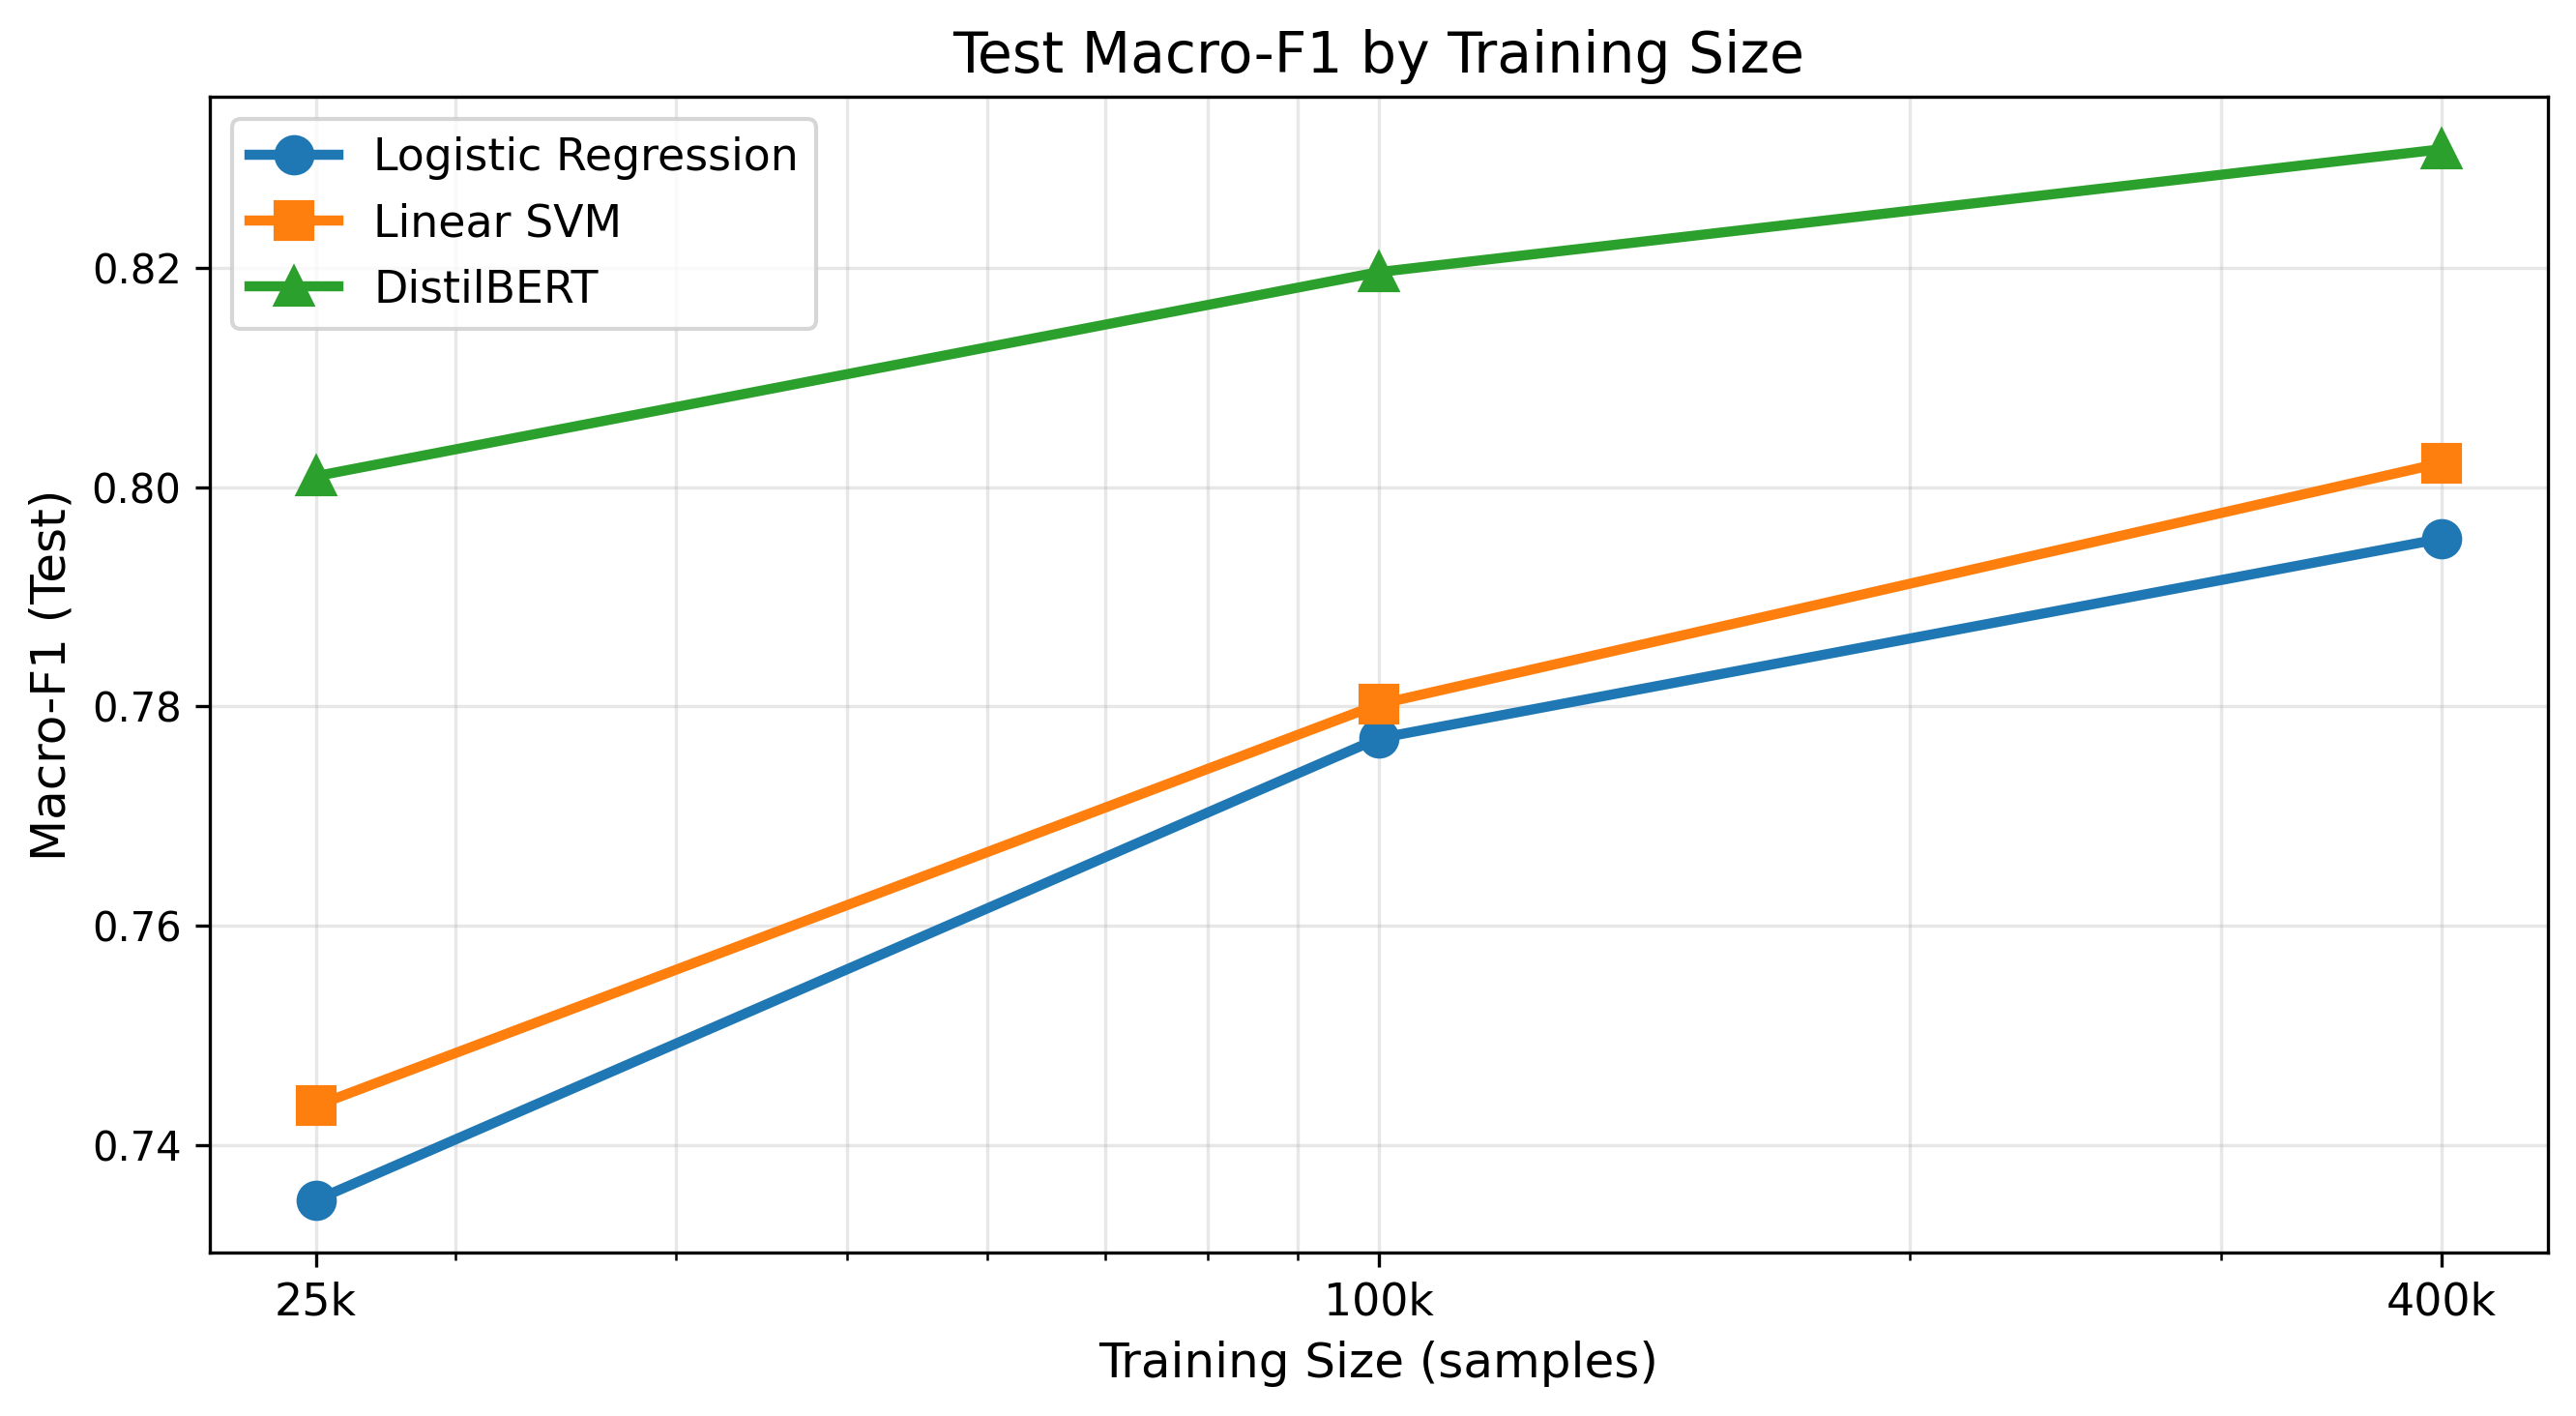

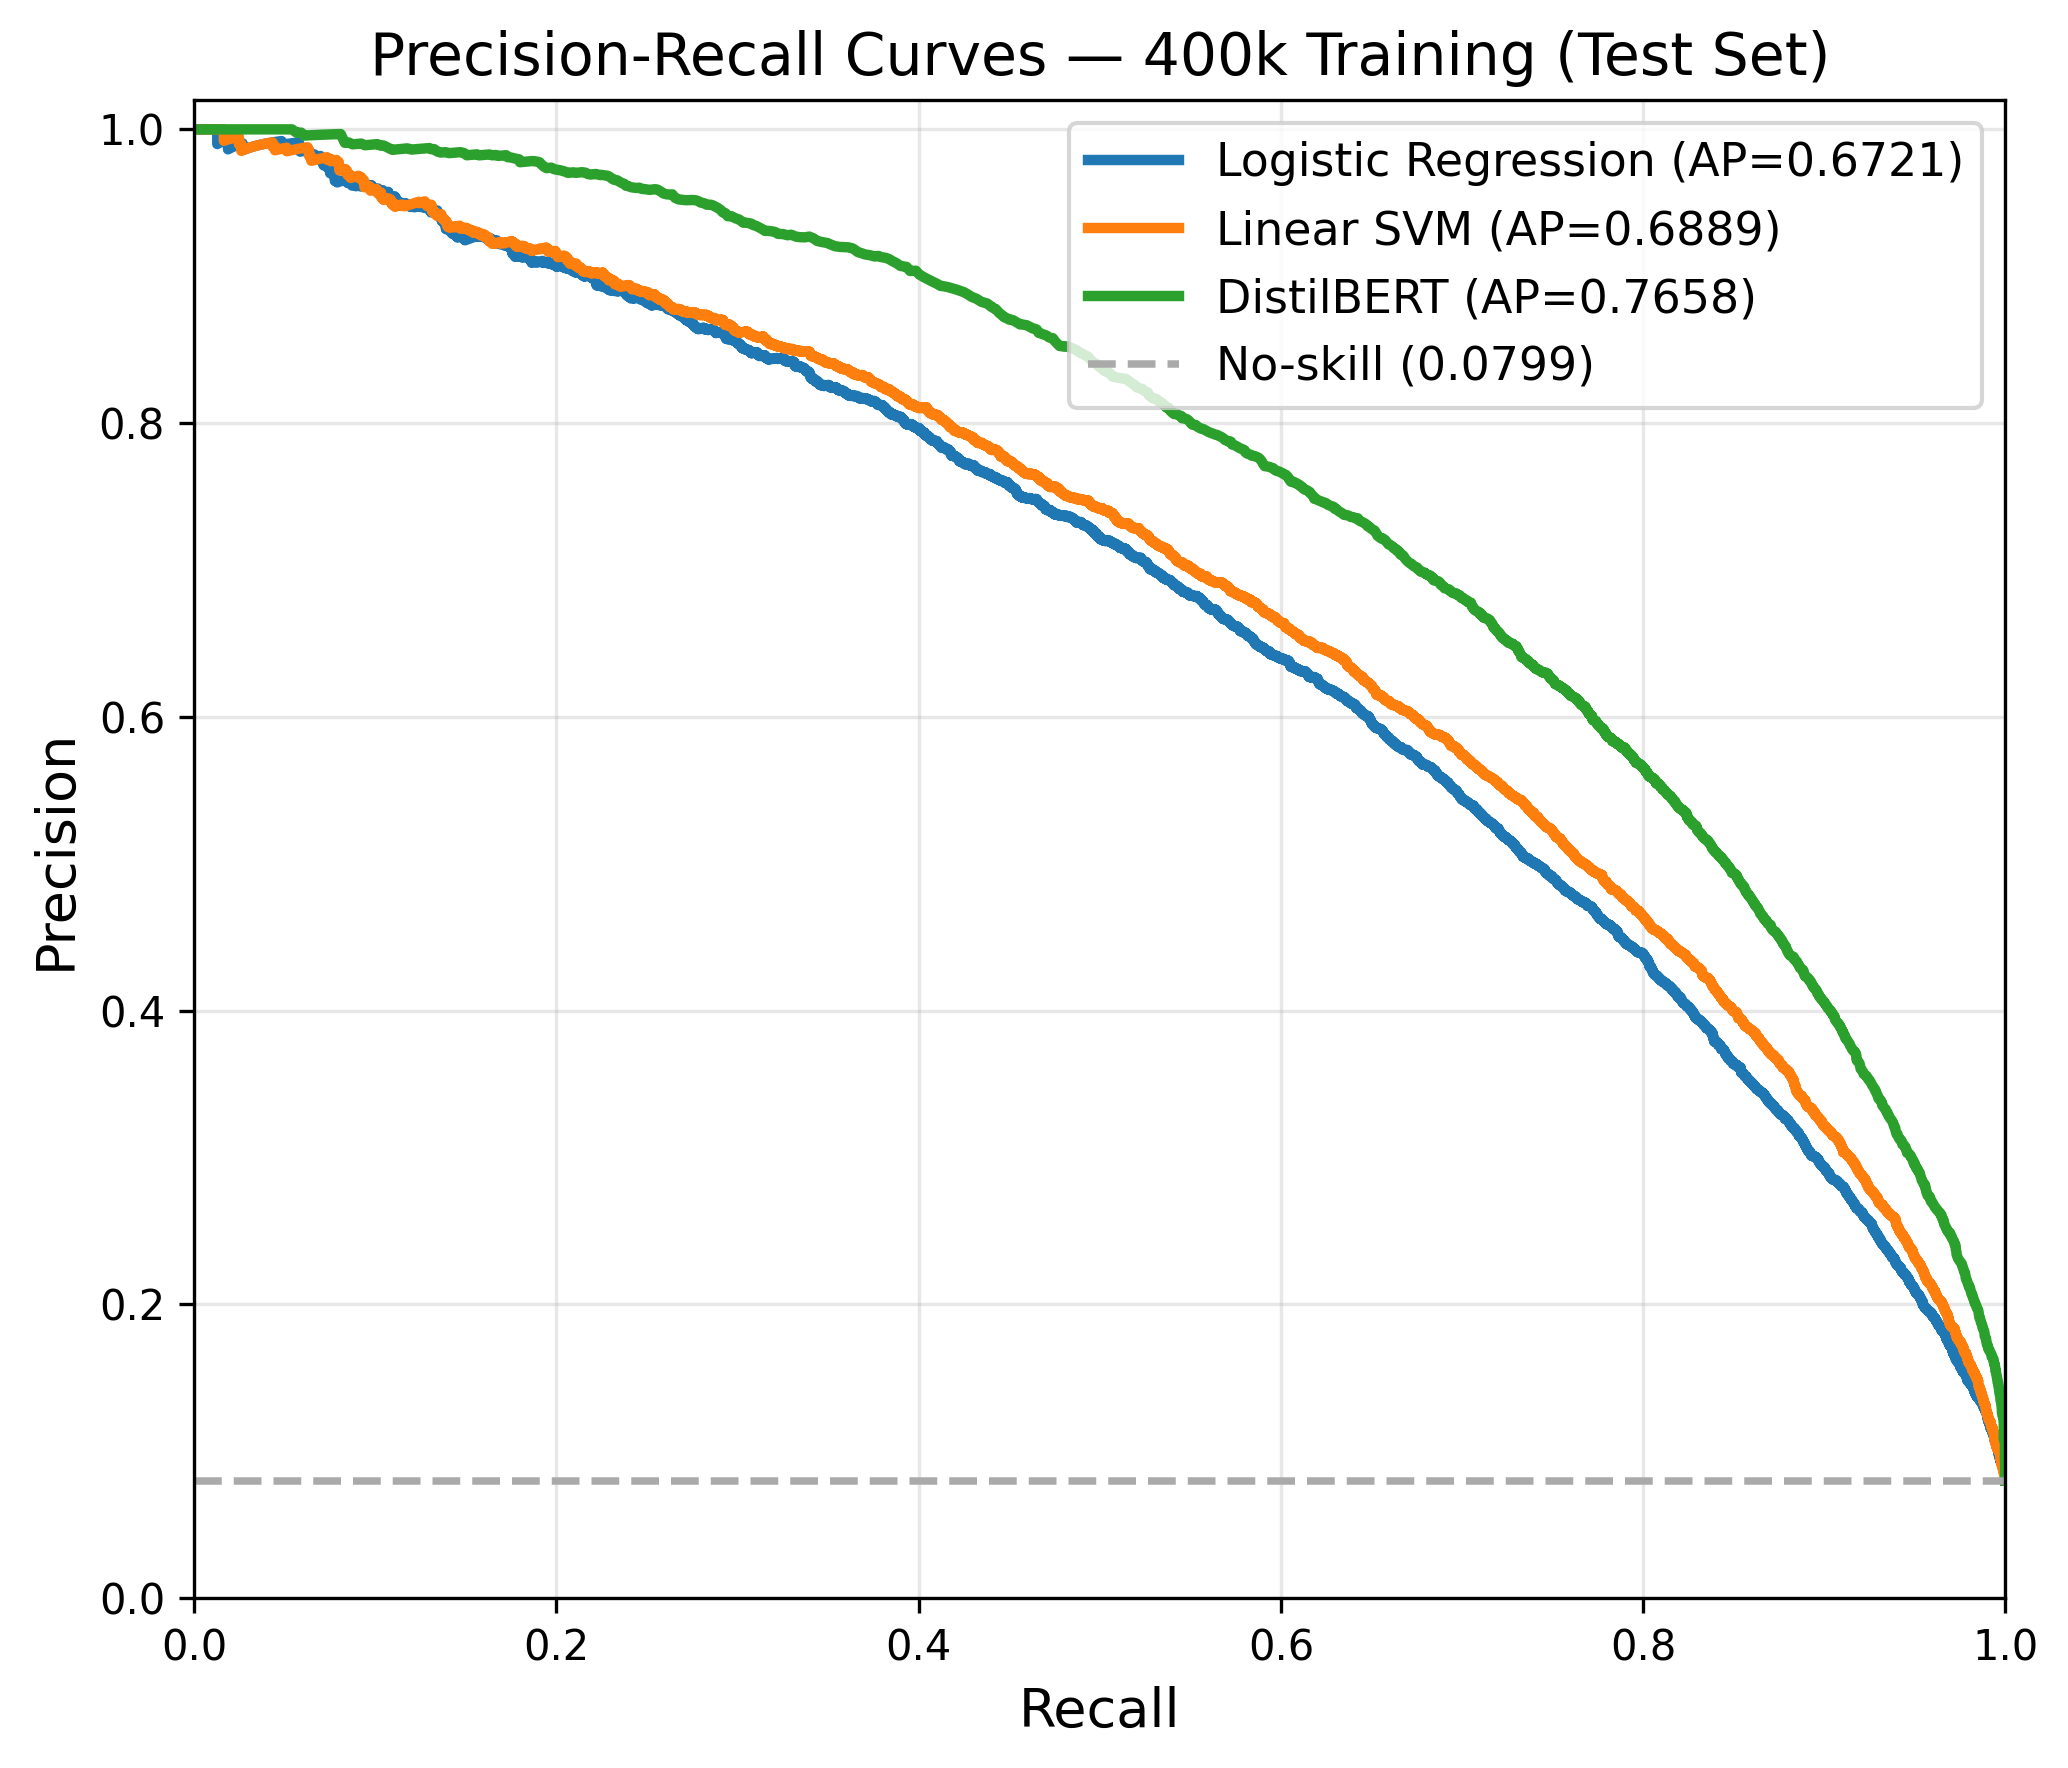

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from IPython.display import display, Image

# ---------------------------------------------------------------------
# Section 14 — Main Comparison Figures
# Safe version:
# - loads saved summary tables from disk
# - does not depend on in-memory master_df
# - saves and displays figures
# ---------------------------------------------------------------------

main_results_path = os.path.join(CONFIG["tables_dir"], "main_results_table.csv")
master_results_path = os.path.join(CONFIG["tables_dir"], "section13_master_results.csv")

if os.path.exists(master_results_path):
    print(f"Loading results from: {master_results_path}")
    master_df = pd.read_csv(master_results_path)
elif os.path.exists(main_results_path):
    print(f"Loading results from: {main_results_path}")
    master_df = pd.read_csv(main_results_path)
else:
    raise FileNotFoundError(
        "Neither section13_master_results.csv nor main_results_table.csv was found. "
        "Run Section 13 first."
    )

COLORS = {
    "Logistic Regression": "#1f77b4",
    "Linear SVM": "#ff7f0e",
    "DistilBERT": "#2ca02c",
}
MARKERS = {
    "Logistic Regression": "o",
    "Linear SVM": "s",
    "DistilBERT": "^",
}

TRAIN_SIZES_NUM = [25_000, 100_000, 400_000]
TRAIN_SIZES_LBL = ["25k", "100k", "400k"]
models_in_order = ["Logistic Regression", "Linear SVM", "DistilBERT"]

saved_figures = []

# ---------------------------------------------------------------------
# Figure 14.1 — Test PR-AUC by Training Size
# ---------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5))

noskill_test = float(y_test.mean())

for model_name in models_in_order:
    pr_aucs = []
    for size_lbl in TRAIN_SIZES_LBL:
        row = master_df[
            (master_df["Model"] == model_name) &
            (master_df["Train Size"] == size_lbl)
        ]
        if len(row) > 0:
            pr_aucs.append(float(row["Test PR-AUC"].values[0]))
        else:
            pr_aucs.append(np.nan)

    ax1.plot(
        TRAIN_SIZES_NUM,
        pr_aucs,
        label=model_name,
        color=COLORS[model_name],
        marker=MARKERS[model_name],
        linewidth=2.5,
        markersize=9,
    )

ax1.axhline(
    noskill_test,
    color="#aaaaaa",
    linestyle="--",
    linewidth=1.8,
    label=f"No-skill baseline ({noskill_test:.4f})",
)

ax1.set_xscale("log")
ax1.set_xticks(TRAIN_SIZES_NUM)
ax1.set_xticklabels(TRAIN_SIZES_LBL, fontsize=11)
ax1.set_xlabel("Training Size (samples)", fontsize=12)
ax1.set_ylabel("PR-AUC (Test)", fontsize=12)
ax1.set_title("Test PR-AUC by Training Size", fontsize=14)
ax1.set_ylim(noskill_test - 0.03, None)
ax1.legend(fontsize=11)
ax1.grid(True, which="both", alpha=0.3)
fig1.tight_layout()

save_figure(fig1, "main_pr_auc_vs_size.png", CONFIG)
fig1_path = os.path.join(CONFIG["figures_dir"], "main_pr_auc_vs_size.png")
saved_figures.append(fig1_path)
print(f"Saved: {fig1_path}")

# Automatic compact note
rows_400k = master_df[master_df["Train Size"] == "400k"].sort_values("Test PR-AUC", ascending=False)
if len(rows_400k) == 3:
    print("\nFigure 14.1 quick note:")
    print(
        f"  At 400k, the strongest model by test PR-AUC is {rows_400k.iloc[0]['Model']} "
        f"({rows_400k.iloc[0]['Test PR-AUC']:.4f})."
    )

# ---------------------------------------------------------------------
# Figure 14.2 — Test Macro-F1 by Training Size
# ---------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))

for model_name in models_in_order:
    f1s = []
    for size_lbl in TRAIN_SIZES_LBL:
        row = master_df[
            (master_df["Model"] == model_name) &
            (master_df["Train Size"] == size_lbl)
        ]
        if len(row) > 0:
            f1s.append(float(row["Test Macro-F1"].values[0]))
        else:
            f1s.append(np.nan)

    ax2.plot(
        TRAIN_SIZES_NUM,
        f1s,
        label=model_name,
        color=COLORS[model_name],
        marker=MARKERS[model_name],
        linewidth=2.5,
        markersize=9,
    )

ax2.set_xscale("log")
ax2.set_xticks(TRAIN_SIZES_NUM)
ax2.set_xticklabels(TRAIN_SIZES_LBL, fontsize=11)
ax2.set_xlabel("Training Size (samples)", fontsize=12)
ax2.set_ylabel("Macro-F1 (Test)", fontsize=12)
ax2.set_title("Test Macro-F1 by Training Size", fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, which="both", alpha=0.3)
fig2.tight_layout()

save_figure(fig2, "main_macro_f1_vs_size.png", CONFIG)
fig2_path = os.path.join(CONFIG["figures_dir"], "main_macro_f1_vs_size.png")
saved_figures.append(fig2_path)
print(f"Saved: {fig2_path}")

# Automatic compact note
rows_400k_f1 = master_df[master_df["Train Size"] == "400k"].sort_values("Test Macro-F1", ascending=False)
if len(rows_400k_f1) == 3:
    print("\nFigure 14.2 quick note:")
    print(
        f"  At 400k, the strongest model by test Macro-F1 is {rows_400k_f1.iloc[0]['Model']} "
        f"({rows_400k_f1.iloc[0]['Test Macro-F1']:.4f})."
    )

# ---------------------------------------------------------------------
# Figure 14.3 — Precision-Recall Curves at 400k (Test Set)
# ---------------------------------------------------------------------
pred_dir = CONFIG["predictions_dir"]

pred_paths = {
    "lr": os.path.join(pred_dir, "lr_400k_test.parquet"),
    "svm": os.path.join(pred_dir, "svm_400k_test.parquet"),
    "distilbert": os.path.join(pred_dir, "distilbert_400k_test.parquet"),
}

for name, path in pred_paths.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing prediction file: {path} — complete Section 12 first.")

preds_400k = {name: pd.read_parquet(path) for name, path in pred_paths.items()}

model_key_map = {
    "lr": "Logistic Regression",
    "svm": "Linear SVM",
    "distilbert": "DistilBERT",
}

fig3, ax3 = plt.subplots(figsize=(7, 6))

noskill_test_pr = float(y_test.mean())

for prefix, model_name in model_key_map.items():
    df_p = preds_400k[prefix]
    y_true_local = df_p["y_true"].values
    y_scores_local = df_p["y_scores"].values

    ap = average_precision_score(y_true_local, y_scores_local)
    prec, rec, _ = precision_recall_curve(y_true_local, y_scores_local)

    ax3.plot(
        rec,
        prec,
        label=f"{model_name} (AP={ap:.4f})",
        color=COLORS[model_name],
        linewidth=2.5,
    )

ax3.axhline(
    noskill_test_pr,
    color="#aaaaaa",
    linestyle="--",
    linewidth=1.8,
    label=f"No-skill ({noskill_test_pr:.4f})",
)

ax3.set_xlabel("Recall", fontsize=13)
ax3.set_ylabel("Precision", fontsize=13)
ax3.set_title("Precision-Recall Curves — 400k Training (Test Set)", fontsize=14)
ax3.legend(fontsize=11, loc="upper right")
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1.02)
ax3.grid(True, alpha=0.3)
fig3.tight_layout()

save_figure(fig3, "pr_curves_400k.png", CONFIG)
fig3_path = os.path.join(CONFIG["figures_dir"], "pr_curves_400k.png")
saved_figures.append(fig3_path)
print(f"Saved: {fig3_path}")

# ---------------------------------------------------------------------
# Display saved PNGs in notebook output
# ---------------------------------------------------------------------
print("\nDisplaying saved figures:\n")
for fig_path in saved_figures:
    display(Image(filename=fig_path))

**Interpretation of Figure 14.1.**  
This figure addresses the two main comparison questions directly: which model performs best, and how performance changes as training data increases. DistilBERT is the strongest model at every scale, with test PR-AUC rising from `0.6956` at 25k to `0.7658` at 400k. Linear SVM is consistently second, and Logistic Regression remains slightly behind it across all three training sizes.

The most important point is not merely that all models improve, but that they improve in different ways. DistilBERT begins from a substantially stronger low-data result than either classical model, which indicates superior data efficiency in practical terms: even with only 25k training examples, it already outperforms the best 400k classical result. By contrast, Logistic Regression and Linear SVM show larger absolute gains as data increases, which suggests that the sparse linear models depend more heavily on additional training data to approach their best performance.

This means that the main story of the figure is not simply “more data helps,” but rather that DistilBERT combines the strongest low-data performance with the strongest final performance, while the classical models continue to benefit from scale without closing the gap.

**Interpretation of Figure 14.2.**  
Figure 14.2 shows that the ranking observed in PR-AUC is preserved after threshold selection. DistilBERT remains the best model, followed by Linear SVM and then Logistic Regression, at all three training sizes. This is important because it indicates that DistilBERT’s advantage is not limited to ranking quality alone; it also carries through to the final thresholded classification decisions.

A second important pattern is that Macro-F1 improves for all models as training size increases, but the gains are smaller from 100k to 400k than from 25k to 100k. This suggests diminishing returns at larger scales. DistilBERT still improves, but more modestly than the classical models, which is consistent with the interpretation from Figure 14.1: it starts from a stronger position and therefore has less room for large absolute gains.

Taken together, Figures 14.1 and 14.2 show that the same model is preferred whether evaluation is based on threshold-independent ranking quality or on thresholded classification performance. This makes the final model comparison more convincing and reduces the chance that the conclusion is being driven by a particular threshold choice.

**Interpretation of Figure 14.3.**  
This figure is especially important because it shows whether the best model is genuinely better across the full operating range, rather than only at a single selected threshold. DistilBERT’s precision–recall curve stays above the two classical curves across almost the entire recall range, which shows that its advantage is structural rather than threshold-specific.

The practical meaning of this pattern is that DistilBERT maintains higher precision while recall increases, especially in the mid-to-high recall region where toxicity detection becomes more difficult. In other words, the transformer model is better able to recover more toxic comments without sacrificing as much precision as the sparse linear baselines. This is exactly the kind of behaviour that PR-AUC is intended to reward under class imbalance.

The figure also clarifies the relationship between the two classical models. Linear SVM remains consistently above Logistic Regression, but the gap between them is relatively small compared with the much larger gap between DistilBERT and both classical baselines. This shows that the main performance break in the study is not between the two sparse linear methods, but between the transformer and the classical feature-based models.

### Figure 14.4 — Incremental Test PR-AUC Gains Across Training Scales

While Figure 14.1 shows the overall level of performance at each training size, it does not directly show how much each model gains from additional data between one scale and the next. Figure 14.4 therefore plots the **incremental change in test PR-AUC** over the intervals `25k → 100k` and `100k → 400k`.

This figure is particularly useful for interpreting data efficiency. A model that starts strong but gains only modestly from more data may already be extracting useful signal efficiently at smaller scales, whereas a model with larger gains may be more dependent on increased training size to approach its best performance.

,Model,25k→100k,100k→400k
0,Logistic Regression,0.0934,0.0389
1,Linear SVM,0.0885,0.0416
2,DistilBERT,0.0448,0.0254


Saved: /content/drive/MyDrive/ToxicityThesis/figures/incremental_pr_auc_gains.png


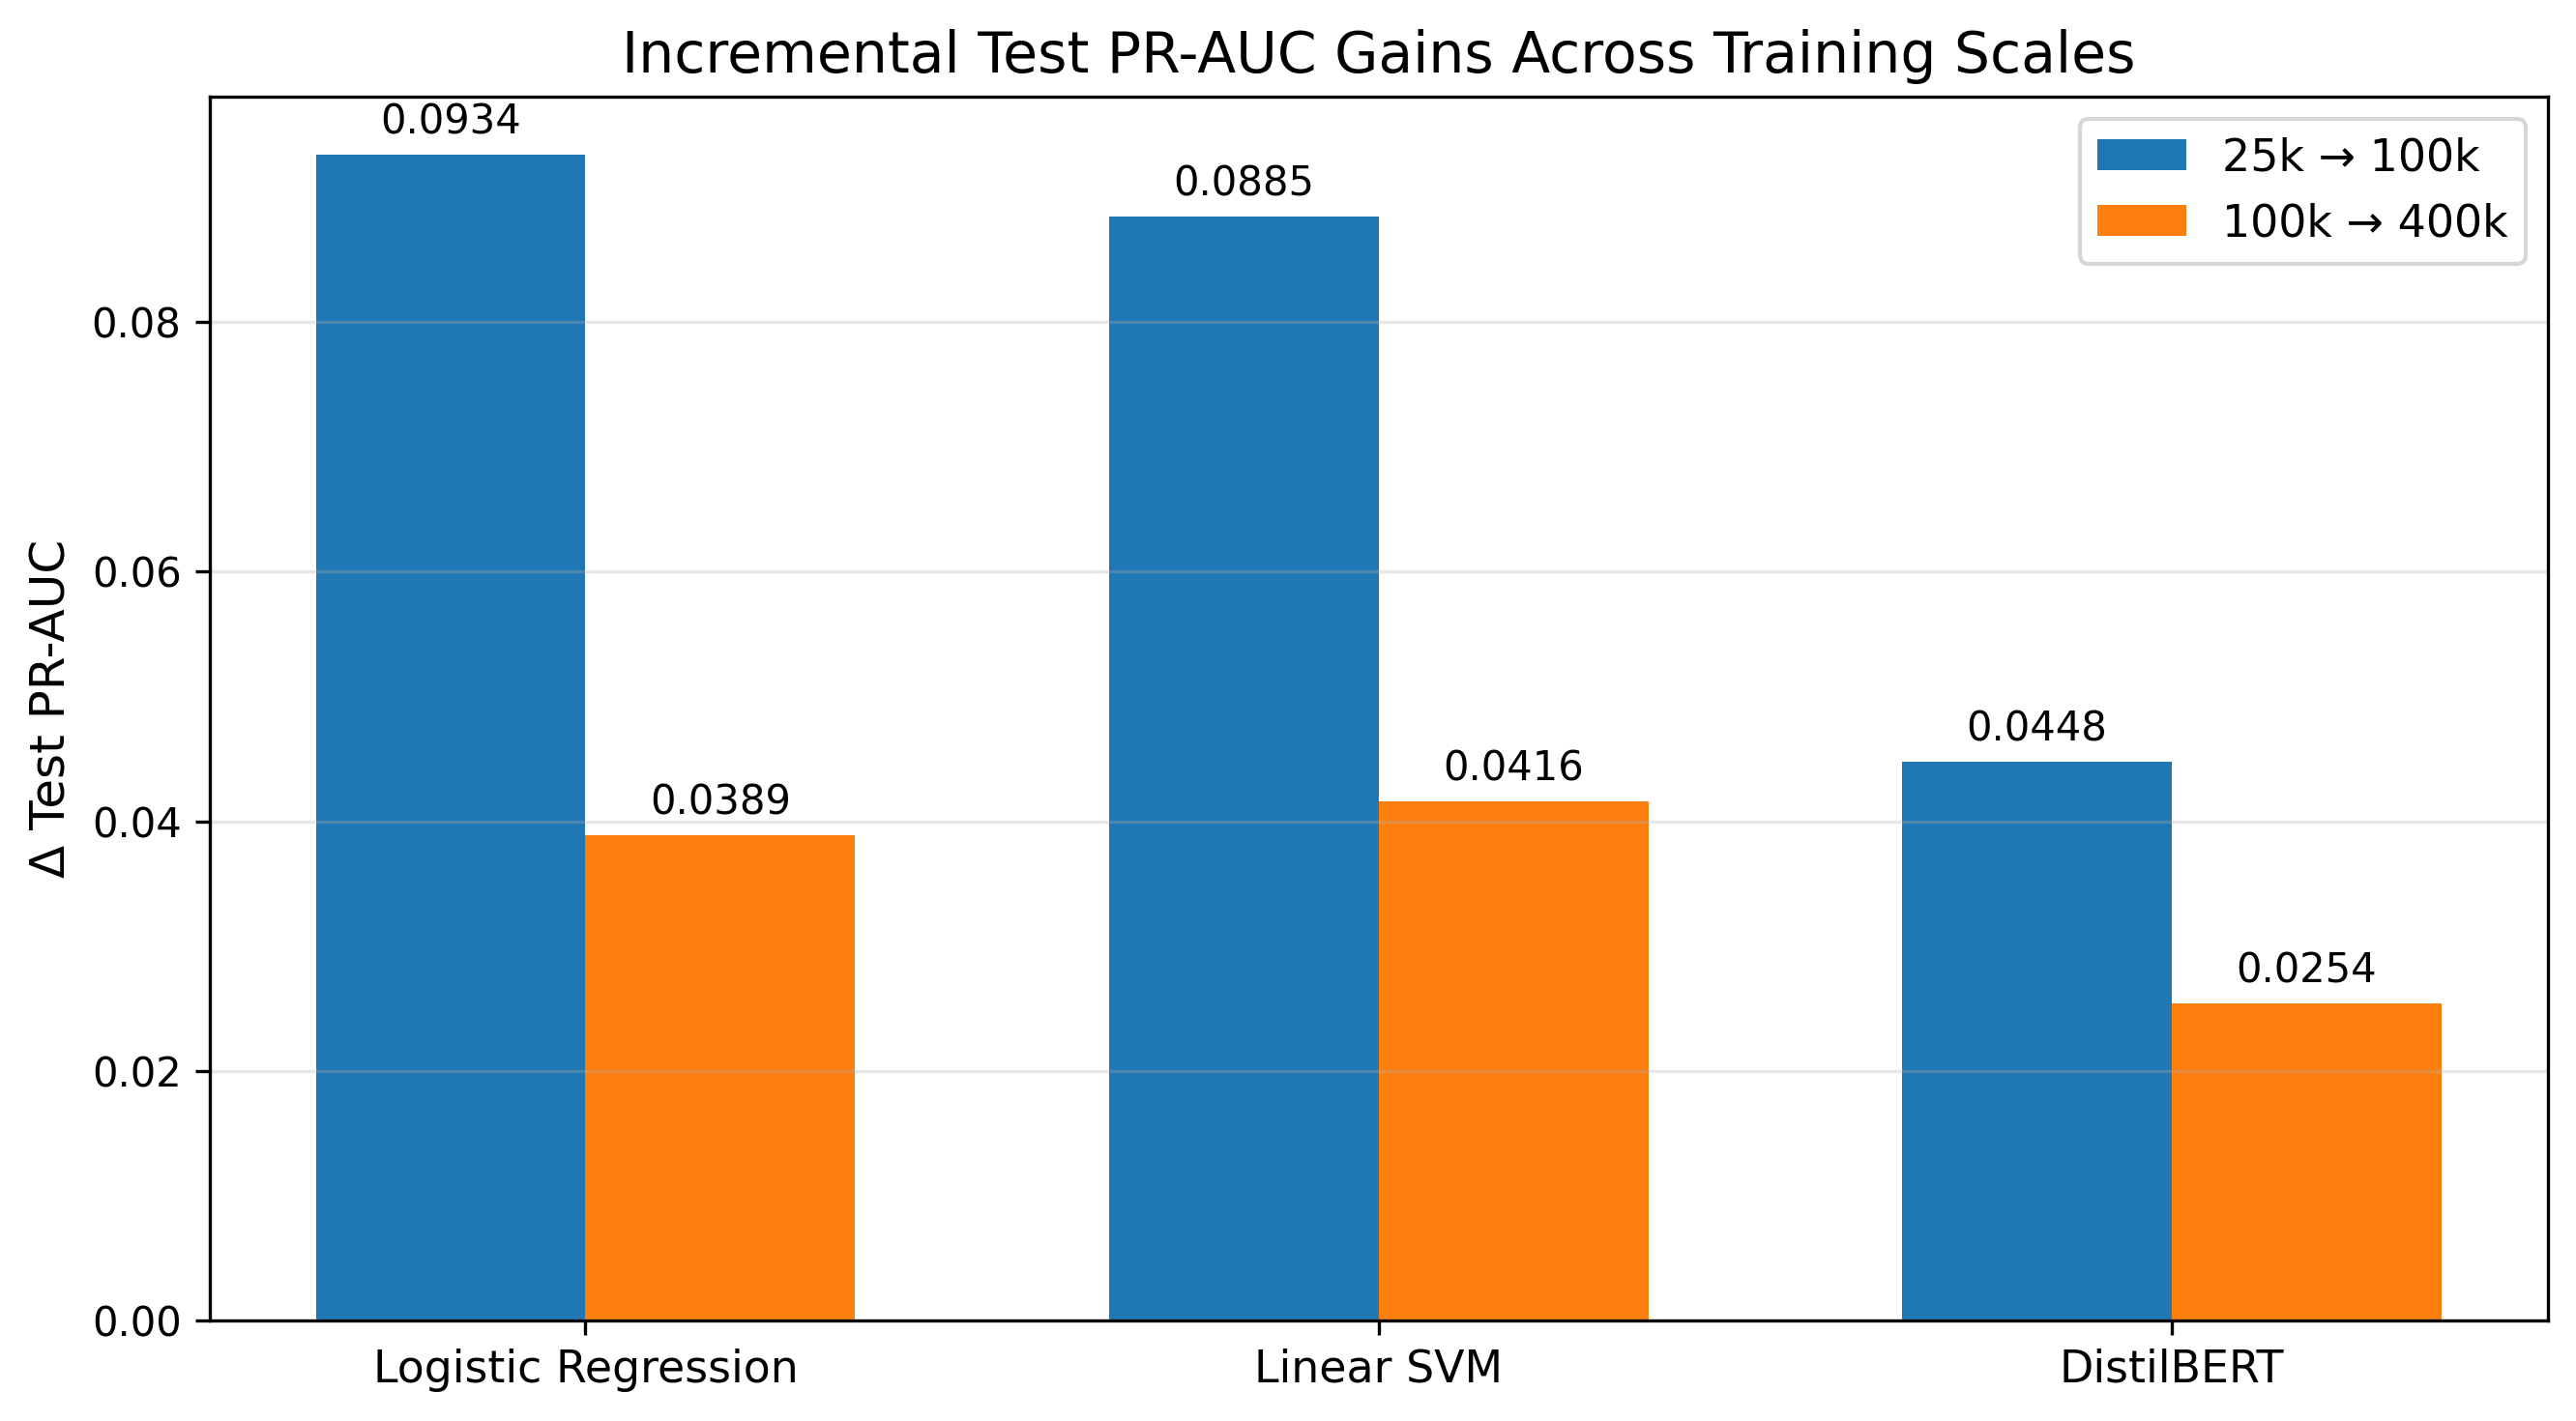

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# Load master results from Section 13
master_results_path = os.path.join(CONFIG["tables_dir"], "section13_master_results.csv")
if not os.path.exists(master_results_path):
    raise FileNotFoundError(
        f"Missing: {master_results_path} — run Section 13 first."
    )

master_df = pd.read_csv(master_results_path)

models_in_order = ["Logistic Regression", "Linear SVM", "DistilBERT"]

# Compute incremental gains in test PR-AUC
delta_rows = []
for model_name in models_in_order:
    row_25 = master_df[(master_df["Model"] == model_name) & (master_df["Train Size"] == "25k")]
    row_100 = master_df[(master_df["Model"] == model_name) & (master_df["Train Size"] == "100k")]
    row_400 = master_df[(master_df["Model"] == model_name) & (master_df["Train Size"] == "400k")]

    if len(row_25) == 0 or len(row_100) == 0 or len(row_400) == 0:
        raise ValueError(f"Missing rows for model: {model_name}")

    pr_25 = float(row_25["Test PR-AUC"].values[0])
    pr_100 = float(row_100["Test PR-AUC"].values[0])
    pr_400 = float(row_400["Test PR-AUC"].values[0])

    delta_rows.append({
        "Model": model_name,
        "25k→100k": pr_100 - pr_25,
        "100k→400k": pr_400 - pr_100,
    })

delta_df = pd.DataFrame(delta_rows)
display(delta_df.round(4))

# Plot
fig4, ax4 = plt.subplots(figsize=(9, 5))

x = np.arange(len(delta_df))
width = 0.34

bars1 = ax4.bar(x - width/2, delta_df["25k→100k"], width, label="25k → 100k")
bars2 = ax4.bar(x + width/2, delta_df["100k→400k"], width, label="100k → 400k")

ax4.set_xticks(x)
ax4.set_xticklabels(delta_df["Model"], fontsize=11)
ax4.set_ylabel("Δ Test PR-AUC", fontsize=12)
ax4.set_title("Incremental Test PR-AUC Gains Across Training Scales", fontsize=14)
ax4.legend(fontsize=11)
ax4.grid(True, axis="y", alpha=0.3)

ax4.bar_label(bars1, fmt="%.4f", padding=3, fontsize=10)
ax4.bar_label(bars2, fmt="%.4f", padding=3, fontsize=10)

fig4.tight_layout()
save_figure(fig4, "incremental_pr_auc_gains.png", CONFIG)

fig4_path = os.path.join(CONFIG["figures_dir"], "incremental_pr_auc_gains.png")
print(f"Saved: {fig4_path}")
display(Image(filename=fig4_path))

**Interpretation of Figure 14.4.**  
Figure 14.4 shows that all three model families benefit from additional training data, but the size of the gain differs across intervals and across models. For each model, the larger improvement occurs between **25k and 100k**, while the gain from **100k to 400k** is smaller, indicating diminishing returns at larger data scales.

The classical models exhibit the largest absolute gains. Logistic Regression improves by **+0.0934** PR-AUC from 25k to 100k and by **+0.0389** from 100k to 400k, while Linear SVM improves by **+0.0885** and **+0.0416** over the same intervals. DistilBERT also improves at both stages, but more moderately (**+0.0448** and **+0.0254**). This suggests that the sparse linear models depend more strongly on additional data to improve their ranking performance.

At the same time, DistilBERT begins from a substantially stronger low-data result, so its smaller incremental gains should be interpreted in the context of an already high starting point rather than as weaker overall learning behaviour. The figure therefore refines the data-scaling interpretation: all models improve with more data, but DistilBERT remains the strongest model throughout, while Logistic Regression and Linear SVM gain more from scale without closing the performance gap.

## Section 15 — Supporting Analysis: Comment-Length Slices

This section provides a supporting analysis of model behaviour across different comment lengths. It is not treated as a separate research question; rather, its purpose is to qualify the main comparison by examining whether the relative strengths of the three model families remain stable across shorter and longer comments.

The analysis is conducted only at the **400k training size**, which serves as the primary comparison scale of the project. Restricting the analysis to this setting avoids conflating length effects with differences in training-data availability and ensures that each model is evaluated under its strongest final configuration.

Comment length is measured by **character count**, which is model-agnostic, reproducible, and consistent with the earlier exploratory analysis. The test set comments are divided into three bins:

- **Short:** fewer than 150 characters  
- **Medium:** 150 to 500 characters  
- **Long:** more than 500 characters  

These bins are intended to capture practically different types of comments, ranging from brief remarks to longer, more elaborated statements.

For each bin, the saved 400k test predictions are evaluated separately. The resulting metrics are used to assess whether performance differences across models are broadly stable or whether certain model families are relatively stronger for particular comment lengths. Because this is a supporting analysis, the emphasis is on interpretation rather than on establishing a new optimisation target.

As a reliability safeguard, any bin containing fewer than 500 test examples is flagged explicitly, since metrics from very small subsets would be more sensitive to sampling noise and should therefore be interpreted with caution.

Length bin distribution (test set):
  short   : 38,510 examples (39.6%)
  medium  : 40,054 examples (41.2%)
  long    : 18,756 examples (19.3%)

Table 15.1 — Metrics by Comment Length Bin (400k models, test set):


,Model,Bin,N,N Positive,Positive Rate,PR-AUC,Macro-F1,Precision-1,Recall-1,Threshold Used,Reliability Flag
0,Logistic Regression,short,38510,3049,0.0792,0.7184,0.8218,0.6739,0.6697,0.8644,
1,Logistic Regression,medium,40054,3545,0.0885,0.6864,0.7945,0.6196,0.6319,0.8644,
2,Logistic Regression,long,18756,1183,0.0631,0.5025,0.7349,0.4665,0.5537,0.8644,
3,Linear SVM,short,38510,3049,0.0792,0.7336,0.8256,0.6930,0.6642,0.4684,
4,Linear SVM,medium,40054,3545,0.0885,0.7053,0.8042,0.6591,0.6262,0.4684,
5,Linear SVM,long,18756,1183,0.0631,0.5180,0.7401,0.4927,0.5385,0.4684,
6,DistilBERT,short,38510,3049,0.0792,0.8177,0.8553,0.7111,0.7589,0.8199,
7,DistilBERT,medium,40054,3545,0.0885,0.7848,0.8364,0.6690,0.7413,0.8199,
8,DistilBERT,long,18756,1183,0.0631,0.5467,0.7475,0.5300,0.5232,0.8199,


Saved: /content/drive/MyDrive/ToxicityThesis/tables/length_slice_results.csv
Saved: /content/drive/MyDrive/ToxicityThesis/figures/length_slice_comparison.png


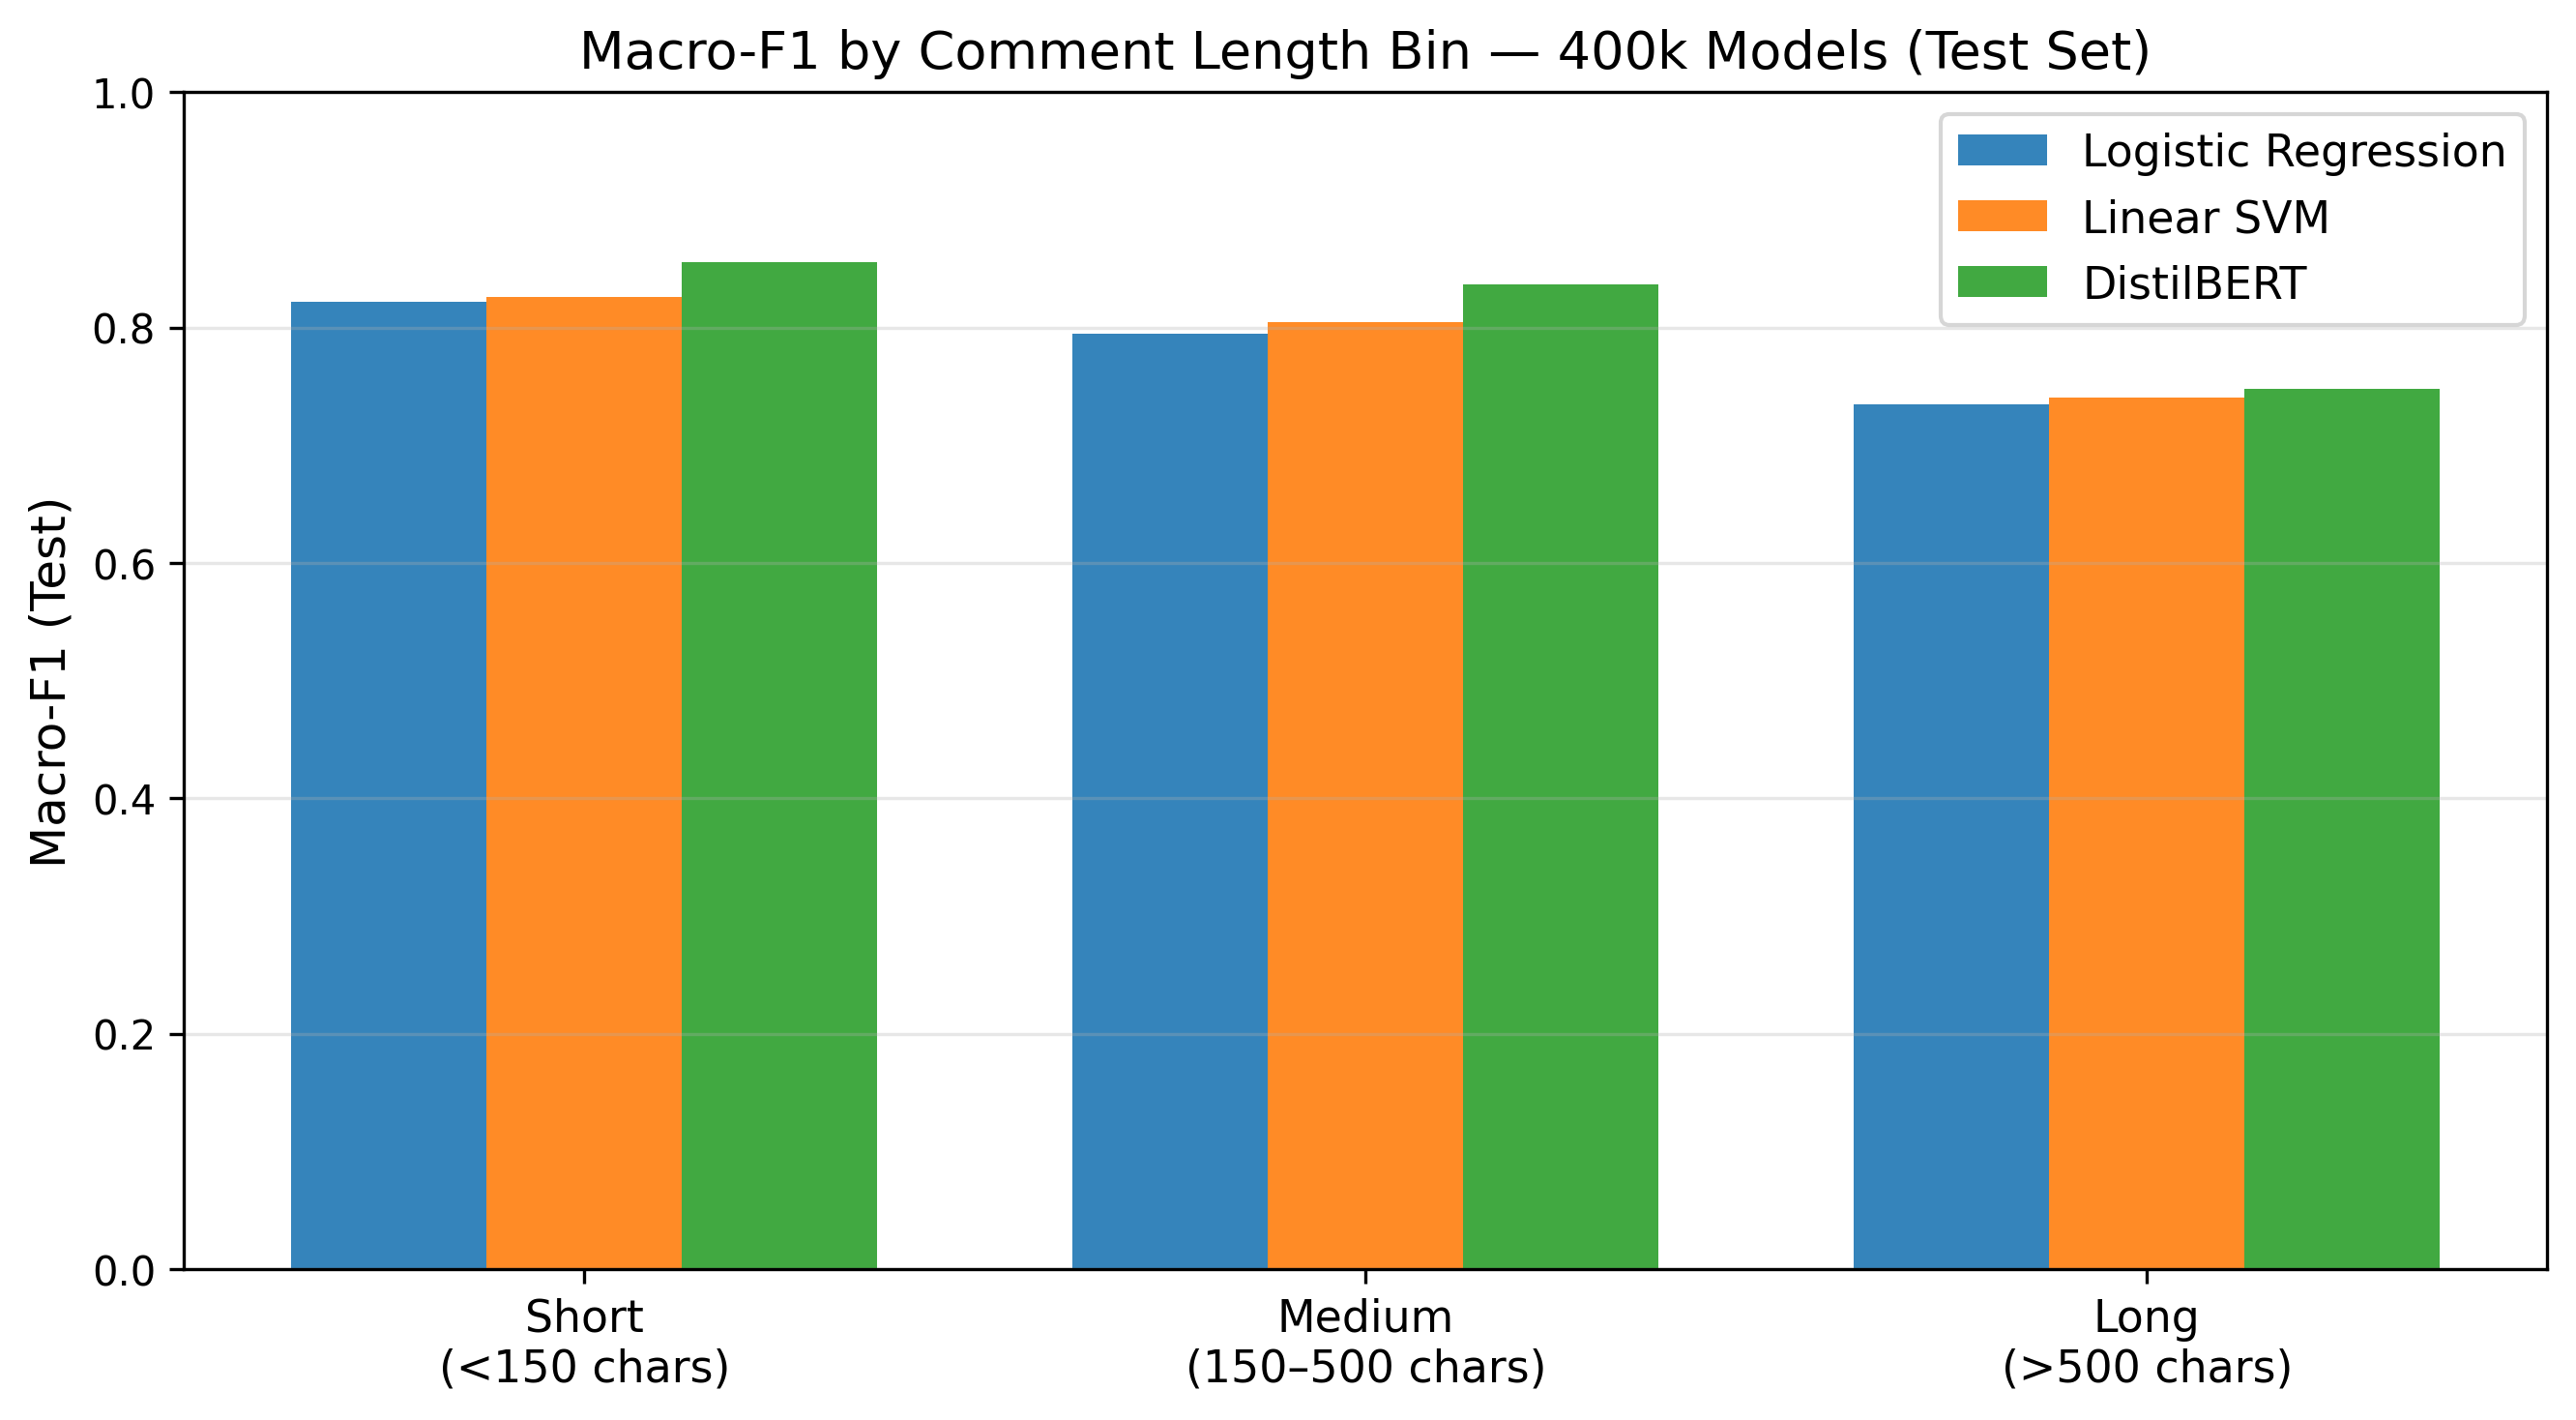


Quick diagnostics by bin:
  short  -> best: DistilBERT (0.8553), worst: Logistic Regression (0.8218)
  medium -> best: DistilBERT (0.8364), worst: Logistic Regression (0.7945)
  long   -> best: DistilBERT (0.7475), worst: Logistic Regression (0.7349)


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ---------------------------------------------------------------------
# Section 15 — Supporting Analysis: Comment-Length Slices
# Safe version aligned with the new artefact structure
# ---------------------------------------------------------------------

# Consistent display order / colors
models_in_order = ["Logistic Regression", "Linear SVM", "DistilBERT"]
model_key_map = {
    "lr": "Logistic Regression",
    "svm": "Linear SVM",
    "distilbert": "DistilBERT",
}
COLORS = {
    "Logistic Regression": "#1f77b4",
    "Linear SVM": "#ff7f0e",
    "DistilBERT": "#2ca02c",
}

# ── Bin definition ────────────────────────────────────────────────────
length_bins = {
    "short":  (0, 150),
    "medium": (150, 500),
    "long":   (500, int(1e9)),
}
bin_order = {"short": 0, "medium": 1, "long": 2}
bin_display = {
    "short": "Short\n(<150 chars)",
    "medium": "Medium\n(150–500 chars)",
    "long": "Long\n(>500 chars)",
}

# ── Test-set lengths from fixed split already loaded by recovery cell ─
test_texts = test_df[TEXT_COL].fillna("").astype(str).values
test_lengths = np.array([len(t) for t in test_texts])

print("Length bin distribution (test set):")
for bin_label, (lo, hi) in length_bins.items():
    n = int(((test_lengths >= lo) & (test_lengths < hi)).sum())
    pct = 100 * n / len(test_lengths)
    flag = "  ← NOTE: < 500 examples" if n < 500 else ""
    print(f"  {bin_label:<8}: {n:>6,} examples ({pct:.1f}%){flag}")
print()

# ── Load 400k test predictions and corresponding metric JSONs ─────────
pred_dir = CONFIG["predictions_dir"]
metrics_dir = CONFIG["metrics_dir"]

preds_400k = {}
thresholds_400k = {}

for prefix in ["lr", "svm", "distilbert"]:
    pred_path = os.path.join(pred_dir, f"{prefix}_400k_test.parquet")
    metrics_path = os.path.join(metrics_dir, f"{prefix}_400k_metrics.json")

    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Missing prediction file: {pred_path}")
    if not os.path.exists(metrics_path):
        raise FileNotFoundError(f"Missing metrics JSON: {metrics_path}")

    preds_400k[prefix] = pd.read_parquet(pred_path)

    with open(metrics_path, "r") as f:
        m_json = json.load(f)
    thresholds_400k[prefix] = float(m_json["threshold"])

# ── Compute per-bin metrics for each model ────────────────────────────
slice_rows = []

for prefix, model_name in model_key_map.items():
    df_p = preds_400k[prefix]
    y_true = df_p["y_true"].values
    y_scores = df_p["y_scores"].values
    threshold = thresholds_400k[prefix]

    # Safety check: alignment with test set length
    if len(y_true) != len(test_lengths):
        raise ValueError(
            f"Length mismatch for {prefix}: predictions have {len(y_true)} rows "
            f"but test_lengths has {len(test_lengths)} rows."
        )

    for bin_label, (lo, hi) in length_bins.items():
        mask = (test_lengths >= lo) & (test_lengths < hi)
        n_bin = int(mask.sum())
        if n_bin == 0:
            continue

        m = compute_metrics(y_true[mask], y_scores[mask], threshold=threshold)

        slice_rows.append({
            "Model": model_name,
            "Bin": bin_label,
            "N": n_bin,
            "N Positive": int(y_true[mask].sum()),
            "Positive Rate": round(float(y_true[mask].mean()), 4),
            "PR-AUC": round(m["pr_auc"], 4) if not np.isnan(m["pr_auc"]) else np.nan,
            "Macro-F1": round(m["macro_f1"], 4),
            "Precision-1": round(m["precision_1"], 4),
            "Recall-1": round(m["recall_1"], 4),
            "Threshold Used": round(threshold, 4),
            "Reliability Flag": "<500 examples" if n_bin < 500 else "",
        })

slice_df = pd.DataFrame(slice_rows)

model_order = {"Logistic Regression": 0, "Linear SVM": 1, "DistilBERT": 2}
slice_df["_mo"] = slice_df["Model"].map(model_order)
slice_df["_bo"] = slice_df["Bin"].map(bin_order)
slice_df = (
    slice_df.sort_values(["_mo", "_bo"])
    .drop(columns=["_mo", "_bo"])
    .reset_index(drop=True)
)

print("Table 15.1 — Metrics by Comment Length Bin (400k models, test set):")
display(slice_df)

slice_path = os.path.join(CONFIG["tables_dir"], "length_slice_results.csv")
slice_df.to_csv(slice_path, index=False)
print(f"Saved: {slice_path}")

# ── Figure 15.1 — Macro-F1 by Length Bin ──────────────────────────────
bin_labels_ordered = ["short", "medium", "long"]
x = np.arange(len(bin_labels_ordered))
bar_width = 0.25

fig_s, ax_s = plt.subplots(figsize=(9, 5))

for offset_i, model_name in enumerate(models_in_order):
    f1s = []
    for bl in bin_labels_ordered:
        row = slice_df[(slice_df["Model"] == model_name) & (slice_df["Bin"] == bl)]
        f1s.append(float(row["Macro-F1"].values[0]) if len(row) > 0 else np.nan)

    ax_s.bar(
        x + (offset_i - 1) * bar_width,
        f1s,
        width=bar_width,
        label=model_name,
        color=COLORS[model_name],
        alpha=0.9,
    )

ax_s.set_xticks(x)
ax_s.set_xticklabels([bin_display[b] for b in bin_labels_ordered], fontsize=11)
ax_s.set_ylabel("Macro-F1 (Test)", fontsize=12)
ax_s.set_title("Macro-F1 by Comment Length Bin — 400k Models (Test Set)", fontsize=13)
ax_s.legend(fontsize=11)
ax_s.grid(True, axis="y", alpha=0.3)
ax_s.set_ylim(0, 1.0)
fig_s.tight_layout()

save_figure(fig_s, "length_slice_comparison.png", CONFIG)
fig_path = os.path.join(CONFIG["figures_dir"], "length_slice_comparison.png")
print(f"Saved: {fig_path}")
display(Image(filename=fig_path))

# ── Optional compact diagnostics printed to output ────────────────────
print("\nQuick diagnostics by bin:")
for bl in bin_labels_ordered:
    sub = slice_df[slice_df["Bin"] == bl].sort_values("Macro-F1", ascending=False)
    if len(sub) > 0:
        best = sub.iloc[0]
        worst = sub.iloc[-1]
        print(
            f"  {bl:<6} -> best: {best['Model']} ({best['Macro-F1']:.4f}), "
            f"worst: {worst['Model']} ({worst['Macro-F1']:.4f})"
        )

**Interpretation of Figure 15.1.**  
Figure 15.1 shows that Macro-F1 decreases as comment length increases for all three 400k models. Short comments are handled best, medium comments slightly worse, and long comments worst. This indicates that longer comments are systematically more difficult to classify under all three model families.

The model ranking remains stable in every bin. DistilBERT achieves the highest Macro-F1 for short (`0.8553`), medium (`0.8364`), and long (`0.7475`) comments, followed by Linear SVM and then Logistic Regression. Thus, the main comparative conclusion of the project is not reversed by comment length.

One important caveat is that DistilBERT was trained and evaluated with inputs truncated to **128 tokens** in order to keep fine-tuning computationally feasible. Some long comments may therefore have been only partially observed by the transformer. This likely contributes to the reduced margin between DistilBERT and the classical models in the long-comment bin, although it cannot fully explain the pattern because long-comment performance also declines for Logistic Regression and Linear SVM.

The figure therefore supports a balanced interpretation: long comments are generally harder for toxicity classification, and DistilBERT’s relative advantage becomes smaller in that setting, but it still remains the strongest model across all three length bins.

## Section 16 — Supporting Analysis: Qualitative Error Analysis

This section provides a qualitative supporting analysis of the final **400k** models. Its purpose is to identify recurring failure patterns that are not visible in the aggregate metrics and to provide interpretive context for the limitations of the three model families.

The analysis is conducted at the primary comparison scale of **400k training examples**, so that the examples reflect each model family in its strongest final form. No new predictions are generated here; all examples are drawn from the saved test-set prediction files produced in Section 12.

Three categories of cases are examined:

- **Category 1 — False Positives:** comments predicted as toxic although the gold label is non-toxic  
- **Category 2 — False Negatives:** comments predicted as non-toxic although the gold label is toxic  
- **Category 3 — Borderline / Inconsistent Cases:** comments near the decision boundary or cases where DistilBERT and the classical models disagree

For the first two categories, examples are anchored on the **DistilBERT 400k** model because it is the strongest final system and therefore provides the most informative error analysis baseline. However, the table records the scores and predictions of all three 400k models for each selected example, so the analysis remains comparative rather than model-isolated.

The examples are selected systematically from the saved test predictions rather than manually chosen to favour a particular model. This makes the qualitative discussion more reproducible while still allowing close reading of representative error patterns. Interpretive notes are then added manually after inspection.

In [ ]:
import os
import json
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Section 16 — Supporting Analysis: Qualitative Error Analysis
# Safe version aligned with the new artefact structure
# ---------------------------------------------------------------------

set_seed(SEED)
rng = np.random.default_rng(SEED)

pred_dir = CONFIG["predictions_dir"]
metrics_dir = CONFIG["metrics_dir"]

model_prefixes = ["lr", "svm", "distilbert"]
model_names = {
    "lr": "Logistic Regression",
    "svm": "Linear SVM",
    "distilbert": "DistilBERT",
}

# ── Load saved 400k test predictions and thresholds ───────────────────
pred_data = {}
thresholds_400k = {}

for prefix in model_prefixes:
    pred_path = os.path.join(pred_dir, f"{prefix}_400k_test.parquet")
    metrics_path = os.path.join(metrics_dir, f"{prefix}_400k_metrics.json")

    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Missing prediction file: {pred_path}")
    if not os.path.exists(metrics_path):
        raise FileNotFoundError(f"Missing metrics JSON: {metrics_path}")

    pred_data[prefix] = pd.read_parquet(pred_path)

    with open(metrics_path, "r") as f:
        thresholds_400k[prefix] = float(json.load(f)["threshold"])

# ── Safety checks ─────────────────────────────────────────────────────
n_test = len(test_df)

for prefix in model_prefixes:
    if len(pred_data[prefix]) != n_test:
        raise ValueError(
            f"Length mismatch for {prefix}: prediction file has {len(pred_data[prefix])} rows "
            f"but test_df has {n_test} rows."
        )

y_true_ref = pred_data["lr"]["y_true"].values
for prefix in model_prefixes[1:]:
    if not np.array_equal(y_true_ref, pred_data[prefix]["y_true"].values):
        raise ValueError(f"y_true mismatch detected between lr and {prefix} prediction files.")

test_texts = test_df[TEXT_COL].fillna("").astype(str).values
test_lengths = np.array([len(t) for t in test_texts])

# ── Recompute binary predictions from saved scores + saved thresholds ─
scores = {prefix: pred_data[prefix]["y_scores"].values for prefix in model_prefixes}
preds = {
    prefix: (scores[prefix] >= thresholds_400k[prefix]).astype(int)
    for prefix in model_prefixes
}

# ── Selection helpers ─────────────────────────────────────────────────
def top_confident_indices(mask, score_array, threshold, n_select):
    """Select errors farthest from the decision threshold (high-confidence errors)."""
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.array([], dtype=int)
    distances = np.abs(score_array[idx] - threshold)
    order = np.argsort(-distances)  # descending
    return idx[order[:min(n_select, len(idx))]]

def near_threshold_indices(mask, score_array, threshold, n_select):
    """Select cases closest to the decision threshold (borderline cases)."""
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.array([], dtype=int)
    distances = np.abs(score_array[idx] - threshold)
    order = np.argsort(distances)  # ascending
    return idx[order[:min(n_select, len(idx))]]

def build_row(idx, category, selection_basis):
    return {
        "Test Index": int(idx),
        "Category": category,
        "Selection Basis": selection_basis,
        "Text (250 chars)": str(test_texts[idx])[:250],
        "Length (chars)": int(test_lengths[idx]),
        "True Label": int(y_true_ref[idx]),

        "LR Score": round(float(scores["lr"][idx]), 4),
        "LR Pred": int(preds["lr"][idx]),

        "SVM Score": round(float(scores["svm"][idx]), 4),
        "SVM Pred": int(preds["svm"][idx]),

        "BERT Score": round(float(scores["distilbert"][idx]), 4),
        "BERT Pred": int(preds["distilbert"][idx]),

        "LR Threshold": round(float(thresholds_400k["lr"]), 4),
        "SVM Threshold": round(float(thresholds_400k["svm"]), 4),
        "BERT Threshold": round(float(thresholds_400k["distilbert"]), 4),

        "Note": "",
    }

# ── Category 1: DistilBERT False Positives ────────────────────────────
bert_fp_mask = (y_true_ref == 0) & (preds["distilbert"] == 1)
bert_fp_idx = top_confident_indices(
    bert_fp_mask,
    scores["distilbert"],
    thresholds_400k["distilbert"],
    n_select=5,
)

# ── Category 2: DistilBERT False Negatives ────────────────────────────
bert_fn_mask = (y_true_ref == 1) & (preds["distilbert"] == 0)
bert_fn_idx = top_confident_indices(
    bert_fn_mask,
    scores["distilbert"],
    thresholds_400k["distilbert"],
    n_select=5,
)

# ── Category 3: Borderline / Inconsistent Cases ───────────────────────
# First prefer stronger disagreement: BERT differs from BOTH classical models.
disagree_both_mask = (
    (preds["distilbert"] != preds["lr"]) &
    (preds["distilbert"] != preds["svm"])
)

disagree_any_mask = (
    (preds["distilbert"] != preds["lr"]) |
    (preds["distilbert"] != preds["svm"])
)

border_idx_primary = near_threshold_indices(
    disagree_both_mask,
    scores["distilbert"],
    thresholds_400k["distilbert"],
    n_select=5,
)

# If fewer than 5 are found, fill the remainder from the broader disagreement set
if len(border_idx_primary) < 5:
    needed = 5 - len(border_idx_primary)
    fallback_idx = near_threshold_indices(
        disagree_any_mask,
        scores["distilbert"],
        thresholds_400k["distilbert"],
        n_select=20,
    )
    fallback_idx = np.array([i for i in fallback_idx if i not in set(border_idx_primary)])
    border_idx = np.concatenate([border_idx_primary, fallback_idx[:needed]])
else:
    border_idx = border_idx_primary

# ── Build final error table ───────────────────────────────────────────
error_rows = []

for idx in bert_fp_idx:
    error_rows.append(build_row(
        idx=idx,
        category="False Positive",
        selection_basis="DistilBERT 400k high-confidence false positive",
    ))

for idx in bert_fn_idx:
    error_rows.append(build_row(
        idx=idx,
        category="False Negative",
        selection_basis="DistilBERT 400k high-confidence false negative",
    ))

for idx in border_idx:
    error_rows.append(build_row(
        idx=idx,
        category="Borderline / Disagreement",
        selection_basis="DistilBERT vs classical disagreement near BERT threshold",
    ))

error_df = pd.DataFrame(error_rows)

# Stable category order
category_order = {
    "False Positive": 0,
    "False Negative": 1,
    "Borderline / Disagreement": 2,
}
error_df["_cat_ord"] = error_df["Category"].map(category_order)
error_df = (
    error_df.sort_values(["_cat_ord", "Test Index"])
    .drop(columns=["_cat_ord"])
    .reset_index(drop=True)
)

# ── Diagnostics printed to output ─────────────────────────────────────
n_disagree_any = int(disagree_any_mask.sum())
n_disagree_both = int(disagree_both_mask.sum())

print("Section 16 diagnostics (400k models, test set):")
print(f"  DistilBERT false positives available : {int(bert_fp_mask.sum()):,}")
print(f"  DistilBERT false negatives available : {int(bert_fn_mask.sum()):,}")
print(f"  BERT disagrees with at least one classical model : {n_disagree_any:,} ({100*n_disagree_any/n_test:.1f}%)")
print(f"  BERT disagrees with both classical models       : {n_disagree_both:,} ({100*n_disagree_both/n_test:.1f}%)")

print("\nTable 16.1 — Qualitative Error Analysis Examples (400k models, test set):")
pd.set_option("display.max_colwidth", 140)
display(error_df)
pd.reset_option("display.max_colwidth")

# ── Save artefacts ────────────────────────────────────────────────────
error_path = os.path.join(CONFIG["tables_dir"], "error_analysis_examples.csv")
error_df.to_csv(error_path, index=False)
print(f"\nSaved examples table: {error_path}")

selection_meta = pd.DataFrame({
    "Category": (
        ["False Positive"] * len(bert_fp_idx) +
        ["False Negative"] * len(bert_fn_idx) +
        ["Borderline / Disagreement"] * len(border_idx)
    ),
    "Test Index": list(bert_fp_idx) + list(bert_fn_idx) + list(border_idx),
})
selection_meta_path = os.path.join(CONFIG["tables_dir"], "error_analysis_selected_indices.csv")
selection_meta.to_csv(selection_meta_path, index=False)
print(f"Saved selection index log: {selection_meta_path}")

print(f"\nTotal examples selected: {len(error_df)}")
print("Target range: 12–18 examples")

Section 16 diagnostics (400k models, test set):
  DistilBERT false positives available : 2,789
  DistilBERT false negatives available : 2,216
  BERT disagrees with at least one classical model : 5,159 (5.3%)
  BERT disagrees with both classical models       : 3,719 (3.8%)

Table 16.1 — Qualitative Error Analysis Examples (400k models, test set):


,Test Index,Category,Selection Basis,Text (250 chars),Length (chars),True Label,LR Score,LR Pred,SVM Score,SVM Pred,BERT Score,BERT Pred,LR Threshold,SVM Threshold,BERT Threshold,Note
0,2939,False Positive,DistilBERT 400k high-confidence false positive,"I'm waiting for the column on Mika and Joe calling the President ""moron"", ""idiot"", ""mentally unstable"" and ""shmuck"". Will I be waiting l...",140,0,1.0000,1,3.9607,1,0.9993,1,0.8644,0.4684,0.8199,
1,9266,False Positive,DistilBERT 400k high-confidence false positive,How do you know what is stupid though? Every rescue happens because of some failure. Which failures should the rescued pay for?,127,0,0.9998,1,2.1281,1,0.9993,1,0.8644,0.4684,0.8199,
2,17488,False Positive,DistilBERT 400k high-confidence false positive,I'm a silly dude.,17,0,1.0000,1,3.2079,1,0.9995,1,0.8644,0.4684,0.8199,
3,28659,False Positive,DistilBERT 400k high-confidence false positive,Total Clueless Jerk,19,0,1.0000,1,3.3801,1,0.9995,1,0.8644,0.4684,0.8199,
4,52170,False Positive,DistilBERT 400k high-confidence false positive,"It was a dumb, corny joke.",26,0,1.0000,1,4.0009,1,0.9993,1,0.8644,0.4684,0.8199,
5,5953,False Negative,DistilBERT 400k high-confidence false negative,"Which is exactly where it belongs. Mallott screwed this up royally. I don't agree with Sen. Meyer's politics, I am disgusted with the Ma...",421,1,0.5898,0,-0.2979,0,0.0004,0,0.8644,0.4684,0.8199,
6,23657,False Negative,DistilBERT 400k high-confidence false negative,"Glad you enjoyed it, like your mom did",38,1,0.0613,0,-0.7188,0,0.0003,0,0.8644,0.4684,0.8199,
7,51341,False Negative,DistilBERT 400k high-confidence false negative,"This is an example of how First Nations are viewed and handled from the Provincial government, I believe its a marching order from the h...",385,1,0.0163,0,-1.4077,0,0.0004,0,0.8644,0.4684,0.8199,
8,78486,False Negative,DistilBERT 400k high-confidence false negative,95% safer my sASS !,19,1,0.0346,0,-0.9272,0,0.0005,0,0.8644,0.4684,0.8199,
9,94428,False Negative,DistilBERT 400k high-confidence false negative,There is PLENTY of money to be had - if we didn't spend it on foreign aid to countries that hate us anyway.,107,1,0.0276,0,-0.9741,0,0.0005,0,0.8644,0.4684,0.8199,



Saved examples table: /content/drive/MyDrive/ToxicityThesis/tables/error_analysis_examples.csv
Saved selection index log: /content/drive/MyDrive/ToxicityThesis/tables/error_analysis_selected_indices.csv

Total examples selected: 15
Target range: 12–18 examples


### Qualitative Overview of the Selected Error Cases

The qualitative examples in Table 16.1 support three main observations. First, a substantial share of the strongest false positives is driven by **explicit toxic vocabulary used in non-toxic contexts**, including quotation, self-reference, mild evaluation, or fragmentary text without a clear abusive target. Second, the strongest false negatives often involve **implicit hostility, sarcasm, oblique insult, or politically charged antagonism** rather than straightforward profanity. Third, the disagreement cases show that DistilBERT is often more sensitive to **contextual hostility and pragmatic tone** than the classical models, although this greater sensitivity also produces some borderline false positives.

The disagreement rate is not dominant but is still meaningful: DistilBERT disagrees with at least one classical model on **5.3%** of the test set and with both classical models on **3.8%**. This is large enough to justify close qualitative inspection, while still indicating that the three model families broadly agree on most cases.

    2939:  "Quoted insults ('moron', 'idiot', 'mentally unstable', 'shmuck') trigger all three models, although the comment is framed as reported speech rather than direct abuse by the speaker.",
    9266:  "The word 'stupid' is used in argumentative discussion rather than as targeted abuse; the models over-weight hostile lexical cues in an otherwise non-toxic exchange.",
    17488: "A self-directed and mild expression ('I'm a silly dude') is treated as toxic, showing limited sensitivity to self-reference and low-severity language.",
    28659: "This very short fragment contains a strong insult ('jerk') but little context; all models classify the lexical insult as toxic despite the non-toxic annotation.",
    52170: "The adjective 'dumb' is applied to a joke rather than to a person, suggesting that the models do not reliably distinguish evaluative criticism from abusive targeting.",

    5953:  "The comment is openly hostile ('screwed this up royally') but lacks extreme profanity; all three models miss toxicity expressed through political blame and adversarial tone.",
    23657: "The phrase 'like your mom did' is an implicit personal taunt without overt toxic keywords, illustrating difficulty with indirect insult and conversational sarcasm.",
    51341: "This longer comment expresses hostility through broader institutional and group-based grievance rather than concise abusive lexicon, which appears harder for all models to detect.",
    78486: "Obfuscated profanity ('sASS') is missed by all models, indicating weakness on stylised or deliberately altered toxic forms.",
    94428: "The comment conveys antagonistic political hostility without strong surface profanity, showing that all three models under-detect some ideologically framed toxic content.",

    14884: "DistilBERT predicts toxicity exactly at the threshold, while both classical models remain negative; this is best interpreted as a threshold-sensitive borderline false positive rather than a strong semantic error.",
    29471: "DistilBERT appears more sensitive than the classical models to terse ironic phrasing and possible violence-associated wording ('shootin`'), producing a borderline contextual false positive.",
    55774: "DistilBERT flags the hostile accusation ('What a bunch of BS ... Why do you lie?'), whereas the classical models remain negative; this suggests stronger sensitivity to conversational antagonism.",
    59573: "DistilBERT alone reacts to the potentially demeaning 'gene pool' framing, indicating that contextual modelling may capture harmful implication even when the official label is non-toxic.",
    96901: "Here DistilBERT is likely correct: the comment uses taunting sports-fan mockery ('porn', 'Leaf lovers', 'boys'), which the classical models fail to recognise as toxic."

**Synthesis of the Qualitative Error Analysis**

Taken together, the selected examples show that the main weaknesses of all three systems are not random but patterned. The false positives are dominated by **surface toxic lexicon without true abusive intent**, while the false negatives are more often associated with **implicit insult, sarcasm, oblique hostility, or contextual political antagonism**. This helps explain why aggregate performance remains strong even though certain pragmatic forms of toxicity remain difficult.

The disagreement cases are especially informative. They suggest that DistilBERT’s advantage does not arise only from stronger overall ranking performance, but also from a greater ability to react to **contextual hostility and implied derogation** that the classical models sometimes miss. At the same time, this same sensitivity can push DistilBERT toward borderline overprediction in ambiguous cases. The qualitative evidence therefore complements the quantitative results: DistilBERT is the strongest overall model, but its remaining errors show that contextual modelling improves robustness without fully solving the ambiguity and annotation difficulty of toxicity detection.

## Section 16 - Setup

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# ---------------------------------------------------------------------
# Shared setup for Section 16 figures
# ---------------------------------------------------------------------

pred_dir = CONFIG["predictions_dir"]
metrics_dir = CONFIG["metrics_dir"]
tables_dir = CONFIG["tables_dir"]
figures_dir = CONFIG["figures_dir"]

os.makedirs(figures_dir, exist_ok=True)

model_prefixes = ["lr", "svm", "distilbert"]
model_names = {
    "lr": "Logistic Regression",
    "svm": "Linear SVM",
    "distilbert": "DistilBERT",
}
model_order = ["Logistic Regression", "Linear SVM", "DistilBERT"]
model_prefix_from_name = {v: k for k, v in model_names.items()}

COLORS = {
    "Logistic Regression": "#1f77b4",
    "Linear SVM": "#ff7f0e",
    "DistilBERT": "#2ca02c",
}

# Load saved 400k test predictions + thresholds
pred_data = {}
thresholds_400k = {}

for prefix in model_prefixes:
    pred_path = os.path.join(pred_dir, f"{prefix}_400k_test.parquet")
    metrics_path = os.path.join(metrics_dir, f"{prefix}_400k_metrics.json")

    if not os.path.exists(pred_path):
        raise FileNotFoundError(f"Missing prediction file: {pred_path}")
    if not os.path.exists(metrics_path):
        raise FileNotFoundError(f"Missing metrics JSON: {metrics_path}")

    pred_data[prefix] = pd.read_parquet(pred_path)

    with open(metrics_path, "r") as f:
        thresholds_400k[prefix] = float(json.load(f)["threshold"])

# Safety checks
n_test = len(test_df)
for prefix in model_prefixes:
    if len(pred_data[prefix]) != n_test:
        raise ValueError(
            f"Length mismatch for {prefix}: prediction file has {len(pred_data[prefix])} rows "
            f"but test_df has {n_test} rows."
        )

y_true = pred_data["lr"]["y_true"].values
for prefix in ["svm", "distilbert"]:
    if not np.array_equal(y_true, pred_data[prefix]["y_true"].values):
        raise ValueError(f"y_true mismatch between lr and {prefix}")

scores = {prefix: pred_data[prefix]["y_scores"].values for prefix in model_prefixes}
preds = {
    prefix: (scores[prefix] >= thresholds_400k[prefix]).astype(int)
    for prefix in model_prefixes
}

print("Section 16 figure setup ready.")

Section 16 figure setup ready.


## Figure 16.1 — Error Type Distribution by Model (400k Test Set)

Table — Error Type Distribution by Model (400k Test Set):


,Model,False Positives,False Negatives,FP Rate (of negatives),FN Rate (of positives),TP,TN
0,Logistic Regression,3112,2840,0.0348,0.3652,4937,86431
1,Linear SVM,2701,2895,0.0302,0.3723,4882,86842
2,DistilBERT,2789,2216,0.0311,0.2849,5561,86754


Saved: /content/drive/MyDrive/ToxicityThesis/tables/error_type_distribution_400k.csv
Saved: /content/drive/MyDrive/ToxicityThesis/figures/error_type_distribution_400k.png


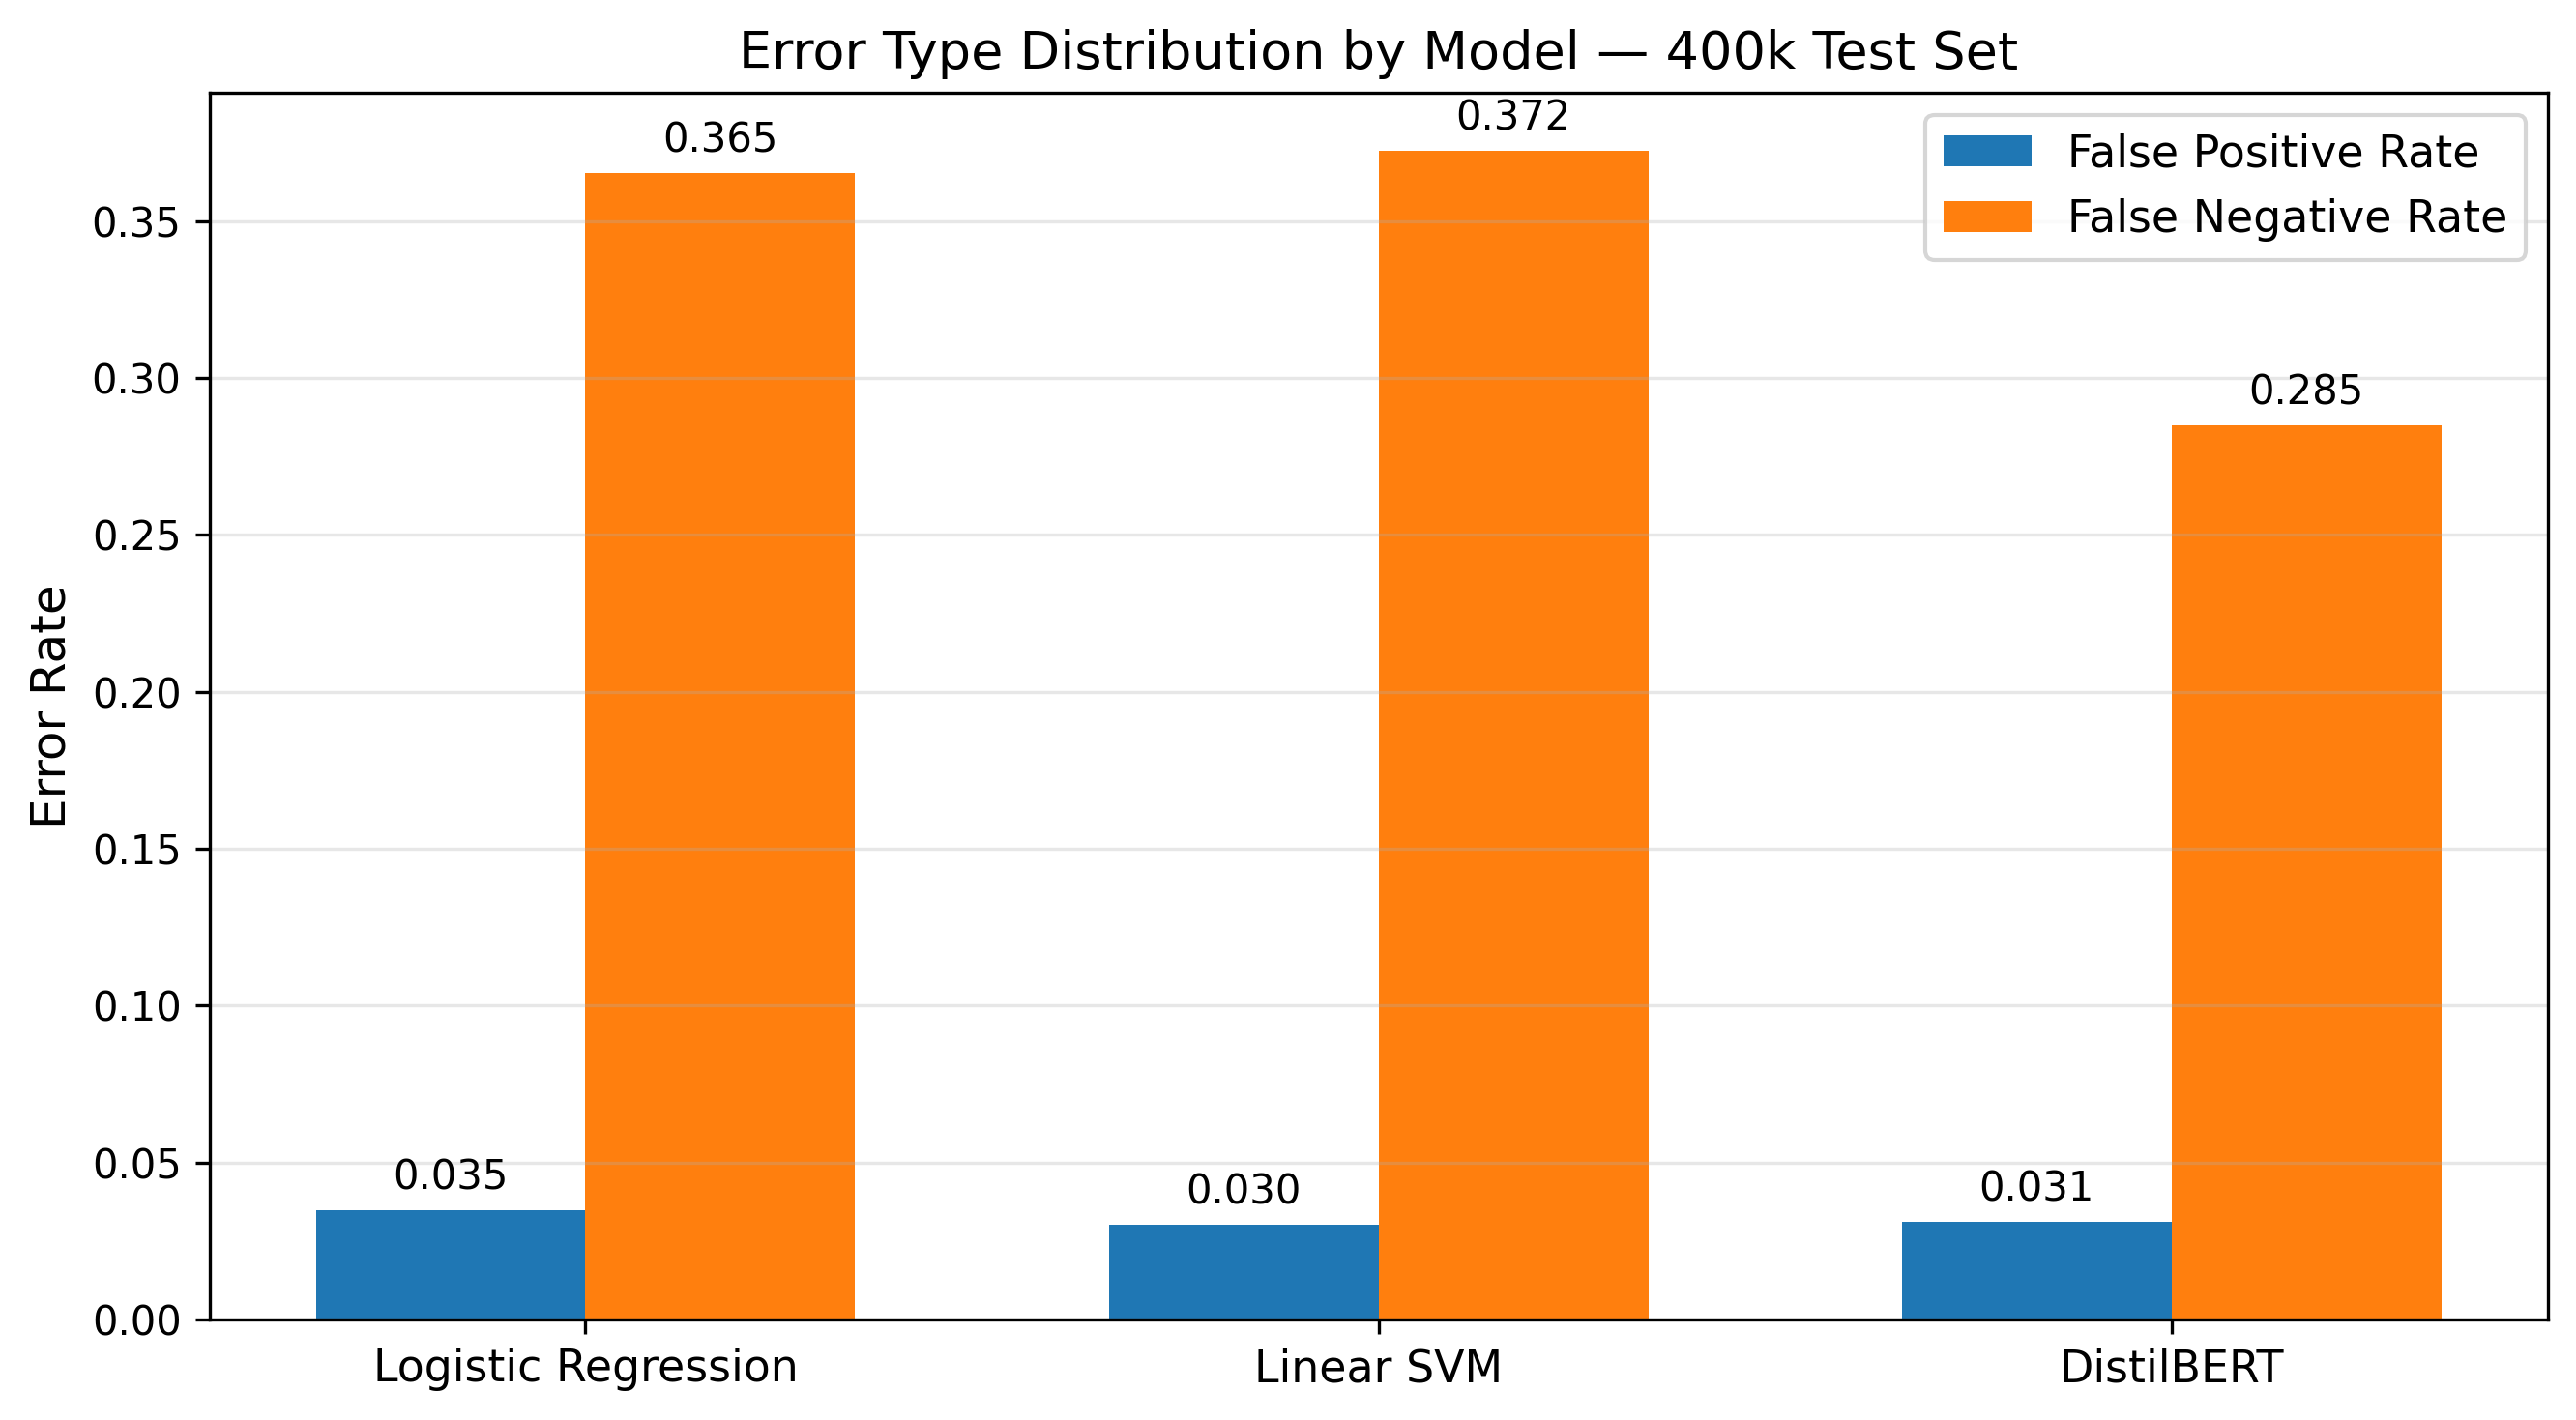

In [ ]:
# ---------------------------------------------------------------------
# Figure 16.1 — Error Type Distribution by Model (400k Test Set)
# ---------------------------------------------------------------------

rows = []
for prefix in model_prefixes:
    model_name = model_names[prefix]
    y_pred = preds[prefix]

    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())

    rows.append({
        "Model": model_name,
        "False Positives": fp,
        "False Negatives": fn,
        "FP Rate (of negatives)": fp / n_neg,
        "FN Rate (of positives)": fn / n_pos,
        "TP": tp,
        "TN": tn,
    })

error_dist_df = pd.DataFrame(rows)
error_dist_path = os.path.join(tables_dir, "error_type_distribution_400k.csv")
error_dist_df.to_csv(error_dist_path, index=False)

print("Table — Error Type Distribution by Model (400k Test Set):")
display(error_dist_df.round(4))
print(f"Saved: {error_dist_path}")

# Plot rates (more comparable than raw counts)
fig1, ax1 = plt.subplots(figsize=(9, 5))

x = np.arange(len(error_dist_df))
width = 0.34

bars_fp = ax1.bar(
    x - width/2,
    error_dist_df["FP Rate (of negatives)"],
    width=width,
    label="False Positive Rate",
)
bars_fn = ax1.bar(
    x + width/2,
    error_dist_df["FN Rate (of positives)"],
    width=width,
    label="False Negative Rate",
)

ax1.set_xticks(x)
ax1.set_xticklabels(error_dist_df["Model"], fontsize=11)
ax1.set_ylabel("Error Rate", fontsize=12)
ax1.set_title("Error Type Distribution by Model — 400k Test Set", fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, axis="y", alpha=0.3)

ax1.bar_label(bars_fp, fmt="%.3f", padding=3, fontsize=10)
ax1.bar_label(bars_fn, fmt="%.3f", padding=3, fontsize=10)

fig1.tight_layout()

fig1_path = os.path.join(figures_dir, "error_type_distribution_400k.png")
fig1.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.close(fig1)

print(f"Saved: {fig1_path}")
display(Image(filename=fig1_path))

**Interpretation of Figure 16.1.**  
Figure 16.1 shows that the main difference between the three 400k models lies less in false positive behaviour than in false negative behaviour. The false positive rates are low and very similar across models, ranging from `0.0302` to `0.0348`. This indicates that all three systems are comparably conservative with respect to incorrectly labelling non-toxic comments as toxic.

By contrast, the false negative rates are substantially higher and separate the models much more clearly. DistilBERT achieves the lowest false negative rate (`0.2849`), compared with `0.3652` for Logistic Regression and `0.3723` for Linear SVM. This means that DistilBERT misses markedly fewer toxic comments than the two classical baselines, which helps explain its superior PR-AUC and Macro-F1 performance in the earlier sections.

The figure therefore suggests that the main empirical advantage of DistilBERT is not a large reduction in overprediction, but a stronger ability to recover toxic content that the classical models fail to identify. In practical terms, the transformer model improves performance primarily by reducing missed toxic cases while maintaining a false positive rate that remains close to that of Logistic Regression and Linear SVM.

This pattern also helps to contextualise the qualitative examples in Table 16.1. The stronger overall performance of DistilBERT is consistent with a model that is better at detecting implicit, contextual, or weakly lexicalised toxicity, even though all three systems continue to exhibit some sensitivity to isolated toxic vocabulary in non-toxic contexts.

## Figure 16.2 — Pairwise Model Disagreement Rates

Table — Pairwise Model Disagreement Rates (400k Test Set):


,Model A,Model B,Disagreement Rate,Disagreement Count
0,Logistic Regression,Linear SVM,0.0148,1440
1,Logistic Regression,DistilBERT,0.0473,4603
2,Linear SVM,DistilBERT,0.0439,4275


Saved: /content/drive/MyDrive/ToxicityThesis/tables/pairwise_disagreement_rates_400k.csv
Saved: /content/drive/MyDrive/ToxicityThesis/figures/pairwise_disagreement_rates_400k.png


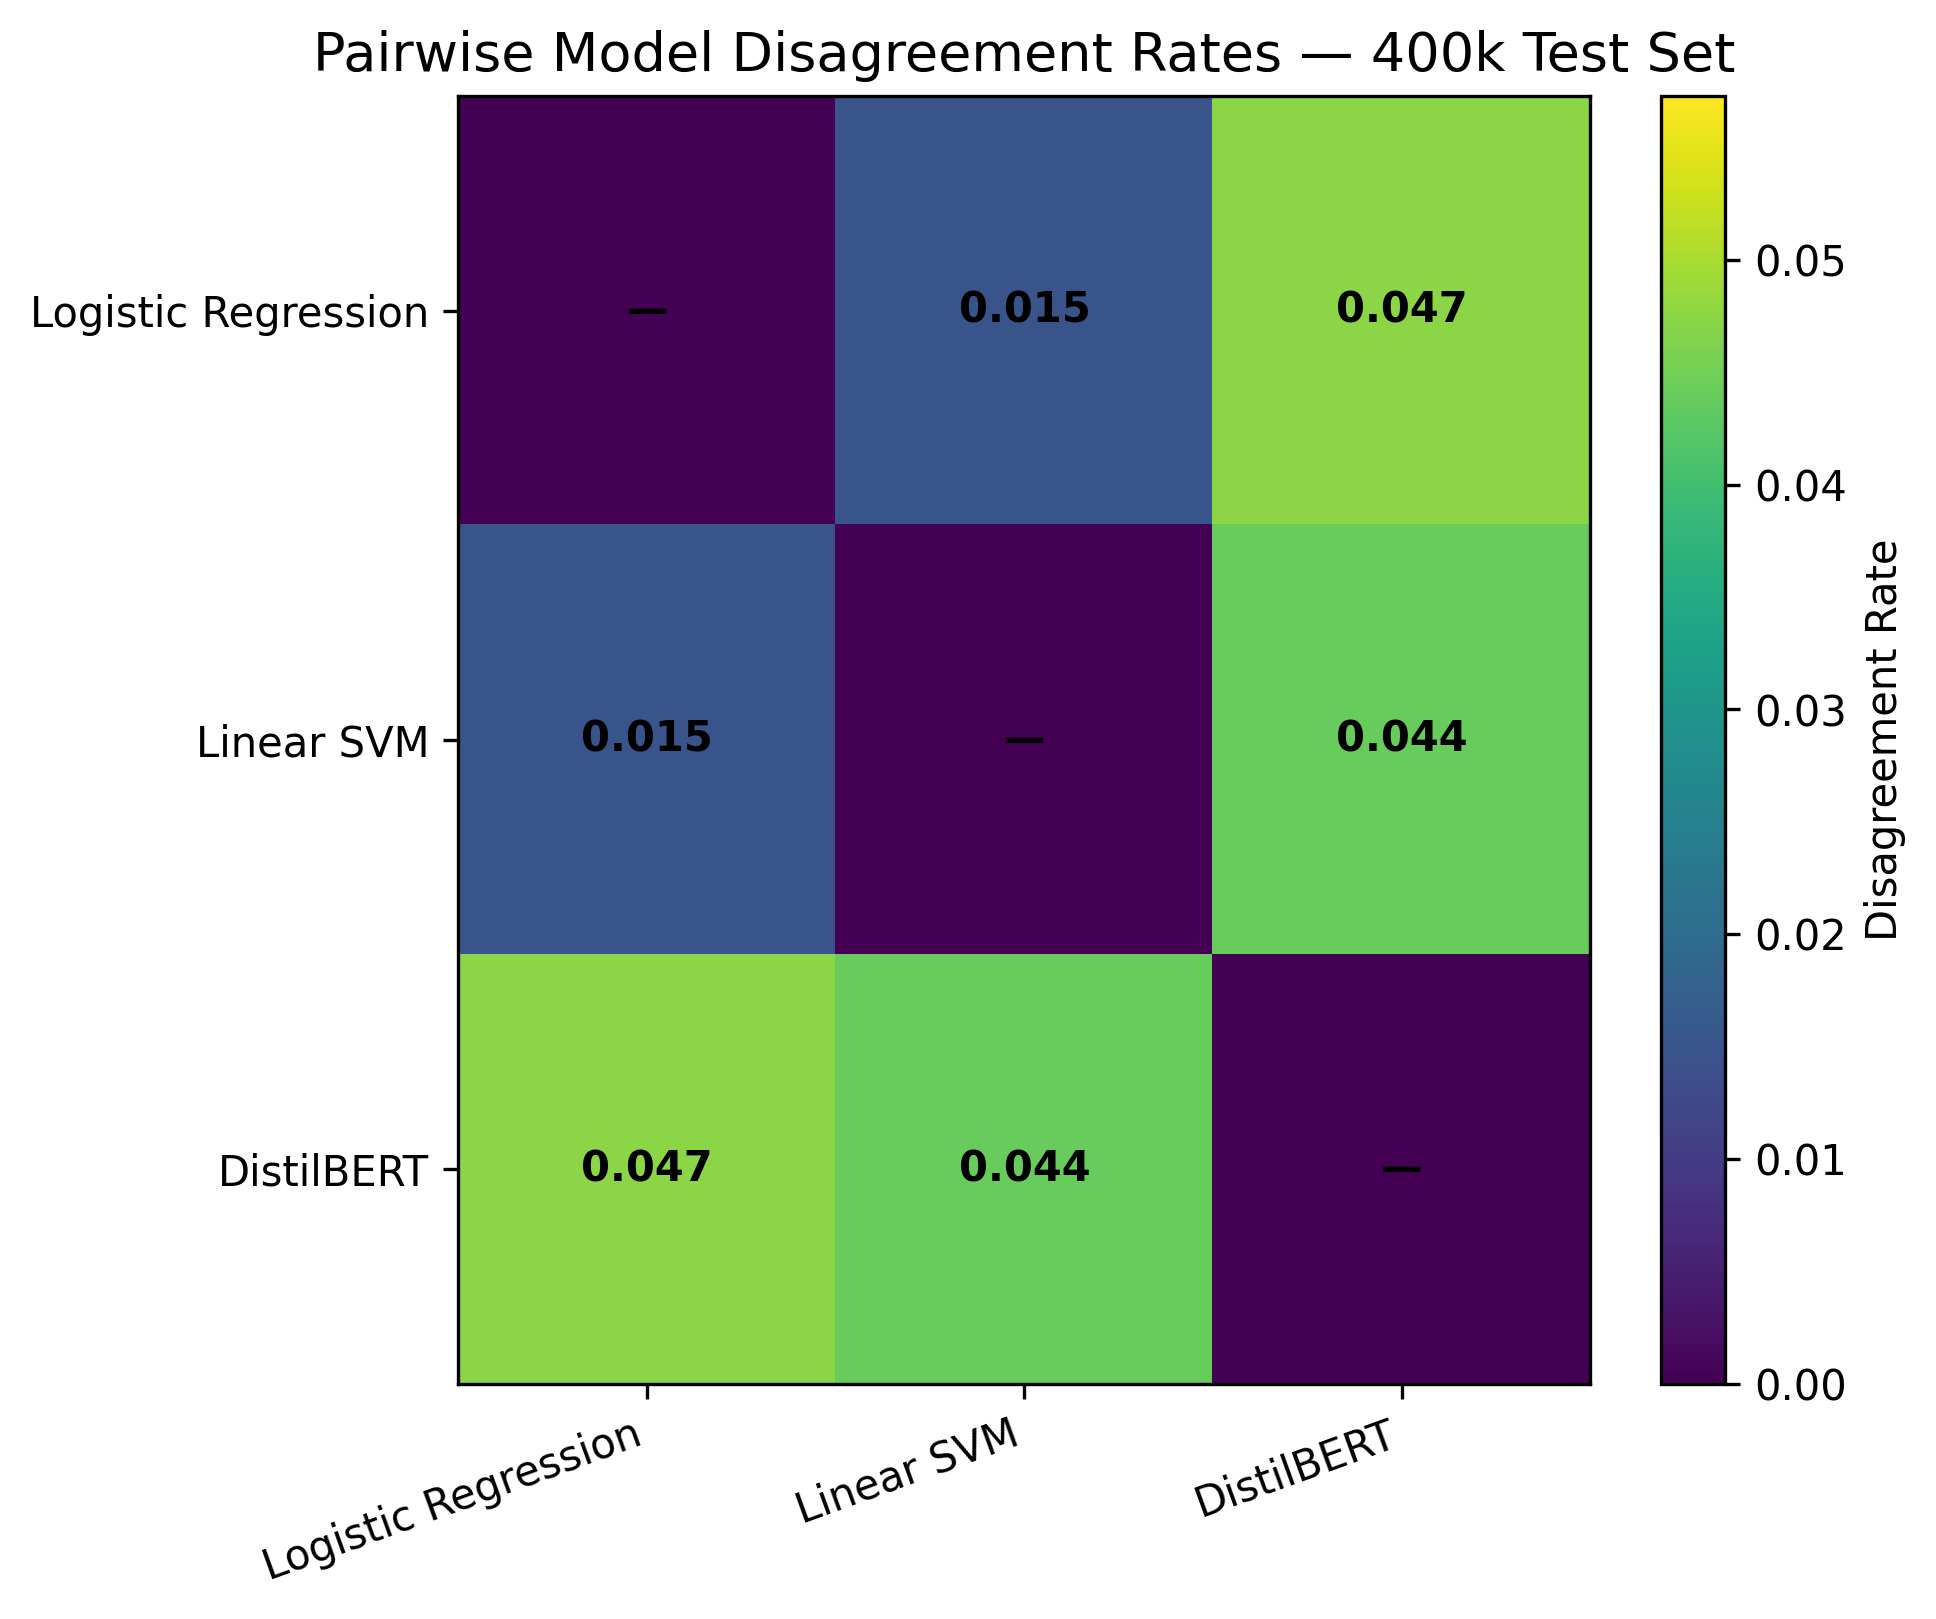

In [ ]:
# ---------------------------------------------------------------------
# Figure 16.2 — Pairwise Model Disagreement Rates
# ---------------------------------------------------------------------

pair_rows = []
matrix = np.zeros((3, 3), dtype=float)

ordered_prefixes = ["lr", "svm", "distilbert"]

for i, p1 in enumerate(ordered_prefixes):
    for j, p2 in enumerate(ordered_prefixes):
        if i == j:
            matrix[i, j] = 0.0
        else:
            rate = float((preds[p1] != preds[p2]).mean())
            matrix[i, j] = rate
            if i < j:
                pair_rows.append({
                    "Model A": model_names[p1],
                    "Model B": model_names[p2],
                    "Disagreement Rate": rate,
                    "Disagreement Count": int((preds[p1] != preds[p2]).sum()),
                })

disagree_df = pd.DataFrame(pair_rows)
disagree_path = os.path.join(tables_dir, "pairwise_disagreement_rates_400k.csv")
disagree_df.to_csv(disagree_path, index=False)

print("Table — Pairwise Model Disagreement Rates (400k Test Set):")
display(disagree_df.round(4))
print(f"Saved: {disagree_path}")

fig2, ax2 = plt.subplots(figsize=(6.5, 5.5))

im = ax2.imshow(matrix, aspect="auto", vmin=0, vmax=np.nanmax(matrix) + 0.01)

ax2.set_xticks(range(3))
ax2.set_yticks(range(3))
ax2.set_xticklabels([model_names[p] for p in ordered_prefixes], rotation=20, ha="right", fontsize=10)
ax2.set_yticklabels([model_names[p] for p in ordered_prefixes], fontsize=10)
ax2.set_title("Pairwise Model Disagreement Rates — 400k Test Set", fontsize=13)

for i in range(3):
    for j in range(3):
        val = matrix[i, j]
        text = "—" if i == j else f"{val:.3f}"
        ax2.text(j, i, text, ha="center", va="center", fontsize=10, fontweight="bold")

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("Disagreement Rate")

fig2.tight_layout()

fig2_path = os.path.join(figures_dir, "pairwise_disagreement_rates_400k.png")
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
plt.close(fig2)

print(f"Saved: {fig2_path}")
display(Image(filename=fig2_path))

**Interpretation of Figure 16.2.**  
Figure 16.2 quantifies how often each pair of 400k models produces different binary decisions on the same test examples after their own validation-selected thresholds have been applied. A low disagreement rate means that two models behave similarly at the decision level, whereas a higher disagreement rate indicates that they rely on meaningfully different decision rules.

The first and most important result is that **Logistic Regression and Linear SVM are highly similar**. Their disagreement rate is only **0.0148** (1,440 cases), which is far lower than the disagreement rates involving DistilBERT. This indicates that the two classical TF-IDF models, despite using different classifiers, make very similar final decisions on most test examples. In practical terms, the difference between these two models is primarily one of degree of effectiveness rather than qualitatively different behaviour.

By contrast, **DistilBERT disagrees with the classical models much more often**: **0.0473** against Logistic Regression (4,603 cases) and **0.0439** against Linear SVM (4,275 cases). These values are roughly three times larger than the LR–SVM disagreement rate. This is strong evidence that DistilBERT is not merely a slightly stronger version of the classical pipeline, but a model that often arrives at different decision outcomes on the same comments. The gap therefore reflects a genuine modelling difference between contextual representation learning and sparse lexical classification.

A further point is that DistilBERT is **slightly closer to Linear SVM than to Logistic Regression**, although the difference is small (`0.0439` vs `0.0473`). This is consistent with the broader quantitative results, where Linear SVM is the strongest classical baseline and usually sits between Logistic Regression and DistilBERT in overall performance. Nevertheless, the disagreement rate remains substantial in both comparisons, so DistilBERT’s behaviour should still be interpreted as qualitatively distinct from both classical baselines.

These disagreement rates also help explain why the qualitative examples in Table 16.1 are meaningful rather than anecdotal. If disagreement had been extremely rare, the borderline and inconsistent cases would carry limited interpretive value. Instead, the figure shows that disagreement between DistilBERT and the classical models affects a non-trivial minority of the test set. This justifies examining such cases directly, because they are likely to reveal where contextual modelling changes the decision boundary in practice.

Overall, Figure 16.2 supports a clear interpretation of the model family structure. Logistic Regression and Linear SVM form a closely related classical pair with highly similar decision behaviour, whereas DistilBERT constitutes a more distinct decision-making regime. This strengthens the conclusion that the transformer’s performance advantage is associated not only with better aggregate scores, but also with systematically different classification behaviour on individual examples.

## Section 17 — Research Question Answers

This section provides direct, evidence-based answers to the two research questions using the final test-set results reported in Tables 13.2–13.3 and Figures 14.1–14.4. The supporting analyses from Sections 15–16 are used only to qualify and interpret the main findings; they do not introduce additional research questions.

---

### RQ1 — Comparative Performance

*How do TF-IDF + Logistic Regression, TF-IDF + Linear SVM, and fine-tuned DistilBERT compare on toxicity classification under the natural class distribution, as measured by PR-AUC and Macro-F1?*

**Answer:**

At the primary comparison scale of **400k** training samples, **DistilBERT** achieved the strongest test performance on both evaluation metrics. Its test **PR-AUC = 0.7658**, compared with **0.6889** for **Linear SVM** and **0.6721** for **Logistic Regression**. This corresponds to an absolute gain of **0.0769** PR-AUC points over the best classical model and **0.0937** over Logistic Regression. The Macro-F1 ordering at 400k is fully consistent with the PR-AUC ordering: DistilBERT again ranks first (**0.8308**), followed by Linear SVM (**0.8022**) and Logistic Regression (**0.7953**).

This ordering is not confined to the largest training scale. Across **all three training sizes**, DistilBERT remains the strongest model, Linear SVM consistently ranks second, and Logistic Regression ranks third. At **25k**, DistilBERT already reaches a test PR-AUC of **0.6956**, compared with **0.5588** for Linear SVM and **0.5398** for Logistic Regression. At **100k**, the same ranking is preserved: DistilBERT reaches **0.7404**, Linear SVM **0.6473**, and Logistic Regression **0.6332**. The comparative result is therefore stable rather than scale-specific.

Within the classical family, Linear SVM outperforms Logistic Regression consistently, but the gap between those two models is relatively small compared with the much larger gap between DistilBERT and either classical baseline. The main empirical distinction in this study is therefore not within the classical family, but between the **sparse bag-of-words paradigm** and the **contextual transformer paradigm**.

The supporting analyses reinforce this conclusion rather than modifying it. The comment-length slice analysis in Section 15 shows that the overall ranking remains stable across **short**, **medium**, and **long** comments: DistilBERT is strongest in every bin, Linear SVM remains the strongest classical baseline, and Logistic Regression remains third. The qualitative and error-distribution analyses in Section 16 clarify why DistilBERT performs better overall. Its advantage is driven primarily by a lower **false negative rate** (**0.2849**) than Logistic Regression (**0.3652**) or Linear SVM (**0.3723**), while maintaining a false positive rate that is similar to the classical baselines. The qualitative examples further show that DistilBERT is often better at identifying **implicit hostility, sarcasm, and context-dependent derogation**, although it still overpredicts in some lexically toxic but non-abusive cases.

In summary, DistilBERT provides a **clear and consistent** improvement over the classical models for toxicity classification under natural class imbalance. Linear SVM is the strongest classical model, but the strongest overall results are obtained by the contextual transformer model on both threshold-independent and threshold-dependent evaluation.

*(Reference: Table 13.3, Figures 14.1–14.2; supporting interpretation from Sections 15–16.)*

---

### RQ2 — Data Efficiency

*How does predictive performance change as training data increases from 25k to 100k to 400k samples, and which model family is the most data-efficient across these scales?*

**Answer:**

All three model families improve as training data increases from **25k** to **100k** to **400k**. For test PR-AUC, Logistic Regression improves from **0.5398 → 0.6332 → 0.6721**, Linear SVM from **0.5588 → 0.6473 → 0.6889**, and DistilBERT from **0.6956 → 0.7404 → 0.7658**. The total gains from 25k to 400k are therefore **+0.1323** for Logistic Regression, **+0.1301** for Linear SVM, and **+0.0702** for DistilBERT.

Figure 14.4 clarifies the shape of these gains. For all three models, the larger increase occurs in the transition from **25k to 100k**, while the gain from **100k to 400k** is smaller. Logistic Regression gains **+0.0934** and then **+0.0389**; Linear SVM gains **+0.0885** and then **+0.0416**; DistilBERT gains **+0.0448** and then **+0.0254**. This indicates **diminishing returns** at larger data scales for all three model families.

In absolute terms, the classical models benefit more strongly from additional data. Their performance rises more steeply because they begin from weaker low-data baselines and rely more heavily on scale to approach their best results. DistilBERT, by contrast, improves more gradually in absolute terms. However, this should not be interpreted as weaker overall data efficiency. DistilBERT begins from a substantially stronger **25k** result and remains the strongest model at every scale. In practical low-data terms, it is therefore the most data-efficient family in this study, because it achieves the strongest ranking performance even when only limited training data is available.

This interpretation is supported by the secondary analyses. The comment-length slice analysis shows that the ranking remains stable across different input lengths, which means that DistilBERT’s low-data advantage is not confined to only one type of comment. The qualitative error analysis also suggests that the transformer’s comparative strength lies in detecting toxic meaning that is not fully captured by sparse lexical features alone. At the same time, the long-comment results indicate that all three model families face greater difficulty on longer inputs, and DistilBERT’s advantage narrows in that setting, partly because the model is limited to **128 input tokens** and may therefore observe only part of the longest comments.

The practical implication is therefore two-sided. If additional data becomes available, all three model families benefit, and the classical models gain substantially from scale. However, larger training sets do **not** alter the overall ranking: DistilBERT remains strongest, Linear SVM remains the best classical baseline, and Logistic Regression remains the weakest of the three. Thus, increasing data improves performance for every model, but it does not allow the classical baselines to close the gap to the transformer model within the tested range.

*(Reference: Table 13.3, Figures 14.1 and 14.4; supporting interpretation from Sections 15–16.)*

---

### Supporting Analyses

The supporting analyses do not change the answers to the research questions, but they strengthen their interpretation.

The **comment-length slice analysis** shows that the main ranking is robust across input lengths: DistilBERT remains strongest for short, medium, and long comments, while all three models decline on longer inputs. This suggests that comment length mainly affects the absolute difficulty of the task rather than the comparative ranking of model families.

The **qualitative error analysis** shows that the strongest false positives are often triggered by explicit toxic words used in quotation, self-reference, humour, or non-abusive evaluation, while the strongest false negatives more often involve indirect insult, sarcasm, oblique hostility, or politically framed antagonism. The disagreement analysis further shows that DistilBERT differs from the classical models on a meaningful minority of cases, which supports the interpretation that its performance advantage reflects not only stronger aggregate scores but also systematically different decision behaviour.

Taken together, these supporting analyses make the final interpretation more precise: DistilBERT is not merely marginally ahead in summary metrics, but appears to recover more toxic content, especially where toxicity is contextual or weakly lexicalised, while still sharing some common limitations with the classical models.